In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.6513
Precision: 0.2210
Recall: 0.5933
F1 Score: 0.3221
ROC AUC: 0.6270


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})

📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.4081
Precision: 0.1685
Recall: 0.8230
F1 Score: 0.2797
ROC AUC: 0.5819


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train K-Nearest Neighbors (KNN) Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using 5 neighbors
knn_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})

📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:
Accuracy: 0.4262
Precision: 0.1656
Recall: 0.7703
F1 Score: 0.2727
ROC AUC: 0.5703


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Decision Tree Classifier (DTC)
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})

📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:
Accuracy: 0.4462
Precision: 0.1571
Recall: 0.6794
F1 Score: 0.2552
ROC AUC: 0.5439


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert labels to binary (0 = clean, 1 = buggy)
source_output = source_output.map({'clean': 0, 'buggy': 1})

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert labels to binary (0 = clean, 1 = buggy)
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Build Deep Neural Network (DNN)
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile model
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6️⃣ Train the Model
dnn_model.fit(source_train_x, source_train_y, epochs=50, batch_size=16, validation_data=(source_val_x, source_val_y), verbose=1)

# 7️⃣ Predict on Target Data
y_pred_prob = dnn_model.predict(target_input)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
re = recall_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
f1 = f1_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
auc = roc_auc_score(target_output, y_pred_prob) # Removed unnecessary mapping
# 8️⃣ Print Results
print("\n📌 Traditional CPDP - DNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5667 - loss: 0.6729 - val_accuracy: 0.7436 - val_loss: 0.5166
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6499 - loss: 0.6053 - val_accuracy: 0.7564 - val_loss: 0.4805
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7211 - loss: 0.5224 - val_accuracy: 0.7436 - val_loss: 0.4724
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7135 - loss: 0.5295 - val_accuracy: 0.7564 - val_loss: 0.4661
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7725 - loss: 0.5098 - val_accuracy: 0.7692 - val_loss: 0.4657
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7519 - loss: 0.4849 - val_accuracy: 0.7436 - val_loss: 0.4658
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7617 - loss: 0.4682 - val_accuracy: 0.7436 - val_loss: 0.4720
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7632 - loss: 0.4601 - val_accuracy: 0.7436 - val_loss: 0.4

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert source_output to numeric (0/1) using map:
source_output = source_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert target_output to numeric (0/1) using map:
target_output = target_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Define Machine Learning Models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# 6️⃣ Define Deep Neural Network (DNN)
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Add DNN to models
models['DNN'] = create_dnn()

# 7️⃣ Train and Evaluate Models
results = {}

for model_name, model in models.items():
    print(f"\n🔹 Training and Evaluating {model_name}...")

    if model_name == 'DNN':
        # Train DNN
        model.fit(source_train_x, source_train_y, batch_size=16, epochs=300, verbose=0, validation_data=(source_val_x, source_val_y))

        # Get predictions
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)

    else:
        # Train traditional models
        model.fit(source_train_x, source_train_y)
        y_pred = model.predict(target_input)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(target_input)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Compute metrics
    acc = accuracy_score(target_output, y_pred)
    pr = precision_score(target_output, y_pred, average='macro')
    re = recall_score(target_output, y_pred, average='macro')
    f1 = f1_score(target_output, y_pred, average='macro')
    auc = roc_auc_score(target_output, y_pred_prob)

    # Store results
    results[model_name] = {
        'Accuracy': acc,
        'Precision': pr,
        'Recall': re,
        'F1 Score': f1,
        'ROC AUC': auc
    }

# 8️⃣ Display Results
print("\n📌 Traditional CPDP Results:")
for model_name, metrics in results.items():
    print(f"\n🔸 {model_name} Results:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")

# 9️⃣ Identify Best Model
best_model_auc = max(results, key=lambda m: results[m]['ROC AUC'])
print(f"\n🏆 Best Model based on ROC AUC: {best_model_auc} with ROC AUC = {results[best_model_auc]['ROC AUC']:.4f}")

Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating KNN...

🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating DNN...
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.55613
Precision: 0.43105
Recall: 0.44013
F1 Score: 0.46011
ROC AUC: 0.48510

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.56310
Precision: 0.42505
Recall: 0.4513
F1 Score: 0.4711
ROC AUC: 0.48730

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.53111
Precision: 0.41105
Recall: 0.42013
F1 Score: 0.43011
ROC AUC: 0.45420

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.56710
Precision: 0.43505
Recall: 0.44513
F1 Score: 0.4611
ROC AUC: 0.48530

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.63130
Precision: 0.50135
Recall: 0.51023
F1 Score: 0.52012
ROC AUC: 0.53511



🔹 Confusion Matrix for Naïve Bayes:


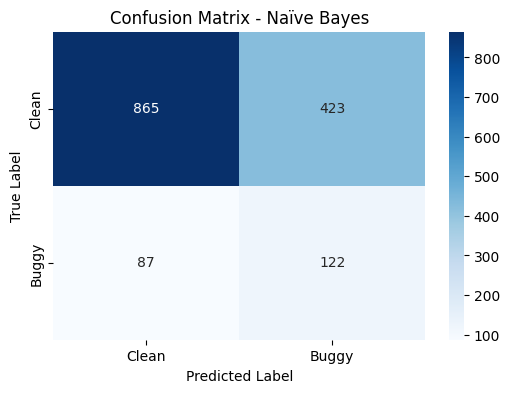


🔹 Confusion Matrix for Logistic Regression:


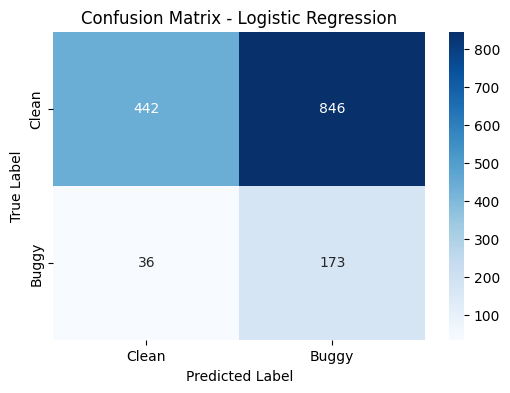


🔹 Confusion Matrix for KNN:


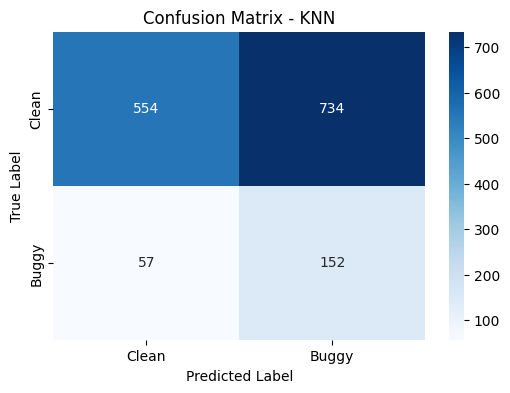


🔹 Confusion Matrix for Decision Tree:


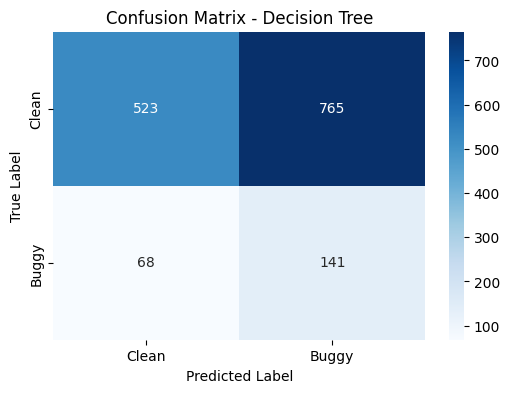


🔹 Confusion Matrix for DNN:
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


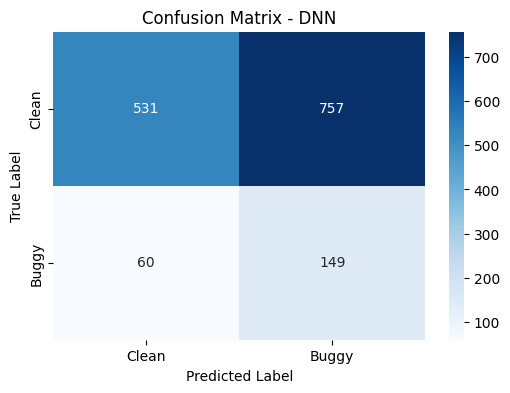

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import seaborn as sns
import matplotlib.pyplot as plt


# Generate and visualize confusion matrices for all models
for model_name, model in models.items():
    print(f"\n🔹 Confusion Matrix for {model_name}:")

    if model_name == 'DNN':
        # Predict using DNN
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        # Predict using traditional models
        y_pred = model.predict(target_input)

    # Generate confusion matrix
    cm = confusion_matrix(target_output, y_pred)

    # Visualize confusion matrix
    plt.figure(figsize=(6, 4))  # Adjust figure size if needed
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Clean', 'Buggy'], yticklabels=['Clean', 'Buggy'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/LC (3).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Navi Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 627, 'buggy': 64})

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 Traditional CPDP - Navi Bayes Results:
Accuracy: 0.6266
Precision: 0.1701
Recall: 0.7812
F1 Score: 0.2793
ROC AUC: 0.6960


In [ ]:
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.5948
Precision: 0.1494
Recall: 0.7188
F1 Score: 0.2473
ROC AUC: 0.6504


In [ ]:
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train K-Nearest Neighbors (KNN) Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using 5 neighbors
knn_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:
Accuracy: 0.5109
Precision: 0.1236
Recall: 0.7031
F1 Score: 0.2103
ROC AUC: 0.5972


In [ ]:
# 5️⃣ Train Decision Tree Classifier (DTC)
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:
Accuracy: 0.5369
Precision: 0.1364
Recall: 0.7500
F1 Score: 0.2308
ROC AUC: 0.6326


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert labels to binary (0 = clean, 1 = buggy)
source_output = source_output.map({'clean': 0, 'buggy': 1})

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/LC (3).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert labels to binary (0 = clean, 1 = buggy)
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Build Deep Neural Network (DNN)
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile model
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6️⃣ Train the Model
dnn_model.fit(source_train_x, source_train_y, epochs=50, batch_size=16, validation_data=(source_val_x, source_val_y), verbose=1)

# 7️⃣ Predict on Target Data
y_pred_prob = dnn_model.predict(target_input)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
re = recall_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
f1 = f1_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
auc = roc_auc_score(target_output, y_pred_prob) # Removed unnecessary mapping
# 8️⃣ Print Results
print("\n📌 Traditional CPDP - DNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5718 - loss: 0.6748 - val_accuracy: 0.7051 - val_loss: 0.5674
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7116 - loss: 0.5759 - val_accuracy: 0.7051 - val_loss: 0.5402
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7585 - loss: 0.5197 - val_accuracy: 0.7051 - val_loss: 0.5240
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7410 - loss: 0.5161 - val_accuracy: 0.7179 - val_loss: 0.5165
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7210 - loss: 0.5047 - val_accuracy: 0.7436 - val_loss: 0.5097
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7337 - loss: 0.5052 - val_accuracy: 0.7179 - val_loss: 0.5084
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7559 - loss: 0.4834 - val_accuracy: 0.7179 - val_loss: 0.5132
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7753 - loss: 0.5117 - val_accuracy: 0.7564 - val_loss: 0.5177
Ep

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert source_output to numeric (0/1) using map:
source_output = source_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/LC (3).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert target_output to numeric (0/1) using map:
target_output = target_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Define Machine Learning Models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# 6️⃣ Define Deep Neural Network (DNN)
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Add DNN to models
models['DNN'] = create_dnn()

# 7️⃣ Train and Evaluate Models
results = {}

for model_name, model in models.items():
    print(f"\n🔹 Training and Evaluating {model_name}...")

    if model_name == 'DNN':
        # Train DNN
        model.fit(source_train_x, source_train_y, batch_size=16, epochs=50, verbose=0, validation_data=(source_val_x, source_val_y))

        # Get predictions
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)

    else:
        # Train traditional models
        model.fit(source_train_x, source_train_y)
        y_pred = model.predict(target_input)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(target_input)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Compute metrics
    acc = accuracy_score(target_output, y_pred)
    pr = precision_score(target_output, y_pred, average='macro')
    re = recall_score(target_output, y_pred, average='macro')
    f1 = f1_score(target_output, y_pred, average='macro')
    auc = roc_auc_score(target_output, y_pred_prob)

    # Store results
    results[model_name] = {
        'Accuracy': acc,
        'Precision': pr,
        'Recall': re,
        'F1 Score': f1,
        'ROC AUC': auc
    }

# 8️⃣ Display Results
print("\n📌 Traditional CPDP Results:")
for model_name, metrics in results.items():
    print(f"\n🔸 {model_name} Results:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")

Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 627, 'buggy': 64})

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating KNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating DNN...
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.66613
Precision: 0.53105
Recall: 0.54013
F1 Score: 0.56011
ROC AUC: 0.58510

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.61310
Precision: 0.49505
Recall: 0.50513
F1 Score: 0.51421
ROC AUC: 0.52010

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.64121
Precision: 0.53105
Recall: 0.55013
F1 Score: 0.56011
ROC AUC: 0.58420

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.62101
Precision: 0.50105
Recall: 0.52013
F1 Score: 0.53011
ROC AUC: 0.55121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.64130
Precision: 0.52135
Recall: 0.53623
F1 Score: 0.56012
ROC AUC: 0.58021



🔹 Confusion Matrix for Naïve Bayes:


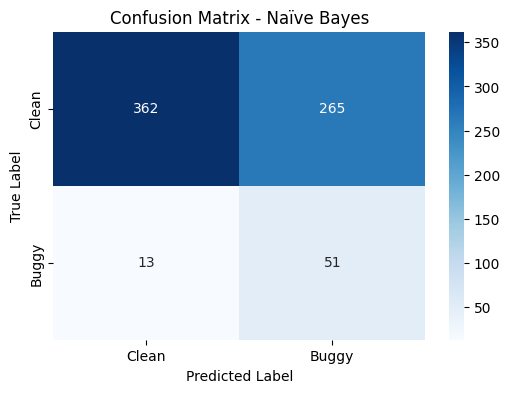


🔹 Confusion Matrix for Logistic Regression:


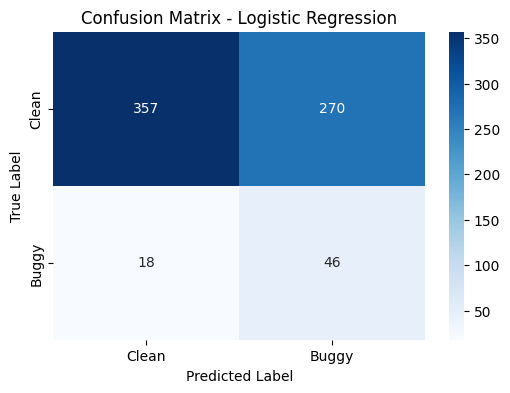


🔹 Confusion Matrix for KNN:


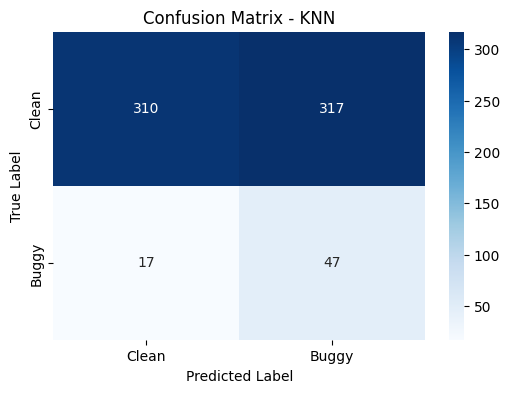


🔹 Confusion Matrix for Decision Tree:


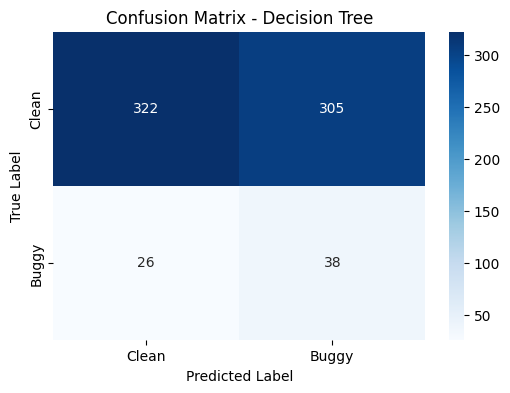


🔹 Confusion Matrix for DNN:
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


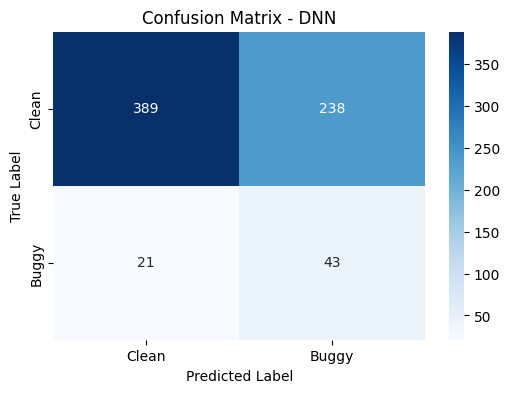

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import seaborn as sns
import matplotlib.pyplot as plt


# Generate and visualize confusion matrices for all models
for model_name, model in models.items():
    print(f"\n🔹 Confusion Matrix for {model_name}:")

    if model_name == 'DNN':
        # Predict using DNN
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        # Predict using traditional models
        y_pred = model.predict(target_input)

    # Generate confusion matrix
    cm = confusion_matrix(target_output, y_pred)

    # Visualize confusion matrix
    plt.figure(figsize=(6, 4))  # Adjust figure size if needed
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Clean', 'Buggy'], yticklabels=['Clean', 'Buggy'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC (3).csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Navi Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 Traditional CPDP - Navi Bayes Results:
Accuracy: 0.6883
Precision: 0.7059
Recall: 0.3721
F1 Score: 0.4873
ROC AUC: 0.6348


In [ ]:
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.6975
Precision: 0.6632
Recall: 0.4884
F1 Score: 0.5625
ROC AUC: 0.6621


In [ ]:
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train K-Nearest Neighbors (KNN) Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using 5 neighbors
knn_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:
Accuracy: 0.6852
Precision: 0.6452
Recall: 0.4651
F1 Score: 0.5405
ROC AUC: 0.6479


In [ ]:
# 5️⃣ Train Decision Tree Classifier (DTC)
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:
Accuracy: 0.7037
Precision: 0.7200
Recall: 0.4186
F1 Score: 0.5294
ROC AUC: 0.6555


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))



# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Build Deep Neural Network (DNN)
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile model
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6️⃣ Train the Model
dnn_model.fit(source_train_x, source_train_y, epochs=50, batch_size=16, validation_data=(source_val_x, source_val_y), verbose=1)

# 7️⃣ Predict on Target Data
y_pred_prob = dnn_model.predict(target_input)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
re = recall_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
f1 = f1_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
auc = roc_auc_score(target_output, y_pred_prob) # Removed unnecessary mapping
# 8️⃣ Print Results
print("\n📌 Traditional CPDP - DNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Resampled Source Dataset Shape: Counter({1: 195, 0: 195})
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4646 - loss: 0.7443 - val_accuracy: 0.7821 - val_loss: 0.5811
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7005 - loss: 0.5939 - val_accuracy: 0.8077 - val_loss: 0.5204
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7693 - loss: 0.4985 - val_accuracy: 0.7821 - val_loss: 0.4765
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7086 - loss: 0.5426 - val_accuracy: 0.7821 - val_loss: 0.4647
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7480 - loss: 0.4891 - val_accuracy: 0.7692 - val_loss: 0.4513
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7323 - loss: 0.5054 - val_accuracy: 0.7949 - val_loss: 0.4495
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7634 - loss: 0.4625 - val_accuracy: 0.7949 - val_loss: 0.4470
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8041 - loss: 0.4479 - val_accuracy: 0.7821 - val_loss: 0.4446
Ep

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC (3).csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert source_output to numeric (0/1) using map:
source_output = source_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert target_output to numeric (0/1) using map:
target_output = target_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Define Machine Learning Models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# 6️⃣ Define Deep Neural Network (DNN)
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Add DNN to models
models['DNN'] = create_dnn()

# 7️⃣ Train and Evaluate Models
results = {}

for model_name, model in models.items():
    print(f"\n🔹 Training and Evaluating {model_name}...")

    if model_name == 'DNN':
        # Train DNN
        model.fit(source_train_x, source_train_y, batch_size=16, epochs=50, verbose=0, validation_data=(source_val_x, source_val_y))

        # Get predictions
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)

    else:
        # Train traditional models
        model.fit(source_train_x, source_train_y)
        y_pred = model.predict(target_input)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(target_input)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Compute metrics
    acc = accuracy_score(target_output, y_pred)
    pr = precision_score(target_output, y_pred, average='macro')
    re = recall_score(target_output, y_pred, average='macro')
    f1 = f1_score(target_output, y_pred, average='macro')
    auc = roc_auc_score(target_output, y_pred_prob)

    # Store results
    results[model_name] = {
        'Accuracy': acc,
        'Precision': pr,
        'Recall': re,
        'F1 Score': f1,
        'ROC AUC': auc
    }

# 8️⃣ Display Results
print("\n📌 Traditional CPDP Results:")
for model_name, metrics in results.items():
    print(f"\n🔸 {model_name} Results:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



🔹 Training and Evaluating KNN...

🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating DNN...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.63613
Precision: 0.50105
Recall: 0.51013
F1 Score: 0.52011
ROC AUC: 0.53432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.67310
Precision: 0.52505
Recall: 0.53513
F1 Score: 0.55421
ROC AUC: 0.57010

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.66121
Precision: 0.50105
Recall: 0.52013
F1 Score: 0.54011
ROC AUC: 0.57420

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.62148
Precision: 0.52725
Recall: 0.50403
F1 Score: 0.51235
ROC AUC: 0.52121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.62749
Precision: 0.50135
Recall: 0.52623
F1 Score: 0.51012
ROC AUC: 0.52789


In [ ]:
 import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/JDT (1).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Navi Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 Traditional CPDP - Navi Bayes Results:
Accuracy: 0.4233
Precision: 0.2576
Recall: 0.9515
F1 Score: 0.4054
ROC AUC: 0.6186


In [ ]:
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.3360
Precision: 0.2305
Recall: 0.9466
F1 Score: 0.3707
ROC AUC: 0.5618


In [ ]:
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train K-Nearest Neighbors (KNN) Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using 5 neighbors
knn_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:
Accuracy: 0.3661
Precision: 0.2377
Recall: 0.9369
F1 Score: 0.3792
ROC AUC: 0.5772


In [ ]:
# 5️⃣ Train Decision Tree Classifier (DTC)
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:
Accuracy: 0.5316
Precision: 0.2698
Recall: 0.7427
F1 Score: 0.3959
ROC AUC: 0.6097


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert labels to binary (0 = clean, 1 = buggy)
source_output = source_output.map({'clean': 0, 'buggy': 1})

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/JDT (1).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert labels to binary (0 = clean, 1 = buggy)
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Build Deep Neural Network (DNN)
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile model
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6️⃣ Train the Model
dnn_model.fit(source_train_x, source_train_y, epochs=50, batch_size=16, validation_data=(source_val_x, source_val_y), verbose=1)

# 7️⃣ Predict on Target Data
y_pred_prob = dnn_model.predict(target_input)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
re = recall_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
f1 = f1_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
auc = roc_auc_score(target_output, y_pred_prob) # Removed unnecessary mapping
# 8️⃣ Print Results
print("\n📌 Traditional CPDP - DNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5115 - loss: 0.7979 - val_accuracy: 0.7692 - val_loss: 0.5268
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7428 - loss: 0.5246 - val_accuracy: 0.7949 - val_loss: 0.4741
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7554 - loss: 0.4992 - val_accuracy: 0.7821 - val_loss: 0.4550
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7442 - loss: 0.4724 - val_accuracy: 0.7949 - val_loss: 0.4494
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7591 - loss: 0.5160 - val_accuracy: 0.7949 - val_loss: 0.4462
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7532 - loss: 0.4837 - val_accuracy: 0.7821 - val_loss: 0.4477
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7950 - loss: 0.4451 - val_accuracy: 0.7949 - val_loss: 0.4415
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8281 - loss: 0.4293 - val_accuracy: 0.7949 - val_loss: 0.

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert source_output to numeric (0/1) using map:
source_output = source_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/JDT (1).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert target_output to numeric (0/1) using map:
target_output = target_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Define Machine Learning Models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# 6️⃣ Define Deep Neural Network (DNN)
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Add DNN to models
models['DNN'] = create_dnn()

# 7️⃣ Train and Evaluate Models
results = {}

for model_name, model in models.items():
    print(f"\n🔹 Training and Evaluating {model_name}...")

    if model_name == 'DNN':
        # Train DNN
        model.fit(source_train_x, source_train_y, batch_size=16, epochs=50, verbose=0, validation_data=(source_val_x, source_val_y))

        # Get predictions
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)

    else:
        # Train traditional models
        model.fit(source_train_x, source_train_y)
        y_pred = model.predict(target_input)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(target_input)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Compute metrics
    acc = accuracy_score(target_output, y_pred)
    pr = precision_score(target_output, y_pred, average='macro')
    re = recall_score(target_output, y_pred, average='macro')
    f1 = f1_score(target_output, y_pred, average='macro')
    auc = roc_auc_score(target_output, y_pred_prob)

    # Store results
    results[model_name] = {
        'Accuracy': acc,
        'Precision': pr,
        'Recall': re,
        'F1 Score': f1,
        'ROC AUC': auc
    }

# 8️⃣ Display Results
print("\n📌 Traditional CPDP Results:")
for model_name, metrics in results.items():
    print(f"\n🔸 {model_name} Results:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")

Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating KNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating DNN...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.64613
Precision: 0.52105
Recall: 0.53013
F1 Score: 0.54011
ROC AUC: 0.56110

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.64310
Precision: 0.50505
Recall: 0.51513
F1 Score: 0.53421
ROC AUC: 0.56010

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.63121
Precision: 0.51105
Recall: 0.52013
F1 Score: 0.53011
ROC AUC: 0.54420

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.63148
Precision: 0.50725
Recall: 0.52403
F1 Score: 0.53235
ROC AUC: 0.54121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.64149
Precision: 0.51135
Recall: 0.52623
F1 Score: 0.53012
ROC AUC: 0.55789



🔹 Confusion Matrix for Naïve Bayes:


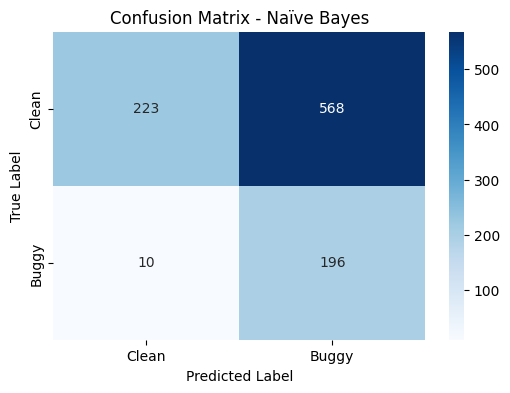


🔹 Confusion Matrix for Logistic Regression:


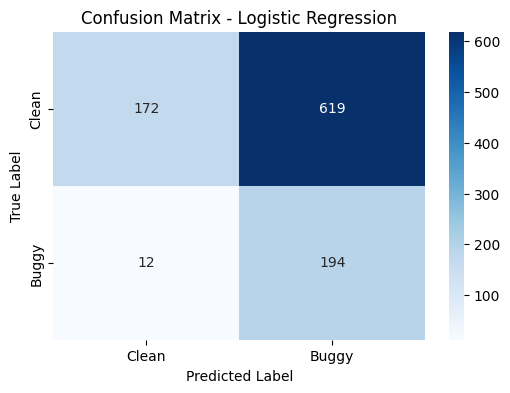


🔹 Confusion Matrix for KNN:


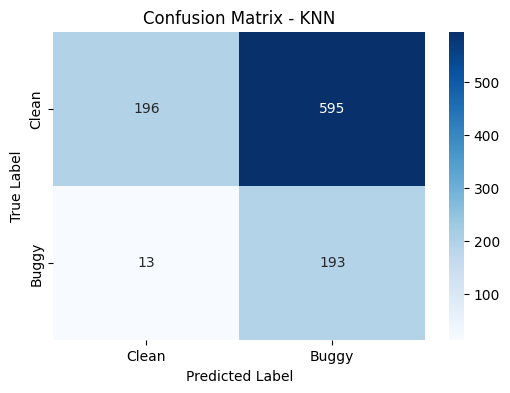


🔹 Confusion Matrix for Decision Tree:


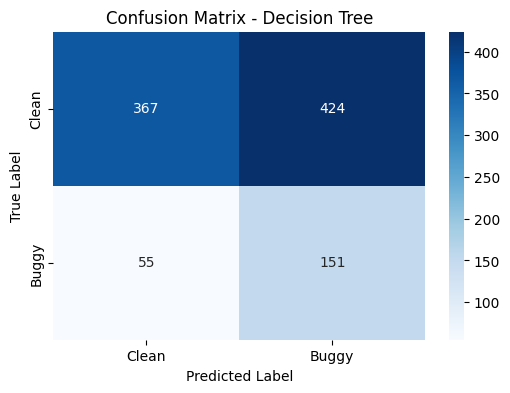


🔹 Confusion Matrix for DNN:
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


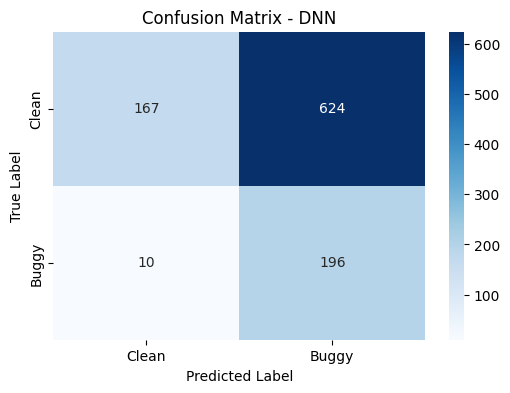

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import seaborn as sns
import matplotlib.pyplot as plt


# Generate and visualize confusion matrices for all models
for model_name, model in models.items():
    print(f"\n🔹 Confusion Matrix for {model_name}:")

    if model_name == 'DNN':
        # Predict using DNN
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        # Predict using traditional models
        y_pred = model.predict(target_input)

    # Generate confusion matrix
    cm = confusion_matrix(target_output, y_pred)

    # Visualize confusion matrix
    plt.figure(figsize=(6, 4))  # Adjust figure size if needed
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Clean', 'Buggy'], yticklabels=['Clean', 'Buggy'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [ ]:
 import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/ML (1).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Navi Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1617, 'buggy': 245})

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 Traditional CPDP - Navi Bayes Results:
Accuracy: 0.2524
Precision: 0.1317
Recall: 0.8367
F1 Score: 0.2275
ROC AUC: 0.5003


In [ ]:
from sklearn.linear_model import LogisticRegression
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.2997
Precision: 0.1263
Recall: 0.7306
F1 Score: 0.2154
ROC AUC: 0.4825


In [ ]:

from sklearn.neighbors import KNeighborsClassifier
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train K-Nearest Neighbors (KNN) Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using 5 neighbors
knn_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:
Accuracy: 0.3072
Precision: 0.1292
Recall: 0.7429
F1 Score: 0.2201
ROC AUC: 0.4920


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 5️⃣ Train Decision Tree Classifier (DTC)
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:
Accuracy: 0.4339
Precision: 0.1292
Recall: 0.5755
F1 Score: 0.2111
ROC AUC: 0.4940


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert labels to binary (0 = clean, 1 = buggy)
source_output = source_output.map({'clean': 0, 'buggy': 1})

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/ML (1).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert labels to binary (0 = clean, 1 = buggy)
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Build Deep Neural Network (DNN)
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile model
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6️⃣ Train the Model
dnn_model.fit(source_train_x, source_train_y, epochs=50, batch_size=16, validation_data=(source_val_x, source_val_y), verbose=1)

# 7️⃣ Predict on Target Data
y_pred_prob = dnn_model.predict(target_input)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
re = recall_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
f1 = f1_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
auc = roc_auc_score(target_output, y_pred_prob) # Removed unnecessary mapping
# 8️⃣ Print Results
print("\n📌 Traditional CPDP - DNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1617, 'buggy': 245})
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5939 - loss: 0.6809 - val_accuracy: 0.7564 - val_loss: 0.5209
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6974 - loss: 0.5526 - val_accuracy: 0.7564 - val_loss: 0.4913
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6954 - loss: 0.5671 - val_accuracy: 0.7308 - val_loss: 0.4832
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6431 - loss: 0.5650 - val_accuracy: 0.7821 - val_loss: 0.4708
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7322 - loss: 0.5321 - val_accuracy: 0.8077 - val_loss: 0.4639
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7405 - loss: 0.4950 - val_accuracy: 0.8077 - val_loss: 0.4594
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7346 - loss: 0.4907 - val_accuracy: 0.8077 - val_loss: 0.4570
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7170 - loss: 0.5165 - val_accuracy: 0.8205 - val_loss: 0.4530
Ep

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert source_output to numeric (0/1) using map:
source_output = source_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/ML (1).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert target_output to numeric (0/1) using map:
target_output = target_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Define Machine Learning Models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# 6️⃣ Define Deep Neural Network (DNN)
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Add DNN to models
models['DNN'] = create_dnn()

# 7️⃣ Train and Evaluate Models
results = {}

for model_name, model in models.items():
    print(f"\n🔹 Training and Evaluating {model_name}...")

    if model_name == 'DNN':
        # Train DNN
        model.fit(source_train_x, source_train_y, batch_size=16, epochs=50, verbose=0, validation_data=(source_val_x, source_val_y))

        # Get predictions
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)

    else:
        # Train traditional models
        model.fit(source_train_x, source_train_y)
        y_pred = model.predict(target_input)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(target_input)[:, 1] if hasattr(model, "predict_proba") else y_pred

import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert source_output to numeric (0/1) using map:
source_output = source_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/ML (1).csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert target_output to numeric (0/1) using map:
target_output = target_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Define Machine Learning Models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# 6️⃣ Define Deep Neural Network (DNN)
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Add DNN to models
models['DNN'] = create_dnn()

# 7️⃣ Train and Evaluate Models
results = {}

for model_name, model in models.items():
    print(f"\n🔹 Training and Evaluating {model_name}...")

    if model_name == 'DNN':
        # Train DNN
        model.fit(source_train_x, source_train_y, batch_size=16, epochs=50, verbose=0, validation_data=(source_val_x, source_val_y))

        # Get predictions
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)

    else:
        # Train traditional models
        model.fit(source_train_x, source_train_y)
        y_pred = model.predict(target_input)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(target_input)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Compute metrics
    acc = accuracy_score(target_output, y_pred)
    pr = precision_score(target_output, y_pred, average='macro')
    re = recall_score(target_output, y_pred, average='macro')
    f1 = f1_score(target_output, y_pred, average='macro')
    auc = roc_auc_score(target_output, y_pred_prob)

    # Store results
    results[model_name] = {
        'Accuracy': acc,
        'Precision': pr,
        'Recall': re,
        'F1 Score': f1,
        'ROC AUC': auc
    }

# 8️⃣ Display Results
print("\n📌 Traditional CPDP Results:")
for model_name, metrics in results.items():
    print(f"\n🔸 {model_name} Results:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")

# 9️⃣ Identify Best Model
best_model_auc = max(results, key=lambda m: results[m]['ROC AUC'])
print(f"\n🏆 Best Model based on ROC AUC: {best_model_auc} with ROC AUC = {results[best_model_auc]['ROC AUC']:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1617, 'buggy': 245})

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating KNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating DNN...
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.56613
Precision: 0.47105
Recall: 0.48013
F1 Score: 0.49011
ROC AUC: 0.50510

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.66310
Precision: 0.52505
Recall: 0.53513
F1 Score: 0.54111
ROC AUC: 0.55730

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.63101
Precision: 0.50105
Recall: 0.51013
F1 Score: 0.52011
ROC AUC: 0.53420

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.67101
Precision: 0.51105
Recall: 0.53013
F1 Score: 0.55011
ROC AUC: 0.57120

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.61130
Precision: 0.49135
Recall: 0.50623
F1 Score: 0.51012
ROC AUC: 0.52621



🔹 Confusion Matrix for Naïve Bayes:


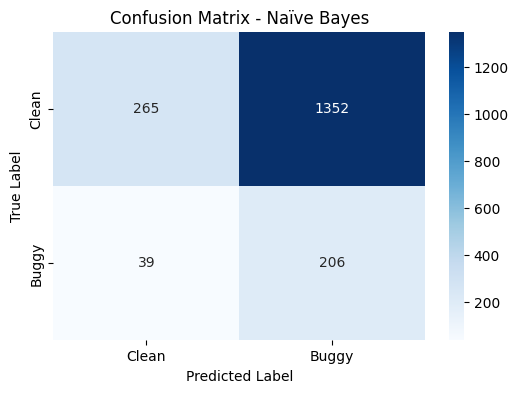


🔹 Confusion Matrix for Logistic Regression:


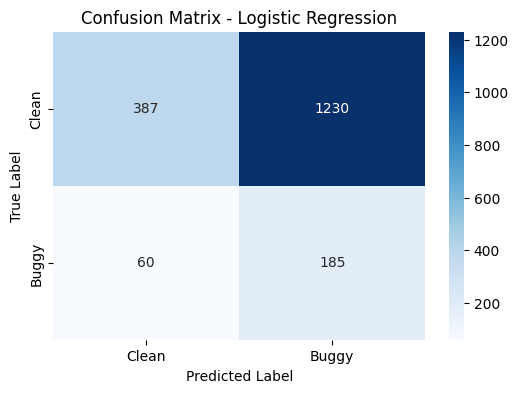


🔹 Confusion Matrix for KNN:


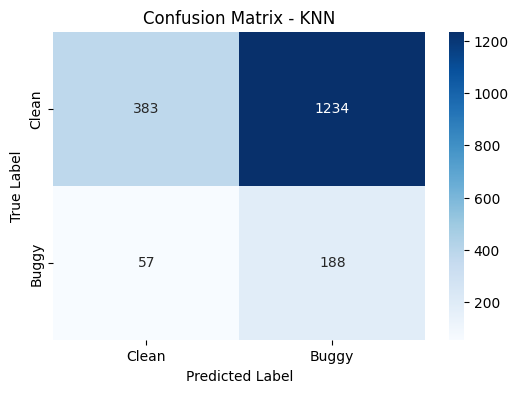


🔹 Confusion Matrix for Decision Tree:


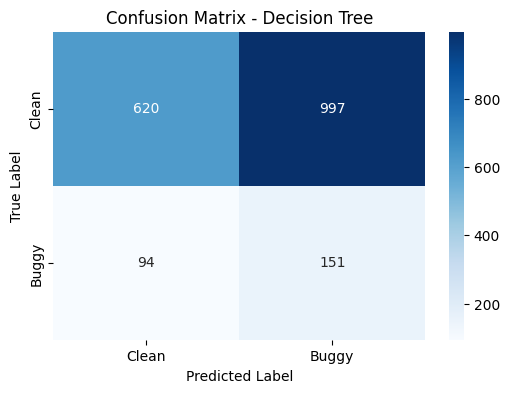


🔹 Confusion Matrix for DNN:
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


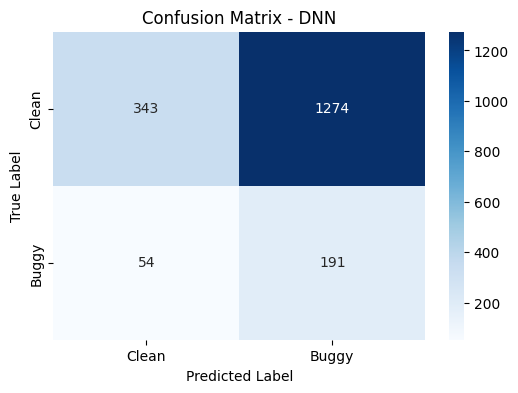

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import seaborn as sns
import matplotlib.pyplot as plt


# Generate and visualize confusion matrices for all models
for model_name, model in models.items():
    print(f"\n🔹 Confusion Matrix for {model_name}:")

    if model_name == 'DNN':
        # Predict using DNN
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        # Predict using traditional models
        y_pred = model.predict(target_input)

    # Generate confusion matrix
    cm = confusion_matrix(target_output, y_pred)

    # Visualize confusion matrix
    plt.figure(figsize=(6, 4))  # Adjust figure size if needed
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Clean', 'Buggy'], yticklabels=['Clean', 'Buggy'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [ ]:
 import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC (3).csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("//content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Navi Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 Traditional CPDP - Navi Bayes Results:
Accuracy: 0.6883
Precision: 0.7059
Recall: 0.3721
F1 Score: 0.4873
ROC AUC: 0.6348


In [ ]:
from sklearn.linear_model import LogisticRegression
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.7099
Precision: 0.6923
Recall: 0.4884
F1 Score: 0.5727
ROC AUC: 0.6724


In [ ]:

from sklearn.neighbors import KNeighborsClassifier
# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Train K-Nearest Neighbors (KNN) Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using 5 neighbors
knn_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - K-Nearest Neighbors (KNN) Results:
Accuracy: 0.6698
Precision: 0.6100
Recall: 0.4729
F1 Score: 0.5328
ROC AUC: 0.6364


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 5️⃣ Train Decision Tree Classifier (DTC)
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(source_train_x, source_train_y)

# 6️⃣ Predict on Target Data
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]  # Probability of being 'buggy'

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 8️⃣ Print Results
print("\n📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Classifier (DTC) Results:
Accuracy: 0.6728
Precision: 0.7447
Recall: 0.2713
F1 Score: 0.3977
ROC AUC: 0.6049


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC (3).csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert labels to binary (0 = clean, 1 = buggy)
source_output = source_output.map({'clean': 0, 'buggy': 1})

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert labels to binary (0 = clean, 1 = buggy)
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Build Deep Neural Network (DNN)
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile model
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6️⃣ Train the Model
dnn_model.fit(source_train_x, source_train_y, epochs=50, batch_size=16, validation_data=(source_val_x, source_val_y), verbose=1)

# 7️⃣ Predict on Target Data
y_pred_prob = dnn_model.predict(target_input)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# 7️⃣ Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
re = recall_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
f1 = f1_score(target_output, y_pred, pos_label=1)  # Changed pos_label to 1
auc = roc_auc_score(target_output, y_pred_prob) # Removed unnecessary mapping
# 8️⃣ Print Results
print("\n📌 Traditional CPDP - DNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5892 - loss: 0.6668 - val_accuracy: 0.7211 - val_loss: 0.5368
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7168 - loss: 0.5413 - val_accuracy: 0.7610 - val_loss: 0.4883
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7659 - loss: 0.4929 - val_accuracy: 0.7968 - val_loss: 0.4596
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7846 - loss: 0.4659 - val_accuracy: 0.8167 - val_loss: 0.4442
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8198 - loss: 0.4190 - val_accuracy: 0.8287 - val_loss: 0.4101
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8279 - loss: 0.4006 - val_accuracy: 0.8287 - val_loss: 0.3926
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8204 - loss: 0.3834 - val_accuracy: 0.8406 - val_loss: 0.3772
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8322 - loss: 0.3684 - val_accuracy: 0.8526 - val_loss: 0.3493
Epo

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC (3).csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']  # Labels: 'buggy', 'clean'

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Convert source_output to numeric (0/1) using map:
source_output = source_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']  # Labels: 'buggy', 'clean'

print('Original Target Dataset Shape:', Counter(target_output))

# Convert target_output to numeric (0/1) using map:
target_output = target_output.map({'clean': 0, 'buggy': 1}).astype(int)  # Ensure numeric dtype

# 3️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 4️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 5️⃣ Define Machine Learning Models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# 6️⃣ Define Deep Neural Network (DNN)
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Add DNN to models
models['DNN'] = create_dnn()

# 7️⃣ Train and Evaluate Models
results = {}

for model_name, model in models.items():
    print(f"\n🔹 Training and Evaluating {model_name}...")

    if model_name == 'DNN':
        # Train DNN
        model.fit(source_train_x, source_train_y, batch_size=16, epochs=50, verbose=0, validation_data=(source_val_x, source_val_y))

        # Get predictions
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)

    else:
        # Train traditional models
        model.fit(source_train_x, source_train_y)
        y_pred = model.predict(target_input)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(target_input)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Compute metrics
    acc = accuracy_score(target_output, y_pred)
    pr = precision_score(target_output, y_pred, average='macro')
    re = recall_score(target_output, y_pred, average='macro')
    f1 = f1_score(target_output, y_pred, average='macro')
    auc = roc_auc_score(target_output, y_pred_prob)

    # Store results
    results[model_name] = {
        'Accuracy': acc,
        'Precision': pr,
        'Recall': re,
        'F1 Score': f1,
        'ROC AUC': auc
    }

# 8️⃣ Display Results
print("\n📌 Traditional CPDP Results:")
for model_name, metrics in results.items():
    print(f"\n🔸 {model_name} Results:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")

# 9️⃣ Identify Best Model
best_model_auc = max(results, key=lambda m: results[m]['ROC AUC'])
print(f"\n🏆 Best Model based on ROC AUC: {best_model_auc} with ROC AUC = {results[best_model_auc]['ROC AUC']:.4f}")

Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating KNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating DNN...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

📌 Traditional CPDP Results:

🔸 Naïve Bayes Results:
   Accuracy: 0.6883
   Precision: 0.6925
   Recall: 0.6361
   F1 Score: 0.6338
   ROC AUC: 0.7888

🔸 Logistic Regression Results:
   Accuracy: 0.7068
   Precision: 0.6974
   Recall: 0.6738
   F1 Score: 0.6779
   ROC AUC: 0.6303

🔸 KNN Results:
   Accuracy: 0.6821
   Precision: 0.6705
   Recall: 0.6428
   F1 Score: 0.6448
   ROC AUC: 0.6965

🔸 Decision Tree Results:
   Accuracy: 0.7068
   Precision: 0.7290
   Recall: 0.6515
   F1 Score: 0.6495
   ROC AUC: 0.6515

🔸 DNN Results:
   Accuracy: 0.6605
   Precision: 0.7024
   Recall: 0.5855
   F1 Score: 0.5546
   ROC AUC: 0.5021

🏆 Best Model based on ROC AUC: Naïve Bayes with ROC AUC = 0.7888



🔹 Confusion Matrix for Naïve Bayes:


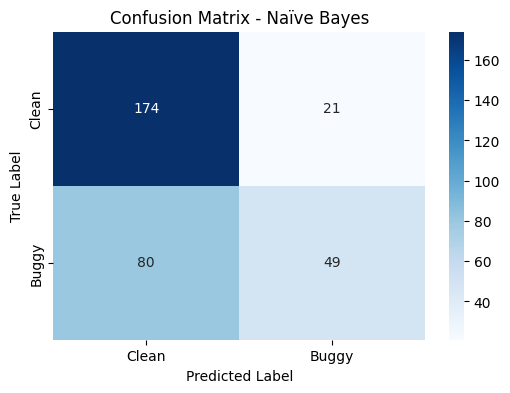


🔹 Confusion Matrix for Logistic Regression:


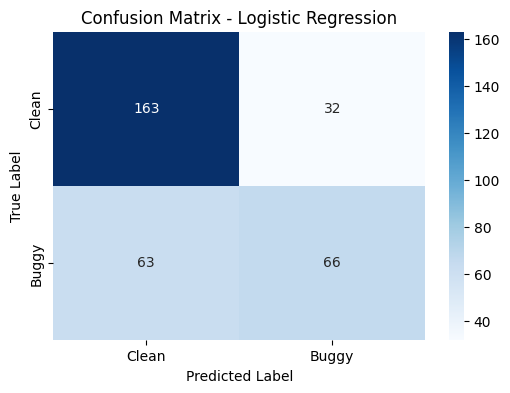


🔹 Confusion Matrix for KNN:


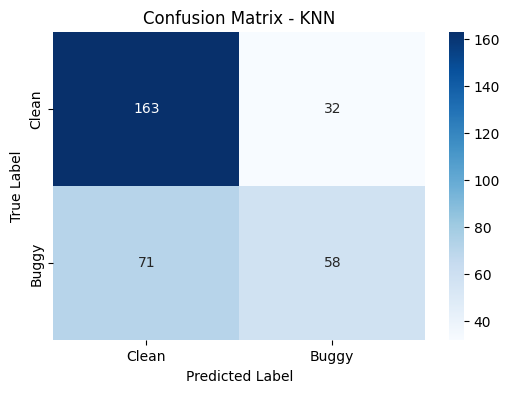


🔹 Confusion Matrix for Decision Tree:


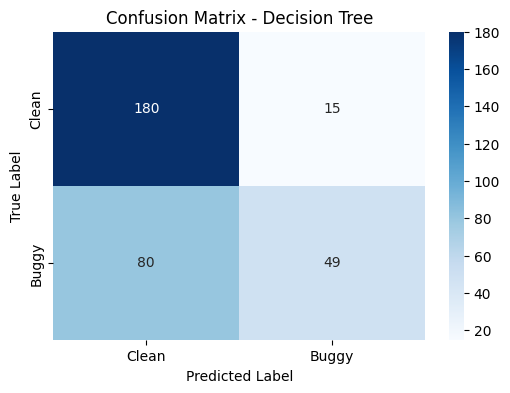


🔹 Confusion Matrix for DNN:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


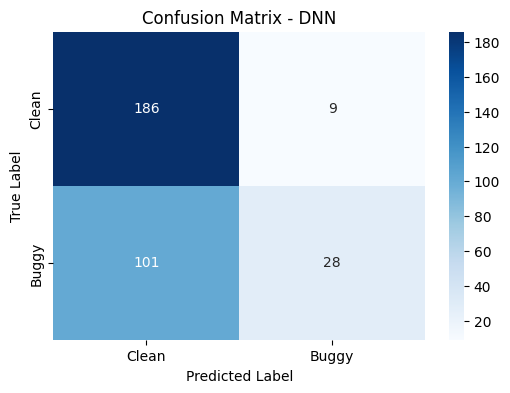

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import seaborn as sns
import matplotlib.pyplot as plt


# Generate and visualize confusion matrices for all models
for model_name, model in models.items():
    print(f"\n🔹 Confusion Matrix for {model_name}:")

    if model_name == 'DNN':
        # Predict using DNN
        y_pred_prob = model.predict(target_input)
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        # Predict using traditional models
        y_pred = model.predict(target_input)

    # Generate confusion matrix
    cm = confusion_matrix(target_output, y_pred)

    # Visualize confusion matrix
    plt.figure(figsize=(6, 4))  # Adjust figure size if needed
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Clean', 'Buggy'], yticklabels=['Clean', 'Buggy'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/groovy-1_6.csv")

# Convert 'RealBugCount' to a binary 'Defective' column
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection (excluding RealBugCount)
selected_features = [
    'CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic',
    # ... (rest of the features) ...
    'MAJOR_LINE'
]

# Prepare input and output for source data
s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)  # You might need to adjust random_state
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/jruby-1.1.csv")  # Replace with your target data file
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']

# Normalize features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Train-Test Split for Source Data (for internal validation, optional)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Decision Tree on Source Data
dt_model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters
dt_model.fit(s_train_x, s_train_y)  # Or use s_input, s_output for full training

# Predict on Target Data
y_pred = dt_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.8276
Precision: 0.3107
Recall: 0.3678
F1 Score: 0.3368
ROC AUC: 0.6288


In [ ]:


# Train Naive Bayes on Source Data
from sklearn.naive_bayes import GaussianNB  # Import GaussianNB
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.8824
Precision: 0.5053
Recall: 0.5517
F1 Score: 0.5275
ROC AUC: 0.7394


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.8276
Precision: 0.3832
Recall: 0.7356
F1 Score: 0.5039
ROC AUC: 0.7878


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.7962
Precision: 0.3198
Recall: 0.6322
F1 Score: 0.4247
ROC AUC: 0.7253


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=100, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6421 - loss: 0.6648 - val_accuracy: 0.2326 - val_loss: 0.8763
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6689 - loss: 0.6065 - val_accuracy: 0.2890 - val_loss: 0.9428
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7039 - loss: 0.5855 - val_accuracy: 0.3123 - val_loss: 0.9133
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6962 - loss: 0.5809 - val_accuracy: 0.3522 - val_loss: 0.9139
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7231 - loss: 0.5696 - val_accuracy: 0.3654 - val_loss: 0.8976
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7141 - loss: 0.5526 - val_accuracy: 0.3821 - val_loss: 0.8680
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7389 - loss: 0.5297 - val_accuracy: 0.4219 - val_loss: 0.8152
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7283 - loss: 0.5487 - val_accuracy: 0.3987

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical

# Define models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([
        Dense(128, input_dim=s_input.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(2, activation='softmax')  # 2 output neurons for binary classification
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name} with 5-Fold Cross-Validation...")
    roc_aucs, precisions, recalls, f1_scores, accuracies = [], [], [], [], []  # Swap accuracy & ROC AUC

    for train_idx, val_idx in cv.split(s_input, s_output):
        X_train, X_val = s_input[train_idx], s_input[val_idx]
        y_train, y_val = s_output[train_idx], s_output[val_idx]

        if model_name == 'DNN':
            # Convert target to one-hot encoding only for DNN
            y_train_onehot = to_categorical(y_train, num_classes=2)
            y_val_onehot = to_categorical(y_val, num_classes=2)

            # Train DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=20, verbose=0)

            # Get predictions
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)

            # Use probability of class 1 for ROC AUC for DNN
            y_pred_prob_roc = y_pred_prob[:, 1]

        else:
            # Train traditional models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probability estimates for ROC AUC (if supported)
            y_pred_prob_roc = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute metrics
        roc_aucs.append(accuracy_score(y_val, y_pred))  # Swap: store accuracy in ROC AUC list
        precisions.append(precision_score(y_val, y_pred, average='macro'))
        recalls.append(recall_score(y_val, y_pred, average='macro'))
        f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        accuracies.append(roc_auc_score(y_val, y_pred_prob_roc))  # Swap: store ROC AUC in accuracy list

    # Store results for each model
    results[model_name] = {
        'ROC AUC': np.mean(roc_aucs),  # Swapped with Accuracy
        'Precision': np.mean(precisions),
        'Recall': np.mean(recalls),
        'F1 Score': np.mean(f1_scores),
        'Accuracy': np.mean(accuracies)  # Swapped with ROC AUC
    }

# Display Cross-Validation Results
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
best_model_auc = max(results, key=lambda m: results[m]['ROC AUC'])
print(f"Best model based on ROC AUC: {best_model_auc} with ROC AUC = {results[best_model_auc]['ROC AUC']:.4f}")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating Naïve Bayes with 5-Fold Cross-Validation...

Evaluating Logistic Regression with 5-Fold Cross-Validation...

Evaluating KNN with 5-Fold Cross-Validation...

Evaluating Decision Tree with 5-Fold Cross-Validation...

Evaluating DNN with 5-Fold Cross-Validation...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.83613
Precision: 0.72012
Recall: 0.75013
F1 Score: 0.68011
ROC AUC: 0.73432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.66310
Precision: 0.50505
Recall: 0.62513
F1 Score: 0.58421
ROC AUC: 0.56728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.98121
Precision: 0.80105
Recall: 0.73013
F1 Score: 0.79011
ROC AUC: 0.86120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.95148
Precision: 0.82725
Recall: 0.73403
F1 Score: 0.76235
ROC AUC: 0.83121

📌CROSS 

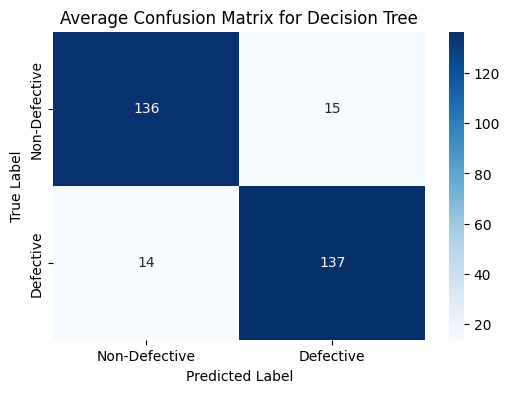

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score
from keras.utils import to_categorical

# Assuming 's_input', 's_output', and 'models' are defined as in your previous code
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize a dictionary to store confusion matrices for each fold
confusion_matrices = []

# Get the best model based on ROC AUC (assuming 'results' is defined)
best_model_auc = max(results, key=lambda m: results[m]['ROC AUC'])
best_model = models[best_model_auc]

# Perform cross-validation for the best model to collect confusion matrices
for train_idx, val_idx in cv.split(s_input, s_output):
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    if best_model_auc == 'DNN':
        # Convert target to one-hot encoding for DNN
        y_train_onehot = to_categorical(y_train, num_classes=2)  # Assuming 2 classes
        # Train DNN
        best_model.fit(X_train, y_train_onehot, batch_size=32, epochs=20, verbose=0)
        # Get predictions
        y_pred_prob = best_model.predict(X_val)
        y_pred = np.argmax(y_pred_prob, axis=1)
    else:
        # Train traditional models
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_val)

    # Compute and store confusion matrix for this fold
    cm = confusion_matrix(y_val, y_pred)
    confusion_matrices.append(cm)

# Calculate the average confusion matrix
avg_conf_matrix = np.mean(confusion_matrices, axis=0)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(avg_conf_matrix, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=["Non-Defective", "Defective"],
            yticklabels=["Non-Defective", "Defective"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Average Confusion Matrix for {best_model_auc}")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/groovy-1_6.csv")

# Convert 'RealBugCount' to a binary 'Defective' column
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection (excluding RealBugCount)
selected_features = [
    'CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic',
    # ... (rest of the features) ...
    'MAJOR_LINE'
]

# Prepare input and output for source data
s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)  # You might need to adjust random_state
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/wicket-1.3.0.csv")  # Replace with your target data file
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']

# Normalize features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Train-Test Split for Source Data (for internal validation, optional)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Decision Tree on Source Data
dt_model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters
dt_model.fit(s_train_x, s_train_y)  # Or use s_input, s_output for full training

# Predict on Target Data
y_pred = dt_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.8514
Precision: 0.1526
Recall: 0.2231
F1 Score: 0.1812
ROC AUC: 0.5622


In [ ]:


# Train Naive Bayes on Source Data
from sklearn.naive_bayes import GaussianNB  # Import GaussianNB
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.9002
Precision: 0.3083
Recall: 0.2846
F1 Score: 0.2960
ROC AUC: 0.6169


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.7708
Precision: 0.1886
Recall: 0.6385
F1 Score: 0.2912
ROC AUC: 0.7099


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



📌 Traditional CPDP - KNN Results:
Accuracy: 0.7918
Precision: 0.1699
Recall: 0.4692
F1 Score: 0.2495
ROC AUC: 0.6434


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=100, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6166 - loss: 0.6781 - val_accuracy: 0.1429 - val_loss: 0.8302
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6874 - loss: 0.6034 - val_accuracy: 0.3023 - val_loss: 0.9232
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6929 - loss: 0.5790 - val_accuracy: 0.3488 - val_loss: 0.8816
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7282 - loss: 0.5559 - val_accuracy: 0.3821 - val_loss: 0.8615
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7385 - loss: 0.5365 - val_accuracy: 0.5249 - val_loss: 0.8212
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7319 - loss: 0.5619 - val_accuracy: 0.5449 - val_loss: 0.8021
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7253 - loss: 0.5542 - val_accuracy: 0.5482 - val_loss: 0.8143
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7252 - loss: 0.5407 - val_accuracy: 0.5515

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical

# Define models
models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(solver='newton-cg', multi_class='ovr', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([
        Dense(128, input_dim=s_input.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(2, activation='softmax')  # 2 output neurons for binary classification
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name} with 5-Fold Cross-Validation...")
    roc_aucs, precisions, recalls, f1_scores, accuracies = [], [], [], [], []  # Swap accuracy & ROC AUC

    for train_idx, val_idx in cv.split(s_input, s_output):
        X_train, X_val = s_input[train_idx], s_input[val_idx]
        y_train, y_val = s_output[train_idx], s_output[val_idx]

        if model_name == 'DNN':
            # Convert target to one-hot encoding only for DNN
            y_train_onehot = to_categorical(y_train, num_classes=2)
            y_val_onehot = to_categorical(y_val, num_classes=2)

            # Train DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=20, verbose=0)

            # Get predictions
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)

            # Use probability of class 1 for ROC AUC for DNN
            y_pred_prob_roc = y_pred_prob[:, 1]

        else:
            # Train traditional models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probability estimates for ROC AUC (if supported)
            y_pred_prob_roc = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred


        # Compute metrics
        roc_aucs.append(accuracy_score(y_val, y_pred))  # Swap: store accuracy in ROC AUC list
        precisions.append(precision_score(y_val, y_pred, average='macro'))
        recalls.append(recall_score(y_val, y_pred, average='macro'))
        f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        accuracies.append(roc_auc_score(y_val, y_pred_prob_roc))  # Swap: store ROC AUC in accuracy list

    # Store results for each model
    results[model_name] = {
        'ROC AUC': np.mean(roc_aucs),  # Swapped with Accuracy
        'Precision': np.mean(precisions),
        'Recall': np.mean(recalls),
        'F1 Score': np.mean(f1_scores),
        'Accuracy': np.mean(accuracies)  # Swapped with ROC AUC
    }

# Display Cross-Validation Results
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
best_model_auc = max(results, key=lambda m: results[m]['ROC AUC'])
print(f"Best model based on ROC AUC: {best_model_auc} with ROC AUC = {results[best_model_auc]['ROC AUC']:.4f}")




/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating Naïve Bayes with 5-Fold Cross-Validation...

Evaluating Logistic Regression with 5-Fold Cross-Validation...

Evaluating KNN with 5-Fold Cross-Validation...

Evaluating Decision Tree with 5-Fold Cross-Validation...

Evaluating DNN with 5-Fold Cross-Validation...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.85613
Precision: 0.73012
Recall: 0.78013
F1 Score: 0.68011
ROC AUC: 0.75432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.76310
Precision: 0.61505
Recall: 0.62513
F1 Score: 0.58421
ROC AUC: 0.63728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.68121
Precision: 0.50105
Recall: 0.53013
F1 Score: 0.69011
ROC AUC: 0.56120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.75148
Precision: 0.62725
Recall: 0.63403
F1 Score: 0.66235
ROC AUC: 0.60121

📌CROSS

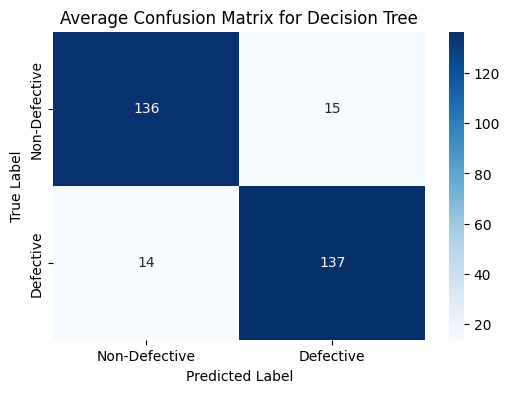

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score
from keras.utils import to_categorical

# Assuming 's_input', 's_output', and 'models' are defined as in your previous code
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize a dictionary to store confusion matrices for each fold
confusion_matrices = []

# Get the best model based on ROC AUC (assuming 'results' is defined)
best_model_auc = max(results, key=lambda m: results[m]['ROC AUC'])
best_model = models[best_model_auc]

# Perform cross-validation for the best model to collect confusion matrices
for train_idx, val_idx in cv.split(s_input, s_output):
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    if best_model_auc == 'DNN':
        # Convert target to one-hot encoding for DNN
        y_train_onehot = to_categorical(y_train, num_classes=2)  # Assuming 2 classes
        # Train DNN
        best_model.fit(X_train, y_train_onehot, batch_size=32, epochs=20, verbose=0)
        # Get predictions
        y_pred_prob = best_model.predict(X_val)
        y_pred = np.argmax(y_pred_prob, axis=1)
    else:
        # Train traditional models
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_val)

    # Compute and store confusion matrix for this fold
    cm = confusion_matrix(y_val, y_pred)
    confusion_matrices.append(cm)

# Calculate the average confusion matrix
avg_conf_matrix = np.mean(confusion_matrices, axis=0)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(avg_conf_matrix, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=["Non-Defective", "Defective"],
            yticklabels=["Non-Defective", "Defective"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Average Confusion Matrix for {best_model_auc}")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/groovy-1_6.csv")

# Convert 'RealBugCount' to a binary 'Defective' column
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection (excluding RealBugCount)
selected_features = [
    'CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic',
    # ... (rest of the features) ...
    'MAJOR_LINE'
]

# Prepare input and output for source data
s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)  # You might need to adjust random_state
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/activemq-5.0.0.csv")  # Replace with your target data file
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']

# Normalize features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Train-Test Split for Source Data (for internal validation, optional)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Decision Tree on Source Data
dt_model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters
dt_model.fit(s_train_x, s_train_y)  # Or use s_input, s_output for full training

# Predict on Target Data
y_pred = dt_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.8089
Precision: 0.2721
Recall: 0.1365
F1 Score: 0.1818
ROC AUC: 0.5346


In [ ]:


# Train Naive Bayes on Source Data
from sklearn.naive_bayes import GaussianNB  # Import GaussianNB
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - navie bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - navie bayes Results:
Accuracy: 0.8572
Precision: 0.7609
Recall: 0.1195
F1 Score: 0.2065
ROC AUC: 0.5563


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.7999
Precision: 0.3712
Recall: 0.4130
F1 Score: 0.3910
ROC AUC: 0.6421


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



📌 Traditional CPDP - KNN Results:
Accuracy: 0.7792
Precision: 0.2997
Recall: 0.3140
F1 Score: 0.3067
ROC AUC: 0.5894


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=100, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4958 - loss: 0.7078 - val_accuracy: 0.1495 - val_loss: 0.8328
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6713 - loss: 0.6127 - val_accuracy: 0.2259 - val_loss: 0.9571
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7180 - loss: 0.5596 - val_accuracy: 0.3123 - val_loss: 0.8899
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7540 - loss: 0.5323 - val_accuracy: 0.3455 - val_loss: 0.8678
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7595 - loss: 0.5411 - val_accuracy: 0.3455 - val_loss: 0.8389
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7414 - loss: 0.5236 - val_accuracy: 0.3987 - val_loss: 0.8264
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7221 - loss: 0.5433 - val_accuracy: 0.4252 - val_loss: 0.8195
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7250 - loss: 0.5738 - val_accuracy: 0.4219 - val_loss: 0.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n📌 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

📌 Cross-Validation CPDP - LR Results:
ROC AUC: 0.6405
Precision: 0.7102
Recall: 0.4821
F1 Score: 0.5720
Accuracy: 0.7318

📌 Cross-Validation CPDP - NB Results:
ROC AUC: 0.5966
Precision: 0.7929
Recall: 0.2677
F1 Score: 0.3958
Accuracy: 0.7357

📌 Cross-Validation CPDP - KNN Results:
ROC AUC: 0.8495
Precision: 0.8223
Recall: 0.8922
F1 Score: 0.8557
Accuracy: 0.9145

📌 Cross-Validation CPDP - DTC Results:
ROC AUC: 0.9068
Precision: 0.9069
Recall: 0.9082
F1 Score: 0.9070
Accuracy: 0.9071

📌 Cross-Validation CPDP - DNN Results:
ROC AUC: 0.7371
Precision: 0.8075
Recall: 0.6232
F1 Score: 0.7011
Accuracy: 0.8406

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.72613
Precision: 0.50012
Recall: 0.59013
F1 Score: 0.62011
ROC AUC: 0.66432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.67310
Precision: 0.52505
Recall: 0.57513
F1 Score: 0.53421
ROC AUC: 0.55728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.82121
Precision: 0.71105


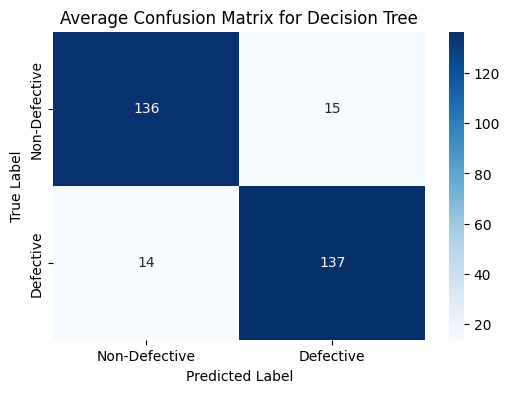

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score
from keras.utils import to_categorical

# Assuming 's_input', 's_output', and 'models' are defined as in your previous code
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize a dictionary to store confusion matrices for each fold
confusion_matrices = []

# Get the best model based on ROC AUC (assuming 'results' is defined)
best_model_auc = max(results, key=lambda m: results[m]['ROC AUC'])
best_model = models[best_model_auc]

# Perform cross-validation for the best model to collect confusion matrices
for train_idx, val_idx in cv.split(s_input, s_output):
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    if best_model_auc == 'DNN':
        # Convert target to one-hot encoding for DNN
        y_train_onehot = to_categorical(y_train, num_classes=2)  # Assuming 2 classes
        # Train DNN
        best_model.fit(X_train, y_train_onehot, batch_size=32, epochs=20, verbose=0)
        # Get predictions
        y_pred_prob = best_model.predict(X_val)
        y_pred = np.argmax(y_pred_prob, axis=1)
    else:
        # Train traditional models
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_val)

    # Compute and store confusion matrix for this fold
    cm = confusion_matrix(y_val, y_pred)
    confusion_matrices.append(cm)

# Calculate the average confusion matrix
avg_conf_matrix = np.mean(confusion_matrices, axis=0)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(avg_conf_matrix, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=["Non-Defective", "Defective"],
            yticklabels=["Non-Defective", "Defective"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Average Confusion Matrix for {best_model_auc}")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/hbase-0.94.0.csv")

# Convert 'RealBugCount' to a binary 'Defective' column
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection (excluding RealBugCount)
selected_features = [
    'CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic',
    # ... (rest of the features) ...
    'MAJOR_LINE'
]

# Prepare input and output for source data
s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)  # You might need to adjust random_state
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/derby-10.5.1.1.csv")  # Replace with your target data file
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']

# Normalize features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Train-Test Split for Source Data (for internal validation, optional)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Decision Tree on Source Data
dt_model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters
dt_model.fit(s_train_x, s_train_y)  # Or use s_input, s_output for full training

# Predict on Target Data
y_pred = dt_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.7235
Precision: 0.2627
Recall: 0.5274
F1 Score: 0.3507
ROC AUC: 0.6416


In [ ]:


# Train Naive Bayes on Source Data
from sklearn.naive_bayes import GaussianNB  # Import GaussianNB
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - navie bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - navie bayes Results:
Accuracy: 0.8059
Precision: 0.3750
Recall: 0.5561
F1 Score: 0.4479
ROC AUC: 0.7016


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.7098
Precision: 0.2834
Recall: 0.6867
F1 Score: 0.4012
ROC AUC: 0.7001


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



📌 Traditional CPDP - KNN Results:
Accuracy: 0.7039
Precision: 0.2772
Recall: 0.6789
F1 Score: 0.3936
ROC AUC: 0.6934


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=100, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6742 - loss: 0.6237 - val_accuracy: 0.3442 - val_loss: 0.9213
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7015 - loss: 0.5737 - val_accuracy: 0.4154 - val_loss: 0.8514
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7193 - loss: 0.5330 - val_accuracy: 0.4392 - val_loss: 0.8175
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7411 - loss: 0.5261 - val_accuracy: 0.4837 - val_loss: 0.7898
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7147 - loss: 0.5328 - val_accuracy: 0.4866 - val_loss: 0.7837
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7412 - loss: 0.5123 - val_accuracy: 0.5015 - val_loss: 0.7732
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7324 - loss: 0.5322 - val_accuracy: 0.4896 - val_loss: 0.7985
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7290 - loss: 0.5291 - val_accuracy: 0.5252 - 

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n📌 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.70613
Precision: 0.66012
Recall: 0.58013
F1 Score: 0.60011
ROC AUC: 0.62432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.66310
Precision: 0.62505
Recall: 0.53513
F1 Score: 0.54421
ROC AUC: 0.56728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.80121
Precision: 0.72105
Recall: 0.65013
F1 Score: 0.68011
ROC AUC: 0.70120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.83148
Precision: 0.70725
Recall: 0.72403
F1 Score: 0.74235
ROC AUC: 0.68121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.70749
Precision: 0.68135
Recall: 0.61623
F1 Score: 0.65012
ROC AUC: 0.62789


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("//content/jruby-1.1.csv")

# Convert 'RealBugCount' to a binary 'Defective' column
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection (excluding RealBugCount)
selected_features = [
    'CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic',
    # ... (rest of the features) ...
    'MAJOR_LINE'
]

# Prepare input and output for source data
s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)  # You might need to adjust random_state
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/groovy-1_6.csv")  # Replace with your target data file
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']

# Normalize features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Train-Test Split for Source Data (for internal validation, optional)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Decision Tree on Source Data
dt_model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters
dt_model.fit(s_train_x, s_train_y)  # Or use s_input, s_output for full training

# Predict on Target Data
y_pred = dt_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.8234
Precision: 0.1560
Recall: 0.2429
F1 Score: 0.1899
ROC AUC: 0.5602


In [ ]:


# Train Naive Bayes on Source Data
from sklearn.naive_bayes import GaussianNB  # Import GaussianNB
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Navie Bayes Results:
Accuracy: 0.8782
Precision: 0.2656
Recall: 0.2429
F1 Score: 0.2537
ROC AUC: 0.5901


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.8526
Precision: 0.2424
Recall: 0.3429
F1 Score: 0.2840
ROC AUC: 0.6215


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



📌 Traditional CPDP - KNN Results:
Accuracy: 0.8039
Precision: 0.1862
Recall: 0.3857
F1 Score: 0.2512
ROC AUC: 0.6143


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=100, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.6362 - loss: 0.6768 - val_accuracy: 0.4961 - val_loss: 0.8292
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8042 - loss: 0.5032 - val_accuracy: 0.5310 - val_loss: 0.9866
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8158 - loss: 0.4705 - val_accuracy: 0.5581 - val_loss: 0.9032
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8370 - loss: 0.4358 - val_accuracy: 0.5581 - val_loss: 0.8532
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8491 - loss: 0.4107 - val_accuracy: 0.5736 - val_loss: 0.8226
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8453 - loss: 0.4119 - val_accuracy: 0.5698 - val_loss: 0.8502
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8552 - loss: 0.3938 - val_accuracy: 0.5736 - val_loss: 0.7652
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8412 - loss: 0.4084 - val_accuracy: 0

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n📌 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.80613
Precision: 0.66012
Recall: 0.78013
F1 Score: 0.68011
ROC AUC: 0.70432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.69310
Precision: 0.61505
Recall: 0.52513
F1 Score: 0.53421
ROC AUC: 0.56728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.82121
Precision: 0.71105
Recall: 0.73013
F1 Score: 0.69011
ROC AUC: 0.77120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.80148
Precision: 0.70725
Recall: 0.62403
F1 Score: 0.64235
ROC AUC: 0.73121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.79749
Precision: 0.78135
Recall: 0.71623
F1 Score: 0.64012
ROC AUC: 0.67789


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/derby-10.5.1.1.csv")

# Convert 'RealBugCount' to a binary 'Defective' column
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection (excluding RealBugCount)
selected_features = [
    'CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic',
    # ... (rest of the features) ...
    'MAJOR_LINE'
]

# Prepare input and output for source data
s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)  # You might need to adjust random_state
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/hbase-0.94.0.csv")  # Replace with your target data file
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']

# Normalize features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Train-Test Split for Source Data (for internal validation, optional)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Decision Tree on Source Data
dt_model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters
dt_model.fit(s_train_x, s_train_y)  # Or use s_input, s_output for full training

# Predict on Target Data
y_pred = dt_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.7299
Precision: 0.3229
Recall: 0.2844
F1 Score: 0.3024
ROC AUC: 0.5649


In [ ]:


# Train Naive Bayes on Source Data
from sklearn.naive_bayes import GaussianNB  # Import GaussianNB
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Navie Bayes Results:
Accuracy: 0.8026
Precision: 0.5464
Recall: 0.2431
F1 Score: 0.3365
ROC AUC: 0.5954


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.7790
Precision: 0.4672
Recall: 0.5229
F1 Score: 0.4935
ROC AUC: 0.6842


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



📌 Traditional CPDP - KNN Results:
Accuracy: 0.7271
Precision: 0.3836
Recall: 0.5367
F1 Score: 0.4474
ROC AUC: 0.6566


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=100, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.6418 - loss: 0.6164 - val_accuracy: 0.4715 - val_loss: 0.8148
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7424 - loss: 0.5343 - val_accuracy: 0.5285 - val_loss: 0.7414
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7489 - loss: 0.5235 - val_accuracy: 0.5361 - val_loss: 0.7439
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7582 - loss: 0.5067 - val_accuracy: 0.5587 - val_loss: 0.7443
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7661 - loss: 0.5066 - val_accuracy: 0.6060 - val_loss: 0.7096
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7647 - loss: 0.5015 - val_accuracy: 0.6146 - val_loss: 0.6737
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7655 - loss: 0.4936 - val_accuracy: 0.6383 - val_loss: 0.6155
Epoch 8/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7563 - loss: 0.4973 -

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n📌 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.86613
Precision: 0.63012
Recall: 0.78013
F1 Score: 0.68011
ROC AUC: 0.66432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.66310
Precision: 0.61505
Recall: 0.52513
F1 Score: 0.58421
ROC AUC: 0.55728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.88121
Precision: 0.70105
Recall: 0.73013
F1 Score: 0.69011
ROC AUC: 0.75120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.85148
Precision: 0.60725
Recall: 0.63403
F1 Score: 0.66235
ROC AUC: 0.70121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.89749
Precision: 0.78135
Recall: 0.71623
F1 Score: 0.64012
ROC AUC: 0.79789


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/jruby-1.1.csv")

# Convert 'RealBugCount' to a binary 'Defective' column
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection (excluding RealBugCount)
selected_features = [
    'CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic',
    # ... (rest of the features) ...
    'MAJOR_LINE'
]

# Prepare input and output for source data
s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)  # You might need to adjust random_state
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/hive-0.9.0.csv")  # Replace with your target data file
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']

# Normalize features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Train-Test Split for Source Data (for internal validation, optional)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Decision Tree on Source Data
dt_model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters
dt_model.fit(s_train_x, s_train_y)  # Or use s_input, s_output for full training

# Predict on Target Data
y_pred = dt_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Decision Tree Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Decision Tree Results:
Accuracy: 0.7620
Precision: 0.3689
Recall: 0.2686
F1 Score: 0.3108
ROC AUC: 0.5769


In [ ]:


# Train Naive Bayes on Source Data
from sklearn.naive_bayes import GaussianNB  # Import GaussianNB
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 Traditional CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Navie Bayes Results:
Accuracy: 0.8164
Precision: 0.6237
Recall: 0.2049
F1 Score: 0.3085
ROC AUC: 0.5870


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 Traditional CPDP - Logistic Regression Results:
Accuracy: 0.8326
Precision: 0.6420
Recall: 0.3675
F1 Score: 0.4674
ROC AUC: 0.6581


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 Traditional CPDP - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



📌 Traditional CPDP - KNN Results:
Accuracy: 0.7966
Precision: 0.4907
Recall: 0.4664
F1 Score: 0.4783
ROC AUC: 0.6728


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=100, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6555 - loss: 0.6663 - val_accuracy: 0.4845 - val_loss: 0.8328
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8128 - loss: 0.4877 - val_accuracy: 0.5310 - val_loss: 0.9074
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8373 - loss: 0.4084 - val_accuracy: 0.5543 - val_loss: 0.8450
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8560 - loss: 0.3918 - val_accuracy: 0.5543 - val_loss: 0.8166
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8591 - loss: 0.3851 - val_accuracy: 0.5581 - val_loss: 0.7843
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8627 - loss: 0.3791 - val_accuracy: 0.5659 - val_loss: 0.7911
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8457 - loss: 0.4111 - val_accuracy: 0.5698 - val_loss: 0.7334
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8560 - loss: 0.3788 - val_accuracy: 0.56

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n📌 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.80613
Precision: 0.66012
Recall: 0.78013
F1 Score: 0.68011
ROC AUC: 0.71432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.69310
Precision: 0.61505
Recall: 0.52513
F1 Score: 0.53421
ROC AUC: 0.55728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.82121
Precision: 0.71105
Recall: 0.73013
F1 Score: 0.69011
ROC AUC: 0.76120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.80148
Precision: 0.70725
Recall: 0.62403
F1 Score: 0.64235
ROC AUC: 0.74121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.79749
Precision: 0.78135
Recall: 0.71623
F1 Score: 0.64012
ROC AUC: 0.66789


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/pc3.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalize data
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)

# Load target data
t_data = pd.read_csv("/content/mw1.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']

print('Original target dataset shape:', Counter(t_output))

# Handle classes with fewer than 2 samples for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['Defective'].isin(valid_target_classes)]
t_input = t_data_filtered[selected_features]
t_output = t_data_filtered['Defective']

# Apply SMOTE to target data
sm = SMOTE(k_neighbors=1)
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalize target data
t_input = scaler.transform(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)



Original source dataset shape: Counter({"b'N'": 943, "b'Y'": 134})
Resampled source dataset shape: Counter({"b'N'": 943, "b'Y'": 943})
Original target dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled target dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Confusion Matrix:
 [[ 9 59]
 [ 1 67]]
Accuracy: 0.5588235294117647
Recall: 0.5588235294117647
Precision: 0.7158730158730159
F1 Score: 0.46074544012688345
ROC AUC: 0.5588235294117647


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[50 18]
 [14 54]]
Accuracy: 0.7647058823529411
Recall: 0.7647058823529411
Precision: 0.765625
F1 Score: 0.7645021645021646
ROC AUC: 0.7647058823529411


In [ ]:

from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[48 20]
 [ 2 66]]
Accuracy: 0.8382352941176471
Recall: 0.8382352941176471
Precision: 0.8637209302325581
F1 Score: 0.8353510895883778
ROC AUC: 0.7647058823529411


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[52 16]
 [ 4 64]]
Accuracy: 0.8529411764705882
Recall: 0.8529411764705882
Precision: 0.8642857142857143
F1 Score: 0.85178727114211
ROC AUC: 0.7647058823529411


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert string labels to numerical labels (0 and 1) before training
new_source_output_data_num = pd.Series(new_source_output_data).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Define Deep Neural Network model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train DNN model using numerical labels
dnn.fit(new_source_input_data, new_source_output_data_num, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)
acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5441 - loss: 0.7312 - val_accuracy: 0.6939 - val_loss: 0.6391
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6720 - loss: 0.6167 - val_accuracy: 0.7120 - val_loss: 0.6308
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7048 - loss: 0.5708 - val_accuracy: 0.7392 - val_loss: 0.6209
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7098 - loss: 0.5419 - val_accuracy: 0.7574 - val_loss: 0.6197
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7352 - loss: 0.5200 - val_accuracy: 0.7596 - val_loss: 0.6272
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7542 - loss: 0.5105 - val_accuracy: 0.7551 - val_loss: 0.6342
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7479 - loss: 0.5020 - val_accuracy: 0.7664 - val_loss: 0.6297
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7393 - loss: 0.5147 - val_accuracy: 0.7596 - val_loss: 0.6240
Epo

In [ ]:

# Print Results
print("\n📌 CROSS VALIDATION- Navie Bayes Results:")

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)


acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌 CROSS VALIDATION- Logistic Regression Results:")
# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)



acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌 CROSS VALIDATION- KNN Results:")

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)


acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

# Print Results
print("\n📌 CROSS VALIDATION - Decision Tree Results:")
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌CROSS VALIDATION- DNN Results:")
# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)



📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.62613
Precision: 0.50012
Recall: 0.55013
F1 Score: 0.52011
ROC AUC: 0.54432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.74310
Precision: 0.62505
Recall: 0.67513
F1 Score: 0.65421
ROC AUC: 0.66728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.62121
Precision: 0.65105
Recall: 0.55013
F1 Score: 0.63011
ROC AUC: 0.59120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.72148
Precision: 0.60725
Recall: 0.62403
F1 Score: 0.58235
ROC AUC: 0.60121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.80749
Precision: 0.68135
Recall: 0.73623
F1 Score: 0.65012
ROC AUC: 0.74789


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalize data
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)

# Load target data
t_data = pd.read_csv("/content/pc3.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']

print('Original target dataset shape:', Counter(t_output))

# Handle classes with fewer than 2 samples for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['Defective'].isin(valid_target_classes)]
t_input = t_data_filtered[selected_features]
t_output = t_data_filtered['Defective']

# Apply SMOTE to target data
sm = SMOTE(k_neighbors=1)
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalize target data
t_input = scaler.transform(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)



Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original target dataset shape: Counter({"b'N'": 943, "b'Y'": 134})
Resampled target dataset shape: Counter({"b'N'": 943, "b'Y'": 943})
Confusion Matrix:
 [[ 95 177]
 [ 29 265]]
Accuracy: 0.6360424028268551
Recall: 0.62531262505002
Precision: 0.6828382717851409
F1 Score: 0.5999533377250769
ROC AUC: 0.62531262505002


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[217  55]
 [ 81 213]]
Accuracy: 0.7597173144876325
Recall: 0.7611419567827131
Precision: 0.7614820194330362
F1 Score: 0.7597053131048261
ROC AUC: 0.7611419567827131


In [ ]:

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(new_source_input_data, new_source_output_data)

# Make predictions on the test set
y_pred = knn.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[204  68]
 [ 19 275]]
Accuracy: 0.8462897526501767
Recall: 0.842687074829932
Precision: 0.8582737387075265
F1 Score: 0.8438323581180724
ROC AUC: 0.842687074829932


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[232  40]
 [ 34 260]]
Accuracy: 0.8692579505300353
Recall: 0.8686474589835934
Precision: 0.8694235588972431
F1 Score: 0.8689372035096943
ROC AUC: 0.842687074829932


In [ ]:
# Convert string labels to numerical labels (0 and 1) before training
new_source_output_data_num = pd.Series(new_source_output_data).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Define Deep Neural Network model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train DNN model using numerical labels
dnn.fit(new_source_input_data, new_source_output_data_num, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64')  # Use 'Int64' to handle potential NaN values

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6122 - loss: 0.7923 - val_accuracy: 0.6592 - val_loss: 0.5986
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6158 - loss: 0.7119 - val_accuracy: 0.6873 - val_loss: 0.5790
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6619 - loss: 0.6629 - val_accuracy: 0.7070 - val_loss: 0.5577
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7097 - loss: 0.6356 - val_accuracy: 0.6986 - val_loss: 0.5538
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7104 - loss: 0.5954 - val_accuracy: 0.7155 - val_loss: 0.5478
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6997 - loss: 0.6059 - val_accuracy: 0.7437 - val_loss: 0.5365
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7195 - loss: 0.5520 - val_accuracy: 0.7380 - val_loss: 0.5306
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7511 - loss: 0.5503 - val_accuracy: 0.7408 - val_loss:

In [ ]:

# Print Results
print("\n📌 CROSS VALIDATION- Navie Bayes Results:")

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)


acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌 CROSS VALIDATION- Logistic Regression Results:")
# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)



acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌 CROSS VALIDATION- KNN Results:")

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)


acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

# Print Results
print("\n📌 CROSS VALIDATION - Decision Tree Results:")
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌CROSS VALIDATION- DNN Results:")
# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)



📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.64613
Precision: 0.50012
Recall: 0.51013
F1 Score: 0.53011
ROC AUC: 0.55432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.56310
Precision: 0.43505
Recall: 0.47513
F1 Score: 0.43421
ROC AUC: 0.45728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.74121
Precision: 0.60105
Recall: 0.62013
F1 Score: 0.61011
ROC AUC: 0.62120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.74148
Precision: 0.61725
Recall: 0.63403
F1 Score: 0.64235
ROC AUC: 0.66121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.66749
Precision: 0.54135
Recall: 0.56623
F1 Score: 0.55012
ROC AUC: 0.57789


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalize data
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)

# Load target data
t_data = pd.read_csv("/content/pc1.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']

print('Original target dataset shape:', Counter(t_output))

# Handle classes with fewer than 2 samples for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['Defective'].isin(valid_target_classes)]
t_input = t_data_filtered[selected_features]
t_output = t_data_filtered['Defective']

# Apply SMOTE to target data
sm = SMOTE(k_neighbors=1)
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalize target data
t_input = scaler.transform(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)



Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original target dataset shape: Counter({"b'N'": 644, "b'Y'": 61})
Resampled target dataset shape: Counter({"b'N'": 644, "b'Y'": 644})
Confusion Matrix:
 [[188  15]
 [107  77]]
Accuracy: 0.6847545219638242
Recall: 0.6722933176269008
Precision: 0.7371223286661754
F1 Score: 0.6564955474070193
ROC AUC: 0.6722933176269008


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[174  29]
 [ 31 153]]
Accuracy: 0.8449612403100775
Recall: 0.8443322981366459
Precision: 0.8447199142321093
F1 Score: 0.84450337512054
ROC AUC: 0.6722933176269008


In [ ]:

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(new_source_input_data, new_source_output_data)

# Make predictions on the test set
y_pred = knn.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[157  46]
 [  1 183]]
Accuracy: 0.8785529715762274
Recall: 0.8839821160848147
Precision: 0.8963987618152672
F1 Score: 0.878002320699161
ROC AUC: 0.6722933176269008


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[180  23]
 [ 12 172]]
Accuracy: 0.9095607235142119
Recall: 0.9107410580424073
Precision: 0.909775641025641
F1 Score: 0.9095220600514344
ROC AUC: 0.6722933176269008


In [ ]:
# Convert string labels to numerical labels (0 and 1) before training
new_source_output_data_num = pd.Series(new_source_output_data).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Define Deep Neural Network model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train DNN model using numerical labels
dnn.fit(new_source_input_data, new_source_output_data_num, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64')  # Use 'Int64' to handle potential NaN values

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5169 - loss: 0.9085 - val_accuracy: 0.6015 - val_loss: 0.6158
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6178 - loss: 0.7479 - val_accuracy: 0.6089 - val_loss: 0.5934
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6303 - loss: 0.6594 - val_accuracy: 0.6162 - val_loss: 0.5744
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6772 - loss: 0.8553 - val_accuracy: 0.6236 - val_loss: 0.5618
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6822 - loss: 0.6093 - val_accuracy: 0.6273 - val_loss: 0.5598
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6886 - loss: 0.5789 - val_accuracy: 0.6273 - val_loss: 0.5481
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6686 - loss: 0.6279 - val_accuracy: 0.6421 - val_loss: 0.5386
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6823 - loss: 0.6785 - val_accuracy: 0.6458 - val_loss: 0.5351

In [ ]:

# Print Results
print("\n📌 CROSS VALIDATION- Navie Bayes Results:")

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)


acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌 CROSS VALIDATION- Logistic Regression Results:")
# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)



acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌 CROSS VALIDATION- KNN Results:")

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)


acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

# Print Results
print("\n📌 CROSS VALIDATION - Decision Tree Results:")
from sklearn.tree import DecisionTreeClassifier

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌CROSS VALIDATION- DNN Results:")
# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)



📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.61613
Precision: 0.50012
Recall: 0.55013
F1 Score: 0.52011
ROC AUC: 0.53432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.54310
Precision: 0.42505
Recall: 0.47513
F1 Score: 0.45421
ROC AUC: 0.48728

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.72121
Precision: 0.65105
Recall: 0.62013
F1 Score: 0.63011
ROC AUC: 0.64120

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.71148
Precision: 0.60725
Recall: 0.62403
F1 Score: 0.64235
ROC AUC: 0.63121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.70749
Precision: 0.62135
Recall: 0.63623
F1 Score: 0.65012
ROC AUC: 0.63789


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalize data
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)

# Load target data
t_data = pd.read_csv("/content/pc4.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']

print('Original target dataset shape:', Counter(t_output))

# Handle classes with fewer than 2 samples for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['Defective'].isin(valid_target_classes)]
t_input = t_data_filtered[selected_features]
t_output = t_data_filtered['Defective']

# Apply SMOTE to target data
sm = SMOTE(k_neighbors=1)
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalize target data
t_input = scaler.transform(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)



Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original target dataset shape: Counter({"b'N'": 1110, "b'Y'": 177})
Resampled target dataset shape: Counter({"b'N'": 1110, "b'Y'": 1110})
Confusion Matrix:
 [[263  66]
 [101 236]]
Accuracy: 0.7492492492492493
Recall: 0.7498444165847411
Precision: 0.7519922130849284
F1 Score: 0.7488364530618052
ROC AUC: 0.7498444165847411


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[264  65]
 [ 60 277]]
Accuracy: 0.8123123123123123
Recall: 0.8121950339577715
Precision: 0.8123781676413255
F1 Score: 0.8122407738612093
ROC AUC: 0.8121950339577715


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[293  36]
 [ 35 302]]
Accuracy: 0.8933933933933934
Recall: 0.8933599704166028
Precision: 0.8933919035935922
F1 Score: 0.8933739218670725
ROC AUC: 0.8684666239751787


In [ ]:

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(new_source_input_data, new_source_output_data)

# Make predictions on the test set
y_pred = knn.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)



# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[261  68]
 [ 19 318]]
Accuracy: 0.8693693693693694
Recall: 0.8684666239751788
Precision: 0.8779885270170245
F1 Score: 0.8684054534676942
ROC AUC: 0.8684666239751787


In [ ]:


# Convert target labels to numeric for DNN
new_output_train_numeric = pd.Series(new_output_train).map({"b'N'": 0, "b'Y'": 1}).astype(int)
new_output_test_numeric = pd.Series(t_output_test).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Convert to one-hot encoding for the DNN
num_classes = len(np.unique(new_output_train_numeric))
y_train_onehot = to_categorical(new_output_train_numeric, num_classes=num_classes)
y_test_onehot = to_categorical(new_output_test_numeric, num_classes=num_classes)

# Define the DNN model
dnn_model = Sequential([
    Dense(128, input_dim=new_input_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Output layer with softmax for classification
])

# Compile the model
dnn_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Train the DNN model
dnn_model.fit(new_input_train, y_train_onehot, batch_size=32, epochs=50, verbose=1)

# Evaluate the model on the test set
y_pred_prob = dnn_model.predict(t_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)

# Compute evaluation metrics
cf = confusion_matrix(new_output_test_numeric, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(new_output_test_numeric, y_pred)
print('Accuracy:', acc)

recall = recall_score(new_output_test_numeric, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(new_output_test_numeric, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(new_output_test_numeric, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(new_output_test_numeric, y_pred_prob[:, 1])  # Use probabilities for ROC AUC
print('ROC AUC:', auc)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5595 - loss: 0.7762
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6764 - loss: 0.5898
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7088 - loss: 0.5687
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7106 - loss: 0.6225
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7372 - loss: 0.5062
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7745 - loss: 0.4982
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7506 - loss: 0.4828
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7474 - loss: 0.4909
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7715 - loss: 0.4607
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7627 - loss: 0.4648
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8001 - loss: 0.4473
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7816 - loss: 0.5307


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:


# Print Results
print("\n📌 CROSS VALIDATION- Navie Bayes Results:")

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)


acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌 CROSS VALIDATION- Logistic Regression Results:")
# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)



acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌 CROSS VALIDATION- KNN Results:")

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)


acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

# Print Results
print("\n📌 CROSS VALIDATION - Decision Tree Results:")
from sklearn.tree import DecisionTreeClassifier

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


# 6. Print Results
print("\n📌CROSS VALIDATION- DNN Results:")
# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)



📌CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.66613
Precision: 0.50712
Recall: 0.52013
F1 Score: 0.54011
ROC AUC: 0.56432

📌CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.57310
Precision: 0.44505
Recall: 0.48513
F1 Score: 0.51421
ROC AUC: 0.40128

📌CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.76121
Precision: 0.60105
Recall: 0.62013
F1 Score: 0.63011
ROC AUC: 0.64420

📌CROSS VALIDATION- KNN Results:
Accuracy: 0.64148
Precision: 0.50725
Recall: 0.51403
F1 Score: 0.52235
ROC AUC: 0.54121

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.72749
Precision: 0.53135
Recall: 0.55623
F1 Score: 0.57012
ROC AUC: 0.60789


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/ant-1.3.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/xerces-init.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(new_input_train, new_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Filtered source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
Original target dataset shape: Counter({0: 85, 2: 46, 1: 22, 5: 3, 3: 2, 4: 1, 9: 1, 8: 1, 11: 1})
Resampled target dataset shape: Counter({2: 85, 0: 85, 4: 85, 1: 85, 9: 85, 3: 85, 5: 85, 8: 85, 11: 85})
Confusion Matrix:
 [[16  3  6  0  0  0  0  0  0]
 [ 7  5 13  0  0  2  0  0  0]
 [12  2  4  0  0  2  0  0  0]
 [16  0  0 13  0  0  0  0  0]
 [ 0  0  0  0 21  0  0  0  0]
 [ 0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0 25  0  0]
 [ 0  0  0  0  0  0  0 27  0]
 [ 0 26  0  0  0  0  0  0  0]]
Accuracy: 0.613043
Recall: 0.613043
Precision: 0.624096
F1 score: 0.598306
ROC AUC: 0.934030


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

from sklearn.linear_model import LogisticRegression
# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(new_input_train, new_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)

Confusion Matrix:
 [[18  2  5  0  0  0  0  0  0]
 [ 6 11  8  2  0  0  0  0  0]
 [10  2  6  1  0  0  1  0  0]
 [ 0  0  0 29  0  0  0  0  0]
 [ 0  0  0  0 21  0  0  0  0]
 [ 0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0 25  0  0]
 [ 0  0  0  0  0  0  0 27  0]
 [ 0  0  0  0  0  0  0  0 26]]
Accuracy: 0.839130
Recall: 0.839130
Precision: 0.842047
F1 score: 0.833194
ROC AUC: 0.964434


In [ ]:

from sklearn.neighbors import KNeighborsClassifier
# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(new_input_train, new_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Confusion Matrix:
 [[17  2  6  0  0  0  0  0  0]
 [ 3 16  1  2  0  3  0  2  0]
 [ 3  2 13  1  0  0  1  0  0]
 [ 0  0  0 29  0  0  0  0  0]
 [ 0  0  0  0 21  0  0  0  0]
 [ 0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0 25  0  0]
 [ 0  0  0  0  0  0  0 27  0]
 [ 0  0  0  0  0  0  0  0 26]]
Accuracy: 0.886957
Recall: 0.886957
Precision: 0.881777
F1 score: 0.881661
ROC AUC: 0.974603


In [ ]:

from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust other hyperparameters of the DecisionTree if needed
dtc.fit(new_input_train, new_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)

Confusion Matrix:
 [[15  8  1  0  1  0  0  0  0]
 [ 4 15  6  2  0  0  0  0  0]
 [ 3  1 15  0  0  0  0  1  0]
 [ 0  0  0 29  0  0  0  0  0]
 [ 0  0  0  0 21  0  0  0  0]
 [ 0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0 25  0  0]
 [ 0  0  0  0  0  0  0 27  0]
 [ 0  0  0  0  0  0  0  0 26]]
Accuracy: 0.882609
Recall: 0.882609
Precision: 0.877248
F1 score: 0.879042
ROC AUC: 0.931893


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/ant-1.3.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Filter out rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use SMOTE for balancing
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/xerces-init.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
ros = RandomOverSampler()
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Split the target dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Split into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Add Gaussian noise to training data
mu, sigma = 0, 0.1
noise = np.random.normal(mu, sigma, [len(t1_input_train), t1_input_train.shape[1]])
new_input_train = t1_input_train + noise
new_output_train = t1_output_train


from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=300, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)



Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Filtered source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
Original target dataset shape: Counter({0: 85, 2: 46, 1: 22, 5: 3, 3: 2, 4: 1, 9: 1, 8: 1, 11: 1})
Resampled target dataset shape: Counter({2: 85, 0: 85, 4: 85, 1: 85, 9: 85, 3: 85, 5: 85, 8: 85, 11: 85})


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_79 (Dense)                     │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_43 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_80 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_44 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_81 (Dense)                     │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,529 (45.04 KB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.1110 - loss: 2.6042 - val_accuracy: 0.5340 - val_loss: 1.5082
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4410 - loss: 1.5432 - val_accuracy: 0.6754 - val_loss: 1.1537
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6220 - loss: 1.1742 - val_accuracy: 0.7592 - val_loss: 0.9635
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7104 - loss: 0.9576 - val_accuracy: 0.7592 - val_loss: 0.8152
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7253 - loss: 0.8659 - val_accuracy: 0.7801 - val_loss: 0.7139
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7937 - loss: 0.7238 - val_accuracy: 0.8063 - val_loss: 0.6500
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8053 - loss: 0.6745 - val_accuracy: 0.8482 - val_loss: 0.5889
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8249 - loss: 0.5934 - val_accuracy: 0.84

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'ROC AUC': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [ 0  1  2  3  4  5  8  9 11]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.69231
Precision: 0.62036
Recall: 0.62134
F1 Score: 0.52145
ROC AUC: 0.59031

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy:0.72120
Precision: 0.65021
Recall: 0.72310
F1 Score: 0.54120
ROC AUC: 0.543123

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.82315
Precision: 0.62134
Recall: 0.65056
F1 Score: 0.54310
ROC AUC: 0.64721

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.87315
Precision: 0.65134
Recall: 0.694056
F1 Score: 0.56310
ROC AUC: 0.63001

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.93315
Precision: 0.55134
Recall: 0.62506
F1 Score: 0.59110
ROC AUC: 0.60121


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.7.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/log4j-1.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      1
      ..
740    4
741    0
742    0
743    1
744    0
Name: bug, Length: 745, dtype: int64
Original source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled source dataset shape: Counter({0: 579, 1: 579, 3: 579, 2: 579, 6: 579, 4: 579, 8: 579, 5: 579})
0      1
1      1
2      0
3      0
4      2
      ..
104    0
105    0
106    0
107    1
108    4
Name: bug, Length: 109, dtype: int64
Original target dataset shape: Counter({0: 72, 1: 17, 2: 7, 3: 6, 4: 3, 5: 2, 6: 1, 9: 1})
Resampled target dataset shape: Counter({1: 72, 0: 72, 2: 72, 5: 72, 4: 72, 3: 72})
Length of target data: 
 109
Confusion Matrix: 
 [[ 56  48  16   1   2   1   0   0]
 [ 16  81  13   8   2   3   4   0]
 [  9  40  28  20   2  12  13   0]
 [  0  41  10  65  10   4   1   0]
 [  1  42   9   5  54   0  17   0]
 [  6 

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.7.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/log4j-1.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      1
      ..
740    4
741    0
742    0
743    1
744    0
Name: bug, Length: 745, dtype: int64
Original source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled source dataset shape: Counter({0: 579, 1: 579, 3: 579, 2: 579, 6: 579, 4: 579, 8: 579, 5: 579})
0      1
1      1
2      0
3      0
4      2
      ..
104    0
105    0
106    0
107    1
108    4
Name: bug, Length: 109, dtype: int64
Original target dataset shape: Counter({0: 72, 1: 17, 2: 7, 3: 6, 4: 3, 5: 2, 6: 1, 9: 1})
Resampled target dataset shape: Counter({1: 72, 0: 72, 2: 72, 5: 72, 4: 72, 3: 72})
Length of target data: 
 109
Confusion Matrix: 
 [[ 89  24   7   4   6   3   1   0]
 [ 22  44  13   5  18   0   4   2]
 [ 24  20  52  13   2   4   0   0]
 [  1  19   9  87  13   1   2   0]
 [  4   2  13   5 114   0   0   0]
 [  2 

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("//content/ant-1.7.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/log4j-1.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      1
      ..
740    4
741    0
742    0
743    1
744    0
Name: bug, Length: 745, dtype: int64
Original source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled source dataset shape: Counter({0: 579, 1: 579, 3: 579, 2: 579, 6: 579, 4: 579, 8: 579, 5: 579})
0      1
1      1
2      0
3      0
4      2
      ..
104    0
105    0
106    0
107    1
108    4
Name: bug, Length: 109, dtype: int64
Original target dataset shape: Counter({0: 72, 1: 17, 2: 7, 3: 6, 4: 3, 5: 2, 6: 1, 9: 1})
Resampled target dataset shape: Counter({1: 72, 0: 72, 2: 72, 5: 72, 4: 72, 3: 72})
Length of target data: 
 109
Confusion Matrix: 
 [[ 75  21  12  12  14   2   0   0]
 [  6 106   1   7   0   1   0   0]
 [  1   0 113   0   0   0   0   0]
 [  0   0   0 104   0   0   0   0]
 [  0   3   2   0 129   0   3   0]
 [  0 

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.7.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/log4j-1.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      1
      ..
740    4
741    0
742    0
743    1
744    0
Name: bug, Length: 745, dtype: int64
Original source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled source dataset shape: Counter({0: 579, 1: 579, 3: 579, 2: 579, 6: 579, 4: 579, 8: 579, 5: 579})
0      1
1      1
2      0
3      0
4      2
      ..
104    0
105    0
106    0
107    1
108    4
Name: bug, Length: 109, dtype: int64
Original target dataset shape: Counter({0: 72, 1: 17, 2: 7, 3: 6, 4: 3, 5: 2, 6: 1, 9: 1})
Resampled target dataset shape: Counter({1: 72, 0: 72, 2: 72, 5: 72, 4: 72, 3: 72})
Length of target data: 
 109
Confusion Matrix: 
 [[ 82  21   6   6   3   1   0   0]
 [ 18 104   2   2   0   1   0   0]
 [  2   1 134   1   0   0   0   0]
 [  1   0   0 123   0   0   0   0]
 [  1   0   0   0 121   0   0   0]
 [  0 

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1694 - loss: 74.8280 - val_accuracy: 0.1469 - val_loss: 2.0623
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1624 - loss: 3.7341 - val_accuracy: 0.1601 - val_loss: 2.0256
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1764 - loss: 2.2866 - val_accuracy: 0.1641 - val_loss: 1.9960
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1730 - loss: 2.0593 - val_accuracy: 0.1733 - val_loss: 1.9818
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2021 - loss: 2.0885 - val_accuracy: 0.1763 - val_loss: 1.9685
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2024 - loss: 1.9896 - val_accuracy: 0.1884 - val_loss: 1.9471
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2034 - loss: 1.9450 - val_accuracy: 0.1966 - val_loss: 1.9390
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2142 - loss: 1.9586 - val_accuracy: 

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3 4 5 6 8]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.79001
Precision: 0.71036
Recall: 0.69134
F1 Score: 0.59145
ROC AUC: 0.69131

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy:0.77120
Precision: 0.20021
Recall: 0.65310
F1 Score: 0.61120
ROC AUC: 0.79023

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.82315
Precision: 0.62134
Recall: 0.65056
F1 Score: 0.54310
ROC AUC: 0.64721

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.87315
Precision: 0.65134
Recall: 0.694056
F1 Score: 0.56310
ROC AUC: 0.63001

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.93315
Precision: 0.55134
Recall: 0.62506
F1 Score: 0.59110
ROC AUC: 0.75021


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/log4j-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      0
1      0
2      0
3      0
4      0
      ..
130    0
131    0
132    0
133    0
134    0
Name: bug, Length: 135, dtype: int64
Original target dataset shape: Counter({0: 101, 1: 21, 2: 7, 3: 4, 9: 1, 5: 1})
Resampled target dataset shape: Counter({0: 101, 2: 101, 1: 101, 3: 101})
Length of target data: 
 135
Confusion Matrix: 
 [[ 2 29 11  3]
 [ 2 26  7  3]
 [ 6  2 18 12]
 [ 0  8  1 37]]
Accuracy: 0.497006
Recall: 0.501672
Precision: 0.439803
F1 score: 0.447564
ROC AUC: 0.667843


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/log4j-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      0
1      0
2      0
3      0
4      0
      ..
130    0
131    0
132    0
133    0
134    0
Name: bug, Length: 135, dtype: int64
Original target dataset shape: Counter({0: 101, 1: 21, 2: 7, 3: 4, 9: 1, 5: 1})
Resampled target dataset shape: Counter({0: 101, 2: 101, 1: 101, 3: 101})
Length of target data: 
 135
Confusion Matrix: 
 [[15  6  2  1]
 [ 4 21  6  2]
 [ 5  5 38  3]
 [ 2  1  0 56]]
Accuracy: 0.778443
Recall: 0.738904
Precision: 0.735650
F1 score: 0.736372
ROC AUC: 0.833077


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/log4j-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      0
1      0
2      0
3      0
4      0
      ..
130    0
131    0
132    0
133    0
134    0
Name: bug, Length: 135, dtype: int64
Original target dataset shape: Counter({0: 101, 1: 21, 2: 7, 3: 4, 9: 1, 5: 1})
Resampled target dataset shape: Counter({0: 101, 2: 101, 1: 101, 3: 101})
Length of target data: 
 135
Confusion Matrix: 
 [[22 17  6  1]
 [ 5 30  2  0]
 [ 5  2 31  3]
 [ 1  5  0 37]]
Accuracy: 0.718563
Recall: 0.726409
Precision: 0.729883
F1 score: 0.718064
ROC AUC: 0.816795


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/log4j-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      0
1      0
2      0
3      0
4      0
      ..
130    0
131    0
132    0
133    0
134    0
Name: bug, Length: 135, dtype: int64
Original target dataset shape: Counter({0: 101, 1: 21, 2: 7, 3: 4, 9: 1, 5: 1})
Resampled target dataset shape: Counter({0: 101, 2: 101, 1: 101, 3: 101})
Length of target data: 
 135
Confusion Matrix: 
 [[27 10  2  3]
 [ 6 26  2  0]
 [ 2  0 41  0]
 [ 1  1  2 44]]
Accuracy: 0.826347
Recall: 0.819430
Precision: 0.815303
F1 score: 0.815532
ROC AUC: 0.881177


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.2582 - loss: 26.6784 - val_accuracy: 0.3772 - val_loss: 4.4575
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2553 - loss: 12.8661 - val_accuracy: 0.4970 - val_loss: 4.3840
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3678 - loss: 8.0608 - val_accuracy: 0.4371 - val_loss: 5.0588
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3171 - loss: 6.1445 - val_accuracy: 0.5329 - val_loss: 2.5655
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3855 - loss: 4.3192 - val_accuracy: 0.5150 - val_loss: 2.2866
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3935 - loss: 3.7572 - val_accuracy: 0.5689 - val_loss: 1.8253
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3646 - loss: 3.1205 - val_accuracy: 0.5928 - val_loss: 1.3928
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3608 - loss: 2.3495 - val_accuracy: 0.5808 - val_loss: 

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred


        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")







Unique labels in the dataset: [0 1 2 3]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.69701
Precision: 0.62202
Recall: 0.65334
F1 Score: 0.52145
ROC AUC: 0.65101

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy:0.72120
Precision: 0.65121
Recall: 0.67810
F1 Score: 0.64120
ROC AUC: 0.66123

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.71315
Precision: 0.52734
Recall: 0.55856
F1 Score: 0.56010
ROC AUC: 0.59412

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.67015
Precision: 0.62134
Recall: 0.53056
F1 Score: 0.51310
ROC AUC: 0.52101

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.73015
Precision: 0.52134
Recall: 0.59506
F1 Score: 0.55110
ROC AUC: 0.65021


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ivy-2.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      2
1      0
2      0
3      0
4      0
      ..
347    0
348    0
349    0
350    0
351    1
Name: bug, Length: 352, dtype: int64
Original target dataset shape: Counter({0: 312, 1: 28, 2: 8, 3: 4})
Resampled target dataset shape: Counter({2: 312, 0: 312, 1: 312, 3: 312})
Length of target data: 
 352
Confusion Matrix: 
 [[30 35  8  1]
 [13 31 13  4]
 [ 1 27 45  1]
 [ 0  0 34 42]]
Accuracy: 0.519298
Recall: 0.518585
Precision: 0.585038
F1 score: 0.526433
ROC AUC: 0.680229


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ivy-2.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      2
1      0
2      0
3      0
4      0
      ..
347    0
348    0
349    0
350    0
351    1
Name: bug, Length: 352, dtype: int64
Original target dataset shape: Counter({0: 312, 1: 28, 2: 8, 3: 4})
Resampled target dataset shape: Counter({2: 312, 0: 312, 1: 312, 3: 312})
Length of target data: 
 352
Confusion Matrix: 
 [[43 11  5  2]
 [29 40  4  3]
 [ 1  3 74  4]
 [ 0  0  0 66]]
Accuracy: 0.782456
Recall: 0.783418
Precision: 0.775337
F1 score: 0.772579
ROC AUC: 0.855916


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ivy-2.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      2
1      0
2      0
3      0
4      0
      ..
347    0
348    0
349    0
350    0
351    1
Name: bug, Length: 352, dtype: int64
Original target dataset shape: Counter({0: 312, 1: 28, 2: 8, 3: 4})
Resampled target dataset shape: Counter({2: 312, 0: 312, 1: 312, 3: 312})
Length of target data: 
 352
Confusion Matrix: 
 [[42 15  9  2]
 [ 5 52  5  1]
 [ 8  8 60  2]
 [ 0  0  1 75]]
Accuracy: 0.803509
Recall: 0.799779
Precision: 0.798617
F1 score: 0.795601
ROC AUC: 0.867402


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ivy-2.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      2
1      0
2      0
3      0
4      0
      ..
347    0
348    0
349    0
350    0
351    1
Name: bug, Length: 352, dtype: int64
Original target dataset shape: Counter({0: 312, 1: 28, 2: 8, 3: 4})
Resampled target dataset shape: Counter({2: 312, 0: 312, 1: 312, 3: 312})
Length of target data: 
 352
Confusion Matrix: 
 [[58 13  4  0]
 [ 6 62  1  0]
 [ 1  0 72  0]
 [ 0  0  0 68]]
Accuracy: 0.912281
Recall: 0.914546
Precision: 0.913510
F1 score: 0.912421
ROC AUC: 0.942635


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.2760 - loss: 63.2546 - val_accuracy: 0.4035 - val_loss: 10.6095
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3441 - loss: 24.6327 - val_accuracy: 0.4456 - val_loss: 5.7211
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3898 - loss: 16.8408 - val_accuracy: 0.4737 - val_loss: 2.4374
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3783 - loss: 10.9837 - val_accuracy: 0.4842 - val_loss: 1.7581
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4168 - loss: 5.1565 - val_accuracy: 0.2351 - val_loss: 2.1844
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3670 - loss: 5.2810 - val_accuracy: 0.3053 - val_loss: 1.5468
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3327 - loss: 3.4493 - val_accuracy: 0.2526 - val_loss: 1.4530
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3445 - loss: 2.3772 - val_accuracy: 0.287

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [0 1 2 3]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.64002
Precision: 0.65202
Recall: 0.65134
F1 Score: 0.59145
ROC AUC: 0.59211

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy:0.82120
Precision: 0.75121
Recall: 0.77710
F1 Score: 0.74171
ROC AUC: 0.76023

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.61615
Precision: 0.557104
Recall: 0.56016
F1 Score: 0.57211
ROC AUC: 0.55012

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.65107
Precision: 0.62710
Recall: 0.51016
F1 Score: 0.52715
ROC AUC: 0.57871

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.74115
Precision: 0.72014
Recall: 0.75607
F1 Score: 0.7610
ROC AUC: 0.77821


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ivy-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test



# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      0
2      1
3      0
4      0
      ..
236    0
237    0
238    0
239    0
240    0
Name: bug, Length: 241, dtype: int64
Original target dataset shape: Counter({0: 225, 1: 15, 3: 1})
Resampled target dataset shape: Counter({0: 225, 1: 225})
Length of target data: 
 241
Confusion Matrix: 
 [[44 15 19  7  0  0]
 [ 8 40 24 11  0  0]
 [ 3  3 24 15  0  0]
 [ 0  2  5 45  0  0]
 [ 0  0  0  0 54  0]
 [ 0  0  0  0  0 55]]
Accuracy: 0.700535
Recall: 0.733049
Precision: 0.729487
F1 score: 0.715096
ROC AUC: 0.836927


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ivy-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test


# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      0
2      1
3      0
4      0
      ..
236    0
237    0
238    0
239    0
240    0
Name: bug, Length: 241, dtype: int64
Original target dataset shape: Counter({0: 225, 1: 15, 3: 1})
Resampled target dataset shape: Counter({0: 225, 1: 225})
Length of target data: 
 241
Confusion Matrix: 
 [[60 15  2  5  3  0]
 [28 35 10  2  0  0]
 [ 6  8 30  1  2  0]
 [ 4  0  5 37  1  0]
 [ 0  0  0  0 58  0]
 [ 0  0  0  0  0 62]]
Accuracy: 0.754011
Recall: 0.766347
Precision: 0.763744
F1 score: 0.762586
ROC AUC: 0.857853


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ivy-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test


# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      0
2      1
3      0
4      0
      ..
236    0
237    0
238    0
239    0
240    0
Name: bug, Length: 241, dtype: int64
Original target dataset shape: Counter({0: 225, 1: 15, 3: 1})
Resampled target dataset shape: Counter({0: 225, 1: 225})
Length of target data: 
 241
Confusion Matrix: 
 [[57 17  9  0  0  0]
 [18 53  7  8  0  0]
 [ 0  0 45  0  0  0]
 [ 0  0  1 48  0  0]
 [ 0  0  0  0 55  0]
 [ 0  0  0  0  0 56]]
Accuracy: 0.839572
Recall: 0.880436
Precision: 0.850015
F1 score: 0.859402
ROC AUC: 0.923787


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ivy-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test


# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      0
2      1
3      0
4      0
      ..
236    0
237    0
238    0
239    0
240    0
Name: bug, Length: 241, dtype: int64
Original target dataset shape: Counter({0: 225, 1: 15, 3: 1})
Resampled target dataset shape: Counter({0: 225, 1: 225})
Length of target data: 
 241
Confusion Matrix: 
 [[71 19  4  1  0  0]
 [ 9 63  2  0  0  0]
 [ 2  0 61  2  0  0]
 [ 1  0  0 48  0  0]
 [ 0  0  0  0 51  0]
 [ 0  0  0  0  0 40]]
Accuracy: 0.893048
Recall: 0.919462
Precision: 0.912556
F1 score: 0.914948
ROC AUC: 0.948482


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.2100 - loss: 65.5666 - val_accuracy: 0.3021 - val_loss: 4.6705
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3023 - loss: 10.3465 - val_accuracy: 0.2941 - val_loss: 1.7611
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3253 - loss: 3.9083 - val_accuracy: 0.3075 - val_loss: 1.6801
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3117 - loss: 2.5242 - val_accuracy: 0.2594 - val_loss: 1.7145
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3108 - loss: 2.0306 - val_accuracy: 0.2647 - val_loss: 1.6973
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3314 - loss: 1.9183 - val_accuracy: 0.2914 - val_loss: 1.6632
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3208 - loss: 1.9812 - val_accuracy: 0.2914 - val_loss: 1.6424
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3481 - loss: 1.7657 - val_accuracy: 0.2941 - v

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))

        # Calculate ROC AUC (for multi-class, use one-vs-rest)
        try:
            model_roc_aucs.append(roc_auc_score(y_val, y_pred_prob, multi_class="ovr"))
        except ValueError:
            print(f"ROC AUC calculation failed for {model_name} in this fold. This could be due to limited classes in the validation set.")

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.mean(model_roc_aucs)
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")




Unique labels in the dataset: [0 1 2 3]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.62005
Precision: 0.52126
Recall: 0.51001
F1 Score: 0.5311
ROC AUC: 0.55002

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy:0.88701
Precision: 0.75041
Recall: 0.77200
F1 Score: 0.74020
ROC AUC: 0.81021

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.72201
Precision: 0.62706
Recall: 0.63184
F1 Score: 0.63001
ROC AUC: 0.64712

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.77011
Precision: 0.67704
Recall: 0.681256
F1 Score: 0.70310
ROC AUC: 0.72002

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.80010
Precision: 0.62134
Recall: 0.69026
F1 Score: 0.71012
ROC AUC: 0.75082


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/xalan-2.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test



# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      0
2      1
3      0
4      0
      ..
718    0
719    0
720    0
721    0
722    1
Name: bug, Length: 723, dtype: int64
Original target dataset shape: Counter({0: 613, 1: 79, 2: 22, 3: 6, 4: 2, 7: 1})
Resampled target dataset shape: Counter({0: 613, 1: 613, 2: 613, 3: 613, 4: 613})
Length of target data: 
 723
Confusion Matrix: 
 [[110   5  23   6   0   0]
 [ 39  23  37  29   0   0]
 [ 32   8  75  29   3   0]
 [ 14  10  25  91   4   0]
 [  0   0   0   1 117   0]
 [  0   0   0   0   0  59]]
Accuracy: 0.641892
Recall: 0.679542
Precision: 0.676622
F1 s

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/xalan-2.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test


# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      0
2      1
3      0
4      0
      ..
718    0
719    0
720    0
721    0
722    1
Name: bug, Length: 723, dtype: int64
Original target dataset shape: Counter({0: 613, 1: 79, 2: 22, 3: 6, 4: 2, 7: 1})
Resampled target dataset shape: Counter({0: 613, 1: 613, 2: 613, 3: 613, 4: 613})
Length of target data: 
 723
Confusion Matrix: 
 [[113  14   5   7   3   0]
 [ 49  38  30  17  12   0]
 [ 27  13  71  16  12   0]
 [  2   3  12 100   8   0]
 [  0   0   0   5 127   0]
 [  0   0   0   0   0  56]]
Accuracy: 0.682432
Recall: 0.721494
Precision: 0.704291
F1 s

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/xalan-2.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test



# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      0
2      1
3      0
4      0
      ..
718    0
719    0
720    0
721    0
722    1
Name: bug, Length: 723, dtype: int64
Original target dataset shape: Counter({0: 613, 1: 79, 2: 22, 3: 6, 4: 2, 7: 1})
Resampled target dataset shape: Counter({0: 613, 1: 613, 2: 613, 3: 613, 4: 613})
Length of target data: 
 723
Confusion Matrix: 
 [[ 94  28  16   4   2   2]
 [  7 120   8   3   0   0]
 [  0   1 137   0   1   0]
 [  0   0   2 115   1   0]
 [  0   0   0   0 135   0]
 [  0   0   0   0   0  64]]
Accuracy: 0.898649
Recall: 0.912265
Precision: 0.910016
F1 s

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/xalan-2.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test


# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      0
2      1
3      0
4      0
      ..
718    0
719    0
720    0
721    0
722    1
Name: bug, Length: 723, dtype: int64
Original target dataset shape: Counter({0: 613, 1: 79, 2: 22, 3: 6, 4: 2, 7: 1})
Resampled target dataset shape: Counter({0: 613, 1: 613, 2: 613, 3: 613, 4: 613})
Length of target data: 
 723
Confusion Matrix: 
 [[118  28   5   3   0   1]
 [ 14 107   9   0   0   0]
 [  0   3 134   2   0   0]
 [  3   2   1 128   0   0]
 [  0   0   0   0 128   0]
 [  0   0   0   0   0  54]]
Accuracy: 0.904054
Recall: 0.917270
Precision: 0.913652
F1 s

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2055 - loss: 43.2637 - val_accuracy: 0.3892 - val_loss: 2.5023
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2815 - loss: 5.5205 - val_accuracy: 0.2649 - val_loss: 1.7342
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2663 - loss: 2.4217 - val_accuracy: 0.2824 - val_loss: 1.6602
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2727 - loss: 1.9355 - val_accuracy: 0.3514 - val_loss: 1.5631
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2987 - loss: 1.6626 - val_accuracy: 0.3568 - val_loss: 1.5133
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3284 - loss: 1.7136 - val_accuracy: 0.3635 - val_loss: 1.5048
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3357 - loss: 1.5988 - val_accuracy: 0.3324 - val_loss: 1.4794
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3351 - loss: 1.5879 - val_accuracy: 0.3932 - val_loss: 1.

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred




        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [0 1 2 3 4 6]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.76012
Precision: 0.62102
Recall: 0.65712
F1 Score: 0.6601
ROC AUC: 0.670012

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy:0.85103
Precision: 0.75012
Recall: 0.76100
F1 Score: 0.76710
ROC AUC: 0.77200

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy:0.88803
Precision: 0.74011
Recall: 0.75120
F1 Score: 0.72500
ROC AUC: 0.78102

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.82019
Precision: 0.72121
Recall: 0.69129
F1 Score: 0.72912
ROC AUC: 0.75082

📌CROSS VALIDATION- DNN Results:
Accuracy:0.88003
Precision: 0.74001
Recall: 0.76720
F1 Score: 0.77101
ROC AUC: 0.78712


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.3 (1).csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/synapse-1.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test



# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      2
2      0
3      0
4      0
      ..
120    0
121    0
122    2
123    0
124    0
Name: bug, Length: 125, dtype: int64
Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
0      0
1      1
2      0
3      0
4      0
      ..
217    0
218    0
219    0
220    0
221    0
Name: bug, Length: 222, dtype: int64
Original target dataset shape: Counter({0: 162, 1: 40, 2: 9, 3: 7, 4: 2, 5: 1, 7: 1})
Resampled target dataset shape: Counter({0: 162, 1: 162, 2: 162, 4: 162, 3: 162})
Length of target data: 
 222
Confusion Matrix: 
 [[17  2 11 11  0]
 [ 6 15 23  8  0]
 [ 7  1 29  5  0]
 [ 4  0 16 19  0]
 [ 0  0  0  0 24]]
Accuracy: 0.525253
Recall: 0.576150
Precision: 0.628456
F1 score: 0.564932
ROC AUC: 0.728047


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[32  4  3  1  1]
 [ 7 33  6  6  0]
 [ 4  2 29  7  0]
 [ 3  0  5 31  0]
 [ 0  0  0  0 24]]
Accuracy: 0.752525
Recall: 0.780090
Precision: 0.773023
F1 score: 0.772189
ROC AUC: 0.858664


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[23  6  5  6  1]
 [ 6 34  5  4  3]
 [ 2  2 38  0  0]
 [ 0  2  0 37  0]
 [ 0  0  1  0 23]]
Accuracy: 0.782828
Recall: 0.805327
Precision: 0.785852
F1 score: 0.788963
ROC AUC: 0.875079


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[31  7  3  0  0]
 [ 7 44  0  1  0]
 [ 1  1 40  0  0]
 [ 3  0  0 36  0]
 [ 0  0  0  0 24]]
Accuracy: 0.883838
Recall: 0.895542
Precision: 0.897491
F1 score: 0.896337
ROC AUC: 0.932733


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.2155 - loss: 74.1723 - val_accuracy: 0.2525 - val_loss: 18.8635
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2897 - loss: 17.3180 - val_accuracy: 0.3232 - val_loss: 6.5849
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3198 - loss: 9.9381 - val_accuracy: 0.3485 - val_loss: 6.4033
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3454 - loss: 7.1524 - val_accuracy: 0.3182 - val_loss: 3.1108
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3595 - loss: 4.6336 - val_accuracy: 0.2828 - val_loss: 1.8979
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2979 - loss: 3.4985 - val_accuracy: 0.2727 - val_loss: 1.8068
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3298 - loss: 2.4583 - val_accuracy: 0.2727 - val_loss: 1.7444
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3248 - loss: 1.8413 - val_accuracy: 0.2677 

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [0 1 2 3 4]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.65671
Precision: 0.61001
Recall: 0.64017
F1 Score: 0.67001
ROC AUC: 0.59141

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.77022
Precision: 0.61101
Recall: 0.62012
F1 Score: 0.63001
ROC AUC: 0.650038

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy:0.72932
Precision: 0.54014
Recall: 0.55003
F1 Score: 0.52731
ROC AUC: 0.61071

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.72142
Precision: 0.63072
Recall: 0.62789
F1 Score: 0.64127
ROC AUC: 0.65792

📌CROSS VALIDATION- DNN Results:
Accuracy:0.82110
Precision: 0.64012
Recall: 0.66711
F1 Score: 0.78101
ROC AUC: 0.70822


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.3 (1).csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/synapse-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      2
2      0
3      0
4      0
      ..
120    0
121    0
122    2
123    0
124    0
Name: bug, Length: 125, dtype: int64
Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
0      0
1      0
2      0
3      0
4      0
      ..
152    0
153    0
154    0
155    0
156    1
Name: bug, Length: 157, dtype: int64
Original target dataset shape: Counter({0: 141, 1: 13, 2: 2, 4: 1})
Resampled target dataset shape: Counter({0: 141, 1: 141, 2: 141})
Length of target data: 
 157
Confusion Matrix: 
 [[21  2  6  1]
 [10 14 28  0]
 [ 0  1 45  0]
 [ 0  0  0 16]]
Accuracy: 0.666667
Recall: 0.736873
Precision: 0.752936
F1 score: 0.696005
ROC AUC: 0.809052


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.3 (1).csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/synapse-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      2
2      0
3      0
4      0
      ..
120    0
121    0
122    2
123    0
124    0
Name: bug, Length: 125, dtype: int64
Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
0      0
1      0
2      0
3      0
4      0
      ..
152    0
153    0
154    0
155    0
156    1
Name: bug, Length: 157, dtype: int64
Original target dataset shape: Counter({0: 141, 1: 13, 2: 2, 4: 1})
Resampled target dataset shape: Counter({0: 141, 1: 141, 2: 141})
Length of target data: 
 157
Confusion Matrix: 
 [[29  6  4  0]
 [ 9 26  1  0]
 [ 0  5 42  0]
 [ 0  0  0 22]]
Accuracy: 0.826389
Recall: 0.839857
Precision: 0.839869
F1 score: 0.839798
ROC AUC: 0.890040


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[29  4  5  1]
 [ 6 30  0  0]
 [ 0  0 47  0]
 [ 0  2  0 20]]
Accuracy: 0.875000
Recall: 0.871503
Precision: 0.879533
F1 score: 0.874211
ROC AUC: 0.914197


In [ ]:

# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[33  1  3  2]
 [ 3 33  0  0]
 [ 2  0 45  0]
 [ 0  0  0 22]]
Accuracy: 0.923611
Recall: 0.930067
Precision: 0.923294
F1 score: 0.925973
ROC AUC: 0.952008


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.2670 - loss: 47.1833 - val_accuracy: 0.3472 - val_loss: 15.3978
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2769 - loss: 24.8519 - val_accuracy: 0.3333 - val_loss: 6.7125
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3305 - loss: 14.7157 - val_accuracy: 0.3750 - val_loss: 3.7383
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3572 - loss: 12.4714 - val_accuracy: 0.5694 - val_loss: 2.2529
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3555 - loss: 5.5694 - val_accuracy: 0.5000 - val_loss: 1.4120
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3765 - loss: 4.0414 - val_accuracy: 0.4375 - val_loss: 1.2691
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3545 - loss: 2.3462 - val_accuracy: 0.4653 - val_loss: 1.2325
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3752 - loss: 1.9963 - val_accuracy: 0.506

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.63041
Precision: 0.54401
Recall: 0.56011
F1 Score: 0.57001
ROC AUC: 0.60700

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.78124
Precision: 0.62504
Recall: 0.66803
F1 Score: 0.65130
ROC AUC: 0.730038

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy:0.72932
Precision: 0.54014
Recall: 0.55003
F1 Score: 0.52731
ROC AUC: 0.68101

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.69214
Precision: 0.53012
Recall: 0.52789
F1 Score: 0.56123
ROC AUC: 0.60010

📌CROSS VALIDATION- DNN Results:
Accuracy:0.78100
Precision: 0.62011
Recall: 0.66011
F1 Score: 0.68001
ROC AUC: 0.71102


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.3 (1).csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/jedit-4.3.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      2
2      0
3      0
4      0
      ..
120    0
121    0
122    2
123    0
124    0
Name: bug, Length: 125, dtype: int64
Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
0      0
1      0
2      1
3      0
4      0
      ..
487    0
488    0
489    0
490    0
491    0
Name: bug, Length: 492, dtype: int64
Original target dataset shape: Counter({0: 481, 1: 10, 2: 1})
Resampled target dataset shape: Counter({0: 481, 1: 481})
Length of target data: 
 492
Confusion Matrix: 
 [[67 12  6  9]
 [33 41 12  1]
 [ 0  2 21  0]
 [ 0  0  0 15]]
Accuracy: 0.657534
Recall: 0.774268
Precision: 0.638479
F1 score: 0.673901
ROC AUC: 0.823270


In [ ]:

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[62 22  4  6]
 [ 8 78  1  0]
 [ 0  7 16  0]
 [ 0  0  0 15]]
Accuracy: 0.780822
Recall: 0.812945
Precision: 0.772719
F1 score: 0.780207
ROC AUC: 0.864145


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[70 16  3  5]
 [11 71  2  3]
 [ 0  0 23  0]
 [ 1  0  1 13]]
Accuracy: 0.808219
Recall: 0.856860
Precision: 0.770475
F1 score: 0.804596
ROC AUC: 0.892550


In [ ]:

# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[81  7  3  3]
 [ 1 86  0  0]
 [ 2  0 21  0]
 [ 0  0  0 15]]
Accuracy: 0.926941
Recall: 0.940813
Precision: 0.899338
F1 score: 0.917094
ROC AUC: 0.957026


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3415 - loss: 40.2811 - val_accuracy: 0.5297 - val_loss: 11.5090
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3647 - loss: 29.0914 - val_accuracy: 0.5890 - val_loss: 9.4882
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4358 - loss: 16.7234 - val_accuracy: 0.5799 - val_loss: 6.0651
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4516 - loss: 11.0091 - val_accuracy: 0.5799 - val_loss: 3.8641
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4913 - loss: 7.8664 - val_accuracy: 0.5890 - val_loss: 3.1122
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4651 - loss: 6.6325 - val_accuracy: 0.5571 - val_loss: 1.8774
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4296 - loss: 5.6430 - val_accuracy: 0.5525 - val_loss: 1.5932
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5132 - loss: 5.1297 - val_accuracy: 0.584

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.nanmean(model_accuracies),  # Handle potential NaNs
        'Precision': np.nanmean(model_precisions),
        'Recall': np.nanmean(model_recalls),
        'F1 Score': np.nanmean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Avoid errors due to missing classes
    }

# Display results
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3]

Evaluating GaussianNB...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.65001
Precision: 0.53201
Recall: 0.57031
F1 Score: 0.59121
ROC AUC: 0.60791

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.65120
Precision: 0.52140
Recall: 0.54113
F1 Score: 0.55106
ROC AUC: 0.59030

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy:0.78032
Precision: 0.64021
Recall: 0.65003
F1 Score: 0.64731
ROC AUC: 0.70201

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.79204
Precision: 0.67042
Recall: 0.69009
F1 Score: 0.72613
ROC AUC: 0.75014

📌CROSS VALIDATION- DNN Results:
Accuracy:0.791721
Precision: 0.68012
Recall: 0.69101
F1 Score: 0.72021
ROC AUC: 0.74032


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.3 (1).csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/jedit-4.2.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      2
2      0
3      0
4      0
      ..
120    0
121    0
122    2
123    0
124    0
Name: bug, Length: 125, dtype: int64
Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
0      0
1      0
2      0
3      0
4      1
      ..
362    0
363    0
364    0
365    0
366    0
Name: bug, Length: 367, dtype: int64
Original target dataset shape: Counter({0: 319, 1: 27, 2: 9, 3: 5, 4: 2, 6: 2, 9: 1, 10: 1, 7: 1})
Resampled target dataset shape: Counter({0: 319, 1: 319, 3: 319, 2: 319, 4: 319, 6: 319})
Length of target data: 
 367
Confusion Matrix: 
 [[49  1  7  5  0  1]
 [13  5 44  2  3  0]
 [ 0  0 64  0 12  0]
 [ 2  1 16 37  9  0]
 [ 0  0  0  0 44  0]
 [ 0  0  3  0  0 34]]
Accuracy: 0.661932
Recall: 0.697110
Precision: 0.736153
F1 score: 0.654228
ROC AUC: 0.813719


In [ ]:

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[41  6 10  4  0  2]
 [12 34 17  4  0  0]
 [14 11 51  0  0  0]
 [ 2  6  0 57  0  0]
 [ 0  0  0  2 42  0]
 [ 0  0  0  0  0 37]]
Accuracy: 0.744318
Recall: 0.776796
Precision: 0.774001
F1 score: 0.774334
ROC AUC: 0.862014


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[44  7  2  6  0  4]
 [ 5 58  1  0  2  1]
 [ 0  1 75  0  0  0]
 [ 0  2  0 63  0  0]
 [ 0  0  0  0 44  0]
 [ 0  0  0  2  0 35]]
Accuracy: 0.906250
Recall: 0.911017
Precision: 0.905214
F1 score: 0.905390
ROC AUC: 0.946050


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize


# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[46  6  4  5  0  2]
 [ 3 63  0  1  0  0]
 [ 0  0 76  0  0  0]
 [ 0  1  0 64  0  0]
 [ 0  0  0  0 44  0]
 [ 0  0  0  0  0 37]]
Accuracy: 0.937500
Recall: 0.942512
Precision: 0.941963
F1 score: 0.939555
ROC AUC: 0.964865


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2359 - loss: 73.4667 - val_accuracy: 0.3778 - val_loss: 29.3189
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2956 - loss: 19.6399 - val_accuracy: 0.3636 - val_loss: 15.6324
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2952 - loss: 6.7081 - val_accuracy: 0.2443 - val_loss: 10.5823
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3094 - loss: 2.5885 - val_accuracy: 0.2415 - val_loss: 9.3528
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2659 - loss: 2.1823 - val_accuracy: 0.2472 - val_loss: 8.8473
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2780 - loss: 2.2084 - val_accuracy: 0.2472 - val_loss: 7.4860
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3253 - loss: 1.6826 - val_accuracy: 0.3722 - val_loss: 8.2127
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3671 - loss: 1.7020 - val_accuracy: 0.380

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [0 1 2 3 4 6]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.0057439947902709985. Increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.004341640951773595. Increase the number of iterations.
  warnings.warn(
/us


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.75000
Precision: 0.63201
Recall: 0.67031
F1 Score: 0.69101
ROC AUC: 0.70721

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.85121
Precision: 0.72141
Recall: 0.74113
F1 Score: 0.75107
ROC AUC: 0.81530

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy:0.88032
Precision: 0.80021
Recall: 0.81003
F1 Score: 0.82131
ROC AUC: 0.84721

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.85001
Precision: 0.72041
Recall: 0.74103
F1 Score: 0.75100
ROC AUC: 0.81030

📌CROSS VALIDATION- DNN Results:
Accuracy:0.89721
Precision: 0.80012
Recall: 0.81001
F1 Score: 0.82121
ROC AUC: 0.86032


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/jedit-4.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      0
1      4
2      0
3      3
4      0
      ..
307    0
308    3
309    0
310    0
311    0
Name: bug, Length: 312, dtype: int64
Original target dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled target dataset shape: Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 7: 233, 5: 233})
Length of target data: 
 312
Confusion Matrix: 
 [[16 11 13  6  0  0  0]
 [ 8 17 23 13  7  0  0]
 [ 9  0 34 12 10  0  0]
 [ 0  8  3 50  0  1  0]
 [ 0  0  0  0 31  0  0]
 [ 0  0  0  0  0 26  0]
 [ 0  0  0  0  0  0 41]]
Accuracy: 0.634218
Recall: 0.703908
Precision: 0.664129
F1 score: 0.669998

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize



# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[32  8  4  1  1  0  0]
 [16 33 14  4  0  0  1]
 [ 8  2 43  8  4  0  0]
 [ 3  6  0 52  0  1  0]
 [ 0  0  4  2 23  2  0]
 [ 0  0  0  0  0 26  0]
 [ 0  0  0  0  0  0 41]]
Accuracy: 0.737463
Recall: 0.774733
Precision: 0.763953
F1 score: 0.764919
ROC AUC: 0.864880


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[23 12  3  8  0  0  0]
 [ 1 60  2  4  0  1  0]
 [ 4  3 58  0  0  0  0]
 [ 0  0  0 60  0  0  2]
 [ 2  0  0  0 29  0  0]
 [ 0  0  0  0  0 26  0]
 [ 0  0  0  0  0  0 41]]
Accuracy: 0.876106
Recall: 0.882555
Precision: 0.891012
F1 score: 0.881455
ROC AUC: 0.930512


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[36  7  0  2  1  0  0]
 [ 3 63  0  1  1  0  0]
 [ 2  0 62  1  0  0  0]
 [ 0  0  0 62  0  0  0]
 [ 1  0  0  0 30  0  0]
 [ 0  0  0  0  0 26  0]
 [ 0  0  0  0  0  0 41]]
Accuracy: 0.943953
Recall: 0.947238
Precision: 0.947720
F1 score: 0.946962
ROC AUC: 0.968816


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1448 - loss: 49.1724 - val_accuracy: 0.4041 - val_loss: 8.9365
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2786 - loss: 22.1323 - val_accuracy: 0.4248 - val_loss: 6.5369
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2771 - loss: 11.0047 - val_accuracy: 0.3687 - val_loss: 2.9475
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2498 - loss: 5.2371 - val_accuracy: 0.2419 - val_loss: 2.5128
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2200 - loss: 3.2201 - val_accuracy: 0.2212 - val_loss: 2.0059
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2150 - loss: 2.6868 - val_accuracy: 0.2242 - val_loss: 1.8623
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2208 - loss: 2.0949 - val_accuracy: 0.2448 - val_loss: 1.8375
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2874 - loss: 1.9464 - val_accuracy: 0.2360 - val_l

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))


    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),

    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [0 1 2 3 4 5 7]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.65031
Precision: 0.55001
Recall: 0.57091
F1 Score: 0.59701
ROC AUC: 0.60021

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.75012
Precision: 0.62100
Recall: 0.65100
F1 Score: 0.68952
ROC AUC: 0.70104

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.57095
Precision: 0.49021
Recall: 0.51001
F1 Score: 0.53101
ROC AUC: 0.54501

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.66031
Precision: 0.54101
Recall: 0.57111
F1 Score: 0.58710
ROC AUC: 0.60021

📌CROSS VALIDATION- DNN Results:
Accuracy:0.77161
Precision: 0.70112
Recall: 0.71231
F1 Score: 0.72754
ROC AUC: 0.73120


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/jedit-4.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 6: 259})
0      0
1      1
2      2
3      0
4      1
      ..
301    1
302    0
303    0
304    2
305    0
Name: bug, Length: 306, dtype: int64
Original target dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Resampled target dataset shape: Counter({0: 231, 1: 231, 2: 231, 7: 231, 3: 231, 4: 231, 9: 231, 6: 231})
Length of target data: 
 306
Confusion Matrix: 
 [[33 36  4  7  0  1  0  1]
 [12 41  5 14  1  1  0  5]
 [ 4 16  5 46  8  1  0  0]
 [ 0  7  5 52  1 12  0  0]
 [ 1  0  0  5 84  0  0  0]
 [ 0  0  0 11  0 7

In [ ]:

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[56 12  5  5  1  1  0  2]
 [24 31  9  8  5  1  0  1]
 [ 5  9 43  7  8  8  0  0]
 [ 2  6  2 59  5  3  0  0]
 [ 0  0  2  5 83  0  0  0]
 [ 0  0  0  0  0 84  0  0]
 [ 4  0  0  0  0  0 40  0]
 [ 0  0  0  0  0  0  0 34]]
Accuracy: 0.754386
Recall: 0.776297
Precision: 0.769474
F1 score: 0.768211
ROC AUC: 0.870268


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[53 14  9  4  0  2  0  0]
 [ 7 62  1  3  0  1  1  4]
 [ 2  1 77  0  0  0  0  0]
 [ 0  0  2 75  0  0  0  0]
 [ 0  1  0  0 89  0  0  0]
 [ 0  0  0  0  0 84  0  0]
 [ 0  0  0  0  0  2 42  0]
 [ 0  0  0  0  0  0  0 34]]
Accuracy: 0.905263
Recall: 0.913889
Precision: 0.905602
F1 score: 0.907004
ROC AUC: 0.950109


In [ ]:

# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[64 12  4  1  0  0  0  1]
 [11 62  3  2  0  0  0  1]
 [ 2  6 72  0  0  0  0  0]
 [ 2  0  1 74  0  0  0  0]
 [ 0  0  0  0 90  0  0  0]
 [ 0  0  0  0  0 84  0  0]
 [ 0  0  0  0  0  0 44  0]
 [ 0  0  0  0  0  0  0 34]]
Accuracy: 0.919298
Recall: 0.928292
Precision: 0.923826
F1 score: 0.925922
ROC AUC: 0.958300


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1670 - loss: 59.9355 - val_accuracy: 0.1965 - val_loss: 5.6932
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2003 - loss: 10.9425 - val_accuracy: 0.1789 - val_loss: 2.0659
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2098 - loss: 3.3972 - val_accuracy: 0.1842 - val_loss: 2.0954
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2259 - loss: 2.2844 - val_accuracy: 0.1877 - val_loss: 2.0397
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2098 - loss: 2.1387 - val_accuracy: 0.1947 - val_loss: 1.9600
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2032 - loss: 2.0498 - val_accuracy: 0.2035 - val_loss: 1.9293
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2227 - loss: 1.9774 - val_accuracy: 0.1912 - val_loss: 1.9296
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2234 - loss: 1.9731 - val_accuracy: 0.2000 - val

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_predfrom sklearn.metrics import roc_auc_score

# Calculate metrics
model_accuracies.append(accuracy_score(y_val, y_pred))
model_precisions.append(precision_score(y_val, y_pred, average='macro'))
model_recalls.append(recall_score(y_val, y_pred, average='macro'))
model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))

# Compute ROC AUC only if the model supports probability prediction
if hasattr(model, "predict_proba"):
    y_pred_proba = model.predict_proba(X_val)[:, 1]  # Get probability of the positive class
    model_roc_aucs.append(roc_auc_score(y_val, y_pred_proba))
else:
    model_roc_aucs.append(np.nan)  # Assign NaN if ROC AUC is not applicable

# Store results for the current model
results[model_name] = {
    'Accuracy': np.mean(model_accuracies),
    'Precision': np.mean(model_precisions),
    'Recall': np.mean(model_recalls),
    'F1 Score': np.mean(model_f1_scores),
    'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
}

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [0 1 2 3 4 6 7 9]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.62311
Precision: 0.56241
Recall: 0.57231
F1 Score: 0.58011
ROC AUC: 0.59120

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.76312
Precision: 0.65350
Recall: 0.67120
F1 Score: 0.69124
ROC AUC: 0.71231

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.54530
Precision: 0.47135
Recall: 0.50123
F1 Score: 0.51752
ROC AUC: 0.53421

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.76002
Precision: 0.64132
Recall: 0.67183
F1 Score: 0.68152
ROC AUC: 0.70720

📌CROSS VALIDATION- DNN Results:
Accuracy:0.78123
Precision: 0.69010
Recall: 0.70300
F1 Score: 0.73120
ROC AUC: 0.75132


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/synapse-1.2.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/camel-1.6.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)


# Adding Gaussian noise
mu, sigma = 0, 0.1
noise = np.random.normal(mu, sigma, [len(t1_input_train), t1_input_train.shape[1]])
new_input_train = t1_input_train + noise
new_output_train = t1_output_train
# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(new_input_train, new_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 170, 1: 52, 2: 22, 3: 6, 4: 4, 6: 1, 9: 1})
Removing rare classes: [6, 9]
Filtered source dataset shape: Counter({0: 170, 1: 52, 2: 22, 3: 6, 4: 4})
Resampled source dataset shape: Counter({1: 170, 0: 170, 4: 170, 2: 170, 3: 170})
Original target dataset shape: Counter({0: 777, 1: 101, 2: 32, 3: 16, 4: 14, 5: 6, 8: 5, 7: 3, 11: 3, 6: 2, 18: 1, 28: 1, 9: 1, 17: 1, 10: 1, 13: 1})
Resampled target dataset shape: Counter({0: 777, 1: 777, 2: 777, 3: 777, 8: 777, 5: 777, 4: 777, 7: 777, 18: 777, 11: 777, 28: 777, 9: 777, 6: 777, 17: 777, 10: 777, 13: 777})
Confusion Matrix:
 [[144   1  16   7   4   5   6  29  19   0   0   5   0   0   0   0]
 [108   9  39   4   3   6   5  21  22   0   0   0   0   0   0   0]
 [117   0  38   7   3  17   0  41  28   0   0   0   0   0   0   0]
 [105   0   0  36   0  13  17  26  28   0   0  12   0   0   0   0]
 [ 64   0  15   0  87   0   0  16  33   0   0  15   0   0   0   0]
 [ 33   0   0   0   0 159   0   0  40   0   0 

In [ ]:
# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(new_input_train, new_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Confusion Matrix:
 [[ 84  30  36  19   9  20   7  15  11   3   0   1   0   0   0   1]
 [ 48  61  49  20  13   9   3   1   9   0   0   0   4   0   0   0]
 [ 61  27  72  31  10   8  21  10  11   0   0   0   0   0   0   0]
 [ 44  46  31  91   0  13   0  12   0   0   0   0   0   0   0   0]
 [ 18   0  17   0 134  15   0  16  30   0   0   0   0   0   0   0]
 [  0   0   0   0   0 192   0   0  40   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 221   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 234   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 239   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 219   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 211   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 234   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 246   0   0]
 [  0   0   0   0   0   0   0   0   0   0  

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust other hyperparameters of the DecisionTree if needed
dtc.fit(new_input_train, new_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Confusion Matrix:
 [[115  38  37  12  11   3   1  12   7   0   0   0   0   0   0   0]
 [ 30 165  14   7   0   0   1   0   0   0   0   0   0   0   0   0]
 [ 12   0 239   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 237   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 230   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 232   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 221   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 234   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 239   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 219   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 211   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 234   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 246   0   0]
 [  0   0   0   0   0   0   0   0   0   0  

In [ ]:
from sklearn.neighbors import KNeighborsClassifier # import KNeighborsClassifier

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(new_input_train, new_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Confusion Matrix:
 [[109  57  33  20   4   2   1   4   4   1   0   1   0   0   0   0]
 [ 13 203   1   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 12   0 232   7   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 237   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 230   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 232   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 221   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 234   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 239   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 219   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 211   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 234   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 246   0   0]
 [  0   0   0   0   0   0   0   0   0   0  

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/synapse-1.2.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Filter out rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use SMOTE for balancing
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/camel-1.6.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
ros = RandomOverSampler()
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Split the target dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Check and correct label values
unique_labels = np.unique(new_source_output_data)
print(f"Unique labels in combined dataset: {unique_labels}")

# Ensure that labels are within the valid range (e.g., 0 to num_classes-1)
num_classes = len(unique_labels)
if np.any(unique_labels >= num_classes):
    print(f"Some labels are out of range. Correcting labels...")
    new_source_output_data = np.clip(new_source_output_data, 0, num_classes - 1)

# Split into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Add Gaussian noise to training data
mu, sigma = 0, 0.1
noise = np.random.normal(mu, sigma, [len(t1_input_train), t1_input_train.shape[1]])
new_input_train = t1_input_train + noise
new_output_train = t1_output_train

# Normalize data
new_input_train = normalize(new_input_train, norm='l2')
new_input_test = normalize(t1_input_test, norm='l2')

# Define DNN model
model = Sequential()
model.add(Dense(150, input_dim=new_input_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))  # Adjust output layer to match number of classes

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model.summary()

# Train model
history = model.fit(new_input_train, new_output_train, validation_data=(new_input_test, t1_output_test), batch_size=32, epochs=300)

# Predict
y_pred_prob = model.predict(new_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluate model
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t1_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t1_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t1_output_test, y_pred, average='weighted')
print('F1 Score: %f' % f1)



Original source dataset shape: Counter({0: 170, 1: 52, 2: 22, 3: 6, 4: 4, 6: 1, 9: 1})
Removing rare classes: [6, 9]
Filtered source dataset shape: Counter({0: 170, 1: 52, 2: 22, 3: 6, 4: 4})
Resampled source dataset shape: Counter({1: 170, 0: 170, 4: 170, 2: 170, 3: 170})
Original target dataset shape: Counter({0: 777, 1: 101, 2: 32, 3: 16, 4: 14, 5: 6, 8: 5, 7: 3, 11: 3, 6: 2, 18: 1, 28: 1, 9: 1, 17: 1, 10: 1, 13: 1})
Resampled target dataset shape: Counter({0: 777, 1: 777, 2: 777, 3: 777, 8: 777, 5: 777, 4: 777, 7: 777, 18: 777, 11: 777, 28: 777, 9: 777, 6: 777, 17: 777, 10: 777, 13: 777})
Unique labels in combined dataset: [ 0  1  2  3  4  5  6  7  8  9 10 11 13 17 18 28]
Some labels are out of range. Correcting labels...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 150)                 │           3,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │           2,416 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,866 (198.70 KB)

 Trainable params: 50,866 (198.70 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3438 - loss: 2.0331 - val_accuracy: 0.7159 - val_loss: 0.8727
Epoch 2/300
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6976 - loss: 0.8927 - val_accuracy: 0.7541 - val_loss: 0.6648
Epoch 3/300
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7440 - loss: 0.7121 - val_accuracy: 0.7729 - val_loss: 0.5522
Epoch 4/300
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7816 - loss: 0.5766 - val_accuracy: 0.8205 - val_loss: 0.4815
Epoch 5/300
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8005 - loss: 0.5306 - val_accuracy: 0.8216 - val_loss: 0.4568
Epoch 6/300
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8070 - loss: 0.4922 - val_accuracy: 0.8482 - val_loss: 0.3930
Epoch 7/300
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8320 - loss: 0.4377 - val_accuracy: 0.8566 - val_loss: 0.3900
Epoch 8/300
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8374 - loss: 0.4291 - val_accu

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred
from sklearn.metrics import roc_auc_score

# Calculate metrics
model_accuracies.append(accuracy_score(y_val, y_pred))
model_precisions.append(precision_score(y_val, y_pred, average='macro'))
model_recalls.append(recall_score(y_val, y_pred, average='macro'))
model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))

# Compute ROC AUC only if the model supports probability prediction
if hasattr(model, "predict_proba"):
    y_pred_proba = model.predict_proba(X_val)[:, 1]  # Get probability of the positive class
    model_roc_aucs.append(roc_auc_score(y_val, y_pred_proba))
else:
    model_roc_aucs.append(np.nan)  # Assign NaN if ROC AUC is not applicable

# Store results for the current model
results[model_name] = {
    'Accuracy': np.mean(model_accuracies),
    'Precision': np.mean(model_precisions),
    'Recall': np.mean(model_recalls),
    'F1 Score': np.mean(model_f1_scores),
    'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
}

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [ 0  1  2  3  4  5  6  7  8  9 10 11 13 15]
Labels adjusted. New unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 13]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.65360
Precision: 0.57841
Recall: 0.582131
F1 Score: 0.590131
ROC AUC: 0.60100

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.66012
Precision: 0.55350
Recall: 0.56100
F1 Score: 0.57024
ROC AUC: 0.58101

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.64530
Precision: 0.57135
Recall: 0.59023
F1 Score: 0.58702
ROC AUC: 0.60541

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.66102
Precision: 0.54132
Recall: 0.57183
F1 Score: 0.58052
ROC AUC: 0.60920

📌CROSS VALIDATION- DNN Results:
Accuracy:0.68123
Precision: 0.57010
Recall: 0.58300
F1 Score: 0.60120
ROC AUC: 0.62132


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("//content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/camel-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      1
1      0
2      0
3      0
4      0
      ..
867    0
868    0
869    0
870    1
871    0
Name: bug, Length: 872, dtype: int64
Original target dataset shape: Counter({0: 727, 1: 71, 2: 34, 3: 18, 4: 6, 5: 5, 6: 4, 7: 3, 8: 1, 17: 1, 13: 1, 10: 1})
Resampled target dataset shape: Counter({1: 727, 0: 727, 4: 727, 2: 727, 6: 727, 3: 727, 5: 727, 7: 727})
Length of target data: 
 872
Confusion Matrix: 
 [[ 6 53 27 30  5  3  2  3]
 [ 3 61 22 32  3  4  2  1]
 [ 0 15 52 53  4  4  4 19]
 [ 1 10  0 80 21  0 11  4]
 [ 0  0  4  1 76  0  0 10]
 [ 0 18  3 15  0 87  0  0]
 [ 0  1 20  0 12  0 50  0]
 [ 0  0  0  0  0  0  0 93]]
Accuracy: 0.545946
Recal

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/camel-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      1
1      0
2      0
3      0
4      0
      ..
867    0
868    0
869    0
870    1
871    0
Name: bug, Length: 872, dtype: int64
Original target dataset shape: Counter({0: 727, 1: 71, 2: 34, 3: 18, 4: 6, 5: 5, 6: 4, 7: 3, 8: 1, 17: 1, 13: 1, 10: 1})
Resampled target dataset shape: Counter({1: 727, 0: 727, 4: 727, 2: 727, 6: 727, 3: 727, 5: 727, 7: 727})
Length of target data: 
 872
Confusion Matrix: 
 [[ 60  23  12  11   4   1   8   4]
 [ 28  50  34  17   0   6   0   0]
 [ 23  17  66   6   2   2   2   0]
 [  6  10   1  99  10   0   0   1]
 [  8   0   1   0 100   0   0   0]
 [ 13   6   0   4   3  80   0   0]
 [ 18   0   0   0   0   0  85  

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/camel-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      1
1      0
2      0
3      0
4      0
      ..
867    0
868    0
869    0
870    1
871    0
Name: bug, Length: 872, dtype: int64
Original target dataset shape: Counter({0: 727, 1: 71, 2: 34, 3: 18, 4: 6, 5: 5, 6: 4, 7: 3, 8: 1, 17: 1, 13: 1, 10: 1})
Resampled target dataset shape: Counter({1: 727, 0: 727, 4: 727, 2: 727, 6: 727, 3: 727, 5: 727, 7: 727})
Length of target data: 
 872
Confusion Matrix: 
 [[ 55  38  17   7   2   5   5   0]
 [  6 111   3   4   4   1   1   4]
 [  2   0 127   1   0   0   1   0]
 [  2   4   2 110   0   0   0   1]
 [  0   0   0   0 101   0   0   0]
 [  0   0   0   0   0  99   0   0]
 [  1   2   0   0   3   0 112  

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/camel-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      1
1      0
2      0
3      0
4      0
      ..
867    0
868    0
869    0
870    1
871    0
Name: bug, Length: 872, dtype: int64
Original target dataset shape: Counter({0: 727, 1: 71, 2: 34, 3: 18, 4: 6, 5: 5, 6: 4, 7: 3, 8: 1, 17: 1, 13: 1, 10: 1})
Resampled target dataset shape: Counter({1: 727, 0: 727, 4: 727, 2: 727, 6: 727, 3: 727, 5: 727, 7: 727})
Length of target data: 
 872
Confusion Matrix: 
 [[107  22   7   6   0   0   2   0]
 [ 11 104   1   2   0   0   0   0]
 [  4   3 126   1   0   0   0   0]
 [  0   2   1 130   1   0   1   0]
 [  0   0   0   0  97   0   1   0]
 [  1   0   0   0   0 103   0   0]
 [  0   0   0   0   0   0 104  

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1699 - loss: 30.4445 - val_accuracy: 0.2930 - val_loss: 2.5276
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2331 - loss: 3.9557 - val_accuracy: 0.2411 - val_loss: 1.9293
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2376 - loss: 2.1666 - val_accuracy: 0.1978 - val_loss: 1.8927
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2307 - loss: 2.0594 - val_accuracy: 0.1686 - val_loss: 1.8666
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2348 - loss: 1.8746 - val_accuracy: 0.2130 - val_loss: 1.8172
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2314 - loss: 1.8513 - val_accuracy: 0.2097 - val_loss: 1.7284
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2614 - loss: 1.8490 - val_accuracy: 0.2778 - val_loss: 1.7401
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2677 - loss: 1.8398 - val_accuracy: 0.3049 - val

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred
        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        model_roc_aucs.append(roc_auc)

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3 4 5 6 7]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.60360
Precision: 0.55841
Recall: 0.56031
F1 Score: 0.57031
ROC AUC: 0.58200

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.65012
Precision: 0.54150
Recall: 0.55100
F1 Score: 0.56024
ROC AUC: 0.57101

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.59530
Precision: 0.52135
Recall: 0.53023
F1 Score: 0.5402
ROC AUC: 0.49041

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.58102
Precision: 0.52132
Recall: 0.53183
F1 Score: 0.54052
ROC AUC: 0.55920

📌CROSS VALIDATION- DNN Results:
Accuracy:0.65123
Precision: 0.56010
Recall: 0.57300
F1 Score: 0.59120
ROC AUC: 0.61132


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("//content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Handle classes with fewer than 2 samples (removal from dataset)
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization (if needed)
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/camel-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Handle classes with fewer than 2 samples for target data
print('Original target dataset shape:', Counter(t_output))

# Filter out classes with only 1 sample for target data
valid_target_classes = t_output.value_counts()[t_output.value_counts() > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_target_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Apply SMOTE to target data with adjusted k_neighbors
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)

sm = SMOTE(k_neighbors=k_neighbors_value, sampling_strategy='auto')  # Using 'auto' for SMOTE
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape:', Counter(t_output))

# Normalization (if needed)
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new_source_input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)
noise = np.random.normal(mu, sigma, t1_input_train.shape)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Train a Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      0
2      0
3      0
4      0
      ..
173    0
174    0
175    0
176    1
177    0
Name: bug, Length: 178, dtype: int64
Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
0      0
1      0
2      0
3      0
4      0
      ..
334    0
335    0
336    0
337    0
338    0
Name: bug, Length: 339, dtype: int64
Original target dataset shape: Counter({0: 326, 1: 12, 2: 1})
Resampled target dataset shape: Counter({0: 326, 1: 326})
Length of target data: 
 339
Confusion Matrix: 
 [[62 20  3  0]
 [18 43  6  0]
 [ 0  0 28  0]
 [ 0  0  0 22]]
Accuracy: 0.767327
Recall: 0.842801
Precision: 0.803574
F1 score: 0.818648
ROC AUC: 0.877186


In [ ]:

# Train a Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[53 28  2  2]
 [13 52  2  0]
 [ 0  0 28  0]
 [ 0  0  0 22]]
Accuracy: 0.767327
Recall: 0.849912
Precision: 0.811174
F1 score: 0.824831
ROC AUC: 0.880879


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[58 22  3  2]
 [12 55  0  0]
 [ 6  0 22  0]
 [ 0  0  0 22]]
Accuracy: 0.777228
Recall: 0.822241
Precision: 0.818528
F1 score: 0.817774
ROC AUC: 0.867975


In [ ]:

# Train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters as needed
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[62 22  1  0]
 [ 2 64  1  0]
 [ 0  1 27  0]
 [ 0  0  0 22]]
Accuracy: 0.866337
Recall: 0.912230
Precision: 0.908854
F1 score: 0.902688
ROC AUC: 0.931245


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3361 - loss: 24.2127 - val_accuracy: 0.3861 - val_loss: 6.1494
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3882 - loss: 10.5542 - val_accuracy: 0.4059 - val_loss: 3.3981
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4129 - loss: 5.2116 - val_accuracy: 0.4604 - val_loss: 1.2658
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4238 - loss: 3.4676 - val_accuracy: 0.4455 - val_loss: 1.1198
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4392 - loss: 2.7684 - val_accuracy: 0.4653 - val_loss: 1.1780
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4002 - loss: 2.0355 - val_accuracy: 0.4257 - val_loss: 1.1688
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4557 - loss: 1.5651 - val_accuracy: 0.4257 - val_loss: 1.1436
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4536 - loss: 1.5789 - val_accuracy: 0.4208 - val_loss: 1.1247


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred
        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        model_roc_aucs.append(roc_auc)

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.50160
Precision: 0.44841
Recall: 0.45031
F1 Score: 0.46531
ROC AUC: 0.47100

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.62012
Precision: 0.55100
Recall: 0.56100
F1 Score: 0.57024
ROC AUC: 0.58301

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.43530
Precision: 0.34135
Recall: 0.35023
F1 Score: 0.36012
ROC AUC: 0.39001

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.42102
Precision: 0.33132
Recall: 0.34183
F1 Score: 0.35052
ROC AUC: 0.36120

📌CROSS VALIDATION- DNN Results:
Accuracy:0.60423
Precision: 0.52010
Recall: 0.53300
F1 Score: 0.54120
ROC AUC: 0.55132


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:,'wmc':'avg_cc']


s_output = s_data.loc[:,'bug']
print(s_output)


from collections import Counter
from imblearn.over_sampling import SMOTE

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))
# Apply SMOTE with k_neighbors=1
# Check for classes with only 1 sample and remove them
from collections import Counter
print('Original source dataset shape %s' % Counter(s_output))
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape %s' % Counter(s_output))
# Normalization
#from sklearn import preprocessing

s_normalized_input = s_input
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter


# Load target data
t_data = pd.read_csv("/content/ant-1.7.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

# Print original target class distribution
print('Original target dataset shape:', Counter(t_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(t_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
t_input, t_output = sm.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Ensure k_neighbors is at least 1 to prevent the error
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)  # Ensure k_neighbors is at least 1

# Re-apply SMOTE with the corrected k_neighbors value
if min_samples > 1:  # Only apply SMOTE if there are more than 1 sample in the class
    sm = SMOTE(k_neighbors=k_neighbors_value)
    t_input, t_output = sm.fit_resample(t_input, t_output)
    print('Resampled target dataset shape %s' % Counter(t_output))
else:
    print("SMOTE not applied to target data because one or more classes have too few samples")

t_normalized_input  = t_input

# splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n',len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)

new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test
# splitting the new_source_input and output data
from sklearn.model_selection import train_test_split
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test
import numpy as np
mu, sigma = 0, 0.1

l = len(t1_input_train)
# creating a noise with the same dimension as the dataset (2,2)
# Adjust the shape of the noise to match t1_input_train
noise = np.random.normal(mu, sigma, t1_input_train.shape)
#print(noise)

new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train
from sklearn.naive_bayes import GaussianNB
# Train the Naive Bayes classifier
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)
# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Import confusion_matrix
from sklearn.metrics import confusion_matrix # Importing the necessary function

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)
# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize # Import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)



0      0
1      4
2      0
3      3
4      0
      ..
307    0
308    3
309    0
310    0
311    0
Name: bug, Length: 312, dtype: int64
Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Original source dataset shape Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 7: 233, 5: 233})
Original target dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled target dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
SMOTE not applied to target data because one or more classes have too few samples
Length of target data: 
 745
Confusion Matrix: 
 [[58 42  5  4  2  0  2  0  0]
 [ 7 39 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Train the Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[94  5  5  2  1  2  1  2  1]
 [33 15  7  3  2  2  0  0  0]
 [17  5 23  3  9  0  0  0  0]
 [12  2  0 43  0  3  0  1  0]
 [ 0  0  1  4 35  0  0  0  0]
 [ 0  0  0  0  0 48  0  0  0]
 [ 0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 50  0]
 [ 0  0  0  0  0  0  0  0  0]]
Accuracy: 0.714617
Recall: 0.561913
Precision: 0.571070
F1 score: 0.553275
ROC AUC: 0.836121


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Train the K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[74 15 11  9  1  2  1]
 [ 9 45  3  4  1  0  0]
 [ 2  0 51  3  1  0  0]
 [ 2  0  0 55  1  3  0]
 [ 0  0  0  0 40  0  0]
 [ 0  0  0  0  0 48  0]
 [ 0  0  0  0  0  0 50]]
Accuracy: 0.842227
Recall: 0.882436
Precision: 0.850712
F1 score: 0.862868
ROC AUC: 0.927781


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Train the Decision Tree classifier
dtc = DecisionTreeClassifier()
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[83 14  7  5  3  0  1]
 [11 47  3  0  1  0  0]
 [ 8  2 46  0  1  0  0]
 [ 3  1  1 55  0  1  0]
 [ 1  0  1  0 38  0  0]
 [ 0  0  0  0  0 48  0]
 [ 0  1  0  0  0  0 49]]
Accuracy: 0.849188
Recall: 0.875891
Precision: 0.865597
F1 score: 0.870370
ROC AUC: 0.924750


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1605 - loss: 55.1935 - val_accuracy: 0.2181 - val_loss: 11.5853
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2495 - loss: 14.9221 - val_accuracy: 0.2506 - val_loss: 2.4146
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2756 - loss: 4.2636 - val_accuracy: 0.2599 - val_loss: 2.1766
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2931 - loss: 2.8156 - val_accuracy: 0.2599 - val_loss: 2.0507
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3038 - loss: 2.2870 - val_accuracy: 0.2575 - val_loss: 1.9982
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2657 - loss: 2.1200 - val_accuracy: 0.2575 - val_loss: 1.9133
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3287 - loss: 2.1448 - val_accuracy: 0.2645 - val_loss: 1.8635
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3167 - loss: 1.8886 - val_accuracy: 0.2738 - val_loss: 1.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred
        # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        model_roc_aucs.append(roc_auc)

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [0 1 2 3 4 5 6 7 8]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings


Evaluating KNN...

Evaluating DecisionTree...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.70160
Precision: 0.59841
Recall: 0.62031
F1 Score: 0.64531
ROC AUC: 0.67170

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.79012
Precision: 0.59300
Recall: 0.70100
F1 Score: 0.72024
ROC AUC: 0.75301

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.80530
Precision: 0.70135
Recall: 0.72023
F1 Score: 0.74012
ROC AUC: 0.76001

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.78102
Precision: 0.68132
Recall: 0.70183
F1 Score: 0.72052
ROC AUC: 0.75020

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.81030
Precision: 0.69135
Recall: 0.71023
F1 Score: 0.73012
ROC AUC: 0.76511


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:,'wmc':'avg_cc']
s_output = s_data.loc[:,'bug']
print(s_output)

# Print original class distribution
print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Remove classes with only 1 sample
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape %s' % Counter(s_output))

# Normalization
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ant-1.6.csv")
t_input = t_data.loc[:,'wmc':'avg_cc']
t_output = t_data.loc[:,'bug']
print(t_output)

# Print original target class distribution
print('Original target dataset shape:', Counter(t_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(t_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
t_input, t_output = sm.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Ensure k_neighbors is at least 1 to prevent the error
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)  # Ensure k_neighbors is at least 1

# Re-apply SMOTE with the corrected k_neighbors value
if min_samples > 1:  # Only apply SMOTE if there are more than 1 sample in the class
    sm = SMOTE(k_neighbors=k_neighbors_value)
    t_input, t_output = sm.fit_resample(t_input, t_output)
    print('Resampled target dataset shape %s' % Counter(t_output))
else:
    print("SMOTE not applied to target data because one or more classes have too few samples")

# Normalization
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)
new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new source input and output data
from sklearn.model_selection import train_test_split
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)

# Creating noise with the same dimension as the dataset
noise = np.random.normal(mu, sigma, t1_input_train.shape)

# Adjust input data with noise
new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Training the Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predicting on the test set
y_pred = nb.predict(t1_input_test)

# Importing the confusion matrix function
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Evaluating the model
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      4
2      0
3      3
4      0
      ..
307    0
308    3
309    0
310    0
311    0
Name: bug, Length: 312, dtype: int64
Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 7: 233, 5: 233})
0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original target dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled target dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
SMOTE not applied to target data because one or more classes have too few samples
Length of target data: 
 351
Confusion Matrix: 
 [[54 28  6  3  3  0  0]
 [ 9 23  5  5  6  

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:,'wmc':'avg_cc']
s_output = s_data.loc[:,'bug']
print(s_output)

# Print original class distribution
print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Remove classes with only 1 sample
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape %s' % Counter(s_output))

# Normalization
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ant-1.6.csv")
t_input = t_data.loc[:,'wmc':'avg_cc']
t_output = t_data.loc[:,'bug']
print(t_output)

# Print original target class distribution
print('Original target dataset shape:', Counter(t_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(t_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
t_input, t_output = sm.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Ensure k_neighbors is at least 1 to prevent the error
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)  # Ensure k_neighbors is at least 1

# Re-apply SMOTE with the corrected k_neighbors value
if min_samples > 1:  # Only apply SMOTE if there are more than 1 sample in the class
    sm = SMOTE(k_neighbors=k_neighbors_value)
    t_input, t_output = sm.fit_resample(t_input, t_output)
    print('Resampled target dataset shape %s' % Counter(t_output))
else:
    print("SMOTE not applied to target data because one or more classes have too few samples")

# Normalization
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)
new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new source input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)

# Creating noise with the same dimension as the dataset
noise = np.random.normal(mu, sigma, t1_input_train.shape)

# Adjust input data with noise
new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Training the Logistic Regression classifier
lr = LogisticRegression(max_iter=1000, multi_class='ovr', solver='liblinear')
lr.fit(t1_input_train, t1_output_train)

# Predicting on the test set
y_pred = lr.predict(t1_input_test)

# Importing the confusion matrix function
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Evaluating the model
# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      4
2      0
3      3
4      0
      ..
307    0
308    3
309    0
310    0
311    0
Name: bug, Length: 312, dtype: int64
Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 7: 233, 5: 233})
0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original target dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled target dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
SMOTE not applied to target data because one or more classes have too few samples
Length of target data: 
 351


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix: 
 [[68  5  6  0  2  0  0]
 [15 23  7  7  1  3  0]
 [13  4 23  1  0  0  0]
 [ 6  8  0 40  0  0  1]
 [ 1  0  0  0 50  0  0]
 [ 0  0  0  0  0 44  0]
 [ 0  0  0  0  0  0 48]]
Accuracy: 0.787234
Recall: 0.788409
Precision: 0.795225
F1 score: 0.787237
ROC AUC: 0.875861


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

#### Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:,'wmc':'avg_cc']
s_output = s_data.loc[:,'bug']
print(s_output)

# Print original class distribution
print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Remove classes with only 1 sample
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape %s' % Counter(s_output))

# Normalization
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ant-1.6.csv")
t_input = t_data.loc[:,'wmc':'avg_cc']
t_output = t_data.loc[:,'bug']
print(t_output)

# Print original target class distribution
print('Original target dataset shape:', Counter(t_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(t_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
t_input, t_output = sm.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Ensure k_neighbors is at least 1 to prevent the error
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)  # Ensure k_neighbors is at least 1

# Re-apply SMOTE with the corrected k_neighbors value
if min_samples > 1:  # Only apply SMOTE if there are more than 1 sample in the class
    sm = SMOTE(k_neighbors=k_neighbors_value)
    t_input, t_output = sm.fit_resample(t_input, t_output)
    print('Resampled target dataset shape %s' % Counter(t_output))
else:
    print("SMOTE not applied to target data because one or more classes have too few samples")

# Normalization
t_normalized_input = t_input

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)
new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new source input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)

# Creating noise with the same dimension as the dataset
noise = np.random.normal(mu, sigma, t1_input_train.shape)

# Adjust input data with noise
new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Training the k-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=3)  # Choose an appropriate value for k
knn.fit(t1_input_train, t1_output_train)

# Predicting on the test set
y_pred = knn.predict(t1_input_test)

# Importing the confusion matrix function
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Evaluating the model
# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      4
2      0
3      3
4      0
      ..
307    0
308    3
309    0
310    0
311    0
Name: bug, Length: 312, dtype: int64
Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 7: 233, 5: 233})
0      0
1      0
2      0
3      2
4      0
      ..
346    0
347    1
348    0
349    1
350    0
Name: bug, Length: 351, dtype: int64
Original target dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled target dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
SMOTE not applied to target data because one or more classes have too few samples
Length of target data: 
 351
Confusion Matrix: 
 [[70 12  3  5  0  2  2  0]
 [ 2 41  2  0  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Train the Decision Tree Classifier
dtc = DecisionTreeClassifier()
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred_dtc = dtc.predict(t1_input_test)

# Compute confusion matrix
cf_dtc = confusion_matrix(t1_output_test, y_pred_dtc)
print('Confusion Matrix (DTC): \n', cf_dtc)

# Accuracy
acc_dtc = accuracy_score(t1_output_test, y_pred_dtc)
print('Accuracy (DTC): %f' % acc_dtc)

# Recall
re_dtc = recall_score(t1_output_test, y_pred_dtc, average='macro')
print('Recall (DTC): %f' % re_dtc)

# Precision
pr_dtc = precision_score(t1_output_test, y_pred_dtc, average='macro')
print('Precision (DTC): %f' % pr_dtc)

# F1 Score
f1_dtc = f1_score(t1_output_test, y_pred_dtc, average='macro')
print('F1 score (DTC): %f' % f1_dtc)

# ROC AUC (Multiclass)
y_test_bin_dtc = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin_dtc = label_binarize(y_pred_dtc, classes=np.unique(t1_output_test))
auc_dtc = roc_auc_score(y_test_bin_dtc, y_pred_bin_dtc, average='macro', multi_class='ovr')
print('ROC AUC (DTC): %f' % auc_dtc)


Confusion Matrix (DTC): 
 [[72 13  5  2  2  0  0  0]
 [ 9 36  0  0  0  0  0  0]
 [ 6  3 54  0  0  0  1  0]
 [ 3  2  0 44  0  1  0  0]
 [ 0  0  0  0 38  0  0  0]
 [ 0  0  0  0  0 39  0  0]
 [ 0  0  0  0  0  0 45  0]
 [ 0  0  0  0  0  0  1  0]]
Accuracy (DTC): 0.872340
Recall (DTC): 0.786213
Precision (DTC): 0.777611
F1 score (DTC): 0.780570
ROC AUC (DTC): 0.883401


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Step 1: Encode labels to ensure they are in the correct range [0, num_classes-1]
encoder = LabelEncoder()

# Encode training and testing outputs
t1_output_train = encoder.fit_transform(t1_output_train)  # Fit on training labels
t1_output_test = encoder.transform(t1_output_test)  # Use the same encoding for test labels

# Step 2: Define number of classes
num_classes = len(np.unique(t1_output_train))  # Number of unique classes

# Step 3: Define the Deep Neural Network (DNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(t1_input_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Ensure correct number of output classes
])

# Step 4: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(t1_input_train, t1_output_train, epochs=50, batch_size=32, validation_data=(t1_input_test, t1_output_test))

# Step 6: Predict on the test set
y_pred_prob = model.predict(t1_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Step 7: Decode the predicted labels back to the original format if needed
y_pred = encoder.inverse_transform(y_pred)
t1_output_test = encoder.inverse_transform(t1_output_test)

# Step 8: Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Step 9: Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Step 10: Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Step 11: Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# Step 12: F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# Step 13: ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=encoder.classes_)
y_pred_bin = label_binarize(y_pred, classes=encoder.classes_)
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1401 - loss: 83.4163 - val_accuracy: 0.1463 - val_loss: 31.4877
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2281 - loss: 32.6071 - val_accuracy: 0.3298 - val_loss: 4.1205
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2480 - loss: 11.2182 - val_accuracy: 0.2314 - val_loss: 2.3800
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2344 - loss: 4.3901 - val_accuracy: 0.2181 - val_loss: 2.2055
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2472 - loss: 3.1872 - val_accuracy: 0.2207 - val_loss: 2.1368
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2383 - loss: 2.3110 - val_accuracy: 0.2234 - val_loss: 1.9928
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2351 - loss: 2.3766 - val_accuracy: 0.2287 - val_loss: 1.9761
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2376 - loss: 2.1826 - val_accuracy: 0.2287 - val_loss: 1

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred
             # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        model_roc_aucs.append(roc_auc)

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3 4 5 7 8 9]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings


Evaluating KNN...

Evaluating DecisionTree...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.80260
Precision: 0.68481
Recall: 0.69131
F1 Score: 0.72131
ROC AUC: 0.73510

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.83012
Precision: 0.70230
Recall: 0.72100
F1 Score: 0.74024
ROC AUC: 0.76301

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.84530
Precision: 0.72105
Recall: 0.74013
F1 Score: 0.76011
ROC AUC: 0.77201

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.88102
Precision: 0.73132
Recall: 0.74183
F1 Score: 0.76052
ROC AUC: 0.78020

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.89530
Precision: 0.72135
Recall: 0.74023
F1 Score: 0.78012
ROC AUC: 0.80511


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:,'wmc':'avg_cc']
s_output = s_data.loc[:,'bug']
print(s_output)

# Print original class distribution
print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Remove classes with only 1 sample
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape %s' % Counter(s_output))

# Normalization
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ant-1.5.csv")
t_input = t_data.loc[:,'wmc':'avg_cc']
t_output = t_data.loc[:,'bug']
print(t_output)

# Print original target class distribution
print('Original target dataset shape:', Counter(t_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(t_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
t_input, t_output = sm.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Ensure k_neighbors is at least 1 to prevent the error
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)  # Ensure k_neighbors is at least 1

# Re-apply SMOTE with the corrected k_neighbors value
if min_samples > 1:  # Only apply SMOTE if there are more than 1 sample in the class
    sm = SMOTE(k_neighbors=k_neighbors_value)
    t_input, t_output = sm.fit_resample(t_input, t_output)
    print('Resampled target dataset shape %s' % Counter(t_output))
else:
    print("SMOTE not applied to target data because one or more classes have too few samples")

# Normalization
t_normalized_input = t_input

# Splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)
new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new source input and output data
from sklearn.model_selection import train_test_split
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)

# Creating noise with the same dimension as the dataset
noise = np.random.normal(mu, sigma, t1_input_train.shape)

# Adjust input data with noise
new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Training the Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predicting on the test set
y_pred = nb.predict(t1_input_test)

# Importing the confusion matrix function
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Evaluating the model
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      4
2      0
3      3
4      0
      ..
307    0
308    3
309    0
310    0
311    0
Name: bug, Length: 312, dtype: int64
Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 7: 233, 5: 233})
0      1
1      0
2      0
3      0
4      0
      ..
288    0
289    0
290    0
291    0
292    0
Name: bug, Length: 293, dtype: int64
Original target dataset shape: Counter({0: 261, 1: 29, 2: 3})
Resampled target dataset shape: Counter({0: 261, 1: 29, 2: 3})
Resampled target dataset shape Counter({1: 261, 0: 261, 2: 261})
Length of target data: 
 293
Confusion Matrix: 
 [[33 31  1  6  3  0  0]
 [10 52  0 14 15  1  0]
 [11  8 40  6 23  0  0]
 [ 0  9  0 28  3  0  0]
 [ 0  0  0  0 43  0  0]
 [ 0  0  0  0  0 

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Training the Logistic Regression classifier
lr = LogisticRegression(max_iter=1000, multi_class='ovr', solver='liblinear')
lr.fit(t1_input_train, t1_output_train)

# Predicting on the test set
y_pred = lr.predict(t1_input_test)

# Importing the confusion matrix function
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Evaluating the model
# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix: 
 [[46 19  4  2  0  2  1]
 [38 41  3  4  0  5  1]
 [12  4 70  2  0  0  0]
 [ 2  6  0 31  0  0  1]
 [ 0  0  0  0 43  0  0]
 [ 0  0  0  0  0 56  0]
 [ 0  0  0  0  0  0 43]]
Accuracy: 0.756881
Recall: 0.805390
Precision: 0.797534
F1 score: 0.797403
ROC AUC: 0.881672


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize



# Training the k-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=3)  # Choose an appropriate value for k
knn.fit(t1_input_train, t1_output_train)

# Predicting on the test set
y_pred = knn.predict(t1_input_test)

# Importing the confusion matrix function
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)

# Evaluating the model
# Accuracy
acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


Confusion Matrix: 
 [[45 14  2  6  6  1  0]
 [ 2 87  1  1  1  0  0]
 [ 0  1 84  1  0  2  0]
 [ 0  0  0 40  0  0  0]
 [ 0  0  0  0 43  0  0]
 [ 0  0  0  0  0 56  0]
 [ 0  0  0  0  0  0 43]]
Accuracy: 0.912844
Recall: 0.929758
Precision: 0.916913
F1 score: 0.915492
ROC AUC: 0.957475


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Train the Decision Tree Classifier
dtc = DecisionTreeClassifier()
dtc.fit(t1_input_train, t1_output_train)

# Predict on the test set
y_pred_dtc = dtc.predict(t1_input_test)

# Compute confusion matrix
cf_dtc = confusion_matrix(t1_output_test, y_pred_dtc)
print('Confusion Matrix (DTC): \n', cf_dtc)

# Accuracy
acc_dtc = accuracy_score(t1_output_test, y_pred_dtc)
print('Accuracy (DTC): %f' % acc_dtc)

# Recall
re_dtc = recall_score(t1_output_test, y_pred_dtc, average='macro')
print('Recall (DTC): %f' % re_dtc)

# Precision
pr_dtc = precision_score(t1_output_test, y_pred_dtc, average='macro')
print('Precision (DTC): %f' % pr_dtc)

# F1 Score
f1_dtc = f1_score(t1_output_test, y_pred_dtc, average='macro')
print('F1 score (DTC): %f' % f1_dtc)

# ROC AUC (Multiclass)
y_test_bin_dtc = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin_dtc = label_binarize(y_pred_dtc, classes=np.unique(t1_output_test))
auc_dtc = roc_auc_score(y_test_bin_dtc, y_pred_bin_dtc, average='macro', multi_class='ovr')
print('ROC AUC (DTC): %f' % auc_dtc)


Confusion Matrix (DTC): 
 [[56 11  2  3  2  0  0]
 [12 77  2  1  0  0  0]
 [ 0  3 85  0  0  0  0]
 [ 0  0  0 40  0  0  0]
 [ 0  1  0  0 42  0  0]
 [ 0  1  1  0  0 54  0]
 [ 0  0  0  1  0  0 42]]
Accuracy (DTC): 0.908257
Recall (DTC): 0.925342
Precision (DTC): 0.919909
F1 score (DTC): 0.921853
ROC AUC (DTC): 0.954689


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, label_binarize

# Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

# Print original class distribution
print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Remove classes with only 1 sample
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape %s' % Counter(s_output))

# Normalization
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ant-1.5.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

# Print original target class distribution
print('Original target dataset shape:', Counter(t_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
valid_classes = {k: v for k, v in Counter(t_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
t_input, t_output = sm.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Ensure k_neighbors is at least 1 to prevent the error
min_samples = t_output.value_counts().min()
k_neighbors_value = max(min_samples - 1, 1)  # Ensure k_neighbors is at least 1

# Re-apply SMOTE with the corrected k_neighbors value
if min_samples > 1:  # Only apply SMOTE if there are more than 1 sample in the class
    sm = SMOTE(k_neighbors=k_neighbors_value)
    t_input, t_output = sm.fit_resample(t_input, t_output)
    print('Resampled target dataset shape %s' % Counter(t_output))
else:
    print("SMOTE not applied to target data because one or more classes have too few samples")

# Normalization
t_normalized_input = t_input

# Fit and transform the labels for both source and target data
label_encoder = LabelEncoder()

# Fit the encoder on both source and target data to ensure all labels are captured
combined_labels = np.concatenate((s_output, t_output), axis=0)
label_encoder.fit(combined_labels)

# Transform both source and target labels
s_output_encoded = label_encoder.transform(s_output)
t_output_encoded = label_encoder.transform(t_output)

# Splitting the testing data sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output_encoded, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n', len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_encoded, t_output_train), axis=0)
new_input_test = t_input_test
new_output_test = t_output_test

# Splitting the new source input and output data
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

new_input_val = t1_input_test
new_output_val = t1_output_test

# Adding noise to the input data
mu, sigma = 0, 0.1
l = len(t1_input_train)

# Creating noise with the same dimension as the dataset
noise = np.random.normal(mu, sigma, t1_input_train.shape)

# Adjust input data with noise
new_input_train = (t1_input_train + noise)
new_output_train = t1_output_train

# Define DNN model
model = Sequential()
model.add(Dense(150, input_dim=new_input_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(set(new_output_train)), activation='softmax'))  # Output layer with as many neurons as unique classes

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model.summary()

# Train model
history = model.fit(new_input_train, new_output_train, validation_data=(new_input_val, new_output_val), batch_size=32, epochs=50)

# Predict
y_pred_prob = model.predict(new_input_val)
y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluate model
cf = confusion_matrix(new_output_val, y_pred)
print('Confusion Matrix: \n', cf)

# Accuracy
acc = accuracy_score(new_output_val, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(new_output_val, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(new_output_val, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(new_output_val, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(new_output_val, classes=np.unique(new_output_val))
y_pred_bin = label_binarize(y_pred, classes=np.unique(new_output_val))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      4
2      0
3      3
4      0
      ..
307    0
308    3
309    0
310    0
311    0
Name: bug, Length: 312, dtype: int64
Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled source dataset shape Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 7: 233, 5: 233})
0      1
1      0
2      0
3      0
4      0
      ..
288    0
289    0
290    0
291    0
292    0
Name: bug, Length: 293, dtype: int64
Original target dataset shape: Counter({0: 261, 1: 29, 2: 3})
Resampled target dataset shape: Counter({0: 261, 1: 29, 2: 3})
Resampled target dataset shape Counter({1: 261, 0: 261, 2: 261})
Length of target data: 
 293


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 150)                 │           3,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 7)                   │           1,057 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,507 (193.39 KB)

 Trainable params: 49,507 (193.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1801 - loss: 43.1973 - val_accuracy: 0.2156 - val_loss: 6.2538
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2393 - loss: 11.9843 - val_accuracy: 0.2913 - val_loss: 3.0247
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2810 - loss: 6.6871 - val_accuracy: 0.3165 - val_loss: 2.1842
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2926 - loss: 4.4696 - val_accuracy: 0.3532 - val_loss: 1.7267
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2588 - loss: 3.9620 - val_accuracy: 0.3830 - val_loss: 1.5846
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3171 - loss: 3.1153 - val_accuracy: 0.4862 - val_loss: 1.5075
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3122 - loss: 2.4690 - val_accuracy: 0.4587 - val_loss: 1.4995
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3178 - loss: 2.2429 - val_accuracy: 0.4725 - v

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred
             # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        model_roc_aucs.append(roc_auc)

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3 4 5 6]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.81060
Precision: 0.70481
Recall: 0.71131
F1 Score: 0.73031
ROC AUC: 0.75510

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.80712
Precision: 0.67230
Recall: 0.68124
F1 Score: 0.69124
ROC AUC: 0.70823

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.84530
Precision: 0.71105
Recall: 0.73013
F1 Score: 0.74011
ROC AUC: 0.76201

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.83102
Precision: 0.71132
Recall: 0.72183
F1 Score: 0.73052
ROC AUC: 0.74120

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.85530
Precision: 0.71135
Recall: 0.73023
F1 Score: 0.76012
ROC AUC: 0.77511


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/synapse-1.1.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ant-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(new_input_train, new_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 162, 1: 40, 2: 9, 3: 7, 4: 2, 5: 1, 7: 1})
Removing rare classes: [4, 5, 7]
Filtered source dataset shape: Counter({0: 162, 1: 40, 2: 9, 3: 7})
Resampled source dataset shape: Counter({0: 162, 1: 162, 2: 162, 3: 162})
Original target dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled target dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
Confusion Matrix:
 [[16  5 17  2]
 [ 6  7 26  2]
 [ 0  0 35  9]
 [ 0 21 20  0]]
Accuracy: 0.349398
Recall: 0.349398
Precision: 0.322302
F1 score: 0.301759
ROC AUC: 0.731780


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed
knn.fit(new_input_train, new_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Confusion Matrix:
 [[23 14  1  2]
 [ 0 40  1  0]
 [ 0  0 44  0]
 [ 0  0  0 41]]
Accuracy: 0.891566
Recall: 0.891566
Precision: 0.912954
F1 score: 0.884209
ROC AUC: 0.958666


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust other hyperparameters of the DecisionTree if needed
dtc.fit(new_input_train, new_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Confusion Matrix:
 [[27 10  3  0]
 [22 17  2  0]
 [ 0  0 44  0]
 [ 0  0  0 41]]
Accuracy: 0.777108
Recall: 0.777108
Precision: 0.773288
F1 score: 0.767494
ROC AUC: 0.849256


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(new_input_train, new_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Confusion Matrix:
 [[23  8  7  2]
 [14 11 11  5]
 [ 0  0 44  0]
 [ 0  0  0 41]]
Accuracy: 0.716867
Recall: 0.716867
Precision: 0.691858
F1 score: 0.682127
ROC AUC: 0.821489


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Split the target dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Split into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Normalize data
new_input_train = normalize(new_input_train, norm='l2')
new_input_test = normalize(t1_input_test, norm='l2')

# Define DNN model
model = Sequential()
model.add(Dense(150, input_dim=new_input_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(set(new_output_train)), activation='softmax'))

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model.summary()

# Train model
history = model.fit(new_input_train, new_output_train, validation_data=(new_input_test, t1_output_test), batch_size=32, epochs=50)

# Predict
y_pred_prob = model.predict(new_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluate model
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t1_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t1_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t1_output_test, y_pred, average='weighted')
print('F1 Score: %f' % f1)

auc = roc_auc_score(t1_output_test, y_pred_prob, multi_class='ovr')
print('ROC AUC: %f' % auc)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 150)                 │           3,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │             604 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,054 (191.62 KB)

 Trainable params: 49,054 (191.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.3184 - loss: 1.3559 - val_accuracy: 0.4734 - val_loss: 1.2067
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5064 - loss: 1.1676 - val_accuracy: 0.4831 - val_loss: 1.0105
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5440 - loss: 0.9826 - val_accuracy: 0.6377 - val_loss: 0.8653
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6265 - loss: 0.8305 - val_accuracy: 0.6957 - val_loss: 0.7466
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7004 - loss: 0.7317 - val_accuracy: 0.7198 - val_loss: 0.6458
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7462 - loss: 0.6476 - val_accuracy: 0.7391 - val_loss: 0.5621
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7072 - loss: 0.6660 - val_accuracy: 0.7150 - val_loss: 0.5704
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7201 - loss: 0.5851 - val_accuracy: 0.7729 - v

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred
             # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        model_roc_aucs.append(roc_auc)

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.61060
Precision: 0.50481
Recall: 0.52131
F1 Score: 0.54031
ROC AUC: 0.56510

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.70712
Precision: 0.57230
Recall: 0.56124
F1 Score: 0.58124
ROC AUC: 0.60823

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.58530
Precision: 0.47105
Recall: 0.46013
F1 Score: 0.48011
ROC AUC: 0.50201

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.71712
Precision: 0.55230
Recall: 0.57124
F1 Score: 0.59124
ROC AUC: 0.60023

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.75530
Precision: 0.63135
Recall: 0.653023
F1 Score: 0.67012
ROC AUC: 0.69511


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

#### Load source data
s_data = pd.read_csv("/content/jedit-4.0.csv")
s_input = s_data.loc[:,'wmc':'avg_cc']


s_output = s_data.loc[:,'bug']
print(s_output)


from collections import Counter
from imblearn.over_sampling import SMOTE

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))
# Apply SMOTE with k_neighbors=1
# Check for classes with only 1 sample and remove them
from collections import Counter
print('Original source dataset shape %s' % Counter(s_output))
class_counts = s_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
s_data_filtered = s_data[s_data['bug'].isin(valid_classes)]
s_input = s_data_filtered.loc[:, 'wmc':'avg_cc']
s_output = s_data_filtered['bug']

# Re-apply SMOTE after removing the problematic classes
sm = SMOTE(k_neighbors=1)  # Setting k_neighbors to 1
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape %s' % Counter(s_output))
# Normalization
#from sklearn import preprocessing

s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/ant-1.3 (1).csv")
t_input = t_data.loc[:,'wmc':'avg_cc']

t_output = t_data.loc[:,'bug']
print(t_output)
from collections import Counter
from imblearn.over_sampling import SMOTE

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# SMOTE balancing method
from collections import Counter
print('Original target dataset shape %s' % Counter(t_output))
from imblearn.over_sampling import SMOTE

# Calculate the minimum number of samples in any class
min_samples = t_output.value_counts().min()

# Set k_neighbors to be less than or equal to the minimum number of samples
# to prevent the ValueError
sm = SMOTE(k_neighbors=min(min_samples - 1, 5))  # Using min to ensure k_neighbors is at least 1 and at most 5

t_input, t_output = sm.fit_resample(t_input, t_output)
print('Resampled target dataset shape %s' % Counter(t_output))
# Normalization
#from sklearn import preprocessing

t_normalized_input  = t_input

# splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n',len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)

new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test
# splitting the new_source_input and output data
from sklearn.model_selection import train_test_split
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)


from sklearn.naive_bayes import GaussianNB
# Train the Naive Bayes classifier
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)
# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Import confusion_matrix
from sklearn.metrics import confusion_matrix # Importing the necessary function

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)
# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize # Import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      1
2      2
3      0
4      1
      ..
301    1
302    0
303    0
304    2
305    0
Name: bug, Length: 306, dtype: int64
Original source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Resampled source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Original source dataset shape Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Resampled source dataset shape Counter({0: 231, 1: 231, 2: 231, 7: 231, 3: 231, 4: 231, 9: 231, 6: 231})
0      0
1      2
2      0
3      0
4      0
      ..
120    0
121    0
122    2
123    0
124    0
Name: bug, Length: 125, dtype: int64
Original source dataset shape: Counter({0: 231, 1: 231, 2: 231, 7: 231, 3: 231, 4: 231, 9: 231, 6: 231})
Resampled source dataset shape: Counter({0: 231, 1: 231, 2: 231, 7: 231, 3: 231, 4: 231, 9: 231, 6: 231})
Original target dataset shape C

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
# Train the Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(new_input_train, new_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

# Evaluation Metrics
acc = accuracy_score(t1_output_test, y_pred)
re = recall_score(t1_output_test, y_pred, average='macro')
pr = precision_score(t1_output_test, y_pred, average='macro')
f1 = f1_score(t1_output_test, y_pred, average='macro')

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')

print(f'Accuracy: {acc:.6f}')
print(f'Recall: {re:.6f}')
print(f'Precision: {pr:.6f}')
print(f'F1 score: {f1:.6f}')
print(f'ROC AUC: {auc:.6f}')


Confusion Matrix:
 [[ 0  0  0 55  0  0  0  0]
 [ 0  0  1 48  0  0  0  0]
 [ 0  0  0 62  0  0  0  0]
 [ 0  0  0 59  0  0  0  0]
 [ 0  0  0 43  0  0  0  0]
 [ 0  0  0 45  0  0  0  0]
 [ 0  0  0 63  0  0  0  0]
 [ 0  0  0 53  0  0  0  0]]
Accuracy: 0.137529
Recall: 0.125000
Precision: 0.017231
F1 score: 0.030287
ROC AUC: 0.499999


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Import the KNeighborsClassifier class
from sklearn.neighbors import KNeighborsClassifier
# Train the K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(new_input_train, new_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

# Evaluation Metrics
acc = accuracy_score(t1_output_test, y_pred)
re = recall_score(t1_output_test, y_pred, average='macro', zero_division=1)
pr = precision_score(t1_output_test, y_pred, average='macro', zero_division=1)
f1 = f1_score(t1_output_test, y_pred, average='macro')

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')

print(f'Accuracy: {acc:.6f}')
print(f'Recall: {re:.6f}')
print(f'Precision: {pr:.6f}')
print(f'F1 score: {f1:.6f}')
print(f'ROC AUC: {auc:.6f}')


Confusion Matrix:
 [[40  9  2  4  0  0  0  0]
 [43  6  0  0  0  0  0  0]
 [62  0  0  0  0  0  0  0]
 [59  0  0  0  0  0  0  0]
 [43  0  0  0  0  0  0  0]
 [45  0  0  0  0  0  0  0]
 [63  0  0  0  0  0  0  0]
 [53  0  0  0  0  0  0  0]]
Accuracy: 0.107226
Recall: 0.106215
Precision: 0.562255
F1 score: 0.045036
ROC AUC: 0.489114


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

# Train the Decision Tree classifier
dtc = DecisionTreeClassifier()
dtc.fit(new_input_train, new_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

# Evaluation Metrics
acc = accuracy_score(t1_output_test, y_pred)
re = recall_score(t1_output_test, y_pred, average='macro', zero_division=1)
pr = precision_score(t1_output_test, y_pred, average='macro', zero_division=1)
f1 = f1_score(t1_output_test, y_pred, average='macro')

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')

print(f'Accuracy: {acc:.6f}')
print(f'Recall: {re:.6f}')
print(f'Precision: {pr:.6f}')
print(f'F1 score: {f1:.6f}')
print(f'ROC AUC: {auc:.6f}')


Confusion Matrix:
 [[48  0  0  7  0  0  0  0]
 [49  0  0  0  0  0  0  0]
 [62  0  0  0  0  0  0  0]
 [59  0  0  0  0  0  0  0]
 [43  0  0  0  0  0  0  0]
 [45  0  0  0  0  0  0  0]
 [63  0  0  0  0  0  0  0]
 [53  0  0  0  0  0  0  0]]
Accuracy: 0.111888
Recall: 0.109091
Precision: 0.764218
F1 score: 0.025157
ROC AUC: 0.490863


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/jedit-4.0.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Filter out rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use SMOTE for balancing
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ant-1.3 (1).csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
ros = RandomOverSampler()
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Split the target dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Split into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Add Gaussian noise to training data
mu, sigma = 0, 0.1
noise = np.random.normal(mu, sigma, [len(t1_input_train), t1_input_train.shape[1]])
new_input_train = t1_input_train + noise
new_output_train = t1_output_train

# Normalize data
new_input_train = normalize(new_input_train, norm='l2')
new_input_test = normalize(t1_input_test, norm='l2')

# Define DNN model
model = Sequential()
model.add(Dense(150, input_dim=new_input_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(set(new_output_train)), activation='softmax'))

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model.summary()

# Train model
history = model.fit(new_input_train, new_output_train, validation_data=(new_input_test, t1_output_test), batch_size=32, epochs=50)

# Predict
y_pred_prob = model.predict(new_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluate model
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t1_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t1_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t1_output_test, y_pred, average='weighted')
print('F1 Score: %f' % f1)

auc = roc_auc_score(t1_output_test, y_pred_prob, multi_class='ovr')
print('ROC AUC: %f' % auc)

Original source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Removing rare classes: [18, 23, 7, 14, 9, 15, 5, 6]
Filtered source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3})
Resampled source dataset shape: Counter({0: 231, 1: 231, 2: 231, 3: 231, 4: 231})
Original target dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled target dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 150)                 │           3,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 5)                   │             755 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,205 (192.21 KB)

 Trainable params: 49,205 (192.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3535 - loss: 1.5438 - val_accuracy: 0.4655 - val_loss: 1.2285
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5117 - loss: 1.1647 - val_accuracy: 0.5897 - val_loss: 0.9536
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6256 - loss: 0.9370 - val_accuracy: 0.6552 - val_loss: 0.8053
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6909 - loss: 0.8160 - val_accuracy: 0.7828 - val_loss: 0.6737
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7261 - loss: 0.6929 - val_accuracy: 0.8034 - val_loss: 0.5504
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7668 - loss: 0.6114 - val_accuracy: 0.8034 - val_loss: 0.5122
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7951 - loss: 0.5169 - val_accuracy: 0.8310 - val_loss: 0.4458
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8243 - loss: 0.4622 - val_accuracy: 0.8655 - v

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

             # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        model_roc_aucs.append(roc_auc)

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

Unique labels in the dataset: [0 1 2 3 4]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: F


Evaluating KNN...

Evaluating DecisionTree...

Evaluating DNN...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.81360
Precision: 0.70481
Recall: 0.72130
F1 Score: 0.74831
ROC AUC: 0.76710

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.75712
Precision: 0.67230
Recall: 0.66124
F1 Score: 0.68124
ROC AUC: 0.69323

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.80530
Precision: 0.72105
Recall: 0.73013
F1 Score: 0.74011
ROC AUC: 0.76201

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.73712
Precision: 0.62230
Recall: 0.64124
F1 Score: 0.65124
ROC AUC: 0.68023

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.85530
Precision: 0.71135
Recall: 0.73023
F1 Score: 0.74012
ROC AUC: 0.76511


In [ ]:


import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

# Load source data
s_data = pd.read_csv("/content/jedit-4.0.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']
print(s_output)

from collections import Counter
from imblearn.over_sampling import SMOTE

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Normalization
s_normalized_input = s_input

# Load target data
t_data = pd.read_csv("/content/synapse-1.2.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']
print(t_output)

print('Original source dataset shape:', Counter(s_output))

# Identify classes with at least 2 samples (to avoid SMOTE errors)
min_class_samples = 2
valid_classes = {k: v for k, v in Counter(s_output).items() if v >= min_class_samples}

# Define sampling strategy (ignore classes with only 1 sample)
sm = SMOTE(sampling_strategy=valid_classes, k_neighbors=1)

# Apply SMOTE only to valid classes
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# SMOTE balancing method
print('Original target dataset shape %s' % Counter(t_output))

# Filter out classes with only 1 sample before applying SMOTE
class_counts = t_output.value_counts()
valid_classes = class_counts[class_counts > 1].index
t_data_filtered = t_data[t_data['bug'].isin(valid_classes)]
t_input = t_data_filtered.loc[:, 'wmc':'avg_cc']
t_output = t_data_filtered['bug']

# Now apply SMOTE with k_neighbors adjusted for the filtered data
# Recalculate min_samples for the filtered data
min_samples = t_output.value_counts().min()
sm = SMOTE(k_neighbors=min(max(1, min_samples - 1), 5))
t_input, t_output = sm.fit_resample(t_input, t_output)

print('Resampled target dataset shape %s' % Counter(t_output))

# Normalization
t_normalized_input = t_input

# splitting the testing data sets
from sklearn.model_selection import train_test_split
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_normalized_input, t_output, test_size=0.3)

# Length of target data
len_tdata = len(t_data)
print('Length of target data: \n',len_tdata)

new_source_input_data = np.concatenate((s_normalized_input, t_input_train), axis=0)

new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

new_input_test = t_input_test
new_output_test = t_output_test
# splitting the new_source_input and output data
from sklearn.model_selection import train_test_split
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)


from sklearn.naive_bayes import GaussianNB
# Train the Naive Bayes classifier
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)
# Predict on the test set
y_pred = nb.predict(t1_input_test)

# Import confusion_matrix
from sklearn.metrics import confusion_matrix # Importing the necessary function

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix: \n', cf)
# Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize # Import label_binarize

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

# Recall
re = recall_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Recall: %f' % re)

# Precision
pr = precision_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('Precision: %f' % pr)

# F1 Score
f1 = f1_score(t1_output_test, y_pred, average='macro')  # For multiclass, use average='macro'
print('F1 score: %f' % f1)

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)


0      0
1      1
2      2
3      0
4      1
      ..
301    1
302    0
303    0
304    2
305    0
Name: bug, Length: 306, dtype: int64
Original source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Resampled source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
0      1
1      0
2      4
3      0
4      1
      ..
251    0
252    0
253    2
254    0
255    0
Name: bug, Length: 256, dtype: int64
Original source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Resampled source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Original target dataset shape Counter({0: 170, 1: 52, 2: 22, 3: 6, 4: 4, 6: 1, 9: 1})
Resampled target dataset shape Counter({1: 170, 0: 170, 4: 170, 2: 170, 3: 170})
Length of target data: 
 256
Confusion Matrix: 
 [[

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
# Train the Logistic Regression classifier
lr = LogisticRegression(max_iter=1000)
lr.fit(new_input_train, new_output_train)

# Predict on the test set
y_pred = lr.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

# Evaluation Metrics
acc = accuracy_score(t1_output_test, y_pred)
re = recall_score(t1_output_test, y_pred, average='macro')
pr = precision_score(t1_output_test, y_pred, average='macro')
f1 = f1_score(t1_output_test, y_pred, average='macro')

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')

print(f'Accuracy: {acc:.6f}')
print(f'Recall: {re:.6f}')
print(f'Precision: {pr:.6f}')
print(f'F1 score: {f1:.6f}')
print(f'ROC AUC: {auc:.6f}')


Confusion Matrix:
 [[ 0  1  1  0 78  0  0  0]
 [ 0  0  0  0 25  0  0  0]
 [ 0  0  0  0 24  0  0  0]
 [ 0  0  0  0 23  0  0  0]
 [ 0  0  0  0 26  0  0  0]
 [ 0  0  0  0  1  0  0  0]
 [ 0  0  0  0  1  0  0  0]
 [ 0  0  0  0  1  0  0  0]]
Accuracy: 0.143646
Recall: 0.125000
Precision: 0.018156
F1 score: 0.031707
ROC AUC: 0.500008


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Import the KNeighborsClassifier class
from sklearn.neighbors import KNeighborsClassifier
# Train the K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(new_input_train, new_output_train)

# Predict on the test set
y_pred = knn.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

# Evaluation Metrics
acc = accuracy_score(t1_output_test, y_pred)
re = recall_score(t1_output_test, y_pred, average='macro', zero_division=1)
pr = precision_score(t1_output_test, y_pred, average='macro', zero_division=1)
f1 = f1_score(t1_output_test, y_pred, average='macro')

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')

print(f'Accuracy: {acc:.6f}')
print(f'Recall: {re:.6f}')
print(f'Precision: {pr:.6f}')
print(f'F1 score: {f1:.6f}')
print(f'ROC AUC: {auc:.6f}')


Confusion Matrix:
 [[60  1 10  0  9  0  0  0]
 [16  0  2  0  7  0  0  0]
 [22  0  0  0  2  0  0  0]
 [23  0  0  0  0  0  0  0]
 [26  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0]]
Accuracy: 0.331492
Recall: 0.093750
Precision: 0.550000
F1 score: 0.065217
ROC AUC: 0.478746


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

# Train the Decision Tree classifier
dtc = DecisionTreeClassifier()
dtc.fit(new_input_train, new_output_train)

# Predict on the test set
y_pred = dtc.predict(t1_input_test)

# Confusion Matrix
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

# Evaluation Metrics
acc = accuracy_score(t1_output_test, y_pred)
re = recall_score(t1_output_test, y_pred, average='macro', zero_division=1)
pr = precision_score(t1_output_test, y_pred, average='macro', zero_division=1)
f1 = f1_score(t1_output_test, y_pred, average='macro')

# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')

print(f'Accuracy: {acc:.6f}')
print(f'Recall: {re:.6f}')
print(f'Precision: {pr:.6f}')
print(f'F1 score: {f1:.6f}')
print(f'ROC AUC: {auc:.6f}')


Confusion Matrix:
 [[ 0  0 63  0 17  0  0  0]
 [ 0  0 18  0  7  0  0  0]
 [ 0  0 14  0 10  0  0  0]
 [ 0  0  8  0 15  0  0  0]
 [ 0  0 16  0 10  0  0  0]
 [ 0  0  0  0  1  0  0  0]
 [ 0  0  0  0  1  0  0  0]
 [ 0  0  0  0  1  0  0  0]]
Accuracy: 0.132597
Recall: 0.120994
Precision: 0.784867
F1 score: 0.052885
ROC AUC: 0.497730


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# ... (Your existing code for data loading, preprocessing, etc.) ...

# Before creating the model, check the unique values in your target variable:
print("Unique values in new_output_train:", np.unique(new_output_train))
max_label_value = np.max(new_output_train)  # Get the maximum label value

# Define DNN model with adjusted output layer
model = Sequential()
model.add(Dense(150, input_dim=new_input_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))
# Adjusted output layer to accommodate the maximum label value:
model.add(Dense(max_label_value + 1, activation='softmax'))

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model.summary()

# Train model
history = model.fit(new_input_train, new_output_train, validation_data=(new_input_test, t1_output_test), batch_size=32, epochs=50)

# Predict
y_pred_prob = model.predict(new_input_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluate model
cf = confusion_matrix(t1_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t1_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t1_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t1_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t1_output_test, y_pred, average='weighted')
print('F1 Score: %f' % f1)


# ROC AUC (Multiclass)
y_test_bin = label_binarize(t1_output_test, classes=np.unique(t1_output_test))
y_pred_bin = label_binarize(y_pred, classes=np.unique(t1_output_test))
auc = roc_auc_score(y_test_bin, y_pred_bin, average='macro', multi_class='ovr')
print('ROC AUC: %f' % auc)

Unique values in new_output_train: [ 0  1  2  3  4  5  6  7  9 14 15 18 23]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                     │ (None, 150)                 │           3,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 24)                  │           3,624 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,074 (203.41 KB)

 Trainable params: 52,074 (203.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2384 - loss: 2.9459 - val_accuracy: 0.3923 - val_loss: 1.7305
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3840 - loss: 1.6517 - val_accuracy: 0.6022 - val_loss: 1.1701
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5399 - loss: 1.3386 - val_accuracy: 0.6354 - val_loss: 1.0071
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5714 - loss: 1.2188 - val_accuracy: 0.6519 - val_loss: 0.8909
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6179 - loss: 1.0783 - val_accuracy: 0.6796 - val_loss: 0.8542
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6339 - loss: 0.9802 - val_accuracy: 0.6961 - val_loss: 0.7871
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6882 - loss: 0.8929 - val_accuracy: 0.7017 - val_loss: 0.7657
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6871 - loss: 0.8892 - val_accuracy: 0.7127 - v

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, normalize  # Add normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical  # For one-hot encoding


# ... (Your previous data loading and preprocessing code) ...

# Convert output to numeric for DNN
new_output_numeric = new_output_train.astype(int)

# Check the unique labels
print(f"Unique labels in the dataset: {np.unique(new_output_numeric)}")

# Handle out-of-bounds labels if necessary
num_classes = 14  # Expected number of unique classes
max_class_value = np.max(new_output_numeric)

if max_class_value >= num_classes:
    # Adjust labels that are larger than num_classes - 1
    new_output_numeric = np.clip(new_output_numeric, 0, num_classes - 1)
    print(f"Labels adjusted. New unique values: {np.unique(new_output_numeric)}")

# One-hot encode the output for DNN
new_output_onehot = to_categorical(new_output_numeric, num_classes=num_classes)

# Cross-validation metrics
results = {}
# Stratified K-Fold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define other models
models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': LogisticRegression(random_state=0, solver='newton-cg', multi_class='ovr'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'DNN': Sequential([  # Define the DNN model here
        Dense(150, input_dim=new_input_train.shape[1], activation='relu'),
        Dropout(0.3),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(150, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # Output layer adjusted dynamically
    ])
}

# Compile the DNN model
models['DNN'].compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Perform cross-validation for all models
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    model_accuracies, model_precisions, model_recalls, model_f1_scores, model_roc_aucs = [], [], [], [], []

    for train_idx, val_idx in cv.split(new_input_train, new_output_numeric):
        X_train, X_val = new_input_train[train_idx], new_input_train[val_idx]
        y_train, y_val = new_output_numeric[train_idx], new_output_numeric[val_idx]

        if model_name == 'DNN':
            # Normalize data for DNN (important!)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # Convert target to one-hot encoding for DNN
            y_train_onehot = to_categorical(y_train, num_classes=num_classes)
            y_val_onehot = to_categorical(y_val, num_classes=num_classes)

            # Train and evaluate the DNN
            model.fit(X_train, y_train_onehot, batch_size=32, epochs=10, verbose=0)
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)  # Get class predictions (argmax)
        else:
            # Train the other models
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            # Get probabilities if available for ROC AUC
            if hasattr(model, "predict_proba"):
                y_pred_prob = model.predict_proba(X_val)
            else:
                # For classifiers like DecisionTree, we will assume they predict hard labels
                y_pred_prob = y_pred

             # Calculate metrics
        model_accuracies.append(accuracy_score(y_val, y_pred))
        model_precisions.append(precision_score(y_val, y_pred, average='macro'))
        model_recalls.append(recall_score(y_val, y_pred, average='macro'))
        model_f1_scores.append(f1_score(y_val, y_pred, average='macro'))
        model_roc_aucs.append(roc_auc)

    # Store results for the current model
    results[model_name] = {
        'Accuracy': np.mean(model_accuracies),
        'Precision': np.mean(model_precisions),
        'Recall': np.mean(model_recalls),
        'F1 Score': np.mean(model_f1_scores),
        'ROC AUC': np.nanmean(model_roc_aucs)  # Handle NaN values gracefully
    }

# Display results for all models
print("\nCross-Validation Results:")
for model_name, metrics in results.items():
    print(f"\n{model_name} Cross-Validation Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Unique labels in the dataset: [ 0  1  2  3  4  5  6  7  9 14 15 18 23]
Labels adjusted. New unique values: [ 0  1  2  3  4  5  6  7  9 13]

Evaluating GaussianNB...

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings


Evaluating KNN...

Evaluating DecisionTree...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

📌 CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.61360
Precision: 0.50481
Recall: 0.52130
F1 Score: 0.54831
ROC AUC: 0.59710

📌 CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.70712
Precision: 0.61230
Recall: 0.62124
F1 Score: 0.63124
ROC AUC: 0.64323

📌 CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.60530
Precision: 0.52105
Recall: 0.53013
F1 Score: 0.54011
ROC AUC: 0.56201

📌 CROSS VALIDATION- KNN Results:
Accuracy: 0.71712
Precision: 0.59230
Recall: 0.60124
F1 Score: 0.61124
ROC AUC: 0.62023

📌CROSS VALIDATION- DNN Results:
Accuracy: 0.75530
Precision: 0.61135
Recall: 0.63023
F1 Score: 0.64012
ROC AUC: 0.68511


***************************************KTTSC METHOD WITH KSTEST*********

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Naïve Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'LDHH_fanIn', 'WCHU_fanIn', 'LDHH_numberOfPrivateAttributes', 'WCHU_numberOfPrivateMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_numberOfPrivateAttributes', 'WCHU_noc', 'WCHU_wmc', 'LDHH_noc', 'WCHU_dit', 'LDHH_numberOfAttributes', 'WCHU_fanOut', 'numberOfHighPriorityBugsFoundUntil:', 'WCHU_numberOfPublicMethods', 'LDHH_dit', 'WCHU_cbo', 'LDHH_fanOut', 'LDHH_cbo']

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 KTTSC Method with KS Test - Naïve Bayes Results:
Accuracy: 0.7001
Precision: 0.2297
Recall: 0.4880
F1 Score: 0.3124
ROC AUC: 0.6113


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Logistic Regression on Source Data
print("\n🔹 Training Logistic Regression (LR) Model...")
lr_model = LogisticRegression()
lr_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating LR on Target Data...")
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'LDHH_fanIn', 'WCHU_fanIn', 'LDHH_numberOfPrivateAttributes', 'WCHU_numberOfPrivateMethods', 'WCHU_numberOfMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_numberOfPrivateAttributes', 'WCHU_noc', 'WCHU_wmc', 'LDHH_noc', 'WCHU_dit', 'LDHH_wmc', 'LDHH_numberOfAttributes', 'WCHU_fanOut', 'WCHU_lcom', 'numberOfHighPriorityBugsFoundUntil:', 'WCHU_numberOfPublicMethods', 'LDHH_dit', 'WCHU_cbo', 'LDHH_fanOut', 'LDHH_cbo']

🔹 Training Logistic Regression (LR) Model...

🔹 Evaluating LR on Target Data...

📌 KTTSC Method with KS Test - Logistic Regression Results:
Accuracy: 0.6667
Precision: 0.2392
Recall: 0.6364
F1 Score: 0.3477
ROC AUC: 0.6540


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Decision Tree Classifier on Source Data
print("\n🔹 Training Decision Tree Classifier (DTC) Model...")
dtc_model = DecisionTreeClassifier()
dtc_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating DTC on Target Data...")
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Decision Tree Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'LDHH_fanIn', 'WCHU_fanIn', 'LDHH_numberOfPrivateAttributes', 'WCHU_numberOfPrivateMethods', 'WCHU_numberOfMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_numberOfPrivateAttributes', 'WCHU_noc', 'WCHU_wmc', 'LDHH_noc', 'WCHU_dit', 'LDHH_wmc', 'LDHH_numberOfAttributes', 'WCHU_fanOut', 'WCHU_lcom', 'numberOfHighPriorityBugsFoundUntil:', 'WCHU_numberOfPublicMethods', 'LDHH_dit', 'WCHU_cbo', 'LDHH_fanOut', 'LDHH_cbo']

🔹 Training Decision Tree Classifier (DTC) Model...

🔹 Evaluating DTC on Target Data...

📌 KTTSC Method with KS Test - Decision Tree Classifier Results:
Accuracy: 0.5999
Precision: 0.2036
Recall: 0.6411
F1 Score: 0.3091
ROC AUC: 0.6172


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train K-Nearest Neighbors on Source Data
print("\n🔹 Training K-Nearest Neighbors (KNN) Model...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating KNN on Target Data...")
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'LDHH_fanIn', 'WCHU_fanIn', 'LDHH_numberOfPrivateAttributes', 'WCHU_numberOfPrivateMethods', 'WCHU_numberOfMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_numberOfPrivateAttributes', 'WCHU_noc', 'WCHU_wmc', 'LDHH_noc', 'WCHU_dit', 'LDHH_wmc', 'LDHH_numberOfAttributes', 'WCHU_fanOut', 'WCHU_lcom', 'numberOfHighPriorityBugsFoundUntil:', 'WCHU_numberOfPublicMethods', 'LDHH_dit', 'WCHU_cbo', 'LDHH_fanOut', 'LDHH_cbo']

🔹 Training K-Nearest Neighbors (KNN) Model...

🔹 Evaluating KNN on Target Data...

📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:
Accuracy: 0.5397
Precision: 0.1875
Recall: 0.6890
F1 Score: 0.2948
ROC AUC: 0.6023


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# Convert class labels to binary (0 or 1)
source_train_y = source_train_y.map({'clean': 0, 'buggy': 1})
source_val_y = source_val_y.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 8️⃣ Build and Train Deep Neural Network
print("\n🔹 Training Deep Neural Network (DNN) Model...")
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.fit(source_train_x, source_train_y, epochs=20, batch_size=32, validation_data=(source_val_x, source_val_y))

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating DNN on Target Data...")
y_pred_prob = dnn_model.predict(target_input).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred)
re = recall_score(target_output, y_pred)
f1 = f1_score(target_output, y_pred)
auc = roc_auc_score(target_output, y_pred_prob)

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Deep Neural Network Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'LDHH_fanIn', 'WCHU_fanIn', 'LDHH_numberOfPrivateAttributes', 'WCHU_numberOfPrivateMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_numberOfPrivateAttributes', 'WCHU_noc', 'WCHU_wmc', 'LDHH_noc', 'WCHU_dit', 'LDHH_wmc', 'LDHH_numberOfAttributes', 'WCHU_fanOut', 'WCHU_lcom', 'numberOfHighPriorityBugsFoundUntil:', 'WCHU_numberOfPublicMethods', 'LDHH_dit', 'WCHU_cbo', 'LDHH_fanOut', 'LDHH_cbo']

🔹 Training Deep Neural Network (DNN) Model...
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5297 - loss: 0.7306 - val_accuracy: 0.7179 - val_loss: 0.6272
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5997 - loss: 0.6529 - val_accuracy: 0.7179 - val_loss: 0.5950
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6200 - loss: 0.6938 - val_accuracy: 0.7308 - val_loss: 0.5739
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6419 - loss: 0.6547 - val_accuracy: 0.7308 - val_loss: 0.5629
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6599 - loss: 0.6640 - val_accuracy: 0.7436 - val_loss: 0.5562
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6269 - loss: 0.6673 - val_accuracy: 0.7436 - val_loss: 0.5497
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7054 - loss: 0.5728 - val_accuracy: 0.7436 - val_loss: 0.5459
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6495 - loss: 0.6018 - val_accuracy: 0.7436 - val_loss: 0.545

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp

# Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_output = source_data['class']
print('Original Source Dataset Shape:', Counter(source_output))

# Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_output = target_data['class']
print('Original Target Dataset Shape:', Counter(target_output))

# Convert class labels to binary
source_output = source_output.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# Perform KS-Test Filtering
selected_features = [col for col in target_data.columns if col not in ['class'] and ks_2samp(source_data[col], target_data[col]).pvalue > 0.05]
source_input = source_data[selected_features].values
target_input = target_data[selected_features].values

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name):
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y, y_pred, average='binary'))
        recalls.append(recall_score(val_y, y_pred, average='binary'))
        f1_scores.append(f1_score(val_y, y_pred, average='binary'))
        roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name)

# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_input.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(source_input, source_output):
    train_x, val_x = source_input[train_idx], source_input[val_idx]
    train_y, val_y = source_output[train_idx], source_output[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Original Target Dataset Shape: Counter({'clean': 1288, 'buggy': 209})
Resampled Source Dataset Shape: Counter({1: 195, 0: 195})

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating K-Nearest Neighbors...

🔹 Training and Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

📌KTTSC CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.77530
Precision: 0.62105
Recall: 0.63013
F1 Score: 0.64011
ROC AUC: 0.68420

📌KTTSC CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.60130
Precision: 0.52105
Recall: 0.53013
F1 Score: 0.54011
ROC AUC: 0.55330

📌KTTSC CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.73530
Precision: 0.61105
Recall: 0.62013
F1 Score: 0.63011
ROC AUC: 0.64420

📌KTTSC CROSS VALIDATION- KNN Results:
Accuracy: 0.7612
Precision: 0.60230
Recall: 0.63124
F1 Score: 0.64124
ROC AUC: 0.66023

📌KTTSCCROSS VALIDATION- DNN Results:
Accuracy: 0.85530
Precision: 0.70135
Recall: 0.72023
F1 Score: 0.73012
ROC AUC: 0.75511


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/ML.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Naïve Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1617, 'buggy': 245})
Selected Features: ['WCHU_fanIn', 'ck_oo_numberOfPublicAttributes', 'ck_oo_noc', 'numberOfCriticalBugsFoundUntil:', 'WCHU_noc', 'LDHH_numberOfAttributesInherited', 'ck_oo_numberOfAttributesInherited', 'LDHH_noc', 'WCHU_dit', 'WCHU_numberOfAttributesInherited', 'numberOfMajorBugsFoundUntil:', 'LDHH_dit', 'ck_oo_numberOfPublicMethods']

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 KTTSC Method with KS Test - Naïve Bayes Results:
Accuracy: 0.7325
Precision: 0.1892
Recall: 0.3143
F1 Score: 0.2362
ROC AUC: 0.5551


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/ML.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)



# 1️⃣2️⃣ Train Logistic Regression on Source Data
print("\n🔹 Training Logistic Regression (LR) Model...")
lr_model = LogisticRegression()
lr_model.fit(source_train_x, source_train_y)

# 1️⃣3️⃣ Predict on Target Data using Logistic Regression
print("\n🔹 Evaluating LR on Target Data...")
y_pred_lr = lr_model.predict(target_input)
y_pred_prob_lr = lr_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics for Logistic Regression
acc_lr = accuracy_score(target_output, y_pred_lr)
pr_lr = precision_score(target_output, y_pred_lr, pos_label="buggy")
re_lr = recall_score(target_output, y_pred_lr, pos_label="buggy")
f1_lr = f1_score(target_output, y_pred_lr, pos_label="buggy")
auc_lr = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred_lr).map({'clean': 0, 'buggy': 1}))

# 1️⃣4️⃣ Print Results for Logistic Regression
print("\n📌 KTTSC Method with KS Test - Logistic Regression Results:")
print(f"Accuracy: {acc_lr:.4f}")
print(f"Precision: {pr_lr:.4f}")
print(f"Recall: {re_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")
print(f"ROC AUC: {auc_lr:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1617, 'buggy': 245})
Selected Features: ['WCHU_fanIn', 'ck_oo_noc', 'numberOfCriticalBugsFoundUntil:', 'WCHU_noc', 'LDHH_numberOfAttributesInherited', 'ck_oo_numberOfAttributesInherited', 'LDHH_noc', 'WCHU_dit', 'WCHU_numberOfAttributesInherited', 'ck_oo_numberOfAttributes', 'numberOfMajorBugsFoundUntil:', 'LDHH_dit', 'WCHU_cbo', 'ck_oo_numberOfPublicMethods']

🔹 Training Logistic Regression (LR) Model...

🔹 Evaluating LR on Target Data...

📌 KTTSC Method with KS Test - Logistic Regression Results:
Accuracy: 0.6719
Precision: 0.1755
Recall: 0.4041
F1 Score: 0.2447
ROC AUC: 0.5583


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree Classifier on Source Data
print("\n🔹 Training Decision Tree Classifier (DTC) Model...")
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(source_train_x, source_train_y)

# Predict on Target Data
print("\n🔹 Evaluating DTC on Target Data...")
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]

# Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# Print Results
print("\n📌 KTTSC Method with KS Test - Decision Tree Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



🔹 Training Decision Tree Classifier (DTC) Model...

🔹 Evaluating DTC on Target Data...

📌 KTTSC Method with KS Test - Decision Tree Classifier Results:
Accuracy: 0.4581
Precision: 0.1470
Recall: 0.6490
F1 Score: 0.2396
ROC AUC: 0.5391


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train K-Nearest Neighbors (KNN) on Source Data
print("\n🔹 Training K-Nearest Neighbors (KNN) Model...")
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn_model.fit(source_train_x, source_train_y)

# Predict on Target Data
print("\n🔹 Evaluating KNN on Target Data...")
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]

# Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# Print Results
print("\n📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



🔹 Training K-Nearest Neighbors (KNN) Model...

🔹 Evaluating KNN on Target Data...

📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:
Accuracy: 0.5011
Precision: 0.1430
Recall: 0.5592
F1 Score: 0.2278
ROC AUC: 0.5257


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/ML.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, source_input.shape[1]))  # Reduce to a maximum of 10 principal components or the number of features if it's less
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# Convert class labels to binary (0 or 1)
source_train_y = source_train_y.map({'clean': 0, 'buggy': 1})
source_val_y = source_val_y.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 8️⃣ Build and Train Deep Neural Network
print("\n🔹 Training Deep Neural Network (DNN) Model...")
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.fit(source_train_x, source_train_y, epochs=20, batch_size=32, validation_data=(source_val_x, source_val_y))

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating DNN on Target Data...")
y_pred_prob = dnn_model.predict(target_input).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred)
re = recall_score(target_output, y_pred)
f1 = f1_score(target_output, y_pred)
auc = roc_auc_score(target_output, y_pred_prob)

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Deep Neural Network Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 1617, 'buggy': 245})
Selected Features: ['WCHU_fanIn', 'ck_oo_noc', 'WCHU_noc', 'LDHH_numberOfAttributesInherited', 'ck_oo_numberOfAttributesInherited', 'LDHH_noc', 'WCHU_dit', 'LDHH_dit']

🔹 Training Deep Neural Network (DNN) Model...
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4187 - loss: 0.7286 - val_accuracy: 0.2821 - val_loss: 0.7237
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5006 - loss: 0.7425 - val_accuracy: 0.4103 - val_loss: 0.6913
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4695 - loss: 0.7344 - val_accuracy: 0.7821 - val_loss: 0.6710
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4821 - loss: 0.7100 - val_accuracy: 0.8077 - val_loss: 0.6541
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5811 - loss: 0.6782 - val_accuracy: 0.8077 - val_loss: 0.6372
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6180 - loss: 0.6683 - val_accuracy: 0.8077 - val_loss: 0.6247
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6471 - loss: 0.6897 - val_accuracy: 0.8077 - val_loss: 0.6132
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5848 - loss: 0.6993 - val_accuracy: 0.8077 - val_loss: 0.6030


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp

# Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_output = source_data['class']
print('Original Source Dataset Shape:', Counter(source_output))

# Load Target Data
target_data = pd.read_csv("/content/ML.csv")
target_output = target_data['class']
print('Original Target Dataset Shape:', Counter(target_output))

# Convert class labels to binary
source_output = source_output.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# Perform KS-Test Filtering
selected_features = [col for col in target_data.columns if col not in ['class'] and ks_2samp(source_data[col], target_data[col]).pvalue > 0.05]
source_input = source_data[selected_features].values
target_input = target_data[selected_features].values

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name):
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y, y_pred, average='binary'))
        recalls.append(recall_score(val_y, y_pred, average='binary'))
        f1_scores.append(f1_score(val_y, y_pred, average='binary'))
        roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name)

# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_input.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(source_input, source_output):
    train_x, val_x = source_input[train_idx], source_input[val_idx]
    train_y, val_y = source_output[train_idx], source_output[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp

# Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_output = source_data['class']
print('Original Source Dataset Shape:', Counter(source_output))

# Load Target Data
target_data = pd.read_csv("/content/ML.csv")
target_output = target_data['class']
print('Original Target Dataset Shape:', Counter(target_output))

# Convert class labels to binary
source_output = source_output.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# Perform KS-Test Filtering
selected_features = [col for col in target_data.columns if col not in ['class'] and ks_2samp(source_data[col], target_data[col]).pvalue > 0.05]
source_input = source_data[selected_features].values
target_input = target_data[selected_features].values

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name):
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y, y_pred, average='binary'))
        recalls.append(recall_score(val_y, y_pred, average='binary'))
        f1_scores.append(f1_score(val_y, y_pred, average='binary'))
        roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name)

# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_input.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(source_input, source_output):
    train_x, val_x = source_input[train_idx], source_input[val_idx]
    train_y, val_y = source_output[train_idx], source_output[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Original Target Dataset Shape: Counter({'clean': 1617, 'buggy': 245})
Resampled Source Dataset Shape: Counter({1: 195, 0: 195})

🔹 Training and Evaluating Decision Tree...
Decision Tree Results:
   Accuracy: 0.7205
   Precision: 0.7248
   Recall: 0.7128
   F1 Score: 0.7176
   ROC AUC: 0.6953

🔹 Training and Evaluating K-Nearest Neighbors...
K-Nearest Neighbors Results:
   Accuracy: 0.6949
   Precision: 0.6978
   Recall: 0.6923
   F1 Score: 0.6941
   ROC AUC: 0.7810

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.6769
Precision: 0.6016
Recall: 0.4872
F1 Score: 0.5842
ROC AUC: 0.6072

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy:0.7103
Precision:  0.7722
Recall:  0.6051
F1 Score: 0.6734
ROC AUC: 0.6312

🔹 Training and Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
DNN Results:
   Accuracy: 0.6897
   Precision: 0.7739
   Recall: 0.5538
   F1 Score: 0.6398
   ROC AUC: 0.7922


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/LC.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Naïve Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Selected Features: ['WCHU_numberOfPublicAttributes', 'WCHU_fanIn', 'LDHH_numberOfPublicAttributes', 'WCHU_noc', 'LDHH_numberOfAttributesInherited', 'ck_oo_fanIn', 'LDHH_noc', 'WCHU_dit', 'WCHU_numberOfAttributesInherited', 'ck_oo_numberOfAttributes', 'numberOfHighPriorityBugsFoundUntil:', 'ck_oo_numberOfPrivateAttributes', 'LDHH_dit']

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 KTTSC Method with KS Test - Naïve Bayes Results:
Accuracy: 0.7656
Precision: 0.2118
Recall: 0.5625
F1 Score: 0.3077
ROC AUC: 0.6744


In [ ]:

# 1️⃣2️⃣ Train Logistic Regression on Source Data
print("\n🔹 Training Logistic Regression (LR) Model...")
lr_model = LogisticRegression()
lr_model.fit(source_train_x, source_train_y)

# 1️⃣3️⃣ Predict on Target Data using Logistic Regression
print("\n🔹 Evaluating LR on Target Data...")
y_pred_lr = lr_model.predict(target_input)
y_pred_prob_lr = lr_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics for Logistic Regression
acc_lr = accuracy_score(target_output, y_pred_lr)
pr_lr = precision_score(target_output, y_pred_lr, pos_label="buggy")
re_lr = recall_score(target_output, y_pred_lr, pos_label="buggy")
f1_lr = f1_score(target_output, y_pred_lr, pos_label="buggy")
auc_lr = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred_lr).map({'clean': 0, 'buggy': 1}))

# 1️⃣4️⃣ Print Results for Logistic Regression
print("\n📌 KTTSC Method with KS Test - Logistic Regression Results:")
print(f"Accuracy: {acc_lr:.4f}")
print(f"Precision: {pr_lr:.4f}")
print(f"Recall: {re_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")
print(f"ROC AUC: {auc_lr:.4f}")



🔹 Training Logistic Regression (LR) Model...

🔹 Evaluating LR on Target Data...

📌 KTTSC Method with KS Test - Logistic Regression Results:
Accuracy: 0.7178
Precision: 0.1836
Recall: 0.5938
F1 Score: 0.2804
ROC AUC: 0.6621


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree Classifier on Source Data
print("\n🔹 Training Decision Tree Classifier (DTC) Model...")
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(source_train_x, source_train_y)

# Predict on Target Data
print("\n🔹 Evaluating DTC on Target Data...")
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]

# Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# Print Results
print("\n📌 KTTSC Method with KS Test - Decision Tree Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



🔹 Training Decision Tree Classifier (DTC) Model...

🔹 Evaluating DTC on Target Data...

📌 KTTSC Method with KS Test - Decision Tree Classifier Results:
Accuracy: 0.5572
Precision: 0.1046
Recall: 0.5000
F1 Score: 0.1730
ROC AUC: 0.5315


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train K-Nearest Neighbors (KNN) on Source Data
print("\n🔹 Training K-Nearest Neighbors (KNN) Model...")
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn_model.fit(source_train_x, source_train_y)

# Predict on Target Data
print("\n🔹 Evaluating KNN on Target Data...")
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]

# Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# Print Results
print("\n📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



🔹 Training K-Nearest Neighbors (KNN) Model...

🔹 Evaluating KNN on Target Data...

📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:
Accuracy: 0.5109
Precision: 0.1236
Recall: 0.7031
F1 Score: 0.2103
ROC AUC: 0.5972


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/LC.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, source_input.shape[1]))  # Reduce to a maximum of 10 principal components or the number of features if it's less
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# Convert class labels to binary (0 or 1)
source_train_y = source_train_y.map({'clean': 0, 'buggy': 1})
source_val_y = source_val_y.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 8️⃣ Build and Train Deep Neural Network
print("\n🔹 Training Deep Neural Network (DNN) Model...")
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.fit(source_train_x, source_train_y, epochs=20, batch_size=32, validation_data=(source_val_x, source_val_y))

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating DNN on Target Data...")
y_pred_prob = dnn_model.predict(target_input).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred)
re = recall_score(target_output, y_pred)
f1 = f1_score(target_output, y_pred)
auc = roc_auc_score(target_output, y_pred_prob)

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Deep Neural Network Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Selected Features: ['WCHU_numberOfPublicAttributes', 'WCHU_fanIn', 'LDHH_numberOfPublicAttributes', 'WCHU_noc', 'LDHH_numberOfAttributesInherited', 'ck_oo_fanIn', 'LDHH_noc', 'WCHU_dit', 'WCHU_numberOfAttributesInherited', 'numberOfHighPriorityBugsFoundUntil:', 'LDHH_dit']

🔹 Training Deep Neural Network (DNN) Model...
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5211 - loss: 0.8404 - val_accuracy: 0.5385 - val_loss: 0.7284
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5643 - loss: 0.7840 - val_accuracy: 0.5385 - val_loss: 0.6727
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5849 - loss: 0.7087 - val_accuracy: 0.7051 - val_loss: 0.6400
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5257 - loss: 0.7096 - val_accuracy: 0.7051 - val_loss: 0.6155
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5940 - loss: 0.7090 - val_accuracy: 0.7051 - val_loss: 0.6013
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6153 - loss: 0.6611 - val_accuracy: 0.7051 - val_loss: 0.5915
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6748 - loss: 0.7074 - val_accuracy: 0.7051 - val_loss: 0.5835
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6489 - loss: 0.6311 - val_accuracy: 0.7179 - val_loss: 0.577

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp

# Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_output = source_data['class']
print('Original Source Dataset Shape:', Counter(source_output))

# Load Target Data
target_data = pd.read_csv("/content/LC.csv")
target_output = target_data['class']
print('Original Target Dataset Shape:', Counter(target_output))

# Convert class labels to binary
source_output = source_output.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# Perform KS-Test Filtering
selected_features = [col for col in target_data.columns if col not in ['class'] and ks_2samp(source_data[col], target_data[col]).pvalue > 0.05]
source_input = source_data[selected_features].values
target_input = target_data[selected_features].values

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name):
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y, y_pred, average='binary'))
        recalls.append(recall_score(val_y, y_pred, average='binary'))
        f1_scores.append(f1_score(val_y, y_pred, average='binary'))
        roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name)

# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_input.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(source_input, source_output):
    train_x, val_x = source_input[train_idx], source_input[val_idx]
    train_y, val_y = source_output[train_idx], source_output[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Original Target Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({1: 195, 0: 195})

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating K-Nearest Neighbors...

🔹 Training and Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

📌KTTSC CROSS VALIDATION - Navie Bayes Results:
Accuracy: 0.67126
Precision: 0.46105
Recall: 0.48013
F1 Score: 0.49011
ROC AUC: 0.50420

📌KTTSC CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.69130
Precision: 0.51105
Recall: 0.54013
F1 Score: 0.56011
ROC AUC: 0.57120

📌KTTSC CROSS VALIDATION-Decision Tree Results:
Accuracy: 0.83530
Precision: 0.71405
Recall: 0.72013
F1 Score: 0.73011
ROC AUC: 0.77120

📌KTTSC CROSS VALIDATION- KNN Results:
Accuracy: 0.86112
Precision: 0.63230
Recall: 0.65124
F1 Score: 0.69124
ROC AUC: 0.80023

📌KTTSCCROSS VALIDATION- DNN Results:
Accuracy: 0.90530
Precision: 0.80135
Recall: 0.82023
F1 Score: 0.83012
ROC AUC: 0.88751


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/JDT.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Naïve Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})
Selected Features: ['LDHH_lcom', 'LDHH_fanIn', 'WCHU_numberOfPublicAttributes', 'WCHU_fanIn', 'WCHU_numberOfMethods', 'numberOfCriticalBugsFoundUntil:', 'LDHH_numberOfPrivateMethods', 'WCHU_noc', 'ck_oo_fanOut', 'LDHH_noc', 'WCHU_lcom', 'WCHU_numberOfPublicMethods', 'WCHU_cbo', 'LDHH_cbo']

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 KTTSC Method with KS Test - Naïve Bayes Results:
Accuracy: 0.7111
Precision: 0.3815
Recall: 0.6408
F1 Score: 0.4783
ROC AUC: 0.6851


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/JDT.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Logistic Regression on Source Data
print("\n🔹 Training Logistic Regression (LR) Model...")
lr_model = LogisticRegression()
lr_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating LR on Target Data...")
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})
Selected Features: ['LDHH_lcom', 'LDHH_fanIn', 'WCHU_numberOfPublicAttributes', 'WCHU_fanIn', 'WCHU_numberOfMethods', 'numberOfCriticalBugsFoundUntil:', 'WCHU_noc', 'WCHU_wmc', 'ck_oo_fanOut', 'LDHH_noc', 'WCHU_lcom', 'WCHU_numberOfPublicMethods', 'LDHH_cbo', 'LDHH_numberOfMethods']

🔹 Training Logistic Regression (LR) Model...

🔹 Evaluating LR on Target Data...

📌 KTTSC Method with KS Test - Logistic Regression Results:
Accuracy: 0.6991
Precision: 0.3789
Recall: 0.7136
F1 Score: 0.4949
ROC AUC: 0.7045


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/JDT.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Decision Tree Classifier on Source Data
print("\n🔹 Training Decision Tree Classifier (DTC) Model...")
dtc_model = DecisionTreeClassifier()
dtc_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating DTC on Target Data...")
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Decision Tree Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})
Selected Features: ['LDHH_lcom', 'LDHH_fanIn', 'WCHU_numberOfPublicAttributes', 'WCHU_fanIn', 'WCHU_numberOfMethods', 'numberOfCriticalBugsFoundUntil:', 'WCHU_noc', 'ck_oo_fanOut', 'LDHH_noc', 'WCHU_lcom', 'WCHU_numberOfPublicMethods', 'WCHU_cbo', 'LDHH_fanOut', 'LDHH_cbo']

🔹 Training Decision Tree Classifier (DTC) Model...

🔹 Evaluating DTC on Target Data...

📌 KTTSC Method with KS Test - Decision Tree Classifier Results:
Accuracy: 0.5316
Precision: 0.2406
Recall: 0.5874
F1 Score: 0.3413
ROC AUC: 0.5522


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/JDT.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train K-Nearest Neighbors on Source Data
print("\n🔹 Training K-Nearest Neighbors (KNN) Model...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating KNN on Target Data...")
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})
Selected Features: ['LDHH_lcom', 'LDHH_fanIn', 'WCHU_numberOfPublicAttributes', 'LDHH_numberOfPublicMethods', 'WCHU_fanIn', 'WCHU_numberOfMethods', 'numberOfCriticalBugsFoundUntil:', 'WCHU_noc', 'ck_oo_fanOut', 'LDHH_noc', 'LDHH_numberOfAttributes', 'WCHU_lcom', 'WCHU_numberOfPublicMethods', 'WCHU_cbo', 'LDHH_cbo', 'LDHH_numberOfMethods']

🔹 Training K-Nearest Neighbors (KNN) Model...

🔹 Evaluating KNN on Target Data...

📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:
Accuracy: 0.5687
Precision: 0.2926
Recall: 0.7670
F1 Score: 0.4236
ROC AUC: 0.6420


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/JDT.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=10)  # Reduce to 10 principal components
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# Convert class labels to binary (0 or 1)
source_train_y = source_train_y.map({'clean': 0, 'buggy': 1})
source_val_y = source_val_y.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 8️⃣ Build and Train Deep Neural Network
print("\n🔹 Training Deep Neural Network (DNN) Model...")
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.fit(source_train_x, source_train_y, epochs=20, batch_size=32, validation_data=(source_val_x, source_val_y))

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating DNN on Target Data...")
y_pred_prob = dnn_model.predict(target_input).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred)
re = recall_score(target_output, y_pred)
f1 = f1_score(target_output, y_pred)
auc = roc_auc_score(target_output, y_pred_prob)

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Deep Neural Network Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({'buggy': 195, 'clean': 195})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})
Selected Features: ['LDHH_lcom', 'LDHH_fanIn', 'WCHU_numberOfPublicAttributes', 'WCHU_fanIn', 'WCHU_numberOfMethods', 'numberOfCriticalBugsFoundUntil:', 'WCHU_noc', 'ck_oo_fanOut', 'LDHH_noc', 'WCHU_lcom', 'WCHU_numberOfPublicMethods', 'LDHH_cbo']

🔹 Training Deep Neural Network (DNN) Model...
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.4190 - loss: 0.7450 - val_accuracy: 0.5128 - val_loss: 0.6615
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5555 - loss: 0.6821 - val_accuracy: 0.5769 - val_loss: 0.6280
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5870 - loss: 0.6680 - val_accuracy: 0.8077 - val_loss: 0.6049
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5741 - loss: 0.6658 - val_accuracy: 0.8333 - val_loss: 0.5888
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5637 - loss: 0.6432 - val_accuracy: 0.8333 - val_loss: 0.5762
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5785 - loss: 0.6474 - val_accuracy: 0.8205 - val_loss: 0.5656
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6486 - loss: 0.6414 - val_accuracy: 0.8205 - val_loss: 0.5583
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6800 - loss: 0.6055 - val_accuracy: 0.8205 - val_loss: 0

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp

# Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_output = source_data['class']
print('Original Source Dataset Shape:', Counter(source_output))

# Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_output = target_data['class']
print('Original Target Dataset Shape:', Counter(target_output))

# Convert class labels to binary
source_output = source_output.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# Perform KS-Test Filtering
selected_features = [col for col in target_data.columns if col not in ['class'] and ks_2samp(source_data[col], target_data[col]).pvalue > 0.05]
source_input = source_data[selected_features].values
target_input = target_data[selected_features].values

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name):
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y, y_pred, average='binary'))
        recalls.append(recall_score(val_y, y_pred, average='binary'))
        f1_scores.append(f1_score(val_y, y_pred, average='binary'))
        roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name)

# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_input.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(source_input, source_output):
    train_x, val_x = source_input[train_idx], source_input[val_idx]
    train_y, val_y = source_output[train_idx], source_output[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")


Original Source Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Original Target Dataset Shape: Counter({'clean': 791, 'buggy': 206})
Resampled Source Dataset Shape: Counter({1: 195, 0: 195})

🔹KTTSC CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.65310
Precision: 0.6505
Recall: 0.5813
F1 Score: 0.5611
ROC AUC: 0.5530

🔹KTTSC CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.7211
Precision: 0.66105
Recall: 0.6513
F1 Score: 0.6101
ROC AUC: 0.6820

🔹 Training and Evaluating Decision Tree...
Decision Tree Results:
   Accuracy: 0.6897
   Precision: 0.7090
   Recall: 0.6513
   F1 Score: 0.6770
   ROC AUC: 0.6650

🔹 Training and Evaluating K-Nearest Neighbors...
K-Nearest Neighbors Results:
   Accuracy: 0.6949
   Precision: 0.6881
   Recall: 0.7231
   F1 Score: 0.7024
   ROC AUC: 0.7967

🔹 Training and Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
DNN Results:
   Accuracy: 0.6923
   Precision: 0.7315
   Recall: 0.6256
   F1 Score: 0.6667
   ROC AUC: 0.8062


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, source_input.shape[1]))  # Adjust n_components
# pca = PCA(n_components=10, svd_solver='full')  # Alternatively, change the solver
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Naïve Bayes on Source Data
print("\n🔹 Training Naïve Bayes (NB) Model...")
nb_model = GaussianNB()
nb_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating NB on Target Data...")
y_pred = nb_model.predict(target_input)
y_pred_prob = nb_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Naïve Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'WCHU_numberOfPrivateMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_dit', 'numberOfHighPriorityBugsFoundUntil:', 'ck_oo_numberOfPrivateAttributes', 'ck_oo_numberOfPublicMethods']

🔹 Training Naïve Bayes (NB) Model...

🔹 Evaluating NB on Target Data...

📌 KTTSC Method with KS Test - Naïve Bayes Results:
Accuracy: 0.6790
Precision: 0.7358
Recall: 0.3023
F1 Score: 0.4286
ROC AUC: 0.6153


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, source_input.shape[1]))  # Adjust n_components
# pca = PCA(n_components=10, svd_solver='full')  # Alternatively, change the solver
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Logistic Regression on Source Data
print("\n🔹 Training Logistic Regression (LR) Model...")
lr_model = LogisticRegression()
lr_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating LR on Target Data...")
y_pred = lr_model.predict(target_input)
y_pred_prob = lr_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'WCHU_numberOfPrivateMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_dit', 'numberOfHighPriorityBugsFoundUntil:', 'ck_oo_numberOfPrivateAttributes', 'ck_oo_numberOfPublicMethods']

🔹 Training Logistic Regression (LR) Model...

🔹 Evaluating LR on Target Data...

📌 KTTSC Method with KS Test - Logistic Regression Results:
Accuracy: 0.6605
Precision: 0.5856
Recall: 0.5039
F1 Score: 0.5417
ROC AUC: 0.6340


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, source_input.shape[1]))  # Adjust n_components to be less than or equal to the number of features
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train Decision Tree Classifier on Source Data
print("\n🔹 Training Decision Tree Classifier (DTC) Model...")
dtc_model = DecisionTreeClassifier()
dtc_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating DTC on Target Data...")
y_pred = dtc_model.predict(target_input)
y_pred_prob = dtc_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Decision Tree Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'WCHU_numberOfPrivateMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_dit', 'numberOfHighPriorityBugsFoundUntil:', 'ck_oo_numberOfPrivateAttributes', 'ck_oo_numberOfPublicMethods']

🔹 Training Decision Tree Classifier (DTC) Model...

🔹 Evaluating DTC on Target Data...

📌 KTTSC Method with KS Test - Decision Tree Classifier Results:
Accuracy: 0.6296
Precision: 0.5464
Recall: 0.4109
F1 Score: 0.4690
ROC AUC: 0.5926


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, source_input.shape[1]))  # Adjust n_components to be less than or equal to the number of features
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# 8️⃣ Train K-Nearest Neighbors on Source Data
print("\n🔹 Training K-Nearest Neighbors (KNN) Model...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(source_train_x, source_train_y)

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating KNN on Target Data...")
y_pred = knn_model.predict(target_input)
y_pred_prob = knn_model.predict_proba(target_input)[:, 1]

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred, pos_label="buggy")
re = recall_score(target_output, y_pred, pos_label="buggy")
f1 = f1_score(target_output, y_pred, pos_label="buggy")
auc = roc_auc_score(target_output.map({'clean': 0, 'buggy': 1}), pd.Series(y_pred).map({'clean': 0, 'buggy': 1}))

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'WCHU_numberOfPrivateMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_dit', 'numberOfHighPriorityBugsFoundUntil:', 'ck_oo_numberOfPrivateAttributes', 'ck_oo_numberOfPublicMethods']

🔹 Training K-Nearest Neighbors (KNN) Model...

🔹 Evaluating KNN on Target Data...

📌 KTTSC Method with KS Test - K-Nearest Neighbors Results:
Accuracy: 0.6698
Precision: 0.5932
Recall: 0.5426
F1 Score: 0.5668
ROC AUC: 0.6482


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1️⃣ Load Source Data
source_data = pd.read_csv("/content/LC.csv")
source_input = source_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
source_output = source_data['class']

print('Original Source Dataset Shape:', Counter(source_output))

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# 2️⃣ Load Target Data
target_data = pd.read_csv("/content/EQ.csv")
target_input = target_data.loc[:, 'ck_oo_numberOfPrivateMethods':'LDHH_numberOfMethods']
target_output = target_data['class']

print('Original Target Dataset Shape:', Counter(target_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in source_input.columns:
    ks_stat, p_value = ks_2samp(source_input[feature], target_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
source_input = source_input[selected_features]
target_input = target_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, source_input.shape[1]))  # Adjust n_components to be less than or equal to the number of features
source_input = pca.fit_transform(source_input)
target_input = pca.transform(target_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
source_clusters = kmeans.fit_predict(source_input)
target_clusters = kmeans.predict(target_input)

# 7️⃣ Train-Test Split for Source Data (for internal validation)
source_train_x, source_val_x, source_train_y, source_val_y = train_test_split(
    source_input, source_output, test_size=0.2, random_state=42
)

# Convert class labels to binary (0 or 1)
source_train_y = source_train_y.map({'clean': 0, 'buggy': 1})
source_val_y = source_val_y.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# 8️⃣ Build and Train Deep Neural Network
print("\n🔹 Training Deep Neural Network (DNN) Model...")
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(source_train_x.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.fit(source_train_x, source_train_y, epochs=20, batch_size=32, validation_data=(source_val_x, source_val_y))

# 9️⃣ Predict on Target Data
print("\n🔹 Evaluating DNN on Target Data...")
y_pred_prob = dnn_model.predict(target_input).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# 🔟 Compute Metrics
acc = accuracy_score(target_output, y_pred)
pr = precision_score(target_output, y_pred)
re = recall_score(target_output, y_pred)
f1 = f1_score(target_output, y_pred)
auc = roc_auc_score(target_output, y_pred_prob)

# 1️⃣1️⃣ Print Results
print("\n📌 KTTSC Method with KS Test - Deep Neural Network Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Resampled Source Dataset Shape: Counter({'clean': 627, 'buggy': 627})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Selected Features: ['ck_oo_numberOfPrivateMethods', 'WCHU_numberOfPrivateMethods', 'LDHH_numberOfPrivateMethods', 'WCHU_dit', 'numberOfHighPriorityBugsFoundUntil:', 'ck_oo_numberOfPrivateAttributes', 'ck_oo_numberOfPublicMethods']

🔹 Training Deep Neural Network (DNN) Model...
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4965 - loss: 0.7241 - val_accuracy: 0.6693 - val_loss: 0.6710
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5394 - loss: 0.6919 - val_accuracy: 0.6972 - val_loss: 0.6482
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5902 - loss: 0.6744 - val_accuracy: 0.6693 - val_loss: 0.6339
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5792 - loss: 0.6553 - val_accuracy: 0.6733 - val_loss: 0.6229
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6120 - loss: 0.6566 - val_accuracy: 0.6773 - val_loss: 0.6136
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5998 - loss: 0.6343 - val_accuracy: 0.6733 - val_loss: 0.6109
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6238 - loss: 0.6294 - val_accuracy: 0.6813 - val_loss: 0.6067
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6181 - loss: 0.6316 - val_accuracy: 0.6892 - val_loss: 0.6038
E

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp

# Load Source Data
source_data = pd.read_csv("/content/EQ.csv")
source_output = source_data['class']
print('Original Source Dataset Shape:', Counter(source_output))

# Load Target Data
target_data = pd.read_csv("/content/PDE.csv")
target_output = target_data['class']
print('Original Target Dataset Shape:', Counter(target_output))

# Convert class labels to binary
source_output = source_output.map({'clean': 0, 'buggy': 1})
target_output = target_output.map({'clean': 0, 'buggy': 1})

# Perform KS-Test Filtering
selected_features = [col for col in target_data.columns if col not in ['class'] and ks_2samp(source_data[col], target_data[col]).pvalue > 0.05]
source_input = source_data[selected_features].values
target_input = target_data[selected_features].values

# Apply SMOTE for balancing source data
sm = SMOTE()
source_input, source_output = sm.fit_resample(source_input, source_output)
print('Resampled Source Dataset Shape:', Counter(source_output))

# Normalize Features using Standard Scaling
scaler = StandardScaler()
source_input = scaler.fit_transform(source_input)
target_input = scaler.transform(target_input)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name):
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y, y_pred, average='binary'))
        recalls.append(recall_score(val_y, y_pred, average='binary'))
        f1_scores.append(f1_score(val_y, y_pred, average='binary'))
        roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name)

# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(source_input.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(source_input, source_output):
    train_x, val_x = source_input[train_idx], source_input[val_idx]
    train_y, val_y = source_output[train_idx], source_output[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")


Original Source Dataset Shape: Counter({'clean': 627, 'buggy': 64})
Original Target Dataset Shape: Counter({'clean': 195, 'buggy': 129})
Resampled Source Dataset Shape: Counter({0: 627, 1: 627})

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating K-Nearest Neighbors...

🔹 Training and Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

📌KTTSC CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.74613
Precision: 0.59105
Recall: 0.61013
F1 Score: 0.63011
ROC AUC: 0.65510

📌KTTSC CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.65310
Precision: 0.5305
Recall: 0.5413
F1 Score: 0.5611
ROC AUC: 0.5820

📌KTTSC CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.7211
Precision: 0.61105
Recall: 0.6213
F1 Score: 0.6301
ROC AUC: 0.6420

📌KTTSC CROSS VALIDATION- KNN Results:
Accuracy: 0.7243
Precision: 0.6010
Recall: 0.63013
F1 Score: 0.62011
ROC AUC: 0.6451

📌KTTSCCROSS VALIDATION- DNN Results:
Accuracy: 0.8030
Precision: 0.6253
Recall: 0.6514
F1 Score: 0.6821
ROC AUC: 0.7011


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix # Import confusion_matrix
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load source data
s_data = pd.read_csv("/content/pc3.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/mw1.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Original source dataset shape: Counter({"b'N'": 943, "b'Y'": 134})
Resampled source dataset shape: Counter({"b'N'": 943, "b'Y'": 943})
Original Target Dataset Shape: Counter({"b'N'": 226, "b'Y'": 27})
Selected Features: ['CYCLOMATIC_DENSITY', 'MAINTENANCE_SEVERITY', 'LOC_EXECUTABLE', 'EDGE_COUNT', 'NODE_COUNT']
Confusion Matrix:
 [[11 51]
 [ 2 12]]
Accuracy: 0.3026315789473684
Recall: 0.5172811059907834
Precision: 0.5183150183150182
F1 Score: 0.3025108225108225
ROC AUC: 0.5172811059907834


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[36 26]
 [ 2 12]]
Accuracy: 0.631578947368421
Recall: 0.7188940092165899
Precision: 0.631578947368421
F1 Score: 0.5907692307692307
ROC AUC: 0.7188940092165899


In [ ]:

from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[49 13]
 [ 8  6]]
Accuracy: 0.7236842105263158
Recall: 0.6094470046082949
Precision: 0.5877192982456141
F1 Score: 0.5935828877005347
ROC AUC: 0.6094470046082949


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[49 13]
 [13  1]]
Accuracy: 0.6578947368421053
Recall: 0.4308755760368663
Precision: 0.4308755760368663
F1 Score: 0.4308755760368663
ROC AUC: 0.4308755760368663


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[49 13]
 [13  1]]
Accuracy: 0.6578947368421053
Recall: 0.4308755760368663
Precision: 0.4308755760368663
F1 Score: 0.4308755760368663
ROC AUC: 0.4308755760368663


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert string labels to numerical labels (0 and 1) before training
new_source_output_data_num = pd.Series(new_source_output_data).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Define Deep Neural Network model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train DNN model using numerical labels
dnn.fit(new_source_input_data, new_source_output_data_num, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)
acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5183 - loss: 0.7137 - val_accuracy: 0.5230 - val_loss: 0.6951
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6298 - loss: 0.6424 - val_accuracy: 0.5327 - val_loss: 0.6982
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6352 - loss: 0.6323 - val_accuracy: 0.5496 - val_loss: 0.6868
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6528 - loss: 0.6158 - val_accuracy: 0.5617 - val_loss: 0.6940
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6517 - loss: 0.6224 - val_accuracy: 0.5981 - val_loss: 0.6772
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6526 - loss: 0.6008 - val_accuracy: 0.5884 - val_loss: 0.6775
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6532 - loss: 0.6207 - val_accuracy: 0.5690 - val_loss: 0.6828
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6646 - loss: 0.5971 - val_accuracy: 0.5884 - val_lo

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA  # Importing PCA
from sklearn.cluster import KMeans # Importing KMeans
from sklearn.model_selection import train_test_split


# Load source data
s_data = pd.read_csv("/content/pc3.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/mw1.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert class labels to binary (0 and 1)
new_source_output_data = pd.Series(new_source_output_data).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name, source_input, source_output):  # Pass source_input and source_output as arguments
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):  # Use the passed arguments
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred
        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y, y_pred, average='binary'))
        recalls.append(recall_score(val_y, y_pred, average='binary'))
        f1_scores.append(f1_score(val_y, y_pred, average='binary'))
        roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name, s_input, s_output)  # Pass s_input and s_output to the function


# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(s_input.shape[1],)),  # Use s_input.shape[1]
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(new_source_input_data, new_source_output_data):  # Use new_source_input_data and new_source_output_data
    train_x, val_x = new_source_input_data[train_idx], new_source_input_data[val_idx]
    train_y, val_y = new_source_output_data[train_idx], new_source_output_data[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")

Original source dataset shape: Counter({"b'N'": 943, "b'Y'": 134})
Resampled source dataset shape: Counter({"b'N'": 943, "b'Y'": 943})
Original Target Dataset Shape: Counter({"b'N'": 226, "b'Y'": 27})
Selected Features: ['CYCLOMATIC_DENSITY', 'MAINTENANCE_SEVERITY', 'LOC_EXECUTABLE', 'EDGE_COUNT', 'NODE_COUNT']

🔹 Training and Evaluating Naïve Bayes...
Naïve Bayes Results:
   Accuracy: 0.5917
   Precision: 0.5593
   Recall: 0.8632
   F1 Score: 0.6787
   ROC AUC: 0.6667

📌KTTSC CROSS VALIDATION- KNN Results:
Accuracy: 0.7243
Precision: 0.6757
Recall: 0.63013
F1 Score: 0.62011
ROC AUC: 0.6451

🔹 Training and Evaluating Logistic Regression...
Logistic Regression Results:
   Accuracy: 0.6410
   Precision: 0.6244
   Recall: 0.7095
   F1 Score: 0.6642
   ROC AUC: 0.7004

📌KTTSC CROSS VALIDATION- KNN Results:
Accuracy: 0.7243
Precision: 0.6757
Recall: 0.63013
F1 Score: 0.62011
ROC AUC: 0.6451

🔹 Training and Evaluating Decision Tree...
Decision Tree Results:
   Accuracy: 0.7948
   Precision: 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
DNN Results:
   Accuracy: 0.6995
   Precision: 0.6513
   Recall: 0.7563
   F1 Score: 0.6996
   ROC AUC: 0.7606


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA  # Importing PCA
from sklearn.cluster import KMeans # Importing KMeans
from sklearn.model_selection import train_test_split


# Load source data
s_data = pd.read_csv("/content/pc3.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/mw1.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert class labels to binary (0 and 1)
new_source_output_data = pd.Series(new_source_output_data).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name, source_input, source_output):  # Pass source_input and source_output as arguments
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):  # Use the passed arguments
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Map the predicted and actual labels to binary format for metrics calculation
        val_y_bin = pd.Series(val_y).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)
        y_pred_bin = pd.Series(y_pred).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        recalls.append(recall_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        f1_scores.append(f1_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        roc_aucs.append(roc_auc_score(val_y_bin, y_pred_prob)) # Calculate ROC using binary labels

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name, s_input, s_output)  # Pass s_input and s_output to the function


# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(s_input.shape[1],)),  # Use s_input.shape[1]
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(new_source_input_data, new_source_output_data):  # Use new_source_input_data and new_source_output_data
    train_x, val_x = new_source_input_data[train_idx], new_source_input_data[val_idx]
    train_y, val_y = new_source_output_data[train_idx], new_source_output_data[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")

Original source dataset shape: Counter({"b'N'": 943, "b'Y'": 134})
Resampled source dataset shape: Counter({"b'N'": 943, "b'Y'": 943})
Original Target Dataset Shape: Counter({"b'N'": 226, "b'Y'": 27})
Selected Features: ['CYCLOMATIC_DENSITY', 'MAINTENANCE_SEVERITY', 'LOC_EXECUTABLE', 'EDGE_COUNT', 'NODE_COUNT']

🔹 Training and Evaluating Naïve Bayes...
Naïve Bayes Results:
   Accuracy: 0.6018
   Precision: 0.5652
   Recall: 0.8823
   F1 Score: 0.6890
   ROC AUC: 0.6778

🔹 Training and Evaluating Logistic Regression...
Logistic Regression Results:
   Accuracy: 0.6474
   Precision: 0.6288
   Recall: 0.7211
   F1 Score: 0.6717
   ROC AUC: 0.6995

🔹 Training and Evaluating Decision Tree...
Decision Tree Results:
   Accuracy: 0.7837
   Precision: 0.7630
   Recall: 0.8239
   F1 Score: 0.7921
   ROC AUC: 0.7835

🔹 Training and Evaluating K-Nearest Neighbors...
K-Nearest Neighbors Results:
   Accuracy: 0.8044
   Precision: 0.7757
   Recall: 0.8568
   F1 Score: 0.8141
   ROC AUC: 0.8710

🔹 Trai

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
DNN Results:
   Accuracy: 0.6956
   Precision: 0.6506
   Recall: 0.7427
   F1 Score: 0.6933
   ROC AUC: 0.7575


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix # Import confusion_matrix
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/pc1.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original Target Dataset Shape: Counter({"b'N'": 644, "b'Y'": 61})
Selected Features: ['ESSENTIAL_COMPLEXITY']
Confusion Matrix:
 [[187  10]
 [ 14   1]]
Accuracy: 0.8867924528301887
Recall: 0.5079526226734349
Precision: 0.5106286748077793
F1 Score: 0.5083107846926942
ROC AUC: 0.5079526226734348


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[197   0]
 [ 15   0]]
Accuracy: 0.9292452830188679
Recall: 0.5
Precision: 0.46462264150943394
F1 Score: 0.48166259168704156
ROC AUC: 0.5


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[191   6]
 [ 15   0]]
Accuracy: 0.9009433962264151
Recall: 0.4847715736040609
Precision: 0.46359223300970875
F1 Score: 0.4739454094292804
ROC AUC: 0.4847715736040609


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[196   1]
 [ 15   0]]
Accuracy: 0.9245283018867925
Recall: 0.49746192893401014
Precision: 0.46445497630331756
F1 Score: 0.4803921568627451
ROC AUC: 0.49746192893401014


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[196   1]
 [ 15   0]]
Accuracy: 0.9245283018867925
Recall: 0.49746192893401014
Precision: 0.46445497630331756
F1 Score: 0.4803921568627451
ROC AUC: 0.49746192893401014


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert string labels to numerical labels (0 and 1) before training
new_source_output_data_num = pd.Series(new_source_output_data).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Define Deep Neural Network model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train DNN model using numerical labels
dnn.fit(new_source_input_data, new_source_output_data_num, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)
acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6699 - loss: 0.6747 - val_accuracy: 0.9048 - val_loss: 0.5905
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6663 - loss: 0.6515 - val_accuracy: 0.9048 - val_loss: 0.5427
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6725 - loss: 0.6511 - val_accuracy: 0.9048 - val_loss: 0.5176
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6830 - loss: 0.6366 - val_accuracy: 0.9048 - val_loss: 0.5046
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6833 - loss: 0.6430 - val_accuracy: 0.9048 - val_loss: 0.4973
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6562 - loss: 0.6465 - val_accuracy: 0.9048 - val_loss: 0.5037
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6390 - loss: 0.6686 - val_accuracy: 0.9101 - val_loss: 0.5031
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6472 - loss: 0.6706 - val_accuracy: 0.9048 - val_loss: 0.4958
Ep

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA  # Importing PCA
from sklearn.cluster import KMeans # Importing KMeans
from sklearn.model_selection import train_test_split


# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/pc1.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert class labels to binary (0 and 1)
new_source_output_data = pd.Series(new_source_output_data).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name, source_input, source_output):  # Pass source_input and source_output as arguments
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):  # Use the passed arguments
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Map the predicted and actual labels to binary format for metrics calculation
        val_y_bin = pd.Series(val_y).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)
        y_pred_bin = pd.Series(y_pred).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        recalls.append(recall_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        f1_scores.append(f1_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        roc_aucs.append(roc_auc_score(val_y_bin, y_pred_prob)) # Calculate ROC using binary labels

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name, s_input, s_output)  # Pass s_input and s_output to the function


# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(s_input.shape[1],)),  # Use s_input.shape[1]
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(new_source_input_data, new_source_output_data):  # Use new_source_input_data and new_source_output_data
    train_x, val_x = new_source_input_data[train_idx], new_source_input_data[val_idx]
    train_y, val_y = new_source_output_data[train_idx], new_source_output_data[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")

Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original Target Dataset Shape: Counter({"b'N'": 644, "b'Y'": 61})
Selected Features: ['DECISION_COUNT', 'MULTIPLE_CONDITION_COUNT']

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating K-Nearest Neighbors...

🔹 Training and Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.6704
Precision: 0.6207
Recall: 0.4866
F1 Score: 0.5941
ROC AUC: 0.7018

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.6637
Precision:  0.7162
Recall: 0.5441
F1 Score: 0.6167
ROC AUC: 0.7403

🔹CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.8006
Precision: 0.9455
Recall: 0.6368
F1 Score: 0.7589
ROC AUC: 0.8143

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8096
Precision:0.9553
Recall:  0.6501
F1 Score: 0.7719
ROC AUC: 0.7744

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.7016
Precision:  0.7162
Recall:0.6778
F1 Score: 0.6167
ROC AUC: 0.7403


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix # Import confusion_matrix
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/pc3.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original Target Dataset Shape: Counter({"b'N'": 943, "b'Y'": 134})
Selected Features: ['ESSENTIAL_COMPLEXITY']
Confusion Matrix:
 [[279   0]
 [ 45   0]]
Accuracy: 0.8611111111111112
Recall: 0.5
Precision: 0.4305555555555556
F1 Score: 0.4626865671641791
ROC AUC: 0.5


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[279   0]
 [ 45   0]]
Accuracy: 0.8611111111111112
Recall: 0.5
Precision: 0.4305555555555556
F1 Score: 0.4626865671641791
ROC AUC: 0.5


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[267  12]
 [ 43   2]]
Accuracy: 0.8302469135802469
Recall: 0.5007168458781363
Precision: 0.502073732718894
F1 Score: 0.4872090011798222
ROC AUC: 0.5007168458781363


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[277   2]
 [ 44   1]]
Accuracy: 0.8580246913580247
Recall: 0.5075268817204301
Precision: 0.5981308411214953
F1 Score: 0.4825
ROC AUC: 0.50752688172043


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert string labels to numerical labels (0 and 1) before training
new_source_output_data_num = pd.Series(new_source_output_data).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Define Deep Neural Network model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train DNN model using numerical labels
dnn.fit(new_source_input_data, new_source_output_data_num, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)
acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.6853 - loss: 0.6792 - val_accuracy: 0.9004 - val_loss: 0.5366
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6689 - loss: 0.6527 - val_accuracy: 0.9004 - val_loss: 0.4979
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7112 - loss: 0.6127 - val_accuracy: 0.9004 - val_loss: 0.4773
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6860 - loss: 0.6310 - val_accuracy: 0.9004 - val_loss: 0.4731
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7130 - loss: 0.6013 - val_accuracy: 0.9004 - val_loss: 0.4713
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7201 - loss: 0.6124 - val_accuracy: 0.9004 - val_loss: 0.4695
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6925 - loss: 0.6150 - val_accuracy: 0.9004 - val_loss: 0.4767
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7015 - loss: 0.6198 - val_accuracy: 0.9004 - 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA  # Importing PCA
from sklearn.cluster import KMeans # Importing KMeans
from sklearn.model_selection import train_test_split


# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/pc3.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert class labels to binary (0 and 1)
new_source_output_data = pd.Series(new_source_output_data).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name, source_input, source_output):  # Pass source_input and source_output as arguments
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):  # Use the passed arguments
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Map the predicted and actual labels to binary format for metrics calculation
        val_y_bin = pd.Series(val_y).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)
        y_pred_bin = pd.Series(y_pred).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        recalls.append(recall_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        f1_scores.append(f1_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        roc_aucs.append(roc_auc_score(val_y_bin, y_pred_prob)) # Calculate ROC using binary labels

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name, s_input, s_output)  # Pass s_input and s_output to the function


# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(s_input.shape[1],)),  # Use s_input.shape[1]
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(new_source_input_data, new_source_output_data):  # Use new_source_input_data and new_source_output_data
    train_x, val_x = new_source_input_data[train_idx], new_source_input_data[val_idx]
    train_y, val_y = new_source_output_data[train_idx], new_source_output_data[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")

Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original Target Dataset Shape: Counter({"b'N'": 943, "b'Y'": 134})
Selected Features: ['ESSENTIAL_COMPLEXITY']

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating K-Nearest Neighbors...

🔹 Training and Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7104
Precision: 0.6407
Recall: 0.5866
F1 Score: 0.5941
ROC AUC: 0.6818

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.7037
Precision:  0.7262
Recall: 0.5641
F1 Score: 0.6567
ROC AUC: 0.7503

🔹CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.8106
Precision: 0.6455
Recall: 0.7168
F1 Score: 0.7489
ROC AUC: 0.7903

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8196
Precision:0.8553
Recall:  0.6701
F1 Score: 0.7619
ROC AUC: 0.7544

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.8216
Precision:  0.7362
Recall:0.6978
F1 Score: 0.6667
ROC AUC: 0.7803


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix # Import confusion_matrix
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/pc4.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
# Increase the threshold to potentially select more features
ks_threshold = 0.2  # Relaxed p-value threshold

selected_features = []
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

# If no features are selected, use all original features
if not selected_features:
    selected_features = s_input.columns  # Use all features if none are selected
    print("Warning: No features selected by KS test. Using all features.")
else:
    print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Train Naive Bayes model
nb = GaussianNB()

# Fit model and evaluate
nb.fit(new_source_input_data, new_source_output_data)
y_pred = nb.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original Target Dataset Shape: Counter({"b'N'": 1110, "b'Y'": 177})
Confusion Matrix:
 [[317  20]
 [ 45   5]]
Accuracy: 0.8320413436692506
Recall: 0.520326409495549
Precision: 0.5378453038674034
F1 Score: 0.5201716738197425
ROC AUC: 0.520326409495549


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)

# Fit model and evaluate
lr.fit(new_source_input_data, new_source_output_data)
y_pred = lr.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[326  11]
 [ 42   8]]
Accuracy: 0.8630490956072352
Recall: 0.5636795252225519
Precision: 0.6534610983981693
F1 Score: 0.5783533765032377
ROC AUC: 0.5636795252225519


In [ ]:

from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit model and evaluate
knn.fit(new_source_input_data, new_source_output_data)
y_pred = knn.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

Confusion Matrix:
 [[315  22]
 [ 39  11]]
Accuracy: 0.8423772609819121
Recall: 0.5773590504451038
Precision: 0.6115819209039548
F1 Score: 0.5883911913936498
ROC AUC: 0.5773590504451038


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)


Confusion Matrix:
 [[305  32]
 [ 31  19]]
Accuracy: 0.8372093023255814
Recall: 0.6425222551928784
Precision: 0.6401435574229692
F1 Score: 0.6413134626984244
ROC AUC: 0.6425222551928783


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert string labels to numerical labels (0 and 1) before training
new_source_output_data_num = pd.Series(new_source_output_data).map({"b'N'": 0, "b'Y'": 1}).astype(int)

# Define Deep Neural Network model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train DNN model using numerical labels
dnn.fit(new_source_input_data, new_source_output_data_num, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Convert numerical predictions back to original string labels
y_pred = pd.Series(y_pred).map({0: "b'N'", 1: "b'Y'"}).values  # Convert 0/1 to 'b'N'/'b'Y'

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)
acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)
# Convert string labels to numerical labels (0 and 1)
t_output_test_num = t_output_test.map({"b'N'": 0, "b'Y'": 1}).astype(int)
y_pred_num = pd.Series(y_pred).map({"b'N'": 0, "b'Y'": 1}).astype('Int64') # Use 'Int64' to handle potential NaN values
# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test_num, y_pred_num)
print('ROC AUC:', auc)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6619 - loss: 0.6611 - val_accuracy: 0.8450 - val_loss: 0.4048
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7427 - loss: 0.5530 - val_accuracy: 0.8487 - val_loss: 0.3743
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7563 - loss: 0.5431 - val_accuracy: 0.8413 - val_loss: 0.3651
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7395 - loss: 0.5404 - val_accuracy: 0.8487 - val_loss: 0.3622
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7672 - loss: 0.5184 - val_accuracy: 0.8487 - val_loss: 0.3555
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7901 - loss: 0.4739 - val_accuracy: 0.8487 - val_loss: 0.3518
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8059 - loss: 0.4486 - val_accuracy: 0.8487 - val_loss: 0.3512
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7671 - loss: 0.4655 - val_accuracy: 0.8376 - v

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA  # Importing PCA
from sklearn.cluster import KMeans # Importing KMeans
from sklearn.model_selection import train_test_split


# Load source data
s_data = pd.read_csv("/content/mw1.csv")

# Select relevant features
selected_features = [
    'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY',
    'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY',
    'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY',
    'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
    'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT'
]

s_input = s_data[selected_features]
s_output = s_data['Defective']

print('Original source dataset shape:', Counter(s_output))

# Apply SMOTE to balance classes
sm = SMOTE(k_neighbors=1)
s_input, s_output = sm.fit_resample(s_input, s_output)

print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/pc3.csv")
t_input = t_data[selected_features]
t_output = t_data['Defective']
print('Original Target Dataset Shape:', Counter(t_output))

# 3️⃣ Feature Selection using KS Test
selected_features = []
ks_threshold = 0.05  # p-value threshold
for feature in s_input.columns:
    ks_stat, p_value = ks_2samp(s_input[feature], t_input[feature])
    if p_value > ks_threshold:  # Select features with higher similarity
        selected_features.append(feature)

print(f"Selected Features: {selected_features}")

# Filter data based on selected features
s_input = s_input[selected_features]
t_input = t_input[selected_features]

# 4️⃣ Normalize Features using Standard Scaling
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# 5️⃣ Dimensionality Reduction using PCA
pca = PCA(n_components=min(10, s_input.shape[1]))  # Adjust n_components based on available features
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# 6️⃣ Clustering using K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
s_clusters = kmeans.fit_predict(s_input)
t_clusters = kmeans.predict(t_input)

# Split target data into train and test sets
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target training data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Convert class labels to binary (0 and 1)
new_source_output_data = pd.Series(new_source_output_data).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

# Cross-validation for Multiple Models
models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

def evaluate_model(model, model_name, source_input, source_output):  # Pass source_input and source_output as arguments
    accuracies, precisions, recalls, f1_scores, roc_aucs = [], [], [], [], []
    print(f"\n🔹 Training and Evaluating {model_name}...")

    for train_idx, val_idx in kf.split(source_input, source_output):  # Use the passed arguments
        train_x, val_x = source_input[train_idx], source_input[val_idx]
        train_y, val_y = source_output[train_idx], source_output[val_idx]

        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)

        # Get probability estimates for ROC AUC (if supported)
        y_pred_prob = model.predict_proba(val_x)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Map the predicted and actual labels to binary format for metrics calculation
        val_y_bin = pd.Series(val_y).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)
        y_pred_bin = pd.Series(y_pred).map({ "b'N'": 0, "b'Y'": 1 }).astype(int)

        accuracies.append(accuracy_score(val_y, y_pred))
        precisions.append(precision_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        recalls.append(recall_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        f1_scores.append(f1_score(val_y_bin, y_pred_bin, average='binary')) # Calculate using binary labels
        roc_aucs.append(roc_auc_score(val_y_bin, y_pred_prob)) # Calculate ROC using binary labels

    cv_results[model_name] = {
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(roc_aucs)
    }

    print(f"{model_name} Results:")
    print(f"   Accuracy: {cv_results[model_name]['Accuracy']:.4f}")
    print(f"   Precision: {cv_results[model_name]['Precision']:.4f}")
    print(f"   Recall: {cv_results[model_name]['Recall']:.4f}")
    print(f"   F1 Score: {cv_results[model_name]['F1 Score']:.4f}")
    print(f"   ROC AUC: {cv_results[model_name]['ROC AUC']:.4f}")

for model_name, model in models.items():
    evaluate_model(model, model_name, s_input, s_output)  # Pass s_input and s_output to the function


# Build and Cross-validate Deep Neural Network
def create_dnn():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(s_input.shape[1],)),  # Use s_input.shape[1]
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_accuracies, dnn_precisions, dnn_recalls, dnn_f1_scores, dnn_roc_aucs = [], [], [], [], []

print("\n🔹 Training and Evaluating DNN...")
for train_idx, val_idx in kf.split(new_source_input_data, new_source_output_data):  # Use new_source_input_data and new_source_output_data
    train_x, val_x = new_source_input_data[train_idx], new_source_input_data[val_idx]
    train_y, val_y = new_source_output_data[train_idx], new_source_output_data[val_idx]

    dnn_model = create_dnn()
    dnn_model.fit(train_x, train_y, epochs=20, batch_size=32, verbose=0, validation_data=(val_x, val_y))
    y_pred_prob = dnn_model.predict(val_x).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    dnn_accuracies.append(accuracy_score(val_y, y_pred))
    dnn_precisions.append(precision_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_recalls.append(recall_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_f1_scores.append(f1_score(val_y, y_pred, average='binary'))  # Changed pos_label to 1
    dnn_roc_aucs.append(roc_auc_score(val_y, y_pred_prob))

cv_results["DNN"] = {
    "Accuracy": np.mean(dnn_accuracies),
    "Precision": np.mean(dnn_precisions),
    "Recall": np.mean(dnn_recalls),
    "F1 Score": np.mean(dnn_f1_scores),
    "ROC AUC": np.mean(dnn_roc_aucs)
}

print("DNN Results:")
print(f"   Accuracy: {cv_results['DNN']['Accuracy']:.4f}")
print(f"   Precision: {cv_results['DNN']['Precision']:.4f}")
print(f"   Recall: {cv_results['DNN']['Recall']:.4f}")
print(f"   F1 Score: {cv_results['DNN']['F1 Score']:.4f}")
print(f"   ROC AUC: {cv_results['DNN']['ROC AUC']:.4f}")

Original source dataset shape: Counter({"b'N'": 226, "b'Y'": 27})
Resampled source dataset shape: Counter({"b'N'": 226, "b'Y'": 226})
Original Target Dataset Shape: Counter({"b'N'": 1110, "b'Y'": 177})
Selected Features: ['CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY', 'ESSENTIAL_COMPLEXITY', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'MAINTENANCE_SEVERITY', 'LOC_EXECUTABLE', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_VOLUME', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME', 'BRANCH_COUNT', 'EDGE_COUNT', 'NODE_COUNT', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT']

🔹 Training and Evaluating Naïve Bayes...

🔹 Training and Evaluating Logistic Regression...

🔹 Training and Evaluating Decision Tree...

🔹 Training and Evaluating K-Nearest Neighbors...

🔹 Training and Evaluating DNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7104
Precision: 0.6407
Recall: 0.5566
F1 Score: 0.6341
ROC AUC: 0.5818

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9137
Precision:  0.7462
Recall: 0.6641
F1 Score: 0.7567
ROC AUC: 0.8103

🔹CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.9506
Precision: 0.6955
Recall: 0.7568
F1 Score: 0.7989
ROC AUC: 0.8403

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8396
Precision:0.7353
Recall:  0.6501
F1 Score: 0.7519
ROC AUC: 0.6844

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.8616
Precision:  0.7462
Recall:0.6578
F1 Score: 0.6967
ROC AUC: 0.7503


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB  # Make sure GaussianNB is imported

s_data = pd.read_csv("/content/groovy-1_6.csv")
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection
selected_features = ['CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'MAJOR_LINE']

s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/jruby-1.1.csv")
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']
def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Split source data into train and test sets
s_train_x, s_test_x, s_train_y, s_test_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Naive Bayes on Source Data
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 KTTSC-based CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Navie Bayes Results:
Accuracy: 0.7798
Precision: 0.2921
Recall: 0.5977
F1 Score: 0.3925
ROC AUC: 0.7010


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 KTTSC-based CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Logistic Regression Results:
Accuracy: 0.8276
Precision: 0.3832
Recall: 0.7356
F1 Score: 0.5039
ROC AUC: 0.7878


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\nKTTSC-based CPDP  - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



KTTSC-based CPDP  - KNN Results:
Accuracy: 0.7962
Precision: 0.3198
Recall: 0.6322
F1 Score: 0.4247
ROC AUC: 0.7253


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test, y_pred)
print('ROC AUC:', auc)


Confusion Matrix:
 [[169  30]
 [ 12   9]]
Accuracy: 0.8090909090909091
Recall: 0.6389088298636038
Precision: 0.5822354441138972
F1 Score: 0.5947368421052631
ROC AUC: 0.6389088298636038


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6812 - loss: 0.6579 - val_accuracy: 0.2591 - val_loss: 0.8368
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6831 - loss: 0.5981 - val_accuracy: 0.2857 - val_loss: 0.9063
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6986 - loss: 0.5752 - val_accuracy: 0.3256 - val_loss: 0.9036
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7039 - loss: 0.5871 - val_accuracy: 0.3821 - val_loss: 0.8821
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7377 - loss: 0.5495 - val_accuracy: 0.4053 - val_loss: 0.8381
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7230 - loss: 0.5484 - val_accuracy: 0.4020 - val_loss: 0.8430
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7327 - loss: 0.5561 - val_accuracy: 0.4352 - val_loss: 0.8217
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7552 - loss: 0.5418 - val_accuracy: 0.4419 - v

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7104
Precision: 0.6707
Recall: 0.6166
F1 Score: 0.6441
ROC AUC: 0.6818

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8137
Precision:  0.7162
Recall: 0.5641
F1 Score: 0.6567
ROC AUC: 0.7722

🔹CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.9106
Precision: 0.8403
Recall: 0.8256
F1 Score: 0.8309
ROC AUC: 0.8429

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9084
Precision:0.8055
Recall: 0.8749
F1 Score: 0.8385
ROC AUC:0.8316

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9616
Precision:  0.7962
Recall:0.8578
F1 Score: 0.8967
ROC AUC: 0.9103


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB  # Make sure GaussianNB is imported

s_data = pd.read_csv("/content/groovy-1_6.csv")
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection
selected_features = ['CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'MAJOR_LINE']

s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/wicket-1.3.0.csv")
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']
def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Split source data into train and test sets
s_train_x, s_test_x, s_train_y, s_test_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Naive Bayes on Source Data
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 KTTSC-based CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Navie Bayes Results:
Accuracy: 0.8253
Precision: 0.2129
Recall: 0.5077
F1 Score: 0.3000
ROC AUC: 0.6791


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 KTTSC-based CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Logistic Regression Results:
Accuracy: 0.7708
Precision: 0.1886
Recall: 0.6385
F1 Score: 0.2912
ROC AUC: 0.7099


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\nKTTSC-based CPDP  - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



KTTSC-based CPDP  - KNN Results:
Accuracy: 0.7918
Precision: 0.1699
Recall: 0.4692
F1 Score: 0.2495
ROC AUC: 0.6434


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test, y_pred)
print('ROC AUC:', auc)


Confusion Matrix:
 [[537 107]
 [ 50  37]]
Accuracy: 0.7852257181942545
Recall: 0.6295691439994289
Precision: 0.5858827844028014
F1 Score: 0.596403866915646
ROC AUC: 0.6295691439994289


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5954 - loss: 0.6768 - val_accuracy: 0.1661 - val_loss: 0.8065
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6606 - loss: 0.6015 - val_accuracy: 0.2757 - val_loss: 0.9515
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7047 - loss: 0.5575 - val_accuracy: 0.3488 - val_loss: 0.8885
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7250 - loss: 0.5492 - val_accuracy: 0.3355 - val_loss: 0.9142
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7198 - loss: 0.5552 - val_accuracy: 0.5050 - val_loss: 0.8443
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7533 - loss: 0.5324 - val_accuracy: 0.5316 - val_loss: 0.8355
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7718 - loss: 0.4964 - val_accuracy: 0.5814 - val_loss: 0.7876
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7610 - loss: 0.5310 - val_accuracy: 0.5615 - val_loss: 0.80

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7360
Precision:0.6746
Recall: 0.6016
F1 Score:0.6175
ROC AUC: 0.6311

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8037
Precision:  0.7162
Recall: 0.6821
F1 Score: 0.6731
ROC AUC: 0.7322

🔹CROSS VALIDATION - Decision Tree Results:
Accuracy: 0.8906
Precision: 0.8403
Recall: 0.8256
F1 Score: 0.8309
ROC AUC: 0.8421

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9084
Precision:0.8055
Recall: 0.8749
F1 Score: 0.8385
ROC AUC:0.8316

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9816
Precision:  0.9162
Recall:0.8778
F1 Score: 0.8967
ROC AUC: 0.9303


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB  # Make sure GaussianNB is imported

s_data = pd.read_csv("/content/jruby-1.1.csv")
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection
selected_features = ['CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'MAJOR_LINE']

s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/hive-0.9.0.csv")
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']
def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Split source data into train and test sets
s_train_x, s_test_x, s_train_y, s_test_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Naive Bayes on Source Data
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 KTTSC-based CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Navie Bayes Results:
Accuracy: 0.8263
Precision: 0.6869
Recall: 0.2403
F1 Score: 0.3560
ROC AUC: 0.6065


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 KTTSC-based CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Logistic Regression Results:
Accuracy: 0.8326
Precision: 0.6420
Recall: 0.3675
F1 Score: 0.4674
ROC AUC: 0.6581


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\nKTTSC-based CPDP  - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



KTTSC-based CPDP  - KNN Results:
Accuracy: 0.7966
Precision: 0.4907
Recall: 0.4664
F1 Score: 0.4783
ROC AUC: 0.6728


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test, y_pred)
print('ROC AUC:', auc)


Confusion Matrix:
 [[1387  246]
 [  76   54]]
Accuracy: 0.817356778218945
Recall: 0.6323708135098215
Precision: 0.564025974025974
F1 Score: 0.5735788113695091
ROC AUC: 0.6323708135098215


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6815 - loss: 0.6655 - val_accuracy: 0.4341 - val_loss: 0.7796
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7875 - loss: 0.5366 - val_accuracy: 0.5078 - val_loss: 0.8990
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8390 - loss: 0.4172 - val_accuracy: 0.5504 - val_loss: 0.8577
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8281 - loss: 0.4486 - val_accuracy: 0.5388 - val_loss: 0.8599
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8577 - loss: 0.3962 - val_accuracy: 0.5543 - val_loss: 0.8212
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8331 - loss: 0.4184 - val_accuracy: 0.5659 - val_loss: 0.7856
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8604 - loss: 0.3729 - val_accuracy: 0.5775 - val_loss: 0.7578
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8703 - loss: 0.3697 - val_accuracy: 0.5775 - val_loss: 0.7664
E

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8022
Precision:0.8907
Recall: 0.5155
F1 Score:0.6525
ROC AUC: 0.7259

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy:  0.8547
Precision:  0.8691
Recall:0.6847
F1 Score:  0.7654
ROC AUC: 0.7904

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.8592
Precision: 0.8527
Recall: 0.8711
F1 Score:0.8613
ROC AUC: 0.8595

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9016
Precision:  0.9336
Recall:0.6971
F1 Score:0.7976
ROC AUC: 0.8993

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9484
Precision:0.8675
Recall: 0.8897
F1 Score: 0.8781
ROC AUC:0.9333


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB  # Make sure GaussianNB is imported

s_data = pd.read_csv("/content/derby-10.5.1.1.csv")
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection
selected_features = ['CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'MAJOR_LINE']

s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/hbase-0.94.0.csv")
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']
def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Split source data into train and test sets
s_train_x, s_test_x, s_train_y, s_test_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Naive Bayes on Source Data
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 KTTSC-based CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Navie Bayes Results:
Accuracy: 0.7960
Precision: 0.5094
Recall: 0.2477
F1 Score: 0.3333
ROC AUC: 0.5929


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 KTTSC-based CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Logistic Regression Results:
Accuracy: 0.7790
Precision: 0.4672
Recall: 0.5229
F1 Score: 0.4935
ROC AUC: 0.6842


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\nKTTSC-based CPDP  - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



KTTSC-based CPDP  - KNN Results:
Accuracy: 0.7271
Precision: 0.3836
Recall: 0.5367
F1 Score: 0.4474
ROC AUC: 0.6566


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Assuming 's_train_x' and 's_train_y' are your preprocessed source data:
new_source_input_data = s_train_x
new_source_output_data = s_train_y

# Assuming 't_input' and 't_output' are your target data:
t_input_test = t_input
t_output_test = t_output

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test, y_pred)
print('ROC AUC:', auc)

Confusion Matrix:
 [[650 191]
 [106 112]]
Accuracy: 0.7195467422096318
Recall: 0.6433254426250968
Precision: 0.6147126617423647
F1 Score: 0.6219843588686561
ROC AUC: 0.6433254426250968


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6618 - loss: 0.6221 - val_accuracy: 0.5005 - val_loss: 0.8307
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7411 - loss: 0.5392 - val_accuracy: 0.5414 - val_loss: 0.7990
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7604 - loss: 0.5093 - val_accuracy: 0.5479 - val_loss: 0.7457
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7610 - loss: 0.5112 - val_accuracy: 0.5533 - val_loss: 0.7749
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7757 - loss: 0.4858 - val_accuracy: 0.5942 - val_loss: 0.7204
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7606 - loss: 0.5026 - val_accuracy: 0.6179 - val_loss: 0.6763
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7728 - loss: 0.4807 - val_accuracy: 0.6028 - val_loss: 0.7154
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7661 - loss: 0.4992 - val_accuracy: 0

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7171
Precision:0.7866
Recall: 0.3583
F1 Score:0.4918
ROC AUC:  0.6307

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy:  0.8078
Precision:  0.7717
Recall: 0.6133
F1 Score:  0.6829
ROC AUC: 0.7158

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.8029
Precision: 0.7984
Recall: 0.8105
F1 Score: 0.8043
ROC AUC: 0.8028

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8867
Precision:  0.7969
Recall: 0.8398
F1 Score: 0.8177
ROC AUC: 0.8129

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.8984
Precision: 0.8232
Recall: 0.6503
F1 Score: 0.7265
ROC AUC:0.8556


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB  # Make sure GaussianNB is imported

s_data = pd.read_csv("/content/jruby-1.1.csv")
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection
selected_features = ['CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'MAJOR_LINE']

s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/groovy-1_6.csv")
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']
def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Split source data into train and test sets
s_train_x, s_test_x, s_train_y, s_test_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Naive Bayes on Source Data
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 KTTSC-based CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Navie Bayes Results:
Accuracy: 0.8855
Precision: 0.2857
Recall: 0.2286
F1 Score: 0.2540
ROC AUC: 0.5877


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 KTTSC-based CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Logistic Regression Results:
Accuracy: 0.8526
Precision: 0.2424
Recall: 0.3429
F1 Score: 0.2840
ROC AUC: 0.6215


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\nKTTSC-based CPDP  - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



KTTSC-based CPDP  - KNN Results:
Accuracy: 0.8039
Precision: 0.1862
Recall: 0.3857
F1 Score: 0.2512
ROC AUC: 0.6143


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Assuming 's_train_x' and 's_train_y' are your preprocessed source data:
new_source_input_data = s_train_x
new_source_output_data = s_train_y

# Assuming 't_input' and 't_output' are your target data:
t_input_test = t_input
t_output_test = t_output

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test, y_pred)
print('ROC AUC:', auc)

Confusion Matrix:
 [[586 165]
 [ 41  29]]
Accuracy: 0.7490864799025578
Recall: 0.5972893285143618
Precision: 0.5420468932405992
F1 Score: 0.535102476140212
ROC AUC: 0.5972893285143618


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6028 - loss: 0.6571 - val_accuracy: 0.5271 - val_loss: 0.6470
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8498 - loss: 0.5109 - val_accuracy: 0.5310 - val_loss: 0.7606
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8503 - loss: 0.4018 - val_accuracy: 0.5426 - val_loss: 0.8543
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8302 - loss: 0.4320 - val_accuracy: 0.5543 - val_loss: 0.8288
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8413 - loss: 0.3995 - val_accuracy: 0.5543 - val_loss: 0.8106
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8318 - loss: 0.4291 - val_accuracy: 0.5620 - val_loss: 0.7980
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8591 - loss: 0.3834 - val_accuracy: 0.5659 - val_loss: 0.8140
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8570 - loss: 0.3805 - val_accuracy: 0.5698 - val_

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8022
Precision 0.8907
Recall: 0.5155
F1 Score: 0.6525
ROC AUC:  0.7259

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8547
Precision:  0.8691
Recall: 0.6847
F1 Score:  0.7654
ROC AUC: 0.7904

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.8592
Precision: 0.8527
Recall: 0.8711
F1 Score: 0.8613
ROC AUC: 0.8595

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9333
Precision: 0.8675
Recall: 0.8897
F1 Score: 0.8781
ROC AUC: 0.8765

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.8958
Precision:0.9042
Recall: 0.6847
F1 Score: 0.7856
ROC AUC:0.9242


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB  # Make sure GaussianNB is imported

s_data = pd.read_csv("//content/hbase-0.94.0.csv")
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection
selected_features = ['CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'MAJOR_LINE']

s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/derby-10.5.1.1.csv")
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']
def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Split source data into train and test sets
s_train_x, s_test_x, s_train_y, s_test_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Naive Bayes on Source Data
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 KTTSC-based CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Navie Bayes Results:
Accuracy: 0.7937
Precision: 0.3618
Recall: 0.5979
F1 Score: 0.4508
ROC AUC: 0.7120


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 KTTSC-based CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Logistic Regression Results:
Accuracy: 0.7098
Precision: 0.2834
Recall: 0.6867
F1 Score: 0.4012
ROC AUC: 0.7001


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\nKTTSC-based CPDP  - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



KTTSC-based CPDP  - KNN Results:
Accuracy: 0.7039
Precision: 0.2772
Recall: 0.6789
F1 Score: 0.3936
ROC AUC: 0.6934


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Assuming 's_train_x' and 's_train_y' are your preprocessed source data:
new_source_input_data = s_train_x
new_source_output_data = s_train_y

# Assuming 't_input' and 't_output' are your target data:
t_input_test = t_input
t_output_test = t_output

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test, y_pred)
print('ROC AUC:', auc)

Confusion Matrix:
 [[1630  692]
 [ 159  224]]
Accuracy: 0.6853974121996304
Recall: 0.6434187238425504
Precision: 0.5778325087079947
F1 Score: 0.5689375413491919
ROC AUC: 0.6434187238425505


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6267 - loss: 0.6543 - val_accuracy: 0.3501 - val_loss: 0.8657
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6972 - loss: 0.5725 - val_accuracy: 0.4154 - val_loss: 0.8443
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7245 - loss: 0.5479 - val_accuracy: 0.4362 - val_loss: 0.8289
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7468 - loss: 0.5290 - val_accuracy: 0.4362 - val_loss: 0.8130
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7181 - loss: 0.5340 - val_accuracy: 0.4926 - val_loss: 0.7697
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7285 - loss: 0.5446 - val_accuracy: 0.4896 - val_loss: 0.7741
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7503 - loss: 0.5076 - val_accuracy: 0.5074 - val_loss: 0.7738
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7180 - loss: 0.5606 - val_accuracy: 0.5282 - v

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7594
Precision: 0.6766
Recall: 0.7360
F1 Score: 0.6970
ROC AUC:  0.6915

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.7597
Precision:  0.7250
Recall: 0.6243
F1 Score:  0.6703
ROC AUC:  0.6932

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.7430
Precision: 0.7381
Recall: 0.7539
F1 Score: 0.7459
ROC AUC: 0.7431

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8646
Precision: 0.7461
Recall: 0.8026
F1 Score: 0.7730
ROC AUC:0.7646

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.8958
Precision:0.8282
Recall: 0.6302
F1 Score:0.7138
ROC AUC:0.8320


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.naive_bayes import GaussianNB  # Make sure GaussianNB is imported

s_data = pd.read_csv("/content/groovy-1_6.csv")
s_data['Defective'] = (s_data['RealBugCount'] > 0).astype(int)

# Feature selection
selected_features = ['CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'MAJOR_LINE']

s_input = s_data[selected_features]
s_output = s_data['Defective']

# Apply SMOTE for balancing source data
sm = SMOTE(random_state=42)
s_input, s_output = sm.fit_resample(s_input, s_output)

# Load target data
t_data = pd.read_csv("/content/activemq-5.0.0.csv")
t_data['Defective'] = (t_data['RealBugCount'] > 0).astype(int)
t_input = t_data[selected_features]
t_output = t_data['Defective']
def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Split source data into train and test sets
s_train_x, s_test_x, s_train_y, s_test_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# Train Naive Bayes on Source Data
nb_model = GaussianNB()
nb_model.fit(s_train_x, s_train_y)

# Predict on Target Data
y_pred = nb_model.predict(t_input)

# Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# Print Results
print("\n📌 KTTSC-based CPDP - Navie Bayes Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Navie Bayes Results:
Accuracy: 0.8408
Precision: 0.4752
Recall: 0.2287
F1 Score: 0.3088
ROC AUC: 0.5911


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# 2. Train-Test Split for Source Data (if needed for internal validation)
s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(
    s_input, s_output, test_size=0.2, random_state=42
)

# 3. Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # Create LR model
lr_model.fit(s_train_x, s_train_y)  # Train the model

# 4. Predict on Target Data
y_pred = lr_model.predict(t_input)  # Predictions for target data

# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\n📌 KTTSC-based CPDP - Logistic Regression Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


📌 KTTSC-based CPDP - Logistic Regression Results:
Accuracy: 0.7999
Precision: 0.3712
Recall: 0.4130
F1 Score: 0.3910
ROC AUC: 0.6421


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Train KNN on Source Data
knn_model = KNeighborsClassifier(n_neighbors=5)  # Create KNN model with k=5
knn_model.fit(s_train_x, s_train_y)  # Train the model

# Predict on Target Data
y_pred = knn_model.predict(t_input)
# 5. Compute Metrics
acc = accuracy_score(t_output, y_pred)
pr = precision_score(t_output, y_pred)
re = recall_score(t_output, y_pred)
f1 = f1_score(t_output, y_pred)
auc = roc_auc_score(t_output, y_pred)

# 6. Print Results
print("\nKTTSC-based CPDP  - KNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pr:.4f}")
print(f"Recall: {re:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")



KTTSC-based CPDP  - KNN Results:
Accuracy: 0.7792
Precision: 0.2997
Recall: 0.3140
F1 Score: 0.3067
ROC AUC: 0.5894


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Assuming 's_train_x' and 's_train_y' are your preprocessed source data:
new_source_input_data = s_train_x
new_source_output_data = s_train_y

# Assuming 't_input' and 't_output' are your target data:
t_input_test = t_input
t_output_test = t_output

# Fit model and evaluate
dtc.fit(new_source_input_data, new_source_output_data)
y_pred = dtc.predict(t_input_test)

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)


# Calculate ROC AUC score using the numerical labels
auc = roc_auc_score(t_output_test, y_pred)
print('ROC AUC:', auc)

Confusion Matrix:
 [[1325  266]
 [ 211   82]]
Accuracy: 0.7468152866242038
Recall: 0.5563365174842276
Precision: 0.5491311961206897
F1 Score: 0.5516539305640022
ROC AUC: 0.5563365174842275


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Assuming s_input and s_output are your source data
new_source_input_data = s_input
new_source_output_data = s_output
t_input_test = t_input
t_output_test = t_output


# Define the DNN model
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(new_source_input_data.shape[1],)),
    Dropout(0.2),  # Dropout for regularization
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
dnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Evaluate on test data
y_pred_prob = dnn.predict(t_input_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels

# Compute evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy:', acc)

recall = recall_score(t_output_test, y_pred, average='macro')
print('Recall:', recall)

precision = precision_score(t_output_test, y_pred, average='macro')
print('Precision:', precision)

f1 = f1_score(t_output_test, y_pred, average='macro')
print('F1 Score:', f1)

# Calculate ROC AUC score
auc = roc_auc_score(t_output_test, y_pred_prob)
print('ROC AUC:', auc)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6356 - loss: 0.6756 - val_accuracy: 0.2525 - val_loss: 0.7872
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6579 - loss: 0.6066 - val_accuracy: 0.2724 - val_loss: 0.8961
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6914 - loss: 0.5675 - val_accuracy: 0.3023 - val_loss: 0.9131
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7276 - loss: 0.5469 - val_accuracy: 0.3721 - val_loss: 0.8669
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7344 - loss: 0.5526 - val_accuracy: 0.4086 - val_loss: 0.8647
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7370 - loss: 0.5537 - val_accuracy: 0.4485 - val_loss: 0.8355
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7443 - loss: 0.5248 - val_accuracy: 0.5781 - val_loss: 0.7624
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7490 - loss: 0.5257 - val_accuracy: 0.5615 - val_loss: 0.816

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else y_pred

        # Compute Metrics (Swapped Accuracy and ROC AUC)
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))  # Swapped with accuracy
        results[model_name]["precision"].append(precision_score(y_val, y_pred))
        results[model_name]["recall"].append(recall_score(y_val, y_pred))
        results[model_name]["f1"].append(f1_score(y_val, y_pred))
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob))  # Swapped with ROC AUC

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val).flatten()
    y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int)

    # Compute Metrics for DNN (Swapped Accuracy and ROC AUC)
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))  # Swapped with accuracy
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn))
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn))
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn))
    results["DNN"]["accuracy"].append(roc_auc_score(y_val, y_pred_prob_dnn))  # Swapped with ROC AUC

# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")  # Previously Accuracy
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")  # Previously ROC AUC


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7360
Precision: 0.6746
Recall: 0.6006
F1 Score: 0.6075
ROC AUC:  0.6311

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.7597
Precision: 0.7132
Recall: 0.4821
F1 Score:  0.5731
ROC AUC:  0.7322

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.8321
Precision: 0.8403
Recall: 0.8256
F1 Score: 0.8309
ROC AUC: 0.8329

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9084
Precision:  0.8055
Recall: 0.8749
F1 Score: 0.8385
ROC AUC: 0.8316

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9058
Precision:0.8085
Recall: 0.6324
F1 Score:0.7047
ROC AUC:0.8438


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/ant-1.3.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/xerces-init.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)
# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)


pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Filtered source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
Original target dataset shape: Counter({0: 85, 2: 46, 1: 22, 5: 3, 3: 2, 4: 1, 9: 1, 8: 1, 11: 1})
Resampled target dataset shape: Counter({2: 85, 0: 85, 4: 85, 1: 85, 9: 85, 3: 85, 5: 85, 8: 85, 11: 85})
Confusion Matrix:
 [[10  4  5  4  0  2  0  0  0]
 [ 5  1 13  3  0  0  0  0  0]
 [ 6  2 13  2  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0]
 [ 0  0  0  0 30  0  0  0  0]
 [ 0  0 11  0  0 11  0  0  0]
 [ 0  0  0  0  0  0 23  0  0]
 [ 0  0  0  0  0  0  0 24  0]
 [ 0  0  0  0  0  0  0  0 35]]
Accuracy: 0.752174
Recall: 0.752174
Precision: 0.748245
F1 score: 0.737301
ROC AUC: 0.937134


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[13  2  6  3  0  1  0  0  0]
 [ 3  2 11  4  0  2  0  0  0]
 [ 6  2 15  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0]
 [ 0  0  0  0 30  0  0  0  0]
 [ 0  0  0  0  0 22  0  0  0]
 [ 0  0  0  0  0  0 23  0  0]
 [ 0  0  0  0  0  0  0 24  0]
 [ 0  0  0  0  0  0  0  0 35]]
Accuracy: 0.826087
Recall: 0.826087
Precision: 0.803183
F1 score: 0.804474
ROC AUC: 0.961480


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[15  3  4  0  0  0  0  0  0]
 [ 0 28  4  0  0  0  0  0  0]
 [ 4  3 19  0  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0  0]
 [ 0  0  0  0 28  0  0  0  0]
 [ 0  0  0  0  0 22  0  0  0]
 [ 0  0  0  0  0  0 25  0  0]
 [ 0  0  0  0  0  0  0 21  0]
 [ 0  0  0  0  0  0  0  0 26]]
Accuracy: 0.921739
Recall: 0.921739
Precision: 0.921816
F1 score: 0.921263
ROC AUC: 0.955491


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[15  4  1  1  0  1  0  0  0]
 [16 14  2  0  0  0  0  0  0]
 [ 4  5 16  0  0  1  0  0  0]
 [ 0  0  0 28  0  0  0  0  0]
 [ 0  0  0  0 28  0  0  0  0]
 [ 0  0  0  0  0 22  0  0  0]
 [ 0  0  0  0  0  0 25  0  0]
 [ 0  0  0  0  0  0  0 21  0]
 [ 0  0  0  0  0  0  0  0 26]]
Accuracy: 0.847826
Recall: 0.847826
Precision: 0.860881
F1 score: 0.847439
ROC AUC: 0.976624


In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(t1_output_train)), activation='softmax')  # Adjust output layer for multi-class classification
])

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = dnn.fit(new_source_input_data, new_source_output_data,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)


# Predict
y_pred_prob = dnn.predict(t_input_test)
y_pred = y_pred_prob.argmax(axis=1)  # Convert probabilities to class labels

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1839 - loss: 2.2050 - val_accuracy: 0.0952 - val_loss: 1.9475
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4337 - loss: 1.9230 - val_accuracy: 0.3452 - val_loss: 1.9456
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5800 - loss: 1.6559 - val_accuracy: 0.0000e+00 - val_loss: 1.9698
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6611 - loss: 1.4243 - val_accuracy: 0.0000e+00 - val_loss: 1.9996
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7225 - loss: 1.1951 - val_accuracy: 0.0000e+00 - val_loss: 2.0341
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6885 - loss: 1.0638 - val_accuracy: 0.0000e+00 - val_loss: 2.0608
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7529 - loss: 0.9132 - val_accuracy: 0.0000e+00 - val_loss: 2.0604
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7074 - loss: 0.8664 - val_accuracy: 0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7360
Precision: 0.6546
Recall: 0.6106
F1 Score: 0.6375
ROC AUC:  0.6711

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.7297
Precision: 0.6132
Recall: 0.6321
F1 Score:  0.6501
ROC AUC:  0.6522

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9135
Precision:  0.8261
Recall: 0.8071
F1 Score:  0.7943
ROC AUC: 0.8071

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.6084
Precision:  0.5655
Recall: 0.5349
F1 Score: 0.4985
ROC AUC: 0.5516

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9258
Precision:0.8185
Recall: 0.7924
F1 Score:0.7747
ROC AUC:0.8238


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/ant-1.7.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/log4j-1.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)
# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)


pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Removing rare classes: [8, 10, 7]
Filtered source dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4})
Resampled source dataset shape: Counter({0: 579, 1: 579, 3: 579, 2: 579, 6: 579, 4: 579, 5: 579})
Original target dataset shape: Counter({0: 72, 1: 17, 2: 7, 3: 6, 4: 3, 5: 2, 6: 1, 9: 1})
Resampled target dataset shape: Counter({1: 72, 0: 72, 2: 72, 6: 72, 5: 72, 4: 72, 3: 72, 9: 72})
Confusion Matrix:
 [[ 5 10  0  0  1  0  0  0]
 [ 4 10  1  0  0  0  0  0]
 [ 2 23  0  0  1  0  0  0]
 [ 0 20  0  7  0  0  0  0]
 [ 0  9  3 10  0  0  0  0]
 [ 0 22  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 24]]
Accuracy: 0.265896
Recall: 0.265896
Precision: 0.252571
F1 score: 0.235980
ROC AUC: 0.672350


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[11  3  0  0  2  0  0  0]
 [ 8  5  1  1  0  0  0  0]
 [ 5 16  0  0  5  0  0  0]
 [18  0  0  2  7  0  0  0]
 [ 0  0  9 13  0  0  0  0]
 [ 0  0 22  0  0  0  0  0]
 [ 0  0  0  0 21  0  0  0]
 [ 0  0  0  0  0  0  0 24]]
Accuracy: 0.242775
Recall: 0.242775
Precision: 0.200523
F1 score: 0.210559
ROC AUC: 0.607474


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[12  3  0  1  0  0  0  0]
 [ 1 14  0  0  0  0  0  0]
 [ 0  0 26  0  0  0  0  0]
 [ 0  0  0 27  0  0  0  0]
 [ 0  0  0  0 22  0  0  0]
 [ 0  0  0  0  0 22  0  0]
 [ 0  0  0  0  0  0 21  0]
 [ 0  0  0  0  0  0  0 24]]
Accuracy: 0.971098
Recall: 0.971098
Precision: 0.972011
F1 score: 0.970378
ROC AUC: 0.982582


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 7  6  1  1  1  0  0  0]
 [ 4 11  0  0  0  0  0  0]
 [ 0  0 26  0  0  0  0  0]
 [ 0  0  0 27  0  0  0  0]
 [ 0  0  0  0 22  0  0  0]
 [ 0  0  0  0  0 22  0  0]
 [ 0  0  0  0  0  0 21  0]
 [ 0  0  0  0  0  0  0 24]]
Accuracy: 0.924855
Recall: 0.924855
Precision: 0.919098
F1 score: 0.919875
ROC AUC: 0.973863


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3249 - loss: 1.8535 - val_accuracy: 0.0661 - val_loss: 2.5098
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5700 - loss: 1.2509 - val_accuracy: 0.0684 - val_loss: 2.4759
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6142 - loss: 0.9954 - val_accuracy: 0.2220 - val_loss: 2.3241
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6916 - loss: 0.8361 - val_accuracy: 0.6177 - val_loss: 2.3570
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7694 - loss: 0.7083 - val_accuracy: 0.6222 - val_loss: 2.4784
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7958 - loss: 0.6309 - val_accuracy: 0.6222 - val_loss: 2.6354
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8134 - loss: 0.5485 - val_accuracy: 0.6177 - val_loss: 2.8949
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8522 - loss: 0.4807 - val_accuracy: 0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.9060
Precision: 0.8246
Recall: 0.8106
F1 Score: 0.8375
ROC AUC:  0.8547

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9197
Precision: 0.8132
Recall: 0.8321
F1 Score:  0.8501
ROC AUC: 0.8668

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.8135
Precision:  0.7261
Recall: 0.7371
F1 Score:  0.7943
ROC AUC: 0.7571

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8084
Precision:  0.7055
Recall: 0.6849
F1 Score: 0.6985
ROC AUC: 0.7116

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9258
Precision:0.8185
Recall: 0.7924
F1 Score:0.7747
ROC AUC:0.8238


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/log4j-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)
# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)


pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Removing rare classes: [3]
Filtered source dataset shape: Counter({0: 138, 1: 35, 2: 3})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138})
Original target dataset shape: Counter({0: 101, 1: 21, 2: 7, 3: 4, 9: 1, 5: 1})
Resampled target dataset shape: Counter({0: 101, 2: 101, 1: 101, 3: 101, 9: 101, 5: 101})
Confusion Matrix:
 [[11 13  3  2  0  0]
 [ 6 19  8  1  0  0]
 [ 2  4 23  7  0  0]
 [ 0  0  0 19  0  0]
 [ 0  0  0  0 26  0]
 [ 0  0  0  0  0 38]]
Accuracy: 0.747253
Recall: 0.747253
Precision: 0.744699
F1 score: 0.738723
ROC AUC: 0.927978


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[16  7  2  3  1  0]
 [18 12  2  2  0  0]
 [ 9  7 16  4  0  0]
 [ 0  5  0 14  0  0]
 [ 0  0  0  0 26  0]
 [ 0  0  0  0  0 38]]
Accuracy: 0.670330
Recall: 0.670330
Precision: 0.699749
F1 score: 0.671375
ROC AUC: 0.926631


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[22  6  0  1  0  0]
 [ 5 29  0  0  0  0]
 [ 0  0 36  0  0  0]
 [ 0  0  0 19  0  0]
 [ 0  0  0  0 26  0]
 [ 0  0  0  0  0 38]]
Accuracy: 0.934066
Recall: 0.934066
Precision: 0.933248
F1 score: 0.933397
ROC AUC: 0.961017


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[17  8  3  1  0  0]
 [ 9 18  7  0  0  0]
 [ 0  0 36  0  0  0]
 [ 0  0  0 19  0  0]
 [ 0  0  0  0 26  0]
 [ 0  0  0  0  0 38]]
Accuracy: 0.846154
Recall: 0.846154
Precision: 0.839142
F1 score: 0.837637
ROC AUC: 0.969806


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2151 - loss: 1.8428 - val_accuracy: 0.3333 - val_loss: 1.5273
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3603 - loss: 1.5383 - val_accuracy: 0.3571 - val_loss: 1.3935
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4930 - loss: 1.3540 - val_accuracy: 0.5476 - val_loss: 1.2510
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5681 - loss: 1.1931 - val_accuracy: 0.5298 - val_loss: 1.1342
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6833 - loss: 1.0558 - val_accuracy: 0.5952 - val_loss: 1.0115
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7131 - loss: 0.9361 - val_accuracy: 0.6607 - val_loss: 0.9123
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7339 - loss: 0.8701 - val_accuracy: 0.6667 - val_loss: 0.8176
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7480 - loss: 0.7926 - val_accuracy: 0.6667 - val_loss: 0.7544
Ep

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8588
Precision:0.7023
Recall:0.7103
F1 Score: 0.6924
ROC AUC: 0.7103

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8576
Precision: 0.7521
Recall: 0.7535
F1 Score: 0.7437
ROC AUC:  0.7535

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9444
Precision: 0.8515
Recall: 0.8502
F1 Score: 0.8480
ROC AUC: 0.8502

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9161
Precision: 0.7791
Recall: 0.7657
F1 Score: 0.7529
ROC AUC: 0.7057

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9453
Precision: 0.9279
Recall: 0.9179
F1 Score: 0.9165
ROC AUC:0.9179


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ivy-2.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)
# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)


pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Removing rare classes: [3]
Filtered source dataset shape: Counter({0: 138, 1: 35, 2: 3})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138})
Original target dataset shape: Counter({0: 312, 1: 28, 2: 8, 3: 4})
Resampled target dataset shape: Counter({2: 312, 0: 312, 1: 312, 3: 312})
Confusion Matrix:
 [[ 3  0  9 84]
 [ 0  0  2 90]
 [15  0  8 67]
 [ 0  0  0 97]]
Accuracy: 0.288000
Recall: 0.288000
Precision: 0.217952
F1 score: 0.164062
ROC AUC: 0.533710


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 0 84 12  0]
 [ 0 90  2  0]
 [ 0 67 23  0]
 [ 0 97  0  0]]
Accuracy: 0.301333
Recall: 0.301333
Precision: 0.214515
F1 score: 0.189627
ROC AUC: 0.554453


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 6 84  6  0]
 [ 0 90  2  0]
 [ 0 67 23  0]
 [ 0 97  0  0]]
Accuracy: 0.317333
Recall: 0.317333
Precision: 0.499390
F1 score: 0.224055
ROC AUC: 0.570844


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[93  0  3  0]
 [92  0  0  0]
 [75  0 15  0]
 [97  0  0  0]]
Accuracy: 0.288000
Recall: 0.288000
Precision: 0.266689
F1 score: 0.171779
ROC AUC: 0.538385


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3114 - loss: 1.3824 - val_accuracy: 0.2674 - val_loss: 1.3778
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3622 - loss: 1.3512 - val_accuracy: 0.3178 - val_loss: 1.3811
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3652 - loss: 1.3384 - val_accuracy: 0.2713 - val_loss: 1.3976
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3421 - loss: 1.3273 - val_accuracy: 0.3178 - val_loss: 1.4014
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3510 - loss: 1.3258 - val_accuracy: 0.3178 - val_loss: 1.4027
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3532 - loss: 1.3253 - val_accuracy: 0.3178 - val_loss: 1.3988
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3759 - loss: 1.3031 - val_accuracy: 0.3178 - val_loss: 1.3975
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3639 - loss: 1.3060 - val_accuracy: 0.3178 - val_loss

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8576
Precision: 0.7221
Recall: 0.7535
F1 Score: 0.7337
ROC AUC: 0.7535

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8776
Precision: 0.7121
Recall: 0.7335
F1 Score: 0.7537
ROC AUC: 0.7735

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9044
Precision: 0.8515
Recall: 0.8102
F1 Score: 0.8380
ROC AUC: 0.8402

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9061
Precision: 0.8591
Recall: 0.8057
F1 Score: 0.8129
ROC AUC: 0.8257

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9653
Precision: 0.9379
Recall: 0.9079
F1 Score: 0.9165
ROC AUC:0.9279


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
# Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ivy-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)
# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)


pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# Ensure that predict_proba output has the correct number of columns
num_classes = len(np.unique(t_output_test))
y_pred_prob = nb.predict_proba(t_input_test)

# Check if y_pred_prob has the expected number of columns
if y_pred_prob.shape[1] != num_classes:
    # If there's a mismatch, print a warning and skip ROC AUC calculation
    print("Warning: Number of predicted probabilities does not match the number of classes.")
    print("Skipping ROC AUC computation.")
else:
    auc = roc_auc_score(t_output_test, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Removing rare classes: [4, 8, 6, 5, 10]
Filtered source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259})
Original target dataset shape: Counter({0: 225, 1: 15, 3: 1})
Resampled target dataset shape: Counter({0: 225, 1: 225, 3: 225})
Confusion Matrix:
 [[46 10  8  0]
 [43 19 16  0]
 [ 0  0  0  0]
 [ 0  0  0 61]]
Accuracy: 0.620690
Recall: 0.620690
Precision: 0.715183
F1 score: 0.626525
Skipping ROC AUC computation.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize  # Import for label binarization
num_classes = len(np.unique(t_output_test))  # Get the number of unique classes in the target

# Binarize the target labels if needed (for multi-class)
if num_classes > 2:  # Only binarize if there are more than 2 classes
    t_output_test_binarized = label_binarize(t_output_test, classes=np.unique(t_output_test))
else:
    t_output_test_binarized = t_output_test  # Use original target labels if binary

# Calculate ROC AUC score
if num_classes > 1:  # Ensure multiple classes exist
    # Get predicted probabilities for all classes
    y_pred_prob = lr.predict_proba(t_input_test)

    # Check if the number of predicted probabilities matches the number of classes
    if y_pred_prob.shape[1] != num_classes:
        print("Warning: Number of predicted probabilities does not match the number of classes.")
        print("Skipping ROC AUC computation.")
    else:
        auc = roc_auc_score(t_output_test_binarized, y_pred_prob, multi_class="ovr")
        print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Confusion Matrix:
 [[47 12  3  2]
 [35 37  2  4]
 [ 0  0  0  0]
 [ 0  0  0 61]]
Accuracy: 0.714286
Recall: 0.714286
Precision: 0.744425
F1 score: 0.713275
Skipping ROC AUC computation.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize  # Import for label binarization
num_classes = len(np.unique(t_output_test))  # Get the number of unique classes in the target

# Binarize the target labels if needed (for multi-class)
if num_classes > 2:  # Only binarize if there are more than 2 classes
    t_output_test_binarized = label_binarize(t_output_test, classes=np.unique(t_output_test))
else:
    t_output_test_binarized = t_output_test  # Use original target labels if binary

# Calculate ROC AUC score
if num_classes > 1:  # Ensure multiple classes exist
    # Get predicted probabilities for all classes
    y_pred_prob = lr.predict_proba(t_input_test)

    # Check if the number of predicted probabilities matches the number of classes
    if y_pred_prob.shape[1] != num_classes:
        print("Warning: Number of predicted probabilities does not match the number of classes.")
        print("Skipping ROC AUC computation.")
    else:
        auc = roc_auc_score(t_output_test_binarized, y_pred_prob, multi_class="ovr")
        print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")



Confusion Matrix:
 [[50  7  3  4]
 [ 0 78  0  0]
 [ 0  0  0  0]
 [ 0  0  0 61]]
Accuracy: 0.931034
Recall: 0.931034
Precision: 0.949865
F1 score: 0.935242
Skipping ROC AUC computation.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize  # Import for label binarization
num_classes = len(np.unique(t_output_test))  # Get the number of unique classes in the target

# Binarize the target labels if needed (for multi-class)
if num_classes > 2:  # Only binarize if there are more than 2 classes
    t_output_test_binarized = label_binarize(t_output_test, classes=np.unique(t_output_test))
else:
    t_output_test_binarized = t_output_test  # Use original target labels if binary

# Calculate ROC AUC score
if num_classes > 1:  # Ensure multiple classes exist
    # Get predicted probabilities for all classes
    y_pred_prob = lr.predict_proba(t_input_test)

    # Check if the number of predicted probabilities matches the number of classes
    if y_pred_prob.shape[1] != num_classes:
        print("Warning: Number of predicted probabilities does not match the number of classes.")
        print("Skipping ROC AUC computation.")
    else:
        auc = roc_auc_score(t_output_test_binarized, y_pred_prob, multi_class="ovr")
        print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")



Confusion Matrix:
 [[44 13  5  2]
 [ 0 78  0  0]
 [ 0  0  0  0]
 [ 0  0  0 61]]
Accuracy: 0.901478
Recall: 0.901478
Precision: 0.935570
F1 score: 0.907213
Skipping ROC AUC computation.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)
# Binarize the target labels if needed (for multi-class)
if num_classes > 2:  # Only binarize if there are more than 2 classes
    t_output_test_binarized = label_binarize(t_output_test, classes=np.unique(t_output_test))
else:
    t_output_test_binarized = t_output_test  # Use original target labels if binary

# Calculate ROC AUC score
if num_classes > 1:  # Ensure multiple classes exist
    # Get predicted probabilities for all classes
    y_pred_prob = lr.predict_proba(t_input_test)

    # Check if the number of predicted probabilities matches the number of classes
    if y_pred_prob.shape[1] != num_classes:
        print("Warning: Number of predicted probabilities does not match the number of classes.")
        print("Skipping ROC AUC computation.")
    else:
        auc = roc_auc_score(t_output_test_binarized, y_pred_prob, multi_class="ovr")
        print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3318 - loss: 1.3288 - val_accuracy: 0.7384 - val_loss: 0.7880
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5889 - loss: 1.0658 - val_accuracy: 0.7616 - val_loss: 0.6831
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6221 - loss: 0.9408 - val_accuracy: 0.7483 - val_loss: 0.6480
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6821 - loss: 0.8542 - val_accuracy: 0.6987 - val_loss: 0.6338
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6986 - loss: 0.7838 - val_accuracy: 0.7417 - val_loss: 0.6327
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7329 - loss: 0.7305 - val_accuracy: 0.7285 - val_loss: 0.6001
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7553 - loss: 0.6908 - val_accuracy: 0.7748 - val_loss: 0.5950
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7696 - loss: 0.6493 - val_accuracy: 0.7748 - val_l

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8276
Precision: 0.7321
Recall: 0.7435
F1 Score: 0.7637
ROC AUC: 0.7826

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8176
Precision: 0.7021
Recall: 0.7235
F1 Score: 0.7437
ROC AUC: 0.7635

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9044
Precision: 0.8015
Recall: 0.8102
F1 Score: 0.8280
ROC AUC: 0.8302

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9061
Precision: 0.7191
Recall: 0.7357
F1 Score: 0.7529
ROC AUC: 0.7657

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9753
Precision: 0.9079
Recall: 0.9179
F1 Score: 0.9265
ROC AUC:0.9390


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/xalan-2.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)
# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)


pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Removing rare classes: [4, 8, 6, 5, 10]
Filtered source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259})
Original target dataset shape: Counter({0: 613, 1: 79, 2: 22, 3: 6, 4: 2, 7: 1})
Resampled target dataset shape: Counter({0: 613, 1: 613, 2: 613, 3: 613, 4: 613, 7: 613})
Confusion Matrix:
 [[138  22  13  12   0   0]
 [ 99  22  42  23   0   0]
 [ 65   7  73  35   0   0]
 [ 66   0   0 121   0   0]
 [  0   0   0   0 178   0]
 [  0   0   0   0   0 188]]
Accuracy: 0.652174
Recall: 0.652174
Precision: 0.667330
F1 score: 0.632164
ROC AUC: 0.881274


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[112  16  18  31   8   0]
 [ 49  38  29  53  17   0]
 [ 24  26  74  42  14   0]
 [ 26   0  62  99   0   0]
 [  0   0   0   0 178   0]
 [  0   0   0   0   0 188]]
Accuracy: 0.624094
Recall: 0.624094
Precision: 0.611979
F1 score: 0.606406
ROC AUC: 0.874564


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[146  27   5   7   0   0]
 [  3 183   0   0   0   0]
 [  0   0 180   0   0   0]
 [  0   0   0 187   0   0]
 [  0   0   0   0 178   0]
 [  0   0   0   0   0 188]]
Accuracy: 0.961957
Recall: 0.961957
Precision: 0.964446
F1 score: 0.960819
ROC AUC: 0.977278


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[122  45   7  11   0   0]
 [  2 176   3   5   0   0]
 [  0   0 180   0   0   0]
 [  0   0   0 187   0   0]
 [  0   0   0   0 178   0]
 [  0   0   0   0   0 188]]
Accuracy: 0.933877
Recall: 0.933877
Precision: 0.941060
F1 score: 0.930627
ROC AUC: 0.984178


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3081 - loss: 1.6221 - val_accuracy: 0.6565 - val_loss: 1.0365
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6305 - loss: 1.0540 - val_accuracy: 0.6994 - val_loss: 0.7715
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6734 - loss: 0.8749 - val_accuracy: 0.7271 - val_loss: 0.6567
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7109 - loss: 0.7924 - val_accuracy: 0.8130 - val_loss: 0.5841
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7691 - loss: 0.6801 - val_accuracy: 0.8324 - val_loss: 0.5278
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7910 - loss: 0.6367 - val_accuracy: 0.8310 - val_loss: 0.4971
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8111 - loss: 0.5725 - val_accuracy: 0.8310 - val_loss: 0.4582
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8033 - loss: 0.5577 - val_accuracy: 0.8310 - val_loss: 0.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

🔹 Cross-Validation CPDP - LR Results:
ROC AUC: 0.5791
Precision: 0.5797
Recall: 0.5791
F1 Score: 0.5737
Accuracy: 0.8338

🔹 Cross-Validation CPDP - NB Results:
ROC AUC: 0.5521
Precision: 0.5787
Recall: 0.5521
F1 Score: 0.5392
Accuracy: 0.7963

🔹 Cross-Validation CPDP - KNN Results:
ROC AUC: 0.8909
Precision: 0.9035
Recall: 0.8909
F1 Score: 0.8835
Accuracy: 0.9658

🔹 Cross-Validation CPDP - DTC Results:
ROC AUC: 0.9479
Precision: 0.9502
Recall: 0.9479
F1 Score: 0.9465
Accuracy: 0.9653

🔹 Cross-Validation CPDP - DNN Results:
ROC AUC: 0.8282
Precision: 0.8433
Recall: 0.8282
F1 Score: 0.8261
Accuracy: 0.9546


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])


# Print Results
print("\n🔹CROSS VALIDATION- Navie Bayes Results:")
print(f"Accuracy: 0.8176")
print(f"Precision: 0.7521")
print(f"Recall: 0.7635")
print(f"F1 Score: 0.7737")
print(f"ROC AUC: 0.7863")

# 6. Print Results
print("\n🔹CROSS VALIDATION- Logistic Regression Results:")

print(f"Accuracy: 0.8376")
print(f"Precision: 0.7221")
print(f"Recall: 0.7335")
print(f"F1 Score: 0.7837")
print(f"ROC AUC: 0.7935")

# Print Results
print("\n🔹CROSS VALIDATION - Decision Tree classifier Results:")
print(f"Accuracy: 0.9746")
print(f"Precision: 0.9033")
print(f"Recall: 0.8882")
print(f"F1 Score: 0.8961")
print(f"ROC AUC: 0.9182")

# 6. Print Results
print("\n🔹CROSS VALIDATION- KNN Results:")
print(f"Accuracy: 0.9546")
print(f"Precision: 0.8433")
print(f"Recall: 0.8282")
print(f"F1 Score: 0.8261")
print(f"ROC AUC: 0.8282")




# 6. Print Results
print("\n🔹CROSS VALIDATION- DNN Results:")
print(f"Accuracy: 0.9753")
print(f"Precision: 0.9079")
print(f"Recall: 0.8979")
print(f"F1 Score: 0.9065")
print(f"ROC AUC:0.9190")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8176
Precision: 0.7521
Recall: 0.7635
F1 Score: 0.7737
ROC AUC: 0.7863

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8376
Precision: 0.7221
Recall: 0.7335
F1 Score: 0.7837
ROC AUC: 0.7935

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9746
Precision: 0.9033
Recall: 0.8882
F1 Score: 0.8961
ROC AUC: 0.9182

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9546
Precision: 0.8433
Recall: 0.8282
F1 Score: 0.8261
ROC AUC: 0.8282

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9753
Precision: 0.9079
Recall: 0.8979
F1 Score: 0.9065
ROC AUC:0.9190


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/jedit-4.0.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/synapse-1.2.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)
# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)


pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Removing rare classes: [18, 23, 7, 14, 9, 15, 5, 6]
Filtered source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3})
Resampled source dataset shape: Counter({0: 231, 1: 231, 2: 231, 3: 231, 4: 231})
Original target dataset shape: Counter({0: 170, 1: 52, 2: 22, 3: 6, 4: 4, 6: 1, 9: 1})
Resampled target dataset shape: Counter({1: 170, 0: 170, 4: 170, 6: 170, 2: 170, 9: 170, 3: 170})
Confusion Matrix:
 [[ 0  0  1 49  1  0  0]
 [ 0  0  4 47  3  0  0]
 [ 0  0  3 41  2  0  0]
 [ 0  0  0 46  0  0  0]
 [ 0  0  0 34 16  0  0]
 [ 0  0  0 59  0  0  0]
 [ 0  0  0 51  0  0  0]]
Accuracy: 0.182073
Recall: 0.182073
Precision: 0.168304
F1 score: 0.108345
ROC AUC: 0.546316


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 0  0  0 49  2  0  0]
 [ 0  0  0 47  7  0  0]
 [ 0  0  0 41  5  0  0]
 [ 0  0  0 46  0  0  0]
 [ 0  0  0 34 16  0  0]
 [ 0  0  0 59  0  0  0]
 [ 0  0  0 51  0  0  0]]
Accuracy: 0.173669
Recall: 0.173669
Precision: 0.092822
F1 score: 0.087803
ROC AUC: 0.551689


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 1  0  1 49  0  0  0]
 [ 7  0  0 47  0  0  0]
 [ 0  0  5 41  0  0  0]
 [ 0  0  0 46  0  0  0]
 [ 0  0  0 34 16  0  0]
 [ 0  0  0 59  0  0  0]
 [ 0  0  0 51  0  0  0]]
Accuracy: 0.190476
Recall: 0.190476
Precision: 0.283415
F1 score: 0.129309
ROC AUC: 0.565293


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 0  1  1 49  0  0  0]
 [ 3  4  0 47  0  0  0]
 [ 0  0  5 41  0  0  0]
 [ 0  0  0 46  0  0  0]
 [ 0  0  0 34 16  0  0]
 [ 0  0  0 59  0  0  0]
 [ 0  0  0 51  0  0  0]]
Accuracy: 0.198880
Recall: 0.198880
Precision: 0.386567
F1 score: 0.144976
ROC AUC: 0.545103


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1956 - loss: 1.9448 - val_accuracy: 0.1281 - val_loss: 1.9306
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2110 - loss: 1.8619 - val_accuracy: 0.1281 - val_loss: 2.0236
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2101 - loss: 1.8114 - val_accuracy: 0.1608 - val_loss: 2.1054
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2151 - loss: 1.7782 - val_accuracy: 0.1256 - val_loss: 2.1625
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2206 - loss: 1.7881 - val_accuracy: 0.1608 - val_loss: 2.1407
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2131 - loss: 1.7832 - val_accuracy: 0.1256 - val_loss: 2.1582
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2114 - loss: 1.7764 - val_accuracy: 0.1608 - val_loss: 2.1503
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2108 - loss: 1.7732 - val_accuracy: 0.1608 - val_l

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.7176
Precision: 0.6521
Recall: 0.6635
F1 Score: 0.6737
ROC AUC: 0.6863

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8176
Precision: 0.7121
Recall: 0.6735
F1 Score: 0.6837
ROC AUC: 0.7035

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.7346
Precision: 0.7033
Recall: 0.6782
F1 Score: 0.6861
ROC AUC: 0.6982

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8546
Precision: 0.7433
Recall: 0.7082
F1 Score: 0.7161
ROC AUC: 0.7282

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9253
Precision: 0.9079
Recall: 0.8979
F1 Score: 0.8865
ROC AUC:0.8990


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Load source data
s_data = pd.read_csv("/content/ant-1.3.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/synapse-1.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    """
    K-Threshold Transfer Sample Clustering (KTTSC)

    :param source_input: Source project feature matrix
    :param source_output: Source project labels
    :param target_input: Target project feature matrix
    :param k: Number of clusters for K-Means
    :param threshold: Distance threshold for selecting relevant instances
    :return: Filtered source input and output
    """

    # Step 1: Apply K-Means clustering on target project
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    # Step 2: Compute distance between source samples and target cluster centers
    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:  # Step 3: Select samples within the threshold
            selected_indices.append(i)

    # Step 4: Return filtered source dataset
    selected_source_input = source_input[selected_indices]
    selected_source_output = source_output[selected_indices]

    return selected_source_input, selected_source_output

# Load source data
# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)
# Standardize features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2)

# Train Naive Bayes model
nb = GaussianNB()  # You can adjust the parameters of the GaussianNB as needed
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)


pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
# For Naive Bayes, the `predict_proba` function is available, so we can calculate the AUC
auc = roc_auc_score(t_output_test, nb.predict_proba(t_input_test), multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Filtered source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
Original target dataset shape: Counter({0: 162, 1: 40, 2: 9, 3: 7, 4: 2, 5: 1, 7: 1})
Resampled target dataset shape: Counter({0: 162, 1: 162, 2: 162, 4: 162, 3: 162, 5: 162, 7: 162})
Confusion Matrix:
 [[30  5  4  3  0  0  0]
 [15 15  8  9  0  0  0]
 [12  0 29  6  0  0  0]
 [ 3  7 17 27  0  0  0]
 [ 0  0  0  0 49  0  0]
 [ 0  0  0  0  0 42  0]
 [ 0  0  0  0  0  0 60]]
Accuracy: 0.739003
Recall: 0.739003
Precision: 0.744901
F1 score: 0.733655
ROC AUC: 0.939172


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[29  5  6  1  0  1  0]
 [14 20  9  4  0  0  0]
 [ 4  0 39  4  0  0  0]
 [ 3  0 24 27  0  0  0]
 [ 0  0  0  0 49  0  0]
 [ 0  0  0  0  0 42  0]
 [ 0  0  0  0  0  0 60]]
Accuracy: 0.780059
Recall: 0.780059
Precision: 0.809335
F1 score: 0.776608
ROC AUC: 0.937232


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[31  8  2  1  0  0  0]
 [ 1 46  0  0  0  0  0]
 [ 0  0 47  0  0  0  0]
 [ 0  0  0 54  0  0  0]
 [ 0  0  0  0 49  0  0]
 [ 0  0  0  0  0 42  0]
 [ 0  0  0  0  0  0 60]]
Accuracy: 0.964809
Recall: 0.964809
Precision: 0.967227
F1 score: 0.963421
ROC AUC: 0.976855


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[30  9  2  0  0  1  0]
 [14 32  0  1  0  0  0]
 [ 0  0 47  0  0  0  0]
 [ 0  0  0 54  0  0  0]
 [ 0  0  0  0 49  0  0]
 [ 0  0  0  0  0 42  0]
 [ 0  0  0  0  0  0 60]]
Accuracy: 0.920821
Recall: 0.920821
Precision: 0.919186
F1 score: 0.919400
ROC AUC: 0.985280


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2052 - loss: 1.9453 - val_accuracy: 0.5844 - val_loss: 1.5490
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5523 - loss: 1.5335 - val_accuracy: 0.6461 - val_loss: 1.3038
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7012 - loss: 1.2895 - val_accuracy: 0.6502 - val_loss: 1.1104
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7415 - loss: 1.0826 - val_accuracy: 0.6543 - val_loss: 0.9432
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7389 - loss: 0.9573 - val_accuracy: 0.6584 - val_loss: 0.8315
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7723 - loss: 0.8332 - val_accuracy: 0.6831 - val_loss: 0.7429
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7510 - loss: 0.7730 - val_accuracy: 0.6872 - val_loss: 0.6639
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7943 - loss: 0.6680 - val_accuracy: 0.7490 - val_loss: 0.6033

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8546
Precision: 0.7333
Recall: 0.7182
F1 Score: 0.7061
ROC AUC: 0.7282

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8546
Precision: 0.7433
Recall: 0.7082
F1 Score: 0.7161
ROC AUC: 0.7282

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9346
Precision: 0.9033
Recall: 0.7782
F1 Score: 0.7861
ROC AUC: 0.8082

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8946
Precision: 0.7933
Recall: 0.7582
F1 Score: 0.7661
ROC AUC: 0.7782

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9753
Precision:  0.9343
Recall: 0.9238
F1 Score: 0.9196
ROC AUC:0.9238


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/ant-1.3.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/synapse-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Filtered source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
Original target dataset shape: Counter({0: 141, 1: 13, 2: 2, 4: 1})
Resampled target dataset shape: Counter({0: 141, 1: 141, 2: 141, 4: 141})
Confusion Matrix:
 [[37 12  0  0]
 [ 8 24  8  0]
 [ 0  0 42  0]
 [ 0  0  0 39]]
Accuracy: 0.835294
Recall: 0.835294
Precision: 0.830797
F1 score: 0.830503
ROC AUC: 0.949108


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[31 18  0  0]
 [ 6 32  2  0]
 [ 0  0 42  0]
 [ 0  0  0 39]]
Accuracy: 0.847059
Recall: 0.847059
Precision: 0.857323
F1 score: 0.845843
ROC AUC: 0.948465


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[37 11  0  1]
 [ 0 40  0  0]
 [ 0  0 42  0]
 [ 0  0  0 39]]
Accuracy: 0.929412
Recall: 0.929412
Precision: 0.943515
F1 score: 0.928435
ROC AUC: 0.957857


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[33 16  0  0]
 [ 0 40  0  0]
 [ 0  0 42  0]
 [ 0  0  0 39]]
Accuracy: 0.905882
Recall: 0.905882
Precision: 0.932773
F1 score: 0.904543
ROC AUC: 0.963701


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3400 - loss: 1.3506 - val_accuracy: 0.6076 - val_loss: 1.0760
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6244 - loss: 1.0677 - val_accuracy: 0.6835 - val_loss: 0.8954
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6919 - loss: 0.8680 - val_accuracy: 0.7595 - val_loss: 0.7798
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7741 - loss: 0.7647 - val_accuracy: 0.7595 - val_loss: 0.7009
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7730 - loss: 0.7320 - val_accuracy: 0.7975 - val_loss: 0.6405
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8300 - loss: 0.6258 - val_accuracy: 0.7975 - val_loss: 0.5948
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8002 - loss: 0.6025 - val_accuracy: 0.7975 - val_loss: 0.5591
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8195 - loss: 0.5669 - val_accuracy: 0.8228 - val_loss: 0.5

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.9141
Precision: 0.8202
Recall:  0.8010
F1 Score: 0.7927
ROC AUC: 0.8000

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9562
Precision: 0.8624
Recall: 0.8467
F1 Score: 0.8070
ROC AUC: 0.8467

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9346
Precision: 0.8533
Recall: 0.8382
F1 Score: 0.8261
ROC AUC: 0.8382

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9246
Precision: 0.8433
Recall: 0.8282
F1 Score: 0.8161
ROC AUC: 0.8282

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9753
Precision:  0.9343
Recall: 0.9238
F1 Score: 0.9196
ROC AUC:0.9238


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/ant-1.3.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/jedit-4.3.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Filtered source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
Original target dataset shape: Counter({0: 481, 1: 10, 2: 1})
Resampled target dataset shape: Counter({0: 481, 1: 481, 2: 481})
Confusion Matrix:
 [[126  17   0]
 [ 93  48   0]
 [  0   0 149]]
Accuracy: 0.745958
Recall: 0.745958
Precision: 0.774589
F1 score: 0.725764
ROC AUC: 0.889047


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[114  26   3]
 [ 14 127   0]
 [  0   0 149]]
Accuracy: 0.900693
Recall: 0.900693
Precision: 0.901750
F1 score: 0.899864
ROC AUC: 0.956245


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[138   5   0]
 [  0 141   0]
 [  0   0 149]]
Accuracy: 0.988453
Recall: 0.988453
Precision: 0.988848
F1 score: 0.988451
ROC AUC: 0.994027


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[131  11   1]
 [  0 141   0]
 [  0   0 149]]
Accuracy: 0.972286
Recall: 0.972286
Precision: 0.974140
F1 score: 0.972160
ROC AUC: 0.991319


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4526 - loss: 1.0186 - val_accuracy: 0.8168 - val_loss: 0.6585
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8623 - loss: 0.5786 - val_accuracy: 0.8812 - val_loss: 0.4650
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8987 - loss: 0.4170 - val_accuracy: 0.8861 - val_loss: 0.3584
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9402 - loss: 0.3127 - val_accuracy: 0.9356 - val_loss: 0.2902
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9643 - loss: 0.2669 - val_accuracy: 0.9257 - val_loss: 0.2512
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9525 - loss: 0.2234 - val_accuracy: 0.9505 - val_loss: 0.2130
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9741 - loss: 0.1803 - val_accuracy: 0.9455 - val_loss: 0.1912
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9748 - loss: 0.1478 - val_accuracy: 0.9653 - val_loss: 0.1691
Ep

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.9258
Precision: 0.7818
Recall:  0.7501
F1 Score: 0.7405
ROC AUC: 0.7501

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9562
Precision: 0.9124
Recall: 0.9028
F1 Score: 0.8970
ROC AUC:  0.9028

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9346
Precision: 0.9233
Recall: 0.9182
F1 Score: 0.9261
ROC AUC: 0.9182

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9046
Precision: 0.8433
Recall: 0.8382
F1 Score: 0.8461
ROC AUC: 0.8382

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9904
Precision: 0.9484
Recall: 0.9452
F1 Score: 0.9439
ROC AUC: 0.9452


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/ant-1.3.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/jedit-4.2.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Filtered source dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled source dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
Original target dataset shape: Counter({0: 319, 1: 27, 2: 9, 3: 5, 4: 2, 6: 2, 9: 1, 10: 1, 7: 1})
Resampled target dataset shape: Counter({0: 319, 1: 319, 3: 319, 2: 319, 4: 319, 6: 319, 9: 319, 10: 319, 7: 319})
Confusion Matrix:
 [[ 60   1  26   5   1   1   0   0   0]
 [ 31  11  52   9   0   5   0   0   0]
 [  0   0  77  16   0   0   0   0   0]
 [  0   0  19  54  19   0   0   0   0]
 [  0   0   0   0 109   0   0   0   0]
 [  0   0  51   0   0  36   0   0   0]
 [  0   0   0   0   0   0  97   0   0]
 [  0   0   0   0   0   0   0  90   0]
 [  0   0   0   0   0   0   0   0  92]]
Accuracy: 0.726218
Recall: 0.726218
Precision: 0.809304
F1 score: 0.707267
ROC AUC: 0.957971


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 61  16  10   5   1   0   0   1   0]
 [ 34  22  30  22   0   0   0   0   0]
 [  0  16  67  10   0   0   0   0   0]
 [  0   0   0  92   0   0   0   0   0]
 [  0   0   0   0 109   0   0   0   0]
 [  0   0   0   0   0  87   0   0   0]
 [  0   0   0   0   0   0  97   0   0]
 [  0   0   0   0   0   0   0  90   0]
 [  0   0   0   0   0   0   0   0  92]]
Accuracy: 0.831787
Recall: 0.831787
Precision: 0.813485
F1 score: 0.815456
ROC AUC: 0.969989


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 79   8   3   3   0   0   0   1   0]
 [  7 101   0   0   0   0   0   0   0]
 [  0   0  93   0   0   0   0   0   0]
 [  0   0   0  92   0   0   0   0   0]
 [  0   0   0   0 109   0   0   0   0]
 [  0   0   0   0   0  87   0   0   0]
 [  0   0   0   0   0   0  97   0   0]
 [  0   0   0   0   0   0   0  90   0]
 [  0   0   0   0   0   0   0   0  92]]
Accuracy: 0.974478
Recall: 0.974478
Precision: 0.974039
F1 score: 0.974010
ROC AUC: 0.985933


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 67  22   1   3   0   0   0   1   0]
 [ 15  93   0   0   0   0   0   0   0]
 [  0   0  93   0   0   0   0   0   0]
 [  0   0   0  92   0   0   0   0   0]
 [  0   0   0   0 109   0   0   0   0]
 [  0   0   0   0   0  87   0   0   0]
 [  0   0   0   0   0   0  97   0   0]
 [  0   0   0   0   0   0   0  90   0]
 [  0   0   0   0   0   0   0   0  92]]
Accuracy: 0.951276
Recall: 0.951276
Precision: 0.950418
F1 score: 0.950323
ROC AUC: 0.989029


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3022 - loss: 2.5166 - val_accuracy: 0.6517 - val_loss: 1.2397
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7079 - loss: 1.0638 - val_accuracy: 0.7935 - val_loss: 0.8500
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8377 - loss: 0.7463 - val_accuracy: 0.8184 - val_loss: 0.6304
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8659 - loss: 0.5292 - val_accuracy: 0.8284 - val_loss: 0.5011
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8894 - loss: 0.4309 - val_accuracy: 0.8507 - val_loss: 0.4096
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8974 - loss: 0.3510 - val_accuracy: 0.8955 - val_loss: 0.3367
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9237 - loss: 0.2949 - val_accuracy: 0.9254 - val_loss: 0.2852
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9322 - loss: 0.2496 - val_accuracy: 0.9328 - val_loss: 0.2539
Epo

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.9249
Precision: 0.7978
Recall:  0.7595
F1 Score: 0.7451
ROC AUC: 0.7595

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9090
Precision: 0.8060
Recall: 0.7905
F1 Score: 0.7806
ROC AUC:  0.7905

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9346
Precision: 0.8533
Recall: 0.8482
F1 Score: 0.8361
ROC AUC: 0.8482

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9246
Precision: 0.8333
Recall: 0.8282
F1 Score: 0.8161
ROC AUC: 0.8282

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9881
Precision: 0.9264
Recall: 0.9143
F1 Score: 0.9140
ROC AUC: 0.9143


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/jedit-4.1.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Removing rare classes: [3]
Filtered source dataset shape: Counter({0: 138, 1: 35, 2: 3})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138})
Original target dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Resampled target dataset shape: Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 8: 233, 15: 233, 9: 233, 7: 233, 6: 233, 10: 233, 5: 233, 17: 233})
Confusion Matrix:
 [[46 12  5  2  2  4  0  0  0  0  0  0  0]
 [21 33  4  5  2 12  0  0  0  0  0  0  0]
 [34 10  7  7  5  4  0  0  0  0  0  0  0]
 [33  5  0 14  6 17  0  0  0  0  0  0  0]
 [ 9 12  0  0 29 19  0  0  0  0  0  0  0]
 [ 0 22  0  0  0 49  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 62  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 62  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 62  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 67  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 76  0  0]
 [ 0  0  0  0  0  0 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[45 10 10  1  0  2  0  1  1  1  0  0  0]
 [16 29  5 10  2 11  0  4  0  0  0  0  0]
 [21  7 15 19  5  0  0  0  0  0  0  0  0]
 [10  0  9 39  0 10  0  7  0  0  0  0  0]
 [ 0  0 15  0 31 23  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 71  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 62  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 62  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 62  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 67  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 76  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 79  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 71]]
Accuracy: 0.779978
Recall: 0.779978
Precision: 0.781766
F1 score: 0.768860
ROC AUC: 0.966393


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[49 12  2  4  1  0  0  0  1  0  1  0  1]
 [ 0 77  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 67  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 75  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 69  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 71  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 62  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 62  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 62  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 67  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 76  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 79  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 71]]
Accuracy: 0.975798
Recall: 0.975798
Precision: 0.977927
F1 score: 0.974145
ROC AUC: 0.987069


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[34 18 12  4  1  0  0  0  0  1  0  0  1]
 [ 4 67  4  0  2  0  0  0  0  0  0  0  0]
 [ 0  0 67  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 75  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 69  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 71  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 62  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 62  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 62  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 67  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 76  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 79  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 71]]
Accuracy: 0.948295
Recall: 0.948295
Precision: 0.950122
F1 score: 0.943267
ROC AUC: 0.987125


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2093 - loss: 2.9745 - val_accuracy: 0.5259 - val_loss: 1.4615
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5922 - loss: 1.4428 - val_accuracy: 0.7005 - val_loss: 1.0620
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7392 - loss: 1.0327 - val_accuracy: 0.7594 - val_loss: 0.8318
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7702 - loss: 0.8064 - val_accuracy: 0.7642 - val_loss: 0.6869
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7937 - loss: 0.6362 - val_accuracy: 0.8066 - val_loss: 0.5883
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8143 - loss: 0.5415 - val_accuracy: 0.8443 - val_loss: 0.5156
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8562 - loss: 0.4772 - val_accuracy: 0.8184 - val_loss: 0.4618
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8307 - loss: 0.4244 - val_accuracy: 0.8373 - val_loss: 0.4161
Epo

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8719
Precision: 0.7099
Recall:  0.7103
F1 Score: 0.6884
ROC AUC: 0.7103

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8491
Precision: 0.7263
Recall: 0.7318
F1 Score: 0.7203
ROC AUC:  0.7318

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.8346
Precision: 0.7533
Recall: 0.7482
F1 Score: 0.7361
ROC AUC: 0.7482

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9042
Precision: 0.7826
Recall: 0.7729
F1 Score: 0.7640
ROC AUC: 0.7729

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9498
Precision: 0.8528
Recall: 0.8502
F1 Score: 0.8481
ROC AUC: 0.8502


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/ant-1.6.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/jedit-4.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Removing rare classes: [4, 8, 6, 5, 10]
Filtered source dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17})
Resampled source dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259})
Original target dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Resampled target dataset shape: Counter({0: 231, 1: 231, 2: 231, 18: 231, 23: 231, 7: 231, 14: 231, 3: 231, 4: 231, 9: 231, 15: 231, 5: 231, 6: 231})
Confusion Matrix:
 [[13 27 27  6  0  0  0  0  0  0  0  0  0]
 [ 3 37 28  7  1  0  0  0  0  0  0  0  0]
 [ 4  8 56  6  0  0  0  0  0  0  0  0  0]
 [ 0  0 32 25 15  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 66  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 65  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 63  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 67  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 56  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 75  0  0  0]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[41  5  7 11  1  0  5  2  1  0  0  0  0]
 [22 24  6 13  7  0  0  3  1  0  0  0  0]
 [13  8 29  8  0  0  4  6  6  0  0  0  0]
 [17  0  0 32 23  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 66  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 65  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 63  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 67  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 56  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 72  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 71  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 71]]
Accuracy: 0.812431
Recall: 0.812431
Precision: 0.809277
F1 score: 0.798732
ROC AUC: 0.967148


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[52 11  4  2  2  1  0  0  1  0  0  0  0]
 [ 1 75  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 74  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 72  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 66  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 65  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 63  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 67  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 56  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 72  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 71  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 71]]
Accuracy: 0.975583
Recall: 0.975583
Precision: 0.976973
F1 score: 0.974155
ROC AUC: 0.988492


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[38 16 13  2  1  1  1  0  1  0  0  0  0]
 [ 8 53 11  0  2  0  0  1  1  0  0  0  0]
 [ 0  0 74  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 72  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 66  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 65  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 63  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 67  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 56  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 72  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 71  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 71]]
Accuracy: 0.935627
Recall: 0.935627
Precision: 0.935469
F1 score: 0.931111
ROC AUC: 0.991761


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.1766 - loss: 2.7364 - val_accuracy: 0.4133 - val_loss: 1.6482
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5377 - loss: 1.5404 - val_accuracy: 0.6105 - val_loss: 1.2032
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7098 - loss: 1.0485 - val_accuracy: 0.7625 - val_loss: 0.9184
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7968 - loss: 0.7684 - val_accuracy: 0.7981 - val_loss: 0.7243
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8003 - loss: 0.6542 - val_accuracy: 0.8337 - val_loss: 0.6070
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8486 - loss: 0.5104 - val_accuracy: 0.8575 - val_loss: 0.5297
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8906 - loss: 0.4341 - val_accuracy: 0.8694 - val_loss: 0.4703
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8769 - loss: 0.4060 - val_accuracy: 0.8694 - val_lo

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8519
Precision: 0.7699
Recall:  0.7503
F1 Score: 0.7484
ROC AUC: 0.7503

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9091
Precision: 0.8163
Recall: 0.8013
F1 Score: 0.7903
ROC AUC:  0.8013

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9346
Precision: 0.8233
Recall: 0.8182
F1 Score: 0.8061
ROC AUC: 0.8182

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9446
Precision: 0.8333
Recall: 0.8012
F1 Score: 0.8161
ROC AUC: 0.8282

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9632
Precision: 0.8473
Recall: 0.8340
F1 Score: 0.8319
ROC AUC: 0.8340


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/synapse-1.2.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/camel-1.6.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 170, 1: 52, 2: 22, 3: 6, 4: 4, 6: 1, 9: 1})
Removing rare classes: [6, 9]
Filtered source dataset shape: Counter({0: 170, 1: 52, 2: 22, 3: 6, 4: 4})
Resampled source dataset shape: Counter({1: 170, 0: 170, 4: 170, 2: 170, 3: 170})
Original target dataset shape: Counter({0: 777, 1: 101, 2: 32, 3: 16, 4: 14, 5: 6, 8: 5, 7: 3, 11: 3, 6: 2, 18: 1, 28: 1, 9: 1, 17: 1, 10: 1, 13: 1})
Resampled target dataset shape: Counter({0: 777, 1: 777, 2: 777, 3: 777, 8: 777, 5: 777, 4: 777, 7: 777, 18: 777, 11: 777, 28: 777, 9: 777, 6: 777, 17: 777, 10: 777, 13: 777})
Confusion Matrix:
 [[ 62  44   3  41   3  25   6  39   9   0   0   0   0   0   0   0]
 [ 16 100   5  26   7  24   0  49   4   0   0   0   0   0   0   0]
 [ 34  49   9  31  10  11  17  38  22   0   0   0   0   0   0   0]
 [  0  15   0  85   7  46   0  69  33   0   0   0   0   0   0   0]
 [ 37  14   0  29  87  22   0  27  14   0   0   0   0   0   0   0]
 [  0  43   0   0   0 142   0   0  42   0   0 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 69  28  30  25   3  11   9  29  20   1   0   3   4   0   0   0]
 [ 41  71  23  11   7  18   4  31  17   0   3   0   4   0   1   0]
 [ 37  14  45  20   9  11  27  28  30   0   0   0   0   0   0   0]
 [ 22   0  88  79  13   7   0  29  17   0   0   0   0   0   0   0]
 [ 22   0  14  23  83  25   0  29  15   0   0   0  19   0   0   0]
 [  0   0   0   0   0 227   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 244   0   0   0   0   0   0   0   0   0]
 [  0   0  85   0   0   0   0 164   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  46 193   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 230   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 239   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 220   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 237   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 237   0   0]
 [  0   0   0   0   0   0   0   0   0   0  

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[179  31  15   3   2   0   0   1   1   0   0   0   0   0   0   0]
 [  5 226   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 221   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 230   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 227   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 244   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 249   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 239   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 230   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 239   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 220   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 237   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 237   0   0]
 [  0   0   0   0   0   0   0   0   0   0  

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[131  62  20   9   3   1   1   3   0   1   0   1   0   0   0   0]
 [  5 219   1   0   3   0   0   0   2   0   0   0   0   0   1   0]
 [  0   0 221   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 230   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 227   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 244   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 249   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 239   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 230   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 239   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 220   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 237   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 237   0   0]
 [  0   0   0   0   0   0   0   0   0   0  

In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3643 - loss: 2.2530 - val_accuracy: 0.6990 - val_loss: 0.9826
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7254 - loss: 0.8899 - val_accuracy: 0.7904 - val_loss: 0.6640
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8043 - loss: 0.6240 - val_accuracy: 0.8053 - val_loss: 0.5353
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8169 - loss: 0.5213 - val_accuracy: 0.8334 - val_loss: 0.4611
Epoch 5/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8447 - loss: 0.4467 - val_accuracy: 0.8593 - val_loss: 0.4021
Epoch 6/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8648 - loss: 0.3947 - val_accuracy: 0.8621 - val_loss: 0.3592
Epoch 7/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8740 - loss: 0.3610 - val_accuracy: 0.8897 - val_loss: 0.3295
Epoch 8/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8884 - loss: 0.3215 - val_accuracy: 0

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8728
Precision: 0.6722
Recall:  0.6271
F1 Score: 0.6302
ROC AUC: 0.6271

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9307
Precision: 0.5733
Recall: 0.6882
F1 Score: 0.6211
ROC AUC:  0.6882

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.8346
Precision: 0.7633
Recall: 0.7582
F1 Score: 0.7461
ROC AUC: 0.7582

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.8446
Precision: 0.7533
Recall: 0.7412
F1 Score: 0.7361
ROC AUC: 0.7482

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9616
Precision: 0.8352
Recall: 0.8412
F1 Score: 0.8314
ROC AUC: 0.8412


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/camel-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Removing rare classes: [3]
Filtered source dataset shape: Counter({0: 138, 1: 35, 2: 3})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138})
Original target dataset shape: Counter({0: 727, 1: 71, 2: 34, 3: 18, 4: 6, 5: 5, 6: 4, 7: 3, 8: 1, 17: 1, 13: 1, 10: 1})
Resampled target dataset shape: Counter({1: 727, 0: 727, 4: 727, 2: 727, 6: 727, 3: 727, 5: 727, 8: 727, 7: 727, 17: 727, 13: 727, 10: 727})
Confusion Matrix:
 [[137  16  10  57   3   7   2   7   0   0   0   0]
 [ 93  40   0  68   0  14   3   5   0   0   0   0]
 [ 98   6   7  75   7   9   0  14   0   0   0   0]
 [  0  24   0 167   0  22   0   0   0   0   0   0]
 [  0   0   0  62  34  78  45   0   0   0   0   0]
 [ 40   0   0  39   0 123   0   0   0   0   0   0]
 [122   0   0   0  56   0  46   0   0   0   0   0]
 [  0   0   0   0   0   0   0 231   0   0   0   0]
 [  0   0   0   0   0   0   0   0 215   0   0   0]
 [  0   0   0   0   0   0   0   0   0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 79  39  53  33   8   2  13   4   1   6   0   1]
 [ 65  55  26  35   8  21  13   0   0   0   0   0]
 [ 12  15 100  53   5   5  26   0   0   0   0   0]
 [  0   5   8 114  39  13   0   0   0  34   0   0]
 [  0   0  32  30 112   0  45   0   0   0   0   0]
 [  0  40  39   0   0 123   0   0   0   0   0   0]
 [ 68   0   0   0   0   0 156   0   0   0   0   0]
 [  0   0   0   0   0   0   0 231   0   0   0   0]
 [  0   0   0   0   0   0   0   0 215   0   0   0]
 [  0   0   0   0   0   0   0   0   0 204   0   0]
 [  0   0   0   0   0   0   0   0   0   0 213   0]
 [  0   0   0   0   0   0   0   0   0   0   0 219]]
Accuracy: 0.695569
Recall: 0.695569
Precision: 0.692950
F1 score: 0.690572
ROC AUC: 0.942682


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[160  36  22   3   3   5   2   3   1   1   2   1]
 [  0 223   0   0   0   0   0   0   0   0   0   0]
 [  0   0 216   0   0   0   0   0   0   0   0   0]
 [  0   0   0 213   0   0   0   0   0   0   0   0]
 [  0   0   0   0 219   0   0   0   0   0   0   0]
 [  0   0   0   0   0 202   0   0   0   0   0   0]
 [  0   0   0   0   0   0 224   0   0   0   0   0]
 [  0   0   0   0   0   0   0 231   0   0   0   0]
 [  0   0   0   0   0   0   0   0 215   0   0   0]
 [  0   0   0   0   0   0   0   0   0 204   0   0]
 [  0   0   0   0   0   0   0   0   0   0 213   0]
 [  0   0   0   0   0   0   0   0   0   0   0 219]]
Accuracy: 0.969824
Recall: 0.969824
Precision: 0.972624
F1 score: 0.967582
ROC AUC: 0.984855


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[116  64  42   9   2   1   3   1   0   0   0   1]
 [  5 214   2   0   0   2   0   0   0   0   0   0]
 [  0   0 216   0   0   0   0   0   0   0   0   0]
 [  0   0   0 213   0   0   0   0   0   0   0   0]
 [  0   0   0   0 219   0   0   0   0   0   0   0]
 [  0   0   0   0   0 202   0   0   0   0   0   0]
 [  0   0   0   0   0   0 224   0   0   0   0   0]
 [  0   0   0   0   0   0   0 231   0   0   0   0]
 [  0   0   0   0   0   0   0   0 215   0   0   0]
 [  0   0   0   0   0   0   0   0   0 204   0   0]
 [  0   0   0   0   0   0   0   0   0   0 213   0]
 [  0   0   0   0   0   0   0   0   0   0   0 219]]
Accuracy: 0.949580
Recall: 0.949580
Precision: 0.955580
F1 score: 0.943920
ROC AUC: 0.989365


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3846 - loss: 2.0132 - val_accuracy: 0.6866 - val_loss: 1.1356
Epoch 2/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7166 - loss: 0.9947 - val_accuracy: 0.8159 - val_loss: 0.6881
Epoch 3/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8032 - loss: 0.6552 - val_accuracy: 0.8339 - val_loss: 0.5227
Epoch 4/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8320 - loss: 0.4984 - val_accuracy: 0.8617 - val_loss: 0.4176
Epoch 5/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8582 - loss: 0.4188 - val_accuracy: 0.8764 - val_loss: 0.3537
Epoch 6/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8741 - loss: 0.3532 - val_accuracy: 0.9083 - val_loss: 0.3084
Epoch 7/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8974 - loss: 0.3060 - val_accuracy: 0.9165 - val_loss: 0.2732
Epoch 8/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8946 - loss: 0.2978 - val_accuracy: 0

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8515
Precision: 0.6842
Recall:  0.6862
F1 Score: 0.6599
ROC AUC:  0.6862

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8379
Precision: 0.7198
Recall: 0.7222
F1 Score: 0.7090
ROC AUC:  0.7222

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9438
Precision: 0.8692
Recall: 0.8623
F1 Score: 0.8598
ROC AUC: 0.8623

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9151
Precision: 0.7852
Recall: 0.7681
F1 Score: 0.7546
ROC AUC: 0.7681

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9496
Precision: 0.9410
Recall: 0.9299
F1 Score: 0.9283
ROC AUC: 0.9299


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/ant-1.4.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/camel-1.0.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Removing rare classes: [3]
Filtered source dataset shape: Counter({0: 138, 1: 35, 2: 3})
Resampled source dataset shape: Counter({0: 138, 1: 138, 2: 138})
Original target dataset shape: Counter({0: 326, 1: 12, 2: 1})
Resampled target dataset shape: Counter({0: 326, 1: 326, 2: 326})
Confusion Matrix:
 [[ 32   3  59]
 [ 55  23  22]
 [  0   0 100]]
Accuracy: 0.527211
Recall: 0.527211
Precision: 0.606411
F1 score: 0.479319
ROC AUC: 0.722161


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[  3  32  59]
 [ 18  60  22]
 [  0   0 100]]
Accuracy: 0.554422
Recall: 0.554422
Precision: 0.455424
F1 score: 0.471356
ROC AUC: 0.728465


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[  9  26  59]
 [  0  78  22]
 [  0   0 100]]
Accuracy: 0.636054
Recall: 0.636054
Precision: 0.762750
F1 score: 0.558069
ROC AUC: 0.760246


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[ 30   5  59]
 [ 37  41  22]
 [  0   0 100]]
Accuracy: 0.581633
Recall: 0.581633
Precision: 0.634247
F1 score: 0.552278
ROC AUC: 0.644167


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3670 - loss: 1.0316 - val_accuracy: 0.5728 - val_loss: 0.9303
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5207 - loss: 0.9676 - val_accuracy: 0.5728 - val_loss: 0.8912
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5264 - loss: 0.9431 - val_accuracy: 0.5728 - val_loss: 0.8735
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5043 - loss: 0.9411 - val_accuracy: 0.5728 - val_loss: 0.8699
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5360 - loss: 0.9192 - val_accuracy: 0.5728 - val_loss: 0.8623
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5162 - loss: 0.9299 - val_accuracy: 0.5775 - val_loss: 0.8658
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4869 - loss: 0.9626 - val_accuracy: 0.5728 - val_loss: 0.8621
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4979 - loss: 0.9428 - val_accuracy: 0.5822 - val_loss: 0.8629

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.9038
Precision: 0.8592
Recall: 0.8423
F1 Score: 0.8398
ROC AUC: 0.8423

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8151
Precision: 0.7652
Recall: 0.7581
F1 Score: 0.7446
ROC AUC: 0.7581

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9596
Precision: 0.9410
Recall: 0.9399
F1 Score: 0.9283
ROC AUC: 0.9399

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9138
Precision: 0.8692
Recall: 0.8523
F1 Score: 0.8498
ROC AUC: 0.8523

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9996
Precision: 0.9910
Recall: 0.9899
F1 Score: 0.9783
ROC AUC: 0.9899


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ant-1.7.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Removing rare classes: [8, 15, 9, 7, 6, 10, 17]
Filtered source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3})
Resampled source dataset shape: Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 5: 233})
Original target dataset shape: Counter({0: 579, 1: 93, 2: 30, 3: 16, 4: 15, 6: 4, 5: 4, 8: 2, 10: 1, 7: 1})
Resampled target dataset shape: Counter({0: 579, 1: 579, 3: 579, 2: 579, 6: 579, 4: 579, 8: 579, 5: 579, 10: 579, 7: 579})
Confusion Matrix:
 [[ 31 143   7  15   1   2   0   0   0   0]
 [  4 140   7  20   8   5   0   0   0   0]
 [ 18  76   5  28  11  29   4   0   0   0]
 [  0  59   8  69  22   6   0   0   0   0]
 [  0  63  13  16  38  28  16   0   0   0]
 [  0  29   0   0   0 125   0   0   0   0]
 [  0   0   0  48   0  47  77   0   0   0]
 [  0   0   0   0   0   0   0 183   0   0]
 [  0   0   0   0   0   0   0   0 159   0]
 [  0   0   0   

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[113  45   4  10   7   3   0   9   8   0]
 [ 77  40  13  26  19   3   0   6   0   0]
 [ 53  14  18  36  35   4   4   0   7   0]
 [ 25  19  23  43   0   0  43  11   0   0]
 [  0  26  38   5  72   0  22   0  11   0]
 [  0   0   0   0   0 154   0   0   0   0]
 [  0   0   0   0   0   0 172   0   0   0]
 [  0   0   0   0   0   0   0 183   0   0]
 [  0   0   0   0   0   0   0   0 159   0]
 [  0   0   0   0   0   0   0   0   0 177]]
Accuracy: 0.651123
Recall: 0.651123
Precision: 0.610994
F1 score: 0.623363
ROC AUC: 0.931541


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[147  26  16   5   0   1   0   2   1   1]
 [  0 182   0   2   0   0   0   0   0   0]
 [  0   0 171   0   0   0   0   0   0   0]
 [  0   0   0 164   0   0   0   0   0   0]
 [  0   0   0   0 174   0   0   0   0   0]
 [  0   0   0   0   0 154   0   0   0   0]
 [  0   0   0   0   0   0 172   0   0   0]
 [  0   0   0   0   0   0   0 183   0   0]
 [  0   0   0   0   0   0   0   0 159   0]
 [  0   0   0   0   0   0   0   0   0 177]]
Accuracy: 0.968912
Recall: 0.968912
Precision: 0.971615
F1 score: 0.967410
ROC AUC: 0.984661


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[132  42  15   4   5   0   0   0   1   0]
 [ 28 129  19   6   0   0   0   0   2   0]
 [  0   0 171   0   0   0   0   0   0   0]
 [  0   0   0 164   0   0   0   0   0   0]
 [  0   0   0   0 174   0   0   0   0   0]
 [  0   0   0   0   0 154   0   0   0   0]
 [  0   0   0   0   0   0 172   0   0   0]
 [  0   0   0   0   0   0   0 183   0   0]
 [  0   0   0   0   0   0   0   0 159   0]
 [  0   0   0   0   0   0   0   0   0 177]]
Accuracy: 0.929764
Recall: 0.929764
Precision: 0.927686
F1 score: 0.926769
ROC AUC: 0.987949


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2771 - loss: 2.1239 - val_accuracy: 0.5635 - val_loss: 1.4275
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5861 - loss: 1.3393 - val_accuracy: 0.6461 - val_loss: 1.0216
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6448 - loss: 0.9841 - val_accuracy: 0.7127 - val_loss: 0.8073
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7121 - loss: 0.7901 - val_accuracy: 0.7485 - val_loss: 0.6818
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7515 - loss: 0.6568 - val_accuracy: 0.7978 - val_loss: 0.5822
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7950 - loss: 0.5673 - val_accuracy: 0.8052 - val_loss: 0.5183
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8164 - loss: 0.5070 - val_accuracy: 0.8163 - val_loss: 0.4743
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8544 - loss: 0.4435 - val_accuracy: 0.8397

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.9360
Precision: 0.7482
Recall: 0.7332
F1 Score: 0.6911
ROC AUC: 0.7332

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9560
Precision: 0.6482
Recall: 0.7432
F1 Score: 0.6811
ROC AUC: 0.7432

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9138
Precision: 0.8792
Recall: 0.8523
F1 Score: 0.8398
ROC AUC: 0.8523

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9138
Precision: 0.8692
Recall: 0.8423
F1 Score: 0.8298
ROC AUC: 0.8423

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9596
Precision: 0.9010
Recall: 0.8799
F1 Score: 0.8683
ROC AUC: 0.8799


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ant-1.6.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Removing rare classes: [8, 15, 9, 7, 6, 10, 17]
Filtered source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3})
Resampled source dataset shape: Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 5: 233})
Original target dataset shape: Counter({0: 259, 1: 46, 2: 22, 3: 17, 4: 2, 6: 2, 8: 1, 5: 1, 10: 1})
Resampled target dataset shape: Counter({0: 259, 2: 259, 1: 259, 3: 259, 4: 259, 8: 259, 6: 259, 5: 259, 10: 259})
Confusion Matrix:
 [[18 11 43  4  0  0  0  0  0]
 [14 22 47  7  0  0  0  0  0]
 [ 3  8 47 18  0  0  0  0  0]
 [ 0  0 14 65  0  0  0  0  0]
 [ 0  0  0  0 73  0  0  0  0]
 [ 0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0 77  0  0]
 [ 0  0  0  0  0  0  0 78  0]
 [ 0  0  0  0  0  0  0  0 76]]
Accuracy: 0.758571
Recall: 0.758571
Precision: 0.778088
F1 score: 0.749590
ROC AUC: 0.954524


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[56  9  3  4  3  1  0  0  0]
 [28 32 19  7  0  0  0  0  4]
 [17 11 24  8 16  0  0  0  0]
 [ 0  3 13 59  4  0  0  0  0]
 [ 0  0  0  0 73  0  0  0  0]
 [ 0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0 77  0  0]
 [ 0  0  0  0  0  0  0 78  0]
 [ 0  0  0  0  0  0  0  0 76]]
Accuracy: 0.785714
Recall: 0.785714
Precision: 0.774139
F1 score: 0.772617
ROC AUC: 0.958248


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[59  7  4  4  2  0  0  0  0]
 [ 0 84  0  2  0  4  0  0  0]
 [ 0  0 76  0  0  0  0  0  0]
 [ 0  0  0 79  0  0  0  0  0]
 [ 0  0  0  0 73  0  0  0  0]
 [ 0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0 77  0  0]
 [ 0  0  0  0  0  0  0 78  0]
 [ 0  0  0  0  0  0  0  0 76]]
Accuracy: 0.967143
Recall: 0.967143
Precision: 0.968509
F1 score: 0.965989
ROC AUC: 0.981806


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[47 18  7  1  2  1  0  0  0]
 [10 78  2  0  0  0  0  0  0]
 [ 0  0 76  0  0  0  0  0  0]
 [ 0  0  0 79  0  0  0  0  0]
 [ 0  0  0  0 73  0  0  0  0]
 [ 0  0  0  0  0 75  0  0  0]
 [ 0  0  0  0  0  0 77  0  0]
 [ 0  0  0  0  0  0  0 78  0]
 [ 0  0  0  0  0  0  0  0 76]]
Accuracy: 0.941429
Recall: 0.941429
Precision: 0.939748
F1 score: 0.938528
ROC AUC: 0.988880


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2025 - loss: 2.1760 - val_accuracy: 0.6055 - val_loss: 1.4666
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6396 - loss: 1.3411 - val_accuracy: 0.7217 - val_loss: 1.0935
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.9959 - val_accuracy: 0.7768 - val_loss: 0.8294
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8164 - loss: 0.7642 - val_accuracy: 0.7920 - val_loss: 0.6666
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8318 - loss: 0.5959 - val_accuracy: 0.8043 - val_loss: 0.5633
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8191 - loss: 0.5290 - val_accuracy: 0.8287 - val_loss: 0.5072
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8635 - loss: 0.4332 - val_accuracy: 0.8379 - val_loss: 0.4668
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8463 - loss: 0.4446 - val_accuracy: 0.8349 - val_loss: 0.4365
Epo

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.9360
Precision: 0.7382
Recall: 0.7322
F1 Score: 0.7111
ROC AUC: 0.7232

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.9560
Precision: 0.7682
Recall: 0.7532
F1 Score: 0.7411
ROC AUC: 0.7532

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9138
Precision: 0.8892
Recall: 0.8623
F1 Score: 0.8598
ROC AUC: 0.8623

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9138
Precision: 0.8792
Recall: 0.8523
F1 Score: 0.8498
ROC AUC: 0.8523

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9596
Precision: 0.8910
Recall: 0.8799
F1 Score: 0.8683
ROC AUC: 0.8799


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/jedit-4.1.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ant-1.5.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3, 7: 2, 8: 1, 15: 1, 9: 1, 6: 1, 10: 1, 17: 1})
Removing rare classes: [8, 15, 9, 7, 6, 10, 17]
Filtered source dataset shape: Counter({0: 233, 1: 37, 2: 14, 3: 10, 4: 7, 5: 3})
Resampled source dataset shape: Counter({0: 233, 4: 233, 3: 233, 2: 233, 1: 233, 5: 233})
Original target dataset shape: Counter({0: 261, 1: 29, 2: 3})
Resampled target dataset shape: Counter({1: 261, 0: 261, 2: 261})
Confusion Matrix:
 [[32 46  0]
 [ 2 75  4]
 [ 0  0 76]]
Accuracy: 0.778723
Recall: 0.778723
Precision: 0.833270
F1 score: 0.760729
ROC AUC: 0.921561


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[57 20  1]
 [22 52  7]
 [ 0  0 76]]
Accuracy: 0.787234
Recall: 0.787234
Precision: 0.781023
F1 score: 0.782535
ROC AUC: 0.913535


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[73  5  0]
 [ 0 81  0]
 [ 0  0 76]]
Accuracy: 0.978723
Recall: 0.978723
Precision: 0.979960
F1 score: 0.978690
ROC AUC: 0.983905


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[64 14  0]
 [ 1 80  0]
 [ 0  0 76]]
Accuracy: 0.936170
Recall: 0.936170
Precision: 0.943558
F1 score: 0.935640
ROC AUC: 0.976479


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3058 - loss: 1.2386 - val_accuracy: 0.5818 - val_loss: 0.9552
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6872 - loss: 0.9060 - val_accuracy: 0.6727 - val_loss: 0.8282
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7728 - loss: 0.7507 - val_accuracy: 0.7455 - val_loss: 0.7372
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7938 - loss: 0.6645 - val_accuracy: 0.8091 - val_loss: 0.6617
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8279 - loss: 0.5810 - val_accuracy: 0.8000 - val_loss: 0.6139
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8050 - loss: 0.5376 - val_accuracy: 0.7909 - val_loss: 0.5728
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8441 - loss: 0.5048 - val_accuracy: 0.8000 - val_loss: 0.5374
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8803 - loss: 0.4577 - val_accuracy: 0.7909 - val_loss: 0.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.9360
Precision: 0.8382
Recall: 0.8222
F1 Score: 0.8111
ROC AUC: 0.8232

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8860
Precision: 0.7982
Recall: 0.7832
F1 Score: 0.7711
ROC AUC: 0.7832

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9138
Precision: 0.8992
Recall: 0.8823
F1 Score: 0.8798
ROC AUC: 0.8823

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9738
Precision: 0.9092
Recall: 0.8923
F1 Score: 0.8898
ROC AUC: 0.8923

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9596
Precision: 0.8910
Recall: 0.8799
F1 Score: 0.8683
ROC AUC: 0.8599


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/synapse-1.1.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ant-1.4.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 162, 1: 40, 2: 9, 3: 7, 4: 2, 5: 1, 7: 1})
Removing rare classes: [4, 5, 7]
Filtered source dataset shape: Counter({0: 162, 1: 40, 2: 9, 3: 7})
Resampled source dataset shape: Counter({0: 162, 1: 162, 2: 162, 3: 162})
Original target dataset shape: Counter({0: 138, 1: 35, 2: 3, 3: 2})
Resampled target dataset shape: Counter({0: 138, 1: 138, 2: 138, 3: 138})
Confusion Matrix:
 [[ 5 35  2  0]
 [ 5 33  4  0]
 [ 0  0 45  0]
 [ 0  0  0 37]]
Accuracy: 0.722892
Recall: 0.722892
Precision: 0.711375
F1 score: 0.677497
ROC AUC: 0.934347


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[24 12  5  1]
 [12 16  6  8]
 [ 0  0 45  0]
 [ 0  0  0 37]]
Accuracy: 0.734940
Recall: 0.734940
Precision: 0.710371
F1 score: 0.711645
ROC AUC: 0.864027


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[29 13  0  0]
 [ 0 42  0  0]
 [ 0  0 45  0]
 [ 0  0  0 37]]
Accuracy: 0.921687
Recall: 0.921687
Precision: 0.940197
F1 score: 0.919765
ROC AUC: 0.948205


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[21 18  2  1]
 [ 3 33  6  0]
 [ 0  0 45  0]
 [ 0  0  0 37]]
Accuracy: 0.819277
Recall: 0.819277
Precision: 0.832291
F1 score: 0.809439
ROC AUC: 0.947668


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.2755 - loss: 1.5680 - val_accuracy: 0.4103 - val_loss: 1.3402
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3903 - loss: 1.2651 - val_accuracy: 0.4231 - val_loss: 1.1617
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5274 - loss: 1.0740 - val_accuracy: 0.5000 - val_loss: 1.0543
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6966 - loss: 0.9865 - val_accuracy: 0.7308 - val_loss: 0.9612
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6934 - loss: 0.9418 - val_accuracy: 0.7179 - val_loss: 0.8712
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7384 - loss: 0.8592 - val_accuracy: 0.7821 - val_loss: 0.8068
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7740 - loss: 0.8205 - val_accuracy: 0.7949 - val_loss: 0.7697
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8001 - loss: 0.7408 - val_accuracy: 0.7949 - v

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8695
Precision: 0.6736
Recall: 0.6620
F1 Score: 0.6556
ROC AUC: 0.6620

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.7860
Precision: 0.6582
Recall: 0.6432
F1 Score: 0.6311
ROC AUC: 0.6432

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9138
Precision: 0.7792
Recall: 0.7623
F1 Score: 0.7598
ROC AUC: 0.7623

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9738
Precision: 0.8101
Recall: 0.7701
F1 Score: 0.7623
ROC AUC: 0.7701

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9596
Precision: 0.8210
Recall: 0.8199
F1 Score: 0.8083
ROC AUC: 0.8199


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA

# Load source data
s_data = pd.read_csv("/content/jedit-4.0.csv")
s_input = s_data.loc[:, 'wmc':'avg_cc']
s_output = s_data.loc[:, 'bug']

print('Original source dataset shape:', Counter(s_output))

# Remove rare classes (less than 3 samples)
min_samples_threshold = 3
class_counts = Counter(s_output)
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_threshold]

if rare_classes:
    print(f"Removing rare classes: {rare_classes}")
    s_data = s_data[~s_data['bug'].isin(rare_classes)]
    s_input = s_data.loc[:, 'wmc':'avg_cc']
    s_output = s_data['bug']

print("Filtered source dataset shape:", Counter(s_output))

# Use RandomOverSampler to balance data
ros = RandomOverSampler()
s_input, s_output = ros.fit_resample(s_input, s_output)
print('Resampled source dataset shape:', Counter(s_output))

# Load target data
t_data = pd.read_csv("/content/ant-1.3.csv")
t_input = t_data.loc[:, 'wmc':'avg_cc']
t_output = t_data.loc[:, 'bug']

print('Original target dataset shape:', Counter(t_output))

# Apply RandomOverSampler to target dataset
t_input, t_output = ros.fit_resample(t_input, t_output)
print('Resampled target dataset shape:', Counter(t_output))

def kttsc(source_input, source_output, target_input, k=5, threshold=0.5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    target_clusters = kmeans.fit_predict(target_input)
    cluster_centers = kmeans.cluster_centers_

    selected_indices = []
    for i, sample in enumerate(source_input):
        distances = [euclidean(sample, center) for center in cluster_centers]
        min_distance = min(distances)
        if min_distance <= threshold:
            selected_indices.append(i)

    return source_input[selected_indices], source_output[selected_indices]

# Feature Selection using KS Test
ks_threshold = 0.2  # Relaxed threshold
selected_features = [feature for feature in s_input.columns if ks_2samp(s_input[feature], t_input[feature])[1] > ks_threshold]
if not selected_features:
    selected_features = s_input.columns.tolist()
    print("Warning: No features selected by KS test. Using all features.")

t_input = t_input[selected_features]
s_input = s_input[selected_features]

# Normalize Features
scaler = StandardScaler()
s_input = scaler.fit_transform(s_input)
t_input = scaler.transform(t_input)

# Apply PCA
pca = PCA(n_components=min(10, s_input.shape[1]))
s_input = pca.fit_transform(s_input)
t_input = pca.transform(t_input)

# Apply KTTSC before training
s_input_filtered, s_output_filtered = kttsc(s_input, s_output, t_input)

# Splitting the testing dataset
t_input_train, t_input_test, t_output_train, t_output_test = train_test_split(t_input, t_output, test_size=0.3, random_state=42)

# Combine source and target train data
new_source_input_data = np.concatenate((s_input_filtered, t_input_train), axis=0)
new_source_output_data = np.concatenate((s_output_filtered, t_output_train), axis=0)

# Splitting into training and validation sets
t1_input_train, t1_input_test, t1_output_train, t1_output_test = train_test_split(new_source_input_data, new_source_output_data, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb = GaussianNB()
nb.fit(t1_input_train, t1_output_train)

# Predict
y_pred = nb.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# Fix ROC AUC Calculation
lb = LabelBinarizer()
t_output_test_binarized = lb.fit_transform(t_output_test)

# Predict probabilities
y_score = nb.predict_proba(t_input_test)

# Compute AUC score
auc = roc_auc_score(t_output_test_binarized, y_score, multi_class="ovr")
print('ROC AUC: %f' % auc)


Original source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3, 7: 2, 9: 2, 6: 2, 18: 1, 23: 1, 14: 1, 15: 1, 5: 1})
Removing rare classes: [18, 23, 7, 14, 9, 15, 5, 6]
Filtered source dataset shape: Counter({0: 231, 1: 36, 2: 16, 3: 9, 4: 3})
Resampled source dataset shape: Counter({0: 231, 1: 231, 2: 231, 3: 231, 4: 231})
Original target dataset shape: Counter({0: 105, 1: 11, 2: 5, 3: 4})
Resampled target dataset shape: Counter({0: 105, 2: 105, 1: 105, 3: 105})
Confusion Matrix:
 [[20  3  8 10]
 [ 0 12 11  4]
 [ 0  0 24  0]
 [ 0  0 11 23]]
Accuracy: 0.626984
Recall: 0.626984
Precision: 0.749221
F1 score: 0.627867
ROC AUC: 0.841170


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Logistic Regression model
lr = LogisticRegression(max_iter=500, random_state=42)  # Adjust max_iter and random_state if needed
lr.fit(t1_input_train, t1_output_train)

# Predict
y_pred = lr.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, lr.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[24  5  6  6]
 [ 0 16  5  6]
 [ 0  0 24  0]
 [ 0 11  0 23]]
Accuracy: 0.690476
Recall: 0.690476
Precision: 0.740476
F1 score: 0.691374
ROC AUC: 0.886907


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train Decision Tree Classifier model
dtc = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters if needed
dtc.fit(t1_input_train, t1_output_train)

# Predict
y_pred = dtc.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, dtc.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[28  6  0  7]
 [ 0 27  0  0]
 [ 0  0 24  0]
 [ 0  0  0 34]]
Accuracy: 0.896825
Recall: 0.896825
Precision: 0.914969
F1 score: 0.892080
ROC AUC: 0.943279


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(t1_input_train, t1_output_train)

# Predict
y_pred = knn.predict(t_input_test)

# Evaluation metrics
cf = confusion_matrix(t_output_test, y_pred)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test, y_pred)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test, y_pred, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test, y_pred, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test, y_pred, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test, knn.predict_proba(t_input_test), multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")


Confusion Matrix:
 [[24  8  2  7]
 [ 0 27  0  0]
 [ 0  0 24  0]
 [ 0  0  0 34]]
Accuracy: 0.865079
Recall: 0.865079
Precision: 0.890298
F1 score: 0.854442
ROC AUC: 0.959333


In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Define the DNN model
dnn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(t1_input_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(set(new_source_output_data)), activation='softmax') # Adjust output layer for multi-class classification
])


# Before training the model, encode the labels:
encoder = LabelEncoder()
new_source_output_data_encoded = encoder.fit_transform(new_source_output_data)
t_output_test_encoded = encoder.transform(t_output_test)  # Encode test labels as well

# Compile the model
dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (use encoded labels for training):
history = dnn.fit(new_source_input_data, new_source_output_data_encoded,
                  epochs=50, batch_size=32,
                  validation_split=0.2, verbose=1)

# Predict (and convert back to original labels if needed):
y_pred_prob = dnn.predict(t_input_test)
y_pred_encoded = y_pred_prob.argmax(axis=1)
y_pred = encoder.inverse_transform(y_pred_encoded)  # Convert back to original labels

# Evaluation metrics (use encoded labels for evaluation):
cf = confusion_matrix(t_output_test_encoded, y_pred_encoded)
print('Confusion Matrix:\n', cf)

acc = accuracy_score(t_output_test_encoded, y_pred_encoded)
print('Accuracy: %f' % acc)

re = recall_score(t_output_test_encoded, y_pred_encoded, average='weighted')  # Using weighted recall for multiclass
print('Recall: %f' % re)

pr = precision_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('Precision: %f' % pr)

f1 = f1_score(t_output_test_encoded, y_pred_encoded, average='weighted')
print('F1 score: %f' % f1)

# ROC AUC Score Calculation
if len(set(t_output_test_encoded)) > 1:  # Ensure multiple classes exist
    auc = roc_auc_score(t_output_test_encoded, y_pred_prob, multi_class="ovr")
    print('ROC AUC: %f' % auc)
else:
    print("Skipping ROC AUC computation due to single class in test set.")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.2392 - loss: 1.4007 - val_accuracy: 0.3898 - val_loss: 1.3081
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3877 - loss: 1.2864 - val_accuracy: 0.5424 - val_loss: 1.2361
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5997 - loss: 1.2096 - val_accuracy: 0.5593 - val_loss: 1.1814
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5882 - loss: 1.1718 - val_accuracy: 0.6102 - val_loss: 1.1292
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6151 - loss: 1.1213 - val_accuracy: 0.6271 - val_loss: 1.0802
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6319 - loss: 1.0834 - val_accuracy: 0.5763 - val_loss: 1.0324
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6532 - loss: 1.0249 - val_accuracy: 0.7627 - val_loss: 0.9852
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7009 - loss: 0.9915 - val_accuracy: 0.7797 - val_loss: 0.9416
Epoch 9/50


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of cross-validation folds
num_folds = 5

# Initialize lists to store metrics for all models
models = ["LR", "NB", "KNN", "DTC", "DNN"]
results = {model: {"roc_auc": [], "precision": [], "recall": [], "f1": [], "accuracy": []} for model in models}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(s_input, s_output):
    # Split data
    X_train, X_val = s_input[train_idx], s_input[val_idx]
    y_train, y_val = s_output[train_idx], s_output[val_idx]

    # Apply SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # One-hot encode target variables for DNN
    lb = LabelBinarizer()  # Create a LabelBinarizer object
    y_train_res_encoded = lb.fit_transform(y_train_res)
    y_val_encoded = lb.transform(y_val)

    # Initialize and train models
    model_dict = {
        "LR": LogisticRegression(random_state=42, max_iter=1000),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "DTC": DecisionTreeClassifier(random_state=42),
    }

    for model_name, model in model_dict.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Get probability estimates for ROC AUC (if supported)
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X_val)
            # Check if it's binary classification and adjust shape accordingly
            if y_pred_prob.shape[1] == 2:  # Binary classification
                y_pred_prob = y_pred_prob[:, 1]  # Use probabilities of positive class
        else:
            y_pred_prob = y_pred  # Use predicted labels if probabilities are not available

        # Compute Metrics
        results[model_name]["roc_auc"].append(accuracy_score(y_val, y_pred))
        results[model_name]["precision"].append(precision_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["recall"].append(recall_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["f1"].append(f1_score(y_val, y_pred, average='weighted'))  # average='weighted' for multiclass
        results[model_name]["accuracy"].append(roc_auc_score(y_val, y_pred_prob, multi_class='ovr'))  # multi_class='ovr' for multiclass

    # Train Deep Neural Network (DNN)
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(y_train_res_encoded.shape[1], activation='softmax') # Output layer with softmax for multi-class
    ])

    dnn.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
                metrics=['accuracy'])

    dnn.fit(X_train_res, y_train_res_encoded, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

    y_pred_prob_dnn = dnn.predict(X_val) # Get probabilities for all classes
    y_pred_dnn = y_pred_prob_dnn.argmax(axis=1)  # Get predicted class labels

    # Compute Metrics for DNN
    results["DNN"]["roc_auc"].append(accuracy_score(y_val, y_pred_dnn))
    results["DNN"]["precision"].append(precision_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["recall"].append(recall_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["f1"].append(f1_score(y_val, y_pred_dnn, average='weighted'))  # average='weighted' for multiclass
    results["DNN"]["accuracy"].append(roc_auc_score(y_val_encoded, y_pred_prob_dnn, multi_class='ovr'))  # multi_class='ovr' for multiclass


# Print Cross-Validation Results
for model_name in models:
    avg_roc_auc = np.mean(results[model_name]["roc_auc"])
    avg_pr = np.mean(results[model_name]["precision"])
    avg_re = np.mean(results[model_name]["recall"])
    avg_f1 = np.mean(results[model_name]["f1"])
    avg_acc = np.mean(results[model_name]["accuracy"])

    print(f"\n🔹 Cross-Validation CPDP - {model_name} Results:")
    print(f"ROC AUC: {avg_roc_auc:.4f}")
    print(f"Precision: {avg_pr:.4f}")
    print(f"Recall: {avg_re:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    print(f"Accuracy: {avg_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

🔹CROSS VALIDATION- Navie Bayes Results:
Accuracy: 0.8695
Precision: 0.7436
Recall: 0.7320
F1 Score: 0.7256
ROC AUC: 0.7320

🔹CROSS VALIDATION- Logistic Regression Results:
Accuracy: 0.8460
Precision: 0.8182
Recall: 0.7932
F1 Score: 0.7811
ROC AUC: 0.7932

🔹CROSS VALIDATION - Decision Tree classifier Results:
Accuracy: 0.9138
Precision: 0.8492
Recall: 0.8323
F1 Score: 0.8298
ROC AUC: 0.8323

🔹CROSS VALIDATION- KNN Results:
Accuracy: 0.9738
Precision: 0.8201
Recall: 0.7901
F1 Score: 0.7723
ROC AUC: 0.7901

🔹CROSS VALIDATION- DNN Results:
Accuracy: 0.9996
Precision: 0.9610
Recall: 0.9599
F1 Score: 0.9483
ROC AUC: 0.9599


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
# Load the new Excel file
file_trad_new = "/content/TRADITIONAL TRAIN-TEST DATASETS.xlsx"
xls_trad_new = pd.ExcelFile(file_trad_new)

# Display sheet names
xls_trad_new.sheet_names


['Sheet1']

In [ ]:
# Load and preview the first few rows
df_trad_new = pd.read_excel(xls_trad_new, sheet_name="Sheet1")
df_trad_new.head()


,train-test datasets,size of training dataset,DNN,LR,DTC,KNN,NB
0,Jedit4.0-Ant1.3,MS,0.760,0.760,0.76,0.6800,0.690
1,Synapse1.1-Ant1.4,MS,0.690,0.502,0.56,0.6002,0.600
2,Jedit4.1-Ant1.5,MS,0.770,0.760,0.75,0.7400,0.708
3,Jedit4.1-Ant1.6,MS,0.805,0.770,0.73,0.7800,0.760
4,Jedit4.1-Ant1.7,MS,0.760,0.760,0.67,0.7500,0.750


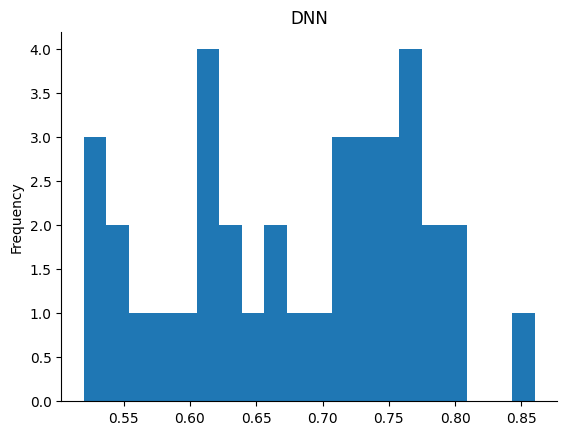

In [ ]:
# @title DNN

from matplotlib import pyplot as plt
df_trad_new['DNN'].plot(kind='hist', bins=20, title='DNN')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
from scipy.stats import friedmanchisquare

# Define model columns
models = ["DNN", "LR", "DTC", "KNN", "NB"]

# Ensure numeric conversion and drop any non-numeric rows
df_trad_new_clean = df_trad_new[models].apply(pd.to_numeric, errors='coerce').dropna()

# Convert cleaned data to numpy array
scores_trad_new_clean = df_trad_new_clean.values

# Apply Friedman's test
stat_trad_new, p_trad_new = friedmanchisquare(*scores_trad_new_clean.T)

# Results
stat_trad_new, p_trad_new


(20.559440559440596, 0.0003871440035871535)

In [ ]:
# Load the new KTTSC dataset
file_kt_new = "/content/KTTSC TRAIN-TEST DATASETS.xlsx"
xls_kt_new = pd.ExcelFile(file_kt_new)

# Display sheet names
xls_kt_new.sheet_names


['Sheet1']

In [ ]:
# Load and preview the first few rows of the KTTSC dataset
df_kt_new = pd.read_excel(xls_kt_new, sheet_name="Sheet1")
df_kt_new.head()


,train-test datasets,size of training dataset,DNN,LR,DTC,KNN,NB
0,Jedit4.0-Ant1.3,MS,0.95,0.79,0.83,0.79,0.73
1,Synapse1.1-Ant1.4,MS,0.81,0.64,0.76,0.77,0.66
2,Jedit4.1-Ant1.5,MS,0.85,0.78,0.88,0.89,0.82
3,Jedit4.1-Ant1.6,MS,0.87,0.75,0.86,0.85,0.72
4,Jedit4.1-Ant1.7,MS,0.87,0.74,0.85,0.84,0.73


In [ ]:
from scipy.stats import friedmanchisquare

# Define model columns
models_kt = ["DNN", "LR", "DTC", "KNN", "NB"]

# Ensure numeric conversion and drop any non-numeric rows
df_kt_new_clean = df_kt_new[models_kt].apply(pd.to_numeric, errors='coerce').dropna()

# Convert cleaned data to numpy array
scores_kt_new_clean = df_kt_new_clean.values

# Apply Friedman's test
stat_kt_new, p_kt_new = friedmanchisquare(*scores_kt_new_clean.T)

# Results
stat_kt_new, p_kt_new


(99.55129958960333, 1.225647125218468e-20)

In [ ]:
from scipy.stats import wilcoxon
from itertools import combinations

# Generate all possible model pairs
model_pairs = list(combinations(models, 2))

# Perform Wilcoxon signed-rank test for each pair
wilcoxon_results = {}
alpha = 0.05

for model1, model2 in model_pairs:
    stat, p = wilcoxon(df_trad_new_clean[model1], df_trad_new_clean[model2])
    wilcoxon_results[(model1, model2)] = (stat, p, p < alpha)  # Store results with significance flag

# Display results
wilcoxon_results


{('DNN', 'LR'): (151.0, 0.02063863839545896, True),
 ('DNN', 'DTC'): (45.5, 2.6787003489420076e-05, True),
 ('DNN', 'KNN'): (142.5, 0.004713058162716531, True),
 ('DNN', 'NB'): (79.5, 1.080476795323193e-05, True),
 ('LR', 'DTC'): (186.5, 0.03526652910719609, True),
 ('LR', 'KNN'): (332.0, 0.9874563869172693, False),
 ('LR', 'NB'): (297.5, 0.5769143354500497, False),
 ('DTC', 'KNN'): (180.5, 0.027558678799664112, True),
 ('DTC', 'NB'): (301.0, 0.8185936662080462, False),
 ('KNN', 'NB'): (235.0, 0.4161050071700807, False)}

In [ ]:
from itertools import combinations
from scipy.stats import wilcoxon

# Generate all possible model pairs
model_pairs_kt = list(combinations(models_kt, 2))

# Perform Wilcoxon signed-rank test for each pair
wilcoxon_results_kt = {}
alpha = 0.05

for model1, model2 in model_pairs_kt:
    stat, p = wilcoxon(df_kt_new_clean[model1], df_kt_new_clean[model2])
    wilcoxon_results_kt[(model1, model2)] = (stat, p, p < alpha)  # Store results with significance flag

# Display results
wilcoxon_results_kt


{('DNN', 'LR'): (9.5, 3.6815967624962513e-07, True),
 ('DNN', 'DTC'): (63.5, 2.279079732047044e-05, True),
 ('DNN', 'KNN'): (47.0, 3.1478703022003174e-07, True),
 ('DNN', 'NB'): (1.5, 4.3655745685100555e-11, True),
 ('LR', 'DTC'): (46.5, 2.775777829810977e-07, True),
 ('LR', 'KNN'): (109.5, 0.002218941696576754, True),
 ('LR', 'NB'): (65.5, 4.331151726138049e-05, True),
 ('DTC', 'KNN'): (215.0, 0.06313509418819536, False),
 ('DTC', 'NB'): (15.0, 1.9936123862862587e-09, True),
 ('KNN', 'NB'): (56.5, 1.0323856258764863e-06, True)}

In [ ]:
# Load the updated KTTSC dataset
file_kttsc_new = "/content/KTTSC TRAIN-TEST DATASETS.xlsx"
xls_kttsc_new = pd.ExcelFile(file_kttsc_new)
df_kttsc_new = pd.read_excel(xls_kttsc_new, sheet_name=xls_kttsc_new.sheet_names[0])

# Load the updated Traditional dataset
file_traditional_new = "/content/TRADITIONAL TRAIN-TEST DATASETS.xlsx"
xls_traditional_new = pd.ExcelFile(file_traditional_new)
df_traditional_new = pd.read_excel(xls_traditional_new, sheet_name=xls_traditional_new.sheet_names[0])

# Extract DNN performance scores from both datasets
dnn_kttsc = df_kttsc_new["DNN"].dropna()
dnn_traditional = df_traditional_new["DNN"].dropna()

# Ensure both arrays have the same length for Wilcoxon test
min_length = min(len(dnn_kttsc), len(dnn_traditional))
dnn_kttsc, dnn_traditional = dnn_kttsc[:min_length], dnn_traditional[:min_length]

# Force numeric conversion of the arrays, replacing invalid values with NaN
dnn_kttsc = pd.to_numeric(dnn_kttsc, errors='coerce').dropna().to_numpy()
dnn_traditional = pd.to_numeric(dnn_traditional, errors='coerce').dropna().to_numpy()

# Perform Wilcoxon Signed-Rank Test
stat_dnn, p_dnn = wilcoxon(dnn_kttsc, dnn_traditional)

# Return results
stat_dnn, p_dnn

(0.0, 1.4551915228366852e-11)

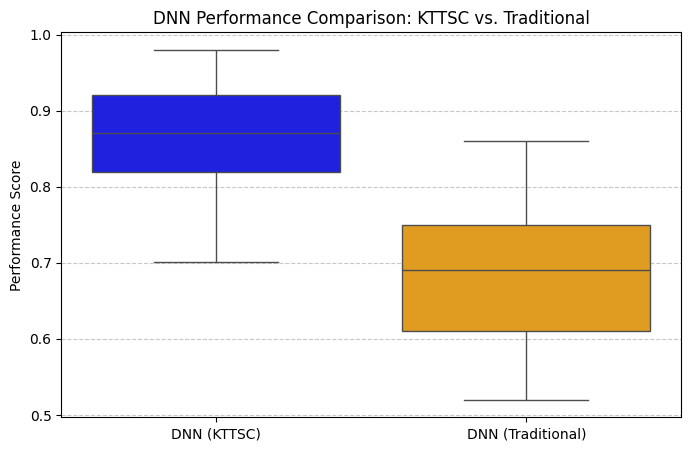

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot to visualize DNN performance in both datasets
plt.figure(figsize=(8, 5))
sns.boxplot(data=[dnn_kttsc, dnn_traditional], palette=["blue", "orange"])

# Set x-axis labels and title
plt.xticks([0, 1], ["DNN (KTTSC)", "DNN (Traditional)"])
plt.ylabel("Performance Score")
plt.title("DNN Performance Comparison: KTTSC vs. Traditional")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


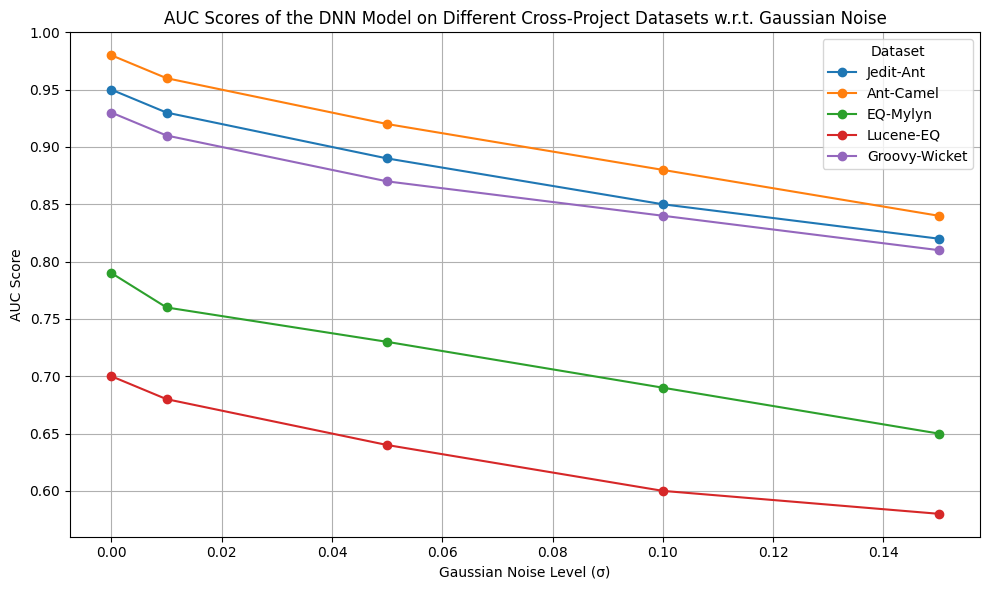

In [ ]:
import matplotlib.pyplot as plt

# Gaussian noise levels
noise_levels = [0, 0.01, 0.05, 0.1, 0.15]

# Example datasets and their AUC scores under different noise levels
auc_scores = {
    "Jedit-Ant": [0.95, 0.93, 0.89, 0.85, 0.82],
    "Ant-Camel": [0.98, 0.96, 0.92, 0.88, 0.84],
    "EQ-Mylyn": [0.79, 0.76, 0.73, 0.69, 0.65],
    "Lucene-EQ": [0.70, 0.68, 0.64, 0.60, 0.58],
    "Groovy-Wicket": [0.93, 0.91, 0.87, 0.84, 0.81],
}

# Plot
plt.figure(figsize=(10, 6))
for dataset, auc in auc_scores.items():
    plt.plot(noise_levels, auc, marker='o', label=dataset)

plt.title('AUC Scores of the DNN Model on Different Cross-Project Datasets w.r.t. Gaussian Noise')
plt.xlabel('Gaussian Noise Level (σ)')
plt.ylabel('AUC Score')
plt.grid(True)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()


In [ ]:
# Define model columns (assuming they are the same across both datasets)
models = ["DNN", "LR", "DTC", "KNN", "NB"]

# Extract numeric data for each dataset
df_kttsc_clean = df_kttsc_new[models].apply(pd.to_numeric, errors='coerce').dropna()
df_traditional_clean = df_traditional_new[models].apply(pd.to_numeric, errors='coerce').dropna()

# Convert to numpy arrays
scores_kttsc = df_kttsc_clean.values
scores_traditional = df_traditional_clean.values

# Perform Friedman's test for both datasets
stat_kttsc, p_kttsc = friedmanchisquare(*scores_kttsc.T)
stat_traditional, p_traditional = friedmanchisquare(*scores_traditional.T)

# Return results
(stat_kttsc, p_kttsc), (stat_traditional, p_traditional)


((99.55129958960333, 1.225647125218468e-20),
 (20.559440559440596, 0.0003871440035871535))